# Машинное обучение для классификации TBI vs Control

Эта версия ноутбука переупорядочена внутри одного файла: добавлены крупные разделы, выровнены названия ячеек, удалён пустой кодовый блок и русифицированы основные названия рисунков.

## Структура ноутбука
0. Подготовка окружения  
I. Формирование итоговой матрицы и EDA  
II. Подготовка ML-данных и группировки  
III. Основная модель и nested CV  
IV. Сравнение моделей и sensitivity-анализ  
V. Итоговые материалы основной модели  
VI. Блочный и инкрементальный анализ  
VII. Вклад признаков и дополнительные sensitivity-анализы  
VIII. Схема пайплайна, таблицы и реестры  
IX. Валидация и контроль корректности


In [ ]:
#@title 0.1 Установка зависимостей
!pip -q install mne numpy scipy pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.7 MB/s eta 0:00:00


In [ ]:
#@title 0.2 Подключение Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# @title 0.3 Подготовка окружения: импорты, стиль графиков, папки для результатов
# ВАЖНО: ячейка настраивает единый стиль визуализаций (пастельные тона),
# создаёт структуру папок для сохранения рисунков/таблиц и задаёт вспомогательные функции.

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MNE для чтения Epochs (.fif)
import mne

# tqdm для прогресса (в Colab часто уже есть)
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# 1) Пути (можно переопределить в следующей ячейке)
# -----------------------------
STD_DIR_DEFAULT = Path("/content/drive/MyDrive/VKR/TBI/work/output/standardized")
OUT_ROOT_DEFAULT = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral")

# -----------------------------
# 2) Единый стиль графиков (пастельная палитра + прозрачность)
# -----------------------------
# @title Fix палитры: PASTEL_COLORS -> список + новая читаемая пастельная палитра
# ВАЖНО: set не индексируется. Эта ячейка переопределяет палитру и применяет стиль.

import matplotlib.pyplot as plt

# Новая палитра (мягкая, но контрастная, без "тёмных" тонов)
# Подбирала так, чтобы линии и заливки различались и на белом фоне, и при печати.
PASTEL_COLORS = [
    "#FFB4A2",  # мягкий коралловый
    "#6EC6FF",  # светлый насыщенный голубой
    "#90DBA5",  # нежный зелёный
    "#B8B8FF",  # лавандовый
    "#FFD166",  # пастельный янтарный
    "#9AD0EC",  # голубовато-мятный
    "#F7A1C4",  # розово-лиловый
    "#CDEAC0",  # светло-зелёный
]

# На случай, если где-то выше палитра была set — принудительно делаем list
if not isinstance(PASTEL_COLORS, list):
    PASTEL_COLORS = list(PASTEL_COLORS)

# Применяем общий стиль с новой палитрой
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_COLORS)

print("Готово: PASTEL_COLORS теперь список и палитра обновлена.")
print("PASTEL_COLORS =", PASTEL_COLORS)


STYLE = {
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 15,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
}

def apply_plot_style():
    """Применяем единый стиль ко всем графикам в ноутбуке."""
    for k, v in STYLE.items():
        plt.rcParams[k] = v
    # Устанавливаем циклическую палитру
    plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_COLORS)

def ensure_dir(path: Path) -> Path:
    """Создаём папку, если её нет."""
    path.mkdir(parents=True, exist_ok=True)
    return path

def savefig(fig, out_path: Path, tight: bool = True):
    """Сохраняем рисунок и печатаем путь (удобно для анализа)."""
    ensure_dir(out_path.parent)
    if tight:
        fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    print(f"[savefig] Сохранено изображение: {out_path}")

def show_df(df: pd.DataFrame, n: int = 5, title: str = ""):
    """Удобный вывод DataFrame (первые строки + размер)."""
    if title:
        print(title)
    print(f"Размер таблицы: {df.shape[0]} строк × {df.shape[1]} столбцов")
    display(df.head(n))

apply_plot_style()

# -----------------------------
# 3) Папки по умолчанию (можно будет поменять во 2-й ячейке)
# -----------------------------
STD_DIR = STD_DIR_DEFAULT
OUT_ROOT = OUT_ROOT_DEFAULT

OUT_FIG = ensure_dir(OUT_ROOT / "figures")
OUT_TAB = ensure_dir(OUT_ROOT / "tables")
OUT_LOG = ensure_dir(OUT_ROOT / "logs")
OUT_CACHE = ensure_dir(OUT_ROOT / "cache")

print("Готово.")
print(f"STD_DIR  = {STD_DIR}")
print(f"OUT_ROOT = {OUT_ROOT}")
print("Папки результатов:")
print(f"  figures: {OUT_FIG}")
print(f"  tables : {OUT_TAB}")
print(f"  logs   : {OUT_LOG}")
print(f"  cache  : {OUT_CACHE}")

Готово: PASTEL_COLORS теперь список и палитра обновлена.
PASTEL_COLORS = ['#FFB4A2', '#6EC6FF', '#90DBA5', '#B8B8FF', '#FFD166', '#9AD0EC', '#F7A1C4', '#CDEAC0']
Готово.
STD_DIR  = /content/drive/MyDrive/VKR/TBI/work/output/standardized
OUT_ROOT = /content/drive/MyDrive/VKR/TBI/work/output/spectral
Папки результатов:
  figures: /content/drive/MyDrive/VKR/TBI/work/output/spectral/figures
  tables : /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables
  logs   : /content/drive/MyDrive/VKR/TBI/work/output/spectral/logs
  cache  : /content/drive/MyDrive/VKR/TBI/work/output/spectral/cache


## I. Формирование итоговой матрицы и первичный EDA

В этом разделе собирается единая итоговая матрица признаков, проводится базовый аудит её структуры и формируется ML-ready версия данных.


In [ ]:
# @title I.1 Итоговая матрица признаков record-level


import re
from pathlib import Path

import pandas as pd


# =========================================
# 0. Пути
# =========================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

BASE_TAB.mkdir(parents=True, exist_ok=True)

OUT_CORE_REC = BASE_TAB / "all_features_record_level_core.csv"
OUT_CORE_REC_MAP = BASE_TAB / "all_features_record_level_core_feature_map.csv"
OUT_CORE_REC_MISSING = BASE_TAB / "all_features_record_level_core_missing_sources.csv"


# =========================================
# 1. Источники core
# =========================================
SOURCES_CORE = [
    {
        "name": "inventory",
        "filename": "inventory_epochs_standardized.csv",
        "prefix": "meta",
        "entity_cols": [],
        "direct_wide": True,
    },
    {
        "name": "bandpower",
        "filename": "subject_level_bandpower_roi.csv",
        "prefix": "bp",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "indices",
        "filename": "subject_level_indices_roi.csv",
        "prefix": "idx",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "alpha_peak",
        "filename": "subject_level_alpha_peak_metrics_roi.csv",
        "prefix": "alpha_peak",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "sef_entropy",
        "filename": "subject_level_sef95_entropy_roi.csv",
        "prefix": "spec_shape",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "aperiodic",
        "filename": "subject_level_aperiodic_and_alpha_peak_over_bg_roi.csv",
        "prefix": "aper",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "gamma_views",
        "filename": "METRIC_gamma_three_views_subject_level.csv",
        "prefix": "gamma",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "dfa",
        "filename": "LRTC_DFA_subject_level.csv",
        "prefix": "dfa",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "burst",
        "filename": "BURST_subject_level_metrics.csv",
        "prefix": "burst",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "tfr",
        "filename": "TFR_morlet_subject_level_metrics.csv",
        "prefix": "tfr",
        "entity_cols": ["roi", "band", "metric"],
        "direct_wide": False,
    },
    {
        "name": "conn_graph_adv",
        "filename": "CONNECTIVITY_ADV_graph_metrics_subject_level.csv",
        "prefix": "conn",
        "entity_cols": ["measure", "band"],
        "direct_wide": False,
    },
    {
        "name": "events_subject",
        "filename": "EVENTS_ADV_event_features_subject_level.csv",
        "prefix": "event",
        "entity_cols": [],
        "direct_wide": True,
    },
]

KEY_COLS = ["group", "record_id"]


# =========================================
# 2. Вспомогательные функции
# =========================================
def find_csv(filename):
    p = BASE_TAB / filename
    if p.exists():
        return p
    found = list(BASE_TAB.rglob(filename))
    return found[0] if found else None


def safe_read_csv(path):
    df = pd.read_csv(path)
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str)
    return df


def clean_token(x):
    s = str(x).strip().lower()
    s = s.replace(" ", "_")
    s = s.replace("/", "_per_")
    s = s.replace("%", "pct")
    s = re.sub(r"[^a-zA-Z0-9_а-яА-Я]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def numeric_feature_cols(df, exclude):
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def make_wide_from_long(df, prefix, entity_cols):
    entity_cols = [c for c in entity_cols if c in df.columns]
    value_cols = numeric_feature_cols(df, exclude=KEY_COLS + entity_cols)

    if len(value_cols) == 0:
        return df[KEY_COLS].drop_duplicates().copy()

    tmp = df[KEY_COLS + entity_cols + value_cols].copy()

    if len(entity_cols) > 0:
        for c in entity_cols:
            tmp[c] = tmp[c].astype(str).map(clean_token)
        tmp["_entity_key"] = tmp[entity_cols].agg("__".join, axis=1)
    else:
        tmp["_entity_key"] = "global"

    pieces = []
    for val_col in value_cols:
        w = tmp.pivot_table(
            index=KEY_COLS,
            columns="_entity_key",
            values=val_col,
            aggfunc="first",
        )
        w.columns = [
            f"{prefix}__{clean_token(val_col)}__{clean_token(col)}"
            for col in w.columns
        ]
        pieces.append(w)

    out = pd.concat(pieces, axis=1).reset_index()
    return out


def make_prefixed_wide_numeric_only(df, prefix):
    num_cols = numeric_feature_cols(df, exclude=KEY_COLS)
    keep_cols = [c for c in KEY_COLS if c in df.columns] + num_cols
    out = df[keep_cols].copy()

    if out.duplicated(KEY_COLS).any():
        out = out.groupby(KEY_COLS, as_index=False)[num_cols].median()

    rename_map = {}
    for c in num_cols:
        rename_map[c] = f"{prefix}__{clean_token(c)}"
    out = out.rename(columns=rename_map)
    return out


# =========================================
# 3. Merge
# =========================================
merged = None
feature_map_rows = []
missing_rows = []

for src in SOURCES_CORE:
    path = find_csv(src["filename"])
    if path is None:
        missing_rows.append({
            "source_name": src["name"],
            "filename": src["filename"],
            "status": "missing",
        })
        print(f"⚠️ Не найден файл: {src['filename']}")
        continue

    print(f"Читаю: {path.name}")
    df0 = safe_read_csv(path)

    if not all(c in df0.columns for c in KEY_COLS):
        missing_rows.append({
            "source_name": src["name"],
            "filename": src["filename"],
            "status": "missing_keys",
        })
        print(f"⚠️ Пропуск {src['filename']}: нет group/record_id")
        continue

    if src["direct_wide"]:
        dfw = make_prefixed_wide_numeric_only(df0, prefix=src["prefix"])
    else:
        dfw = make_wide_from_long(df0, prefix=src["prefix"], entity_cols=src["entity_cols"])

    for c in dfw.columns:
        if c in KEY_COLS:
            continue
        feature_map_rows.append({
            "feature_name": c,
            "source_name": src["name"],
            "source_file": src["filename"],
            "source_prefix": src["prefix"],
        })

    if merged is None:
        merged = dfw.copy()
    else:
        merged = merged.merge(dfw, on=KEY_COLS, how="outer")

if merged is None:
    raise RuntimeError("Не удалось собрать record-level core матрицу.")

merged["group"] = merged["group"].astype(str)
merged["record_id"] = merged["record_id"].astype(str)
merged = merged.sort_values(["group", "record_id"]).reset_index(drop=True)

non_key = [c for c in merged.columns if c not in KEY_COLS]
drop_cols = [c for c in non_key if merged[c].isna().all()]
if len(drop_cols) > 0:
    merged = merged.drop(columns=drop_cols)

df_map = pd.DataFrame(feature_map_rows).drop_duplicates().reset_index(drop=True)
df_missing = pd.DataFrame(missing_rows)

merged.to_csv(OUT_CORE_REC, index=False, encoding="utf-8")
df_map.to_csv(OUT_CORE_REC_MAP, index=False, encoding="utf-8")
df_missing.to_csv(OUT_CORE_REC_MISSING, index=False, encoding="utf-8")

print("\n✅ RECORD-LEVEL CORE-матрица готова")
print("Путь:", OUT_CORE_REC)
print("shape =", merged.shape)
print("groups:")
print(merged["group"].value_counts(dropna=False))

display(merged.head(3))
display(df_map.head(20))
display(df_missing.head(20))

Читаю: inventory_epochs_standardized.csv
Читаю: subject_level_bandpower_roi.csv
Читаю: subject_level_indices_roi.csv
Читаю: subject_level_alpha_peak_metrics_roi.csv
Читаю: subject_level_sef95_entropy_roi.csv
Читаю: subject_level_aperiodic_and_alpha_peak_over_bg_roi.csv
Читаю: METRIC_gamma_three_views_subject_level.csv
Читаю: LRTC_DFA_subject_level.csv
Читаю: BURST_subject_level_metrics.csv
Читаю: TFR_morlet_subject_level_metrics.csv
Читаю: CONNECTIVITY_ADV_graph_metrics_subject_level.csv
Читаю: EVENTS_ADV_event_features_subject_level.csv

✅ RECORD-LEVEL CORE-матрица готова
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/all_features_record_level_core.csv
shape = (579, 777)
groups:
group
Control    364
TBI        215
Name: count, dtype: int64


,group,record_id,meta__size_mb,meta__n_epochs,meta__sfreq_hz,meta__n_channels,meta__tmin_sec,meta__tmax_sec,meta__epoch_len_sec,bp__band_fmin__central_alpha,...,event__slope_fall_uvs,event__sharpness_uv,event__z_peak,event__slow_peak_uv,event__spike_to_slow_ratio,event__n_involved_ch,event__lr_index,event__spread_rois,event__propagation_ms,event__n_events
0,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,21.250,48,500.0,58,0.0,3.998,3.998,8.0,...,-2192.838788,12.126265,4.162415,21.592249,0.723467,12.0,0.0,4.0,41.0,72
1,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,20.365,46,500.0,58,0.0,3.998,3.998,8.0,...,-1957.175493,11.004203,4.044839,24.261977,0.786108,11.0,0.0,3.0,36.0,110
2,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,20.365,46,500.0,58,0.0,3.998,3.998,8.0,...,-2040.191174,11.580379,4.482171,22.131896,0.757124,10.5,0.0,3.0,46.0,144


,feature_name,source_name,source_file,source_prefix
0,meta__size_mb,inventory,inventory_epochs_standardized.csv,meta
1,meta__n_epochs,inventory,inventory_epochs_standardized.csv,meta
2,meta__sfreq_hz,inventory,inventory_epochs_standardized.csv,meta
3,meta__n_channels,inventory,inventory_epochs_standardized.csv,meta
4,meta__tmin_sec,inventory,inventory_epochs_standardized.csv,meta
5,meta__tmax_sec,inventory,inventory_epochs_standardized.csv,meta
6,meta__epoch_len_sec,inventory,inventory_epochs_standardized.csv,meta
7,bp__band_fmin__central_alpha,bandpower,subject_level_bandpower_roi.csv,bp
8,bp__band_fmin__central_beta,bandpower,subject_level_bandpower_roi.csv,bp
9,bp__band_fmin__central_delta,bandpower,subject_level_bandpower_roi.csv,bp


""


In [ ]:
# @title I.2 Базовый аудит feature-матрицы


from pathlib import Path
import re

import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

BASE_TAB.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = BASE_TAB / "all_features_record_level_core.csv"

OUT_EDA_DIR = BASE_TAB / "eda_core"
OUT_EDA_DIR.mkdir(parents=True, exist_ok=True)

OUT_SUMMARY = OUT_EDA_DIR / "eda01_matrix_summary.csv"
OUT_BLOCKS = OUT_EDA_DIR / "eda01_feature_blocks_summary.csv"
OUT_MISSING = OUT_EDA_DIR / "eda01_missingness_per_feature.csv"
OUT_CONSTANT = OUT_EDA_DIR / "eda01_constant_features.csv"
OUT_NEAR_CONSTANT = OUT_EDA_DIR / "eda01_near_constant_features.csv"
OUT_NUMERIC_LIST = OUT_EDA_DIR / "eda01_numeric_feature_list.csv"


# =========================================================
# 1. Загрузка данных
# =========================================================
assert FEATURES_PATH.exists(), f"Не найден файл: {FEATURES_PATH}"

df = pd.read_csv(FEATURES_PATH)

assert "group" in df.columns, "В таблице нет колонки group"
assert "record_id" in df.columns, "В таблице нет колонки record_id"

df["group"] = df["group"].astype(str)
df["record_id"] = df["record_id"].astype(str)

print("Загружен файл:", FEATURES_PATH)
print("Размер таблицы:", df.shape)


# =========================================================
# 2. Базовые списки колонок
# =========================================================
KEY_COLS = ["group", "record_id"]

all_cols = list(df.columns)
feature_cols = [c for c in all_cols if c not in KEY_COLS]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
non_numeric_cols = [c for c in feature_cols if c not in numeric_cols]

print("\nКлючевые колонки:", KEY_COLS)
print("Всего колонок:", len(all_cols))
print("Колонок-признаков:", len(feature_cols))
print("Числовых признаков:", len(numeric_cols))
print("Нечисловых неключевых колонок:", len(non_numeric_cols))


# =========================================================
# 3. Общая сводка по матрице
# =========================================================
n_rows, n_cols = df.shape
group_counts = df["group"].value_counts(dropna=False).to_dict()

summary_rows = [
    {"metric": "n_rows", "value": n_rows},
    {"metric": "n_cols_total", "value": n_cols},
    {"metric": "n_feature_cols", "value": len(feature_cols)},
    {"metric": "n_numeric_feature_cols", "value": len(numeric_cols)},
    {"metric": "n_non_numeric_feature_cols", "value": len(non_numeric_cols)},
    {"metric": "n_unique_record_id", "value": df["record_id"].nunique()},
    {"metric": "n_duplicate_record_id", "value": int(df["record_id"].duplicated().sum())},
]

for grp, cnt in group_counts.items():
    summary_rows.append({"metric": f"group_count__{grp}", "value": cnt})

df_summary = pd.DataFrame(summary_rows)


# =========================================================
# 4. Пропуски по признакам
# =========================================================
missing_rows = []
for c in numeric_cols:
    n_missing = int(df[c].isna().sum())
    frac_missing = float(df[c].isna().mean())
    n_unique_non_na = int(df[c].nunique(dropna=True))

    missing_rows.append({
        "feature": c,
        "n_missing": n_missing,
        "frac_missing": frac_missing,
        "n_unique_non_na": n_unique_non_na,
    })

df_missing = pd.DataFrame(missing_rows).sort_values(
    ["frac_missing", "n_missing", "feature"],
    ascending=[False, False, True]
).reset_index(drop=True)

summary_rows_extra = [
    {"metric": "n_features_with_any_missing", "value": int((df_missing["n_missing"] > 0).sum())},
    {"metric": "n_features_missing_gt_5pct", "value": int((df_missing["frac_missing"] > 0.05).sum())},
    {"metric": "n_features_missing_gt_10pct", "value": int((df_missing["frac_missing"] > 0.10).sum())},
    {"metric": "n_features_missing_gt_20pct", "value": int((df_missing["frac_missing"] > 0.20).sum())},
    {"metric": "n_features_missing_gt_50pct", "value": int((df_missing["frac_missing"] > 0.50).sum())},
]
df_summary = pd.concat([df_summary, pd.DataFrame(summary_rows_extra)], ignore_index=True)


# =========================================================
# 5. Константные и почти константные признаки
# =========================================================
constant_rows = []
near_constant_rows = []

for c in numeric_cols:
    s = df[c]

    # Число уникальных значений без NaN
    nun = int(s.nunique(dropna=True))

    # Константный признак
    if nun <= 1:
        constant_rows.append({
            "feature": c,
            "n_unique_non_na": nun,
            "top_value": s.dropna().iloc[0] if s.notna().any() else np.nan,
            "top_freq": 1.0 if s.notna().any() else np.nan,
        })
        continue

    # Почти константный признак:
    # доля самого частого значения среди ненулевых наблюдений >= 0.95
    vc = s.dropna().value_counts(normalize=True)
    if len(vc) > 0:
        top_value = vc.index[0]
        top_freq = float(vc.iloc[0])

        if top_freq >= 0.95:
            near_constant_rows.append({
                "feature": c,
                "n_unique_non_na": nun,
                "top_value": top_value,
                "top_freq": top_freq,
            })

df_constant = pd.DataFrame(constant_rows).sort_values(
    ["feature"]
).reset_index(drop=True) if len(constant_rows) > 0 else pd.DataFrame(
    columns=["feature", "n_unique_non_na", "top_value", "top_freq"]
)

df_near_constant = pd.DataFrame(near_constant_rows).sort_values(
    ["top_freq", "feature"],
    ascending=[False, True]
).reset_index(drop=True) if len(near_constant_rows) > 0 else pd.DataFrame(
    columns=["feature", "n_unique_non_na", "top_value", "top_freq"]
)

df_summary = pd.concat([
    df_summary,
    pd.DataFrame([
        {"metric": "n_constant_features", "value": len(df_constant)},
        {"metric": "n_near_constant_features_topfreq_ge_0_95", "value": len(df_near_constant)},
    ])
], ignore_index=True)


# =========================================================
# 6. Разбиение признаков по блокам
# =========================================================
def detect_block(feature_name):
    """
    Извлекаем блок по префиксу до первого '__'.
    Например:
    bp__bandpower_rel__frontal_alpha -> bp
    conn__value__global_efficiency__alpha -> conn
    """
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"


block_rows = []
for block, cols in pd.Series(numeric_cols).groupby(pd.Series(numeric_cols).map(detect_block)):
    cols = list(cols)

    frac_missing_mean = float(df[cols].isna().mean().mean()) if len(cols) > 0 else np.nan
    frac_missing_median = float(df[cols].isna().mean().median()) if len(cols) > 0 else np.nan

    n_constant_block = int(df_constant["feature"].isin(cols).sum()) if len(df_constant) > 0 else 0
    n_near_constant_block = int(df_near_constant["feature"].isin(cols).sum()) if len(df_near_constant) > 0 else 0

    block_rows.append({
        "block": block,
        "n_features": len(cols),
        "frac_of_all_numeric_features": len(cols) / max(len(numeric_cols), 1),
        "mean_missing_frac": frac_missing_mean,
        "median_missing_frac": frac_missing_median,
        "n_constant_features": n_constant_block,
        "n_near_constant_features": n_near_constant_block,
    })

df_blocks = pd.DataFrame(block_rows).sort_values(
    ["n_features", "block"],
    ascending=[False, True]
).reset_index(drop=True)


# =========================================================
# 7. Дополнительная быстрая QC-сводка по meta-признакам
# =========================================================
meta_cols = [c for c in numeric_cols if c.startswith("meta__")]

qc_rows = []
for c in meta_cols:
    row = {
        "feature": c,
        "overall_mean": float(df[c].mean()) if df[c].notna().any() else np.nan,
        "overall_std": float(df[c].std()) if df[c].notna().any() else np.nan,
    }

    for grp in sorted(df["group"].dropna().unique()):
        s = df.loc[df["group"] == grp, c]
        row[f"{grp}_median"] = float(s.median()) if s.notna().any() else np.nan
        row[f"{grp}_iqr"] = float(s.quantile(0.75) - s.quantile(0.25)) if s.notna().any() else np.nan

    qc_rows.append(row)

df_qc_meta = pd.DataFrame(qc_rows)

OUT_QC_META = OUT_EDA_DIR / "eda01_meta_qc_summary.csv"
df_qc_meta.to_csv(OUT_QC_META, index=False, encoding="utf-8")


# =========================================================
# 8. Список числовых признаков
# =========================================================
df_numeric_list = pd.DataFrame({
    "feature": numeric_cols,
    "block": [detect_block(c) for c in numeric_cols],
})
df_numeric_list = df_numeric_list.sort_values(["block", "feature"]).reset_index(drop=True)


# =========================================================
# 9. Сохранение
# =========================================================
df_summary.to_csv(OUT_SUMMARY, index=False, encoding="utf-8")
df_blocks.to_csv(OUT_BLOCKS, index=False, encoding="utf-8")
df_missing.to_csv(OUT_MISSING, index=False, encoding="utf-8")
df_constant.to_csv(OUT_CONSTANT, index=False, encoding="utf-8")
df_near_constant.to_csv(OUT_NEAR_CONSTANT, index=False, encoding="utf-8")
df_numeric_list.to_csv(OUT_NUMERIC_LIST, index=False, encoding="utf-8")


# =========================================================
# 10. Печать итогов
# =========================================================
print("\n✅ EDA 1 завершён")
print("Сводка матрицы:", OUT_SUMMARY)
print("Сводка по блокам:", OUT_BLOCKS)
print("Пропуски по признакам:", OUT_MISSING)
print("Константные признаки:", OUT_CONSTANT)
print("Почти константные признаки:", OUT_NEAR_CONSTANT)
print("Список числовых признаков:", OUT_NUMERIC_LIST)
print("QC по meta-признакам:", OUT_QC_META)

print("\n=== КРАТКАЯ СВОДКА ===")
display(df_summary)

print("\n=== БЛОКИ ПРИЗНАКОВ ===")
display(df_blocks)

print("\n=== ТОП-20 признаков с наибольшей долей пропусков ===")
display(df_missing.head(20))

print("\n=== КОНСТАНТНЫЕ ПРИЗНАКИ ===")
display(df_constant.head(20))

print("\n=== ПОЧТИ КОНСТАНТНЫЕ ПРИЗНАКИ ===")
display(df_near_constant.head(20))

print("\n=== QC ПО META-ПРИЗНАКАМ ===")
display(df_qc_meta)

Загружен файл: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/all_features_record_level_core.csv
Размер таблицы: (579, 777)

Ключевые колонки: ['group', 'record_id']
Всего колонок: 777
Колонок-признаков: 775
Числовых признаков: 775
Нечисловых неключевых колонок: 0

✅ EDA 1 завершён
Сводка матрицы: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_matrix_summary.csv
Сводка по блокам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_feature_blocks_summary.csv
Пропуски по признакам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_missingness_per_feature.csv
Константные признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_constant_features.csv
Почти константные признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_near_constant_features.csv
Список числовых признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda01_nume

,metric,value
0,n_rows,579
1,n_cols_total,777
2,n_feature_cols,775
3,n_numeric_feature_cols,775
4,n_non_numeric_feature_cols,0
5,n_unique_record_id,579
6,n_duplicate_record_id,0
7,group_count__Control,364
8,group_count__TBI,215
9,n_features_with_any_missing,15



=== БЛОКИ ПРИЗНАКОВ ===


,block,n_features,frac_of_all_numeric_features,mean_missing_frac,median_missing_frac,n_constant_features,n_near_constant_features
0,conn,300,0.387097,0.000040,0.0,80,0
1,bp,125,0.161290,0.000000,0.0,50,0
2,burst,100,0.129032,0.000138,0.0,0,0
3,aper,45,0.058065,0.001689,0.0,14,1
4,idx,45,0.058065,0.000000,0.0,0,0
5,dfa,40,0.051613,0.000000,0.0,10,10
6,alpha_peak,30,0.038710,0.000000,0.0,15,0
7,tfr,30,0.038710,0.000000,0.0,0,0
8,spec_shape,25,0.032258,0.000000,0.0,10,0
9,event,16,0.020645,0.000000,0.0,0,0



=== ТОП-20 признаков с наибольшей долей пропусков ===


...

,feature,n_unique_non_na,top_value,top_freq
0,alpha_peak__alpha_win_hi__central,1,14.0,1.0
1,alpha_peak__alpha_win_hi__frontal,1,14.0,1.0
2,alpha_peak__alpha_win_hi__occipital,1,14.0,1.0
3,alpha_peak__alpha_win_hi__parietal,1,14.0,1.0
4,alpha_peak__alpha_win_hi__temporal,1,14.0,1.0
5,alpha_peak__alpha_win_lo__central,1,6.0,1.0
6,alpha_peak__alpha_win_lo__frontal,1,6.0,1.0
7,alpha_peak__alpha_win_lo__occipital,1,6.0,1.0
8,alpha_peak__alpha_win_lo__parietal,1,6.0,1.0
9,alpha_peak__alpha_win_lo__temporal,1,6.0,1.0



=== ПОЧТИ КОНСТАНТНЫЕ ПРИЗНАКИ ===


,feature,n_unique_non_na,top_value,top_freq
0,dfa__n_scales_used__central_alpha,2,18,0.998273
1,dfa__n_scales_used__central_beta,2,18,0.998273
2,dfa__n_scales_used__frontal_alpha,2,18,0.998273
3,dfa__n_scales_used__frontal_beta,2,18,0.998273
4,dfa__n_scales_used__occipital_alpha,2,18,0.998273
5,dfa__n_scales_used__occipital_beta,2,18,0.998273
6,dfa__n_scales_used__parietal_alpha,2,18,0.998273
7,dfa__n_scales_used__parietal_beta,2,18,0.998273
8,dfa__n_scales_used__temporal_alpha,2,18,0.998273
9,dfa__n_scales_used__temporal_beta,2,18,0.998273



=== QC ПО META-ПРИЗНАКАМ ===


,feature,overall_mean,overall_std,Control_median,Control_iqr,TBI_median,TBI_iqr
0,meta__size_mb,31.798187,1.497570e+01,20.365,0.442,50.899,1.327
1,meta__n_epochs,71.835924,3.384167e+01,46.000,1.000,115.000,3.000
2,meta__sfreq_hz,500.000000,0.000000e+00,500.000,0.000,500.000,0.000
3,meta__n_channels,58.000000,0.000000e+00,58.000,0.000,58.000,0.000
4,meta__tmin_sec,-0.742660,9.671564e-01,0.000,0.000,-2.000,0.000
5,meta__tmax_sec,3.255340,9.671564e-01,3.998,0.000,1.998,0.000
6,meta__epoch_len_sec,3.998000,3.466891e-14,3.998,0.000,3.998,0.000


In [ ]:
# @title I.3 Подготовка ML-ready матрицы признаков


from pathlib import Path
import re

import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

BASE_TAB.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = BASE_TAB / "all_features_record_level_core.csv"
EDA_DIR = BASE_TAB / "eda_core"
EDA_DIR.mkdir(parents=True, exist_ok=True)

OUT_X = EDA_DIR / "eda02_X_ml_ready.csv"
OUT_Y = EDA_DIR / "eda02_y_ml_ready.csv"
OUT_FILTER_LOG = EDA_DIR / "eda02_feature_filter_log.csv"
OUT_FEATURES_FINAL = EDA_DIR / "eda02_feature_list_final.csv"
OUT_BLOCKS_FINAL = EDA_DIR / "eda02_feature_blocks_final.csv"
OUT_SUMMARY = EDA_DIR / "eda02_ml_ready_summary.csv"


# =========================================================
# 1. Настройки фильтрации
# =========================================================
MISSING_THRESHOLD = 0.05
NEAR_CONSTANT_TOP_FREQ = 0.95

# Шаблоны признаков, которые почти наверняка являются параметрами расчёта,
# а не содержательными биомаркерами
DROP_NAME_PATTERNS = [
    r"(^|__)band_fmin(__|$)",
    r"(^|__)band_fmax(__|$)",
    r"(^|__)fit_fmin(__|$)",
    r"(^|__)fit_fmax(__|$)",
    r"(^|__)alpha_win_lo(__|$)",
    r"(^|__)alpha_win_hi(__|$)",
    r"(^|__)smooth_w(__|$)",
    r"(^|__)n_scales_used(__|$)",
    r"(^|__)n_fit_points(__|$)",
    r"(^|__)sfreq_hz(__|$)",
    r"(^|__)n_channels(__|$)",
    r"(^|__)epoch_len_sec(__|$)",
    r"(^|__)tmin_sec(__|$)",
    r"(^|__)tmax_sec(__|$)",
    r"(^|__)size_mb(__|$)",
    r"(^|__)n_epochs(__|$)",
]

# Можно при желании исключать некоторые graph-метрики, если они слишком нестабильны
DROP_OPTIONAL_PATTERNS = [
    # r"(^|__)small_worldness(__|$)",
]


# =========================================================
# 2. Загрузка данных
# =========================================================
assert FEATURES_PATH.exists(), f"Не найден файл: {FEATURES_PATH}"

df = pd.read_csv(FEATURES_PATH)
assert "group" in df.columns, "Нет колонки group"
assert "record_id" in df.columns, "Нет колонки record_id"

df["group"] = df["group"].astype(str)
df["record_id"] = df["record_id"].astype(str)

KEY_COLS = ["group", "record_id"]
feature_cols = [c for c in df.columns if c not in KEY_COLS]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

print("Загружена матрица:", df.shape)
print("Числовых признаков до фильтрации:", len(numeric_cols))


# =========================================================
# 3. Вспомогательные функции
# =========================================================
def detect_block(feature_name):
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"


def matches_any_pattern(name, patterns):
    for pat in patterns:
        if re.search(pat, name):
            return True
    return False


# =========================================================
# 4. Пошаговый фильтр признаков
# =========================================================
filter_rows = []

# Стартовый список
current_features = numeric_cols.copy()

for c in current_features:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "start",
        "reason": "initial_numeric_feature",
    })

# 4.1 Удаляем meta-блок полностью
drop_meta = [c for c in current_features if c.startswith("meta__")]
current_features = [c for c in current_features if c not in drop_meta]

for c in drop_meta:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "meta_feature",
    })

# 4.2 Удаляем признаки по шаблонам имени
drop_by_name = [c for c in current_features if matches_any_pattern(c, DROP_NAME_PATTERNS)]
current_features = [c for c in current_features if c not in drop_by_name]

for c in drop_by_name:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "technical_parameter_by_name",
    })

# 4.3 Удаляем опциональные по шаблонам
drop_optional = [c for c in current_features if matches_any_pattern(c, DROP_OPTIONAL_PATTERNS)]
current_features = [c for c in current_features if c not in drop_optional]

for c in drop_optional:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "optional_drop_by_name",
    })

# 4.4 Удаляем признаки с пропусками выше порога
drop_missing = []
for c in current_features:
    frac_missing = float(df[c].isna().mean())
    if frac_missing > MISSING_THRESHOLD:
        drop_missing.append(c)

current_features = [c for c in current_features if c not in drop_missing]

for c in drop_missing:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": f"missing_gt_{MISSING_THRESHOLD:.2f}",
    })

# 4.5 Удаляем константные признаки
drop_constant = []
for c in current_features:
    nun = int(df[c].nunique(dropna=True))
    if nun <= 1:
        drop_constant.append(c)

current_features = [c for c in current_features if c not in drop_constant]

for c in drop_constant:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "constant_feature",
    })

# 4.6 Удаляем почти константные признаки
drop_near_constant = []
for c in current_features:
    vc = df[c].dropna().value_counts(normalize=True)
    if len(vc) == 0:
        drop_near_constant.append(c)
        continue
    top_freq = float(vc.iloc[0])
    if top_freq >= NEAR_CONSTANT_TOP_FREQ:
        drop_near_constant.append(c)

current_features = [c for c in current_features if c not in drop_near_constant]

for c in drop_near_constant:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": f"near_constant_topfreq_ge_{NEAR_CONSTANT_TOP_FREQ:.2f}",
    })

# Финальные retained
for c in current_features:
    filter_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "kept",
        "reason": "passed_all_filters",
    })


# =========================================================
# 5. Формирование X и y
# =========================================================
X = df[current_features].copy()
y = df[["group", "record_id"]].copy()

# Для большинства ML-алгоритмов позже можно отдельно сделать кодирование 0/1,
# но здесь сохраняем исходную группу как есть.
# При необходимости можно добавить:
# y["target"] = (y["group"] == "TBI").astype(int)

# Заполнять пропуски здесь не будем — это лучше делать уже внутри CV-пайплайна.
# Но можно сохранить диагностическую сводку.
missing_after_rows = []
for c in current_features:
    missing_after_rows.append({
        "feature": c,
        "block": detect_block(c),
        "frac_missing": float(X[c].isna().mean()),
        "n_unique_non_na": int(X[c].nunique(dropna=True)),
    })

df_missing_after = pd.DataFrame(missing_after_rows).sort_values(
    ["frac_missing", "feature"],
    ascending=[False, True]
).reset_index(drop=True)

OUT_MISSING_AFTER = EDA_DIR / "eda02_missingness_after_filter.csv"
df_missing_after.to_csv(OUT_MISSING_AFTER, index=False, encoding="utf-8")


# =========================================================
# 6. Сводка по блокам после фильтрации
# =========================================================
block_rows = []
for block, cols in pd.Series(current_features).groupby(pd.Series(current_features).map(detect_block)):
    cols = list(cols)
    block_rows.append({
        "block": block,
        "n_features": len(cols),
        "frac_of_final_features": len(cols) / max(len(current_features), 1),
        "mean_missing_frac": float(X[cols].isna().mean().mean()) if len(cols) > 0 else np.nan,
    })

df_blocks_final = pd.DataFrame(block_rows).sort_values(
    ["n_features", "block"],
    ascending=[False, True]
).reset_index(drop=True)


# =========================================================
# 7. Общая summary-таблица
# =========================================================
df_filter_log = pd.DataFrame(filter_rows)

summary_rows = [
    {"metric": "n_rows", "value": len(df)},
    {"metric": "n_total_numeric_features_before", "value": len(numeric_cols)},
    {"metric": "n_dropped_meta", "value": len(drop_meta)},
    {"metric": "n_dropped_by_name", "value": len(drop_by_name)},
    {"metric": "n_dropped_optional", "value": len(drop_optional)},
    {"metric": "n_dropped_missing", "value": len(drop_missing)},
    {"metric": "n_dropped_constant", "value": len(drop_constant)},
    {"metric": "n_dropped_near_constant", "value": len(drop_near_constant)},
    {"metric": "n_final_features", "value": len(current_features)},
    {"metric": "group_count_control", "value": int((df["group"] == "Control").sum())},
    {"metric": "group_count_tbi", "value": int((df["group"] == "TBI").sum())},
]

df_summary = pd.DataFrame(summary_rows)
df_feature_final = pd.DataFrame({
    "feature": current_features,
    "block": [detect_block(c) for c in current_features],
}).sort_values(["block", "feature"]).reset_index(drop=True)


# =========================================================
# 8. Сохранение
# =========================================================
X.to_csv(OUT_X, index=False, encoding="utf-8")
y.to_csv(OUT_Y, index=False, encoding="utf-8")
df_filter_log.to_csv(OUT_FILTER_LOG, index=False, encoding="utf-8")
df_feature_final.to_csv(OUT_FEATURES_FINAL, index=False, encoding="utf-8")
df_blocks_final.to_csv(OUT_BLOCKS_FINAL, index=False, encoding="utf-8")
df_summary.to_csv(OUT_SUMMARY, index=False, encoding="utf-8")

print("\n✅ EDA 2 завершён")
print("X ML-ready:", OUT_X)
print("y:", OUT_Y)
print("Лог фильтрации:", OUT_FILTER_LOG)
print("Финальный список признаков:", OUT_FEATURES_FINAL)
print("Сводка по блокам:", OUT_BLOCKS_FINAL)
print("Summary:", OUT_SUMMARY)
print("Пропуски после фильтрации:", OUT_MISSING_AFTER)

print("\n=== SUMMARY ===")
display(df_summary)

print("\n=== БЛОКИ ПОСЛЕ ФИЛЬТРАЦИИ ===")
display(df_blocks_final)

print("\n=== ТОП-30 ФИНАЛЬНЫХ ПРИЗНАКОВ ===")
display(df_feature_final.head(30))

print("\n=== ТОП-30 ПРИЗНАКОВ С ПРОПУСКАМИ ПОСЛЕ ФИЛЬТРАЦИИ ===")
display(df_missing_after.head(30))

Загружена матрица: (579, 777)
Числовых признаков до фильтрации: 775

✅ EDA 2 завершён
X ML-ready: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_X_ml_ready.csv
y: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_y_ml_ready.csv
Лог фильтрации: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_feature_filter_log.csv
Финальный список признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_feature_list_final.csv
Сводка по блокам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_feature_blocks_final.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_ml_ready_summary.csv
Пропуски после фильтрации: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda02_missingness_after_filter.csv

=== SUMMARY ===


,metric,value
0,n_rows,579
1,n_total_numeric_features_before,775
2,n_dropped_meta,7
3,n_dropped_by_name,90
4,n_dropped_optional,0
5,n_dropped_missing,0
6,n_dropped_constant,100
7,n_dropped_near_constant,0
8,n_final_features,578
9,group_count_control,364



=== БЛОКИ ПОСЛЕ ФИЛЬТРАЦИИ ===


,block,n_features,frac_of_final_features,mean_missing_frac
0,conn,220,0.380623,0.000055
1,burst,100,0.173010,0.000138
2,bp,75,0.129758,0.000000
3,idx,45,0.077855,0.000000
4,aper,30,0.051903,0.002533
5,tfr,30,0.051903,0.000000
6,dfa,20,0.034602,0.000000
7,event,16,0.027682,0.000000
8,alpha_peak,15,0.025952,0.000000
9,spec_shape,15,0.025952,0.000000



=== ТОП-30 ФИНАЛЬНЫХ ПРИЗНАКОВ ===


,feature,block
0,alpha_peak__alpha_peak_amp_db__central,alpha_peak
1,alpha_peak__alpha_peak_amp_db__frontal,alpha_peak
2,alpha_peak__alpha_peak_amp_db__occipital,alpha_peak
3,alpha_peak__alpha_peak_amp_db__parietal,alpha_peak
4,alpha_peak__alpha_peak_amp_db__temporal,alpha_peak
5,alpha_peak__alpha_peak_db__central,alpha_peak
6,alpha_peak__alpha_peak_db__frontal,alpha_peak
7,alpha_peak__alpha_peak_db__occipital,alpha_peak
8,alpha_peak__alpha_peak_db__parietal,alpha_peak
9,alpha_peak__alpha_peak_db__temporal,alpha_peak



=== ТОП-30 ПРИЗНАКОВ С ПРОПУСКАМИ ПОСЛЕ ФИЛЬТРАЦИИ ===


,feature,block,frac_missing,n_unique_non_na
0,aper__alpha_peak_width_hz__temporal,aper,0.046632,32
1,aper__alpha_peak_width_hz__frontal,aper,0.020725,31
2,aper__alpha_peak_width_hz__central,aper,0.006908,32
3,burst__mean_ibi_sec__occipital_alpha,burst,0.003454,576
4,burst__median_ibi_sec__occipital_alpha,burst,0.003454,319
5,conn__small_worldness__pdc_delta,conn,0.003454,179
6,conn__small_worldness__wpli_beta,conn,0.003454,245
7,aper__alpha_peak_width_hz__parietal,aper,0.001727,32
8,burst__mean_amp__occipital_alpha,burst,0.001727,578
9,burst__mean_dur_sec__occipital_alpha,burst,0.001727,575


In [ ]:
# @title I.4 Однофакторный screening признаков


from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score


# =========================================================
# 0. Пути
# =========================================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

EDA_DIR = BASE_TAB / "eda_core"
EDA_DIR.mkdir(parents=True, exist_ok=True)

X_PATH = EDA_DIR / "eda02_X_ml_ready.csv"
Y_PATH = EDA_DIR / "eda02_y_ml_ready.csv"

OUT_STATS = EDA_DIR / "eda03_univariate_screening.csv"
OUT_TOP_ALL = EDA_DIR / "eda03_top_features_overall.csv"
OUT_TOP_BLOCK = EDA_DIR / "eda03_top_features_by_block.csv"
OUT_LOW_CARD = EDA_DIR / "eda03_low_cardinality_features.csv"
OUT_SUMMARY = EDA_DIR / "eda03_summary.csv"


# =========================================================
# 1. Настройки
# =========================================================
TOP_N_OVERALL = 40
TOP_N_PER_BLOCK = 10
LOW_CARDINALITY_THRESHOLD = 5


# =========================================================
# 2. Загрузка
# =========================================================
assert X_PATH.exists(), f"Не найден файл: {X_PATH}"
assert Y_PATH.exists(), f"Не найден файл: {Y_PATH}"

X = pd.read_csv(X_PATH)
y_df = pd.read_csv(Y_PATH)

assert "group" in y_df.columns, "В y нет колонки group"
assert "record_id" in y_df.columns, "В y нет колонки record_id"

assert len(X) == len(y_df), "X и y имеют разное число строк"

groups = y_df["group"].astype(str)
record_id = y_df["record_id"].astype(str)

mask_tbi = groups == "TBI"
mask_ctl = groups == "Control"

assert mask_tbi.sum() > 0, "Нет строк TBI"
assert mask_ctl.sum() > 0, "Нет строк Control"

feature_cols = list(X.columns)

print("Размер X:", X.shape)
print("TBI:", int(mask_tbi.sum()))
print("Control:", int(mask_ctl.sum()))


# =========================================================
# 3. Вспомогательные функции
# =========================================================
def detect_block(feature_name):
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"


def hedges_g(x1, x0):
    """
    Hedges g для двух независимых выборок.
    x1: TBI
    x0: Control
    """
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x0 = x0[np.isfinite(x0)]

    n1 = len(x1)
    n0 = len(x0)

    if n1 < 2 or n0 < 2:
        return np.nan

    s1 = np.var(x1, ddof=1)
    s0 = np.var(x0, ddof=1)

    sp_num = (n1 - 1) * s1 + (n0 - 1) * s0
    sp_den = n1 + n0 - 2
    if sp_den <= 0:
        return np.nan

    sp = np.sqrt(sp_num / sp_den)
    if not np.isfinite(sp) or sp == 0:
        return np.nan

    d = (np.mean(x1) - np.mean(x0)) / sp

    # Поправка Hedges
    J = 1.0 - 3.0 / (4.0 * (n1 + n0) - 9.0)
    g = J * d
    return g


def safe_auc(y_true, x):
    """
    AUROC по одному признаку.
    Если признак направлен 'в обратную сторону', отражаем его к >= 0.5.
    """
    x = np.asarray(x, dtype=float)
    y_true = np.asarray(y_true, dtype=int)

    ok = np.isfinite(x) & np.isfinite(y_true)
    x = x[ok]
    y_true = y_true[ok]

    if len(np.unique(y_true)) < 2:
        return np.nan

    if len(np.unique(x)) < 2:
        return np.nan

    try:
        auc = roc_auc_score(y_true, x)
        auc = max(auc, 1.0 - auc)
        return float(auc)
    except Exception:
        return np.nan


def mannwhitney_p(x1, x0):
    """
    Двусторонний Mann–Whitney U.
    """
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x0 = x0[np.isfinite(x0)]

    if len(x1) < 2 or len(x0) < 2:
        return np.nan

    try:
        _, p = stats.mannwhitneyu(x1, x0, alternative="two-sided")
        return float(p)
    except Exception:
        return np.nan


# =========================================================
# 4. Расчёт по каждому признаку
# =========================================================
rows = []

y_bin = (groups == "TBI").astype(int).values

for c in feature_cols:
    s = pd.to_numeric(X[c], errors="coerce")

    x_tbi = s[mask_tbi].values
    x_ctl = s[mask_ctl].values

    n_tbi = int(np.isfinite(x_tbi).sum())
    n_ctl = int(np.isfinite(x_ctl).sum())

    unique_non_na = int(s.nunique(dropna=True))
    frac_missing = float(s.isna().mean())

    med_tbi = float(np.nanmedian(x_tbi)) if n_tbi > 0 else np.nan
    med_ctl = float(np.nanmedian(x_ctl)) if n_ctl > 0 else np.nan

    q1_tbi = float(np.nanquantile(x_tbi, 0.25)) if n_tbi > 0 else np.nan
    q3_tbi = float(np.nanquantile(x_tbi, 0.75)) if n_tbi > 0 else np.nan
    q1_ctl = float(np.nanquantile(x_ctl, 0.25)) if n_ctl > 0 else np.nan
    q3_ctl = float(np.nanquantile(x_ctl, 0.75)) if n_ctl > 0 else np.nan

    mean_tbi = float(np.nanmean(x_tbi)) if n_tbi > 0 else np.nan
    mean_ctl = float(np.nanmean(x_ctl)) if n_ctl > 0 else np.nan

    delta_mean = mean_tbi - mean_ctl
    delta_median = med_tbi - med_ctl

    g = hedges_g(x_tbi, x_ctl)
    p_mwu = mannwhitney_p(x_tbi, x_ctl)
    auc = safe_auc(y_bin, s.values)

    rows.append({
        "feature": c,
        "block": detect_block(c),
        "n_tbi": n_tbi,
        "n_control": n_ctl,
        "frac_missing": frac_missing,
        "n_unique_non_na": unique_non_na,
        "mean_tbi": mean_tbi,
        "mean_control": mean_ctl,
        "delta_mean_tbi_minus_control": delta_mean,
        "median_tbi": med_tbi,
        "median_control": med_ctl,
        "delta_median_tbi_minus_control": delta_median,
        "iqr_tbi": q3_tbi - q1_tbi if np.isfinite(q3_tbi) and np.isfinite(q1_tbi) else np.nan,
        "iqr_control": q3_ctl - q1_ctl if np.isfinite(q3_ctl) and np.isfinite(q1_ctl) else np.nan,
        "hedges_g": g,
        "abs_hedges_g": abs(g) if np.isfinite(g) else np.nan,
        "p_mannwhitney": p_mwu,
        "auroc_abs": auc,
        "low_cardinality": unique_non_na < LOW_CARDINALITY_THRESHOLD,
    })

df_stats = pd.DataFrame(rows)


# =========================================================
# 5. FDR-коррекция
# =========================================================
pvals = df_stats["p_mannwhitney"].values
ok = np.isfinite(pvals)

qvals = np.full(len(df_stats), np.nan)
if ok.sum() > 0:
    _, q_ok, _, _ = multipletests(pvals[ok], method="fdr_bh")
    qvals[ok] = q_ok

df_stats["q_fdr"] = qvals

# Ранг для удобства
df_stats["rank_by_abs_g"] = (
    df_stats["abs_hedges_g"]
    .rank(method="min", ascending=False)
)

df_stats["rank_by_auc"] = (
    df_stats["auroc_abs"]
    .rank(method="min", ascending=False)
)

df_stats["rank_by_q"] = (
    df_stats["q_fdr"]
    .rank(method="min", ascending=True)
)


# =========================================================
# 6. Top overall и top by block
# =========================================================
# Общий топ — сначала по |g|, потом по q, потом по AUC
df_top_all = (
    df_stats
    .sort_values(
        ["abs_hedges_g", "q_fdr", "auroc_abs"],
        ascending=[False, True, False]
    )
    .head(TOP_N_OVERALL)
    .reset_index(drop=True)
)

top_block_rows = []
for block, dsub in df_stats.groupby("block"):
    dsub2 = (
        dsub.sort_values(
            ["abs_hedges_g", "q_fdr", "auroc_abs"],
            ascending=[False, True, False]
        )
        .head(TOP_N_PER_BLOCK)
        .copy()
    )
    top_block_rows.append(dsub2)

df_top_block = pd.concat(top_block_rows, ignore_index=True) if len(top_block_rows) > 0 else pd.DataFrame()


# =========================================================
# 7. Low-cardinality признаки
# =========================================================
df_low_card = (
    df_stats.loc[df_stats["low_cardinality"]]
    .sort_values(["n_unique_non_na", "feature"], ascending=[True, True])
    .reset_index(drop=True)
)


# =========================================================
# 8. Summary
# =========================================================
summary_rows = [
    {"metric": "n_features_screened", "value": len(df_stats)},
    {"metric": "n_features_q_lt_0_05", "value": int((df_stats["q_fdr"] < 0.05).sum())},
    {"metric": "n_features_q_lt_0_10", "value": int((df_stats["q_fdr"] < 0.10).sum())},
    {"metric": "n_features_abs_g_ge_0_2", "value": int((df_stats["abs_hedges_g"] >= 0.2).sum())},
    {"metric": "n_features_abs_g_ge_0_5", "value": int((df_stats["abs_hedges_g"] >= 0.5).sum())},
    {"metric": "n_features_auc_ge_0_60", "value": int((df_stats["auroc_abs"] >= 0.60).sum())},
    {"metric": "n_features_auc_ge_0_70", "value": int((df_stats["auroc_abs"] >= 0.70).sum())},
    {"metric": "n_low_cardinality_features", "value": int(df_stats["low_cardinality"].sum())},
]

df_summary = pd.DataFrame(summary_rows)

# Сводка по блокам
block_summary_rows = []
for block, dsub in df_stats.groupby("block"):
    block_summary_rows.append({
        "block": block,
        "n_features": len(dsub),
        "n_q_lt_0_05": int((dsub["q_fdr"] < 0.05).sum()),
        "n_q_lt_0_10": int((dsub["q_fdr"] < 0.10).sum()),
        "n_abs_g_ge_0_5": int((dsub["abs_hedges_g"] >= 0.5).sum()),
        "median_abs_g": float(dsub["abs_hedges_g"].median()) if len(dsub) > 0 else np.nan,
        "max_abs_g": float(dsub["abs_hedges_g"].max()) if len(dsub) > 0 else np.nan,
        "median_auc": float(dsub["auroc_abs"].median()) if len(dsub) > 0 else np.nan,
        "max_auc": float(dsub["auroc_abs"].max()) if len(dsub) > 0 else np.nan,
    })

df_block_summary = pd.DataFrame(block_summary_rows).sort_values(
    ["median_abs_g", "max_abs_g"],
    ascending=[False, False]
).reset_index(drop=True)

OUT_BLOCK_SUMMARY = EDA_DIR / "eda03_block_summary.csv"
df_block_summary.to_csv(OUT_BLOCK_SUMMARY, index=False, encoding="utf-8")


# =========================================================
# 9. Сохранение
# =========================================================
df_stats.to_csv(OUT_STATS, index=False, encoding="utf-8")
df_top_all.to_csv(OUT_TOP_ALL, index=False, encoding="utf-8")
df_top_block.to_csv(OUT_TOP_BLOCK, index=False, encoding="utf-8")
df_low_card.to_csv(OUT_LOW_CARD, index=False, encoding="utf-8")
df_summary.to_csv(OUT_SUMMARY, index=False, encoding="utf-8")

print("\n✅ EDA 3 завершён")
print("Полная таблица screening:", OUT_STATS)
print("Top overall:", OUT_TOP_ALL)
print("Top by block:", OUT_TOP_BLOCK)
print("Low-cardinality:", OUT_LOW_CARD)
print("Summary:", OUT_SUMMARY)
print("Block summary:", OUT_BLOCK_SUMMARY)

print("\n=== SUMMARY ===")
display(df_summary)

print("\n=== СВОДКА ПО БЛОКАМ ===")
display(df_block_summary)

print(f"\n=== TOP-{TOP_N_OVERALL} OVERALL ===")
display(df_top_all)

print(f"\n=== TOP-{TOP_N_PER_BLOCK} BY BLOCK ===")
display(df_top_block.head(50))

print("\n=== LOW-CARDINALITY FEATURES ===")
display(df_low_card.head(50))

Размер X: (579, 578)
TBI: 215
Control: 364

✅ EDA 3 завершён
Полная таблица screening: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_univariate_screening.csv
Top overall: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_top_features_overall.csv
Top by block: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_top_features_by_block.csv
Low-cardinality: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_low_cardinality_features.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_summary.csv
Block summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda03_block_summary.csv

=== SUMMARY ===


,metric,value
0,n_features_screened,578
1,n_features_q_lt_0_05,400
2,n_features_q_lt_0_10,422
3,n_features_abs_g_ge_0_2,281
4,n_features_abs_g_ge_0_5,147
5,n_features_auc_ge_0_60,265
6,n_features_auc_ge_0_70,98
7,n_low_cardinality_features,67



=== СВОДКА ПО БЛОКАМ ===


,block,n_features,n_q_lt_0_05,n_q_lt_0_10,n_abs_g_ge_0_5,median_abs_g,max_abs_g,median_auc,max_auc
0,dfa,20,17,18,14,4.822863,8.951088,0.854910,0.997221
1,spec_shape,15,15,15,12,0.712508,0.855594,0.711027,0.751048
2,aper,30,18,19,15,0.452932,0.950219,0.635743,0.793228
3,burst,100,85,86,39,0.409512,8.951088,0.634800,0.997221
4,alpha_peak,15,14,15,3,0.372372,0.628220,0.592225,0.699080
5,event,16,15,15,7,0.335740,4.469213,0.767458,0.998569
6,gamma,12,9,9,3,0.229609,0.722635,0.572764,0.705111
7,idx,45,30,30,14,0.186154,0.816543,0.597866,0.735855
8,conn,220,107,123,27,0.157082,0.991217,0.545739,0.806159
9,bp,75,66,66,13,0.152363,0.816543,0.622476,0.810989



=== TOP-40 OVERALL ===


,feature,block,n_tbi,n_control,frac_missing,n_unique_non_na,mean_tbi,mean_control,delta_mean_tbi_minus_control,median_tbi,...,iqr_control,hedges_g,abs_hedges_g,p_mannwhitney,auroc_abs,low_cardinality,q_fdr,rank_by_abs_g,rank_by_auc,rank_by_q
0,burst__total_sec__central_alpha,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
1,burst__total_sec__central_beta,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
2,burst__total_sec__frontal_alpha,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
3,burst__total_sec__frontal_beta,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
4,burst__total_sec__occipital_alpha,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
5,burst__total_sec__occipital_beta,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
6,burst__total_sec__parietal_alpha,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
7,burst__total_sec__parietal_beta,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
8,burst__total_sec__temporal_alpha,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0
9,burst__total_sec__temporal_beta,burst,215,364,0.0,14,215.933023,166.559341,49.373683,216.000000,...,3.600000,8.951088,8.951088,3.073582e-97,0.997221,False,8.882652e-96,1.0,2.0,1.0



=== TOP-10 BY BLOCK ===


,feature,block,n_tbi,n_control,frac_missing,n_unique_non_na,mean_tbi,mean_control,delta_mean_tbi_minus_control,median_tbi,...,iqr_control,hedges_g,abs_hedges_g,p_mannwhitney,auroc_abs,low_cardinality,q_fdr,rank_by_abs_g,rank_by_auc,rank_by_q
0,alpha_peak__alpha_peak_db__parietal,alpha_peak,215,364,0.0,579,-55.354954,-56.950555,1.595601,-55.605684,...,2.663631,0.628220,0.628220,1.142328e-15,0.699080,False,6.288245e-15,107.0,103.0,105.0
1,alpha_peak__paf_hz__temporal,alpha_peak,215,364,0.0,2,6.558140,8.219780,-1.661641,6.000000,...,8.000000,-0.534427,0.534427,1.665504e-09,0.603853,True,5.469665e-09,137.0,256.0,176.0
2,alpha_peak__alpha_peak_db__occipital,alpha_peak,215,364,0.0,579,-54.699358,-56.009352,1.309994,-54.939398,...,2.618714,0.525537,0.525537,6.556746e-12,0.670662,False,2.631805e-11,140.0,141.0,144.0
3,alpha_peak__alpha_peak_db__temporal,alpha_peak,215,364,0.0,579,-55.089301,-56.172746,1.083445,-55.454348,...,1.883237,0.481594,0.481594,5.753725e-10,0.654012,False,1.979556e-09,156.0,167.0,168.0
4,alpha_peak__alpha_peak_db__central,alpha_peak,215,364,0.0,579,-56.453793,-57.552542,1.098749,-56.725239,...,2.173803,0.476371,0.476371,6.141721e-10,0.653757,False,2.100541e-09,159.0,168.0,169.0
5,alpha_peak__paf_hz__central,alpha_peak,215,364,0.0,2,6.744186,8.219780,-1.475594,6.000000,...,8.000000,-0.463559,0.463559,1.369237e-07,0.592225,True,3.715583e-07,162.0,287.0,213.0
6,alpha_peak__paf_hz__parietal,alpha_peak,215,364,0.0,2,7.079070,8.373626,-1.294557,6.000000,...,8.000000,-0.386187,0.386187,9.760517e-06,0.580910,True,2.284040e-05,189.0,308.0,247.0
7,alpha_peak__alpha_peak_db__frontal,alpha_peak,215,364,0.0,579,-55.559794,-56.343842,0.784048,-55.768697,...,1.992439,0.372372,0.372372,1.719950e-07,0.629913,False,4.602458e-07,201.0,213.0,216.0
8,alpha_peak__paf_hz__frontal,alpha_peak,215,364,0.0,2,6.223256,6.989011,-0.765755,6.000000,...,0.000000,-0.341288,0.341288,8.759936e-05,0.547860,True,1.808301e-04,211.0,401.0,280.0
9,alpha_peak__alpha_peak_amp_db__parietal,alpha_peak,215,364,0.0,579,35.444809,36.289852,-0.845044,35.305772,...,4.537890,-0.281901,0.281901,7.845134e-05,0.598147,False,1.660984e-04,242.0,267.0,273.0



=== LOW-CARDINALITY FEATURES ===


,feature,block,n_tbi,n_control,frac_missing,n_unique_non_na,mean_tbi,mean_control,delta_mean_tbi_minus_control,median_tbi,...,iqr_control,hedges_g,abs_hedges_g,p_mannwhitney,auroc_abs,low_cardinality,q_fdr,rank_by_abs_g,rank_by_auc,rank_by_q
0,alpha_peak__paf_hz__central,alpha_peak,215,364,0.0,2,6.744186,8.219780,-1.475594,6.000,...,8.000000,-0.463559,0.463559,1.369237e-07,0.592225,True,3.715583e-07,162.0,287.0,213.0
1,alpha_peak__paf_hz__frontal,alpha_peak,215,364,0.0,2,6.223256,6.989011,-0.765755,6.000,...,0.000000,-0.341288,0.341288,8.759936e-05,0.547860,True,1.808301e-04,211.0,401.0,280.0
2,alpha_peak__paf_hz__occipital,alpha_peak,215,364,0.0,2,6.967442,7.846154,-0.878712,6.000,...,0.000000,-0.281739,0.281739,1.145762e-03,0.554919,True,2.102382e-03,243.0,382.0,315.0
3,alpha_peak__paf_hz__parietal,alpha_peak,215,364,0.0,2,7.079070,8.373626,-1.294557,6.000,...,8.000000,-0.386187,0.386187,9.760517e-06,0.580910,True,2.284040e-05,189.0,308.0,247.0
4,alpha_peak__paf_hz__temporal,alpha_peak,215,364,0.0,2,6.558140,8.219780,-1.661641,6.000,...,8.000000,-0.534427,0.534427,1.665504e-09,0.603853,True,5.469665e-09,137.0,256.0,176.0
5,conn__n_hubs__coh_delta,conn,215,364,0.0,2,0.139535,0.478022,-0.338487,0.000,...,1.000000,-0.751873,0.751873,1.863562e-16,0.669244,True,1.099121e-15,69.0,142.0,98.0
6,conn__modularity__coh_alpha,conn,215,364,0.0,3,0.158140,0.178400,-0.020260,0.000,...,0.375000,-0.110382,0.110382,1.992527e-01,0.528016,True,2.536741e-01,407.0,462.0,454.0
7,conn__modularity__coh_beta,conn,215,364,0.0,3,0.279651,0.280134,-0.000483,0.375,...,0.156250,-0.003022,0.003022,8.375957e-01,0.503968,True,8.629774e-01,572.0,566.0,561.0
8,conn__modularity__coh_delta,conn,215,364,0.0,3,0.225872,0.269488,-0.043616,0.375,...,0.375000,-0.254203,0.254203,4.155551e-03,0.559053,True,7.168748e-03,256.0,371.0,335.0
9,conn__modularity__coh_gamma,conn,215,364,0.0,3,0.219477,0.241758,-0.022281,0.375,...,0.375000,-0.128817,0.128817,2.572871e-01,0.524821,True,3.157366e-01,384.0,474.0,471.0


In [ ]:
# @title I.5 Антиутечечная фильтрация и финальный shortlist

from pathlib import Path
import re

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score


# =========================================================
# 0. Пути
# =========================================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

EDA_DIR = BASE_TAB / "eda_core"
EDA_DIR.mkdir(parents=True, exist_ok=True)

X_IN = EDA_DIR / "eda02_X_ml_ready.csv"
Y_IN = EDA_DIR / "eda02_y_ml_ready.csv"

OUT_X_FINAL = EDA_DIR / "eda04_X_ml_final.csv"
OUT_Y_FINAL = EDA_DIR / "eda04_y_ml_final.csv"
OUT_DROP_LOG = EDA_DIR / "eda04_drop_log.csv"
OUT_FEATURES_FINAL = EDA_DIR / "eda04_feature_list_final.csv"
OUT_SUMMARY = EDA_DIR / "eda04_summary.csv"
OUT_BLOCKS = EDA_DIR / "eda04_block_summary.csv"
OUT_SCREEN = EDA_DIR / "eda04_univariate_screening_final.csv"
OUT_TOP_ALL = EDA_DIR / "eda04_top_features_overall_final.csv"
OUT_TOP_BLOCK = EDA_DIR / "eda04_top_features_by_block_final.csv"


# =========================================================
# 1. Настройки
# =========================================================
LOW_CARDINALITY_THRESHOLD = 5
TOP_N_OVERALL = 40
TOP_N_PER_BLOCK = 8

# Явные признаки возможной утечки или зависимости от объёма данных
DROP_PATTERNS_LEAKAGE = [
    r"(^|__)n_epochs_used(__|$)",      # количество использованных эпох
    r"(^|__)total_sec(__|$)",          # суммарная длительность burst и т.п.
    r"(^|__)n_events$",
]

# Признаки, которые могут быть дискретными/квантизованными и требуют осторожности.
# Здесь мы их НЕ удаляем автоматически, только помечаем.
FLAG_PATTERNS_CAUTION = [
    r"(^|__)paf_hz(__|$)",
    r"(^|__)n_hubs(__|$)",
    r"(^|__)modularity(__|$)",
]

# При желании можно убрать count-признаки burst,
# если вы хотите оставить только нормированные/содержательные показатели.
DROP_OPTIONAL_PATTERNS = [
    # r"(^|__)n_bursts(__|$)",
]


# =========================================================
# 2. Загрузка
# =========================================================
assert X_IN.exists(), f"Не найден файл: {X_IN}"
assert Y_IN.exists(), f"Не найден файл: {Y_IN}"

X = pd.read_csv(X_IN)
y = pd.read_csv(Y_IN)

assert "group" in y.columns, "В y нет колонки group"
assert "record_id" in y.columns, "В y нет колонки record_id"
assert len(X) == len(y), "X и y имеют разное число строк"

groups = y["group"].astype(str)
record_id = y["record_id"].astype(str)

mask_tbi = groups == "TBI"
mask_ctl = groups == "Control"

assert mask_tbi.sum() > 0, "Нет записей TBI"
assert mask_ctl.sum() > 0, "Нет записей Control"

feature_cols = list(X.columns)

print("Размер входной X:", X.shape)
print("TBI:", int(mask_tbi.sum()))
print("Control:", int(mask_ctl.sum()))


# =========================================================
# 3. Вспомогательные функции
# =========================================================
def detect_block(feature_name):
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"


def matches_any_pattern(name, patterns):
    for pat in patterns:
        if re.search(pat, name):
            return True
    return False


def hedges_g(x1, x0):
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x0 = x0[np.isfinite(x0)]

    n1 = len(x1)
    n0 = len(x0)

    if n1 < 2 or n0 < 2:
        return np.nan

    s1 = np.var(x1, ddof=1)
    s0 = np.var(x0, ddof=1)

    sp_den = n1 + n0 - 2
    if sp_den <= 0:
        return np.nan

    sp = np.sqrt(((n1 - 1) * s1 + (n0 - 1) * s0) / sp_den)
    if not np.isfinite(sp) or sp == 0:
        return np.nan

    d = (np.mean(x1) - np.mean(x0)) / sp
    J = 1.0 - 3.0 / (4.0 * (n1 + n0) - 9.0)
    return J * d


def safe_auc(y_true, x):
    x = np.asarray(x, dtype=float)
    y_true = np.asarray(y_true, dtype=int)

    ok = np.isfinite(x) & np.isfinite(y_true)
    x = x[ok]
    y_true = y_true[ok]

    if len(np.unique(y_true)) < 2:
        return np.nan
    if len(np.unique(x)) < 2:
        return np.nan

    try:
        auc = roc_auc_score(y_true, x)
        return float(max(auc, 1.0 - auc))
    except Exception:
        return np.nan


def mannwhitney_p(x1, x0):
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x0 = x0[np.isfinite(x0)]

    if len(x1) < 2 or len(x0) < 2:
        return np.nan

    try:
        _, p = stats.mannwhitneyu(x1, x0, alternative="two-sided")
        return float(p)
    except Exception:
        return np.nan


# =========================================================
# 4. Анти-утечечная фильтрация
# =========================================================
drop_rows = []
kept_features = feature_cols.copy()

# 4.1 Явные leakage/data-volume признаки
drop_leakage = [c for c in kept_features if matches_any_pattern(c, DROP_PATTERNS_LEAKAGE)]
kept_features = [c for c in kept_features if c not in drop_leakage]

for c in drop_leakage:
    drop_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "possible_data_volume_leakage",
    })

# 4.2 Опциональные исключения
drop_optional = [c for c in kept_features if matches_any_pattern(c, DROP_OPTIONAL_PATTERNS)]
kept_features = [c for c in kept_features if c not in drop_optional]

for c in drop_optional:
    drop_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": "optional_exclusion",
    })

# 4.3 Low-cardinality признаки: для первой строгой ML-матрицы исключаем
drop_low_card = []
for c in kept_features:
    nun = int(pd.Series(X[c]).nunique(dropna=True))
    if nun < LOW_CARDINALITY_THRESHOLD:
        drop_low_card.append(c)

kept_features = [c for c in kept_features if c not in drop_low_card]

for c in drop_low_card:
    drop_rows.append({
        "feature": c,
        "block": detect_block(c),
        "status": "dropped",
        "reason": f"low_cardinality_lt_{LOW_CARDINALITY_THRESHOLD}",
    })

# 4.4 Для оставшихся признаков только пометки caution
flag_rows = []
for c in kept_features:
    if matches_any_pattern(c, FLAG_PATTERNS_CAUTION):
        flag_rows.append({
            "feature": c,
            "block": detect_block(c),
            "status": "flagged",
            "reason": "interpret_with_caution",
        })

# Финальный X
X_final = X[kept_features].copy()
y_final = y.copy()

print("\nПосле анти-утечечной фильтрации:")
print("Число признаков:", len(kept_features))


# =========================================================
# 5. Повторный univariate screening на финальном наборе
# =========================================================
rows = []
y_bin = (groups == "TBI").astype(int).values

for c in kept_features:
    s = pd.to_numeric(X_final[c], errors="coerce")

    x_tbi = s[mask_tbi].values
    x_ctl = s[mask_ctl].values

    n_tbi = int(np.isfinite(x_tbi).sum())
    n_ctl = int(np.isfinite(x_ctl).sum())
    nun = int(s.nunique(dropna=True))
    frac_missing = float(s.isna().mean())

    mean_tbi = float(np.nanmean(x_tbi)) if n_tbi > 0 else np.nan
    mean_ctl = float(np.nanmean(x_ctl)) if n_ctl > 0 else np.nan
    med_tbi = float(np.nanmedian(x_tbi)) if n_tbi > 0 else np.nan
    med_ctl = float(np.nanmedian(x_ctl)) if n_ctl > 0 else np.nan

    q1_tbi = float(np.nanquantile(x_tbi, 0.25)) if n_tbi > 0 else np.nan
    q3_tbi = float(np.nanquantile(x_tbi, 0.75)) if n_tbi > 0 else np.nan
    q1_ctl = float(np.nanquantile(x_ctl, 0.25)) if n_ctl > 0 else np.nan
    q3_ctl = float(np.nanquantile(x_ctl, 0.75)) if n_ctl > 0 else np.nan

    g = hedges_g(x_tbi, x_ctl)
    p_mwu = mannwhitney_p(x_tbi, x_ctl)
    auc = safe_auc(y_bin, s.values)

    rows.append({
        "feature": c,
        "block": detect_block(c),
        "n_tbi": n_tbi,
        "n_control": n_ctl,
        "frac_missing": frac_missing,
        "n_unique_non_na": nun,
        "mean_tbi": mean_tbi,
        "mean_control": mean_ctl,
        "delta_mean_tbi_minus_control": mean_tbi - mean_ctl,
        "median_tbi": med_tbi,
        "median_control": med_ctl,
        "delta_median_tbi_minus_control": med_tbi - med_ctl,
        "iqr_tbi": q3_tbi - q1_tbi if np.isfinite(q3_tbi) and np.isfinite(q1_tbi) else np.nan,
        "iqr_control": q3_ctl - q1_ctl if np.isfinite(q3_ctl) and np.isfinite(q1_ctl) else np.nan,
        "hedges_g": g,
        "abs_hedges_g": abs(g) if np.isfinite(g) else np.nan,
        "p_mannwhitney": p_mwu,
        "auroc_abs": auc,
        "flag_caution": matches_any_pattern(c, FLAG_PATTERNS_CAUTION),
    })

df_screen = pd.DataFrame(rows)

# FDR
pvals = df_screen["p_mannwhitney"].values
ok = np.isfinite(pvals)
qvals = np.full(len(df_screen), np.nan)
if ok.sum() > 0:
    _, q_ok, _, _ = multipletests(pvals[ok], method="fdr_bh")
    qvals[ok] = q_ok
df_screen["q_fdr"] = qvals

df_screen["rank_by_abs_g"] = df_screen["abs_hedges_g"].rank(method="min", ascending=False)
df_screen["rank_by_auc"] = df_screen["auroc_abs"].rank(method="min", ascending=False)
df_screen["rank_by_q"] = df_screen["q_fdr"].rank(method="min", ascending=True)

# Top overall
df_top_all = (
    df_screen
    .sort_values(["abs_hedges_g", "q_fdr", "auroc_abs"], ascending=[False, True, False])
    .head(TOP_N_OVERALL)
    .reset_index(drop=True)
)

# Top by block
top_block_rows = []
for block, dsub in df_screen.groupby("block"):
    top_block_rows.append(
        dsub.sort_values(["abs_hedges_g", "q_fdr", "auroc_abs"], ascending=[False, True, False])
            .head(TOP_N_PER_BLOCK)
            .copy()
    )
df_top_block = pd.concat(top_block_rows, ignore_index=True) if len(top_block_rows) > 0 else pd.DataFrame()


# =========================================================
# 6. Summary
# =========================================================
df_drop_log = pd.concat([
    pd.DataFrame(drop_rows),
    pd.DataFrame(flag_rows),
], ignore_index=True)

df_features_final = pd.DataFrame({
    "feature": kept_features,
    "block": [detect_block(c) for c in kept_features],
}).sort_values(["block", "feature"]).reset_index(drop=True)

summary_rows = [
    {"metric": "n_rows", "value": len(X_final)},
    {"metric": "n_features_before_eda04", "value": len(feature_cols)},
    {"metric": "n_dropped_leakage", "value": len(drop_leakage)},
    {"metric": "n_dropped_optional", "value": len(drop_optional)},
    {"metric": "n_dropped_low_cardinality", "value": len(drop_low_card)},
    {"metric": "n_features_final", "value": len(kept_features)},
    {"metric": "n_q_lt_0_05_final", "value": int((df_screen["q_fdr"] < 0.05).sum())},
    {"metric": "n_q_lt_0_10_final", "value": int((df_screen["q_fdr"] < 0.10).sum())},
    {"metric": "n_abs_g_ge_0_5_final", "value": int((df_screen["abs_hedges_g"] >= 0.5).sum())},
    {"metric": "n_auc_ge_0_70_final", "value": int((df_screen["auroc_abs"] >= 0.70).sum())},
    {"metric": "group_count_control", "value": int((groups == "Control").sum())},
    {"metric": "group_count_tbi", "value": int((groups == "TBI").sum())},
]
df_summary = pd.DataFrame(summary_rows)

block_rows = []
for block, dsub in df_screen.groupby("block"):
    block_rows.append({
        "block": block,
        "n_features": len(dsub),
        "n_q_lt_0_05": int((dsub["q_fdr"] < 0.05).sum()),
        "n_q_lt_0_10": int((dsub["q_fdr"] < 0.10).sum()),
        "n_abs_g_ge_0_5": int((dsub["abs_hedges_g"] >= 0.5).sum()),
        "median_abs_g": float(dsub["abs_hedges_g"].median()) if len(dsub) > 0 else np.nan,
        "max_abs_g": float(dsub["abs_hedges_g"].max()) if len(dsub) > 0 else np.nan,
        "median_auc": float(dsub["auroc_abs"].median()) if len(dsub) > 0 else np.nan,
        "max_auc": float(dsub["auroc_abs"].max()) if len(dsub) > 0 else np.nan,
    })

df_blocks = pd.DataFrame(block_rows).sort_values(
    ["median_abs_g", "max_abs_g"],
    ascending=[False, False]
).reset_index(drop=True)


# =========================================================
# 7. Сохранение
# =========================================================
X_final.to_csv(OUT_X_FINAL, index=False, encoding="utf-8")
y_final.to_csv(OUT_Y_FINAL, index=False, encoding="utf-8")
df_drop_log.to_csv(OUT_DROP_LOG, index=False, encoding="utf-8")
df_features_final.to_csv(OUT_FEATURES_FINAL, index=False, encoding="utf-8")
df_summary.to_csv(OUT_SUMMARY, index=False, encoding="utf-8")
df_blocks.to_csv(OUT_BLOCKS, index=False, encoding="utf-8")
df_screen.to_csv(OUT_SCREEN, index=False, encoding="utf-8")
df_top_all.to_csv(OUT_TOP_ALL, index=False, encoding="utf-8")
df_top_block.to_csv(OUT_TOP_BLOCK, index=False, encoding="utf-8")

print("\n✅ EDA 4 завершён")
print("Финальная X:", OUT_X_FINAL)
print("Финальная y:", OUT_Y_FINAL)
print("Лог исключений:", OUT_DROP_LOG)
print("Финальный список признаков:", OUT_FEATURES_FINAL)
print("Summary:", OUT_SUMMARY)
print("Сводка по блокам:", OUT_BLOCKS)
print("Screening:", OUT_SCREEN)
print("Top overall:", OUT_TOP_ALL)
print("Top by block:", OUT_TOP_BLOCK)

print("\n=== SUMMARY ===")
display(df_summary)

print("\n=== BLOCK SUMMARY ===")
display(df_blocks)

print(f"\n=== TOP-{TOP_N_OVERALL} OVERALL AFTER ANTI-LEAKAGE FILTER ===")
display(df_top_all)

print(f"\n=== TOP-{TOP_N_PER_BLOCK} BY BLOCK AFTER ANTI-LEAKAGE FILTER ===")
display(df_top_block.head(60))

print("\n=== DROP / FLAG LOG (head) ===")
display(df_drop_log.head(60))

Размер входной X: (579, 578)
TBI: 215
Control: 364

После анти-утечечной фильтрации:
Число признаков: 490

✅ EDA 4 завершён
Финальная X: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_X_ml_final.csv
Финальная y: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_y_ml_final.csv
Лог исключений: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_drop_log.csv
Финальный список признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_feature_list_final.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_summary.csv
Сводка по блокам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_block_summary.csv
Screening: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_univariate_screening_final.csv
Top overall: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/eda04_top_features_overall_final.csv
Top b

,metric,value
0,n_rows,579
1,n_features_before_eda04,578
2,n_dropped_leakage,21
3,n_dropped_optional,0
4,n_dropped_low_cardinality,67
5,n_features_final,490
6,n_q_lt_0_05_final,352
7,n_q_lt_0_10_final,372
8,n_abs_g_ge_0_5_final,122
9,n_auc_ge_0_70_final,77



=== BLOCK SUMMARY ===


,block,n_features,n_q_lt_0_05,n_q_lt_0_10,n_abs_g_ge_0_5,median_abs_g,max_abs_g,median_auc,max_auc
0,spec_shape,15,15,15,12,0.712508,0.855594,0.711027,0.751048
1,aper,30,18,19,15,0.452932,0.950219,0.635743,0.793228
2,dfa,10,7,8,4,0.374219,0.694638,0.624393,0.712599
3,burst,90,75,76,29,0.339201,2.707145,0.626865,0.969857
4,alpha_peak,10,10,10,2,0.327136,0.628220,0.614030,0.699080
5,event,15,14,14,6,0.304588,1.748248,0.765487,0.938577
6,gamma,12,9,9,3,0.229609,0.722635,0.572764,0.705111
7,idx,45,30,31,14,0.186154,0.816543,0.597866,0.735855
8,conn,158,84,97,24,0.166455,0.991217,0.557245,0.806159
9,bp,75,66,67,13,0.152363,0.816543,0.622476,0.810989



=== TOP-40 OVERALL AFTER ANTI-LEAKAGE FILTER ===


,feature,block,n_tbi,n_control,frac_missing,n_unique_non_na,mean_tbi,mean_control,delta_mean_tbi_minus_control,median_tbi,...,iqr_control,hedges_g,abs_hedges_g,p_mannwhitney,auroc_abs,flag_caution,q_fdr,rank_by_abs_g,rank_by_auc,rank_by_q
0,burst__n_bursts__parietal_beta,burst,215,364,0.0,128,200.613953,146.656593,53.957360,198.000000,...,21.250000,2.707145,2.707145,3.146773e-79,0.968330,False,7.709594e-77,1.0,2.0,2.0
1,burst__n_bursts__frontal_beta,burst,215,364,0.0,130,200.432558,146.357143,54.075415,199.000000,...,21.250000,2.685815,2.685815,9.830320e-80,0.969857,False,4.816857e-77,2.0,1.0,1.0
2,burst__n_bursts__occipital_beta,burst,215,364,0.0,141,205.739535,148.291209,57.448326,202.000000,...,23.000000,2.253166,2.253166,1.051250e-73,0.951303,False,1.717042e-71,3.0,3.0,3.0
3,burst__n_bursts__central_beta,burst,215,364,0.0,124,197.246512,148.035714,49.210797,196.000000,...,22.000000,2.251171,2.251171,4.444052e-72,0.946160,False,4.355171e-70,4.0,5.0,5.0
4,burst__n_bursts__temporal_beta,burst,215,364,0.0,142,201.441860,145.310440,56.131421,196.000000,...,27.000000,2.189527,2.189527,1.750491e-73,0.950607,False,2.144352e-71,5.0,4.0,4.0
5,event__propagation_ms,event,215,364,0.0,237,69.204651,49.442308,19.762343,69.000000,...,10.000000,1.748248,1.748248,2.132274e-58,0.900351,False,1.492592e-56,6.0,7.0,7.0
6,event__z_peak,event,215,364,0.0,579,3.042434,4.248099,-1.205665,2.988925,...,0.537112,-1.635020,1.635020,1.061758e-69,0.938577,False,8.671022e-68,7.0,6.0,6.0
7,event__duration_sec,event,215,364,0.0,77,0.061674,0.040118,0.021556,0.060000,...,0.010000,1.282686,1.282686,1.977773e-52,0.878373,False,1.211386e-50,8.0,8.0,8.0
8,burst__n_bursts__temporal_alpha,burst,215,364,0.0,81,75.162791,57.280220,17.882571,77.000000,...,19.250000,1.214390,1.214390,2.047024e-35,0.808587,False,8.358682e-34,9.0,12.0,12.0
9,burst__n_bursts__central_alpha,burst,215,364,0.0,85,73.683721,56.469780,17.213941,74.000000,...,21.000000,1.136574,1.136574,9.828238e-31,0.786372,False,2.832845e-29,10.0,17.0,17.0



=== TOP-8 BY BLOCK AFTER ANTI-LEAKAGE FILTER ===


,feature,block,n_tbi,n_control,frac_missing,n_unique_non_na,mean_tbi,mean_control,delta_mean_tbi_minus_control,median_tbi,...,iqr_control,hedges_g,abs_hedges_g,p_mannwhitney,auroc_abs,flag_caution,q_fdr,rank_by_abs_g,rank_by_auc,rank_by_q
0,alpha_peak__alpha_peak_db__parietal,alpha_peak,215,364,0.0,579,-55.354954,-56.950555,1.595601,-55.605684,...,2.663631,0.628220,0.628220,1.142328e-15,0.699080,False,6.826107e-15,84.0,82.0,82.0
1,alpha_peak__alpha_peak_db__occipital,alpha_peak,215,364,0.0,579,-54.699358,-56.009352,1.309994,-54.939398,...,2.618714,0.525537,0.525537,6.556746e-12,0.670662,False,2.677338e-11,115.0,119.0,120.0
2,alpha_peak__alpha_peak_db__temporal,alpha_peak,215,364,0.0,579,-55.089301,-56.172746,1.083445,-55.454348,...,1.883237,0.481594,0.481594,5.753725e-10,0.654012,False,1.957865e-09,130.0,143.0,144.0
3,alpha_peak__alpha_peak_db__central,alpha_peak,215,364,0.0,579,-56.453793,-57.552542,1.098749,-56.725239,...,2.173803,0.476371,0.476371,6.141721e-10,0.653757,False,2.075478e-09,133.0,144.0,145.0
4,alpha_peak__alpha_peak_db__frontal,alpha_peak,215,364,0.0,579,-55.559794,-56.343842,0.784048,-55.768697,...,1.992439,0.372372,0.372372,1.719950e-07,0.629913,False,4.459129e-07,171.0,189.0,189.0
5,alpha_peak__alpha_peak_amp_db__parietal,alpha_peak,215,364,0.0,579,35.444809,36.289852,-0.845044,35.305772,...,4.537890,-0.281901,0.281901,7.845134e-05,0.598147,False,1.595069e-04,207.0,241.0,241.0
6,alpha_peak__alpha_peak_amp_db__central,alpha_peak,215,364,0.0,579,36.906298,37.504962,-0.598663,36.774164,...,3.705349,-0.230266,0.230266,1.702662e-03,0.577984,False,2.917147e-03,228.0,284.0,286.0
7,alpha_peak__alpha_peak_amp_db__occipital,alpha_peak,215,364,0.0,579,35.116267,35.702273,-0.586006,35.167459,...,4.808177,-0.183440,0.183440,5.430627e-04,0.585957,False,9.711705e-04,250.0,273.0,274.0
8,aper__aperiodic_intercept_log10__parietal,aper,215,364,0.0,579,-8.392273,-8.888837,0.496564,-8.460267,...,0.552018,0.950219,0.950219,3.953750e-32,0.793228,False,1.383813e-30,15.0,14.0,14.0
9,aper__aperiodic_intercept_log10__frontal,aper,215,364,0.0,579,-8.469062,-9.011425,0.542363,-8.495184,...,0.773149,0.907076,0.907076,6.051307e-26,0.761781,False,1.022462e-24,17.0,29.0,29.0



=== DROP / FLAG LOG (head) ===


,feature,block,status,reason
0,dfa__n_epochs_used__central_alpha,dfa,dropped,possible_data_volume_leakage
1,dfa__n_epochs_used__central_beta,dfa,dropped,possible_data_volume_leakage
2,dfa__n_epochs_used__frontal_alpha,dfa,dropped,possible_data_volume_leakage
3,dfa__n_epochs_used__frontal_beta,dfa,dropped,possible_data_volume_leakage
4,dfa__n_epochs_used__occipital_alpha,dfa,dropped,possible_data_volume_leakage
5,dfa__n_epochs_used__occipital_beta,dfa,dropped,possible_data_volume_leakage
6,dfa__n_epochs_used__parietal_alpha,dfa,dropped,possible_data_volume_leakage
7,dfa__n_epochs_used__parietal_beta,dfa,dropped,possible_data_volume_leakage
8,dfa__n_epochs_used__temporal_alpha,dfa,dropped,possible_data_volume_leakage
9,dfa__n_epochs_used__temporal_beta,dfa,dropped,possible_data_volume_leakage


## II. Подготовка ML-данных и контроль группировки

Здесь формируются ключевые метаданные для группового разбиения, проверяется корректность `subject_id` и устраняются избыточные коррелирующие признаки.


In [ ]:
# @title II.1 Загрузка финальных таблиц и базовая проверка


from pathlib import Path
import re

import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

EDA_DIR = BASE_TAB / "eda_core"
EDA_DIR.mkdir(parents=True, exist_ok=True)

X_PATH = EDA_DIR / "eda04_X_ml_final.csv"
Y_PATH = EDA_DIR / "eda04_y_ml_final.csv"

OUT_ML_DIR = EDA_DIR / "ml_prep"
OUT_ML_DIR.mkdir(parents=True, exist_ok=True)

OUT_BASIC_SUMMARY = OUT_ML_DIR / "mlprep01_basic_summary.csv"

assert X_PATH.exists(), f"Не найден файл: {X_PATH}"
assert Y_PATH.exists(), f"Не найден файл: {Y_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)

assert len(X) == len(y), "X и y имеют разное число строк"
assert "group" in y.columns, "В y нет колонки group"
assert "record_id" in y.columns, "В y нет колонки record_id"

y["group"] = y["group"].astype(str)
y["record_id"] = y["record_id"].astype(str)

# Бинарная цель
y["target"] = (y["group"] == "TBI").astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nРаспределение групп:")
print(y["group"].value_counts(dropna=False))


# =========================================================
# 2. Быстрая сводка
# =========================================================
summary_rows = [
    {"metric": "n_rows", "value": len(X)},
    {"metric": "n_features", "value": X.shape[1]},
    {"metric": "n_control", "value": int((y["group"] == "Control").sum())},
    {"metric": "n_tbi", "value": int((y["group"] == "TBI").sum())},
    {"metric": "target_mean", "value": float(y["target"].mean())},
]

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(OUT_BASIC_SUMMARY, index=False, encoding="utf-8")

print("\nСводка сохранена:", OUT_BASIC_SUMMARY)
display(df_summary)
display(y.head())
display(X.head(3))

X shape: (579, 490)
y shape: (579, 3)

Распределение групп:
group
Control    364
TBI        215
Name: count, dtype: int64

Сводка сохранена: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep01_basic_summary.csv


,metric,value
0,n_rows,579.00000
1,n_features,490.00000
2,n_control,364.00000
3,n_tbi,215.00000
4,target_mean,0.37133


,group,record_id,target
0,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,0
1,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,0
2,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,0
3,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,0
4,Control,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-...,0


,bp__bandpower_abs__central_alpha,bp__bandpower_abs__central_beta,bp__bandpower_abs__central_delta,bp__bandpower_abs__central_gamma,bp__bandpower_abs__central_theta,bp__bandpower_abs__frontal_alpha,bp__bandpower_abs__frontal_beta,bp__bandpower_abs__frontal_delta,bp__bandpower_abs__frontal_gamma,bp__bandpower_abs__frontal_theta,...,event__slope_rise_uvs,event__slope_fall_uvs,event__sharpness_uv,event__z_peak,event__slow_peak_uv,event__spike_to_slow_ratio,event__n_involved_ch,event__lr_index,event__spread_rois,event__propagation_ms
0,7.588051e-09,5.248619e-09,1.704852e-09,4.647938e-10,9.809137e-10,7.046093e-09,4.482145e-09,3.351880e-09,8.448944e-10,1.220612e-09,...,2015.333891,-2192.838788,12.126265,4.162415,21.592249,0.723467,12.0,0.0,4.0,41.0
1,7.222167e-09,5.251895e-09,1.768352e-09,3.718261e-10,9.715950e-10,5.700623e-09,4.405508e-09,2.836105e-09,6.002252e-10,1.183426e-09,...,2115.743279,-1957.175493,11.004203,4.044839,24.261977,0.786108,11.0,0.0,3.0,36.0
2,1.612993e-09,3.338546e-09,2.569068e-09,6.345274e-10,8.897187e-10,2.007693e-09,4.839124e-09,8.848411e-09,2.213499e-09,1.733324e-09,...,2065.277338,-2040.191174,11.580379,4.482171,22.131896,0.757124,10.5,0.0,3.0,46.0


In [ ]:
# @title II.2 Извлечение subject_id из record_id


from pathlib import Path
import re

import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
OUT_SUBJECTS = OUT_ML_DIR / "mlprep02_subject_ids.csv"
OUT_SUBJECT_SUMMARY = OUT_ML_DIR / "mlprep02_subject_summary.csv"


# =========================================================
# 1. Функция извлечения subject_id
# =========================================================
def extract_subject_id(record_id):
    """
    Пытаемся извлечь идентификатор субъекта из record_id.
    Логика адаптирована под ваши Control и TBI записи.
    """
    s = str(record_id)

    # -----------------------------
    # 1) Control-подобные записи
    # Пример:
    # ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...
    # Берём sub-001
    # -----------------------------
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # -----------------------------
    # 2) TBI-подобные записи
    # Пример:
    # tbi_soft_3001_1_Rest
    # subject_id = tbi_3001
    # -----------------------------
    m = re.search(r"tbi[_\-]?soft[_\-]?(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi_{m.group(1)}"

    # -----------------------------
    # 3) Fallback для TBI без "soft"
    # -----------------------------
    m = re.search(r"(tbi[_\-]?\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower().replace("-", "_")

    # -----------------------------
    # 4) Последний fallback:
    # отрезаем типичные хвосты сессии/записи
    # -----------------------------
    s2 = s.lower()

    # Всё после _ses- / _task- / _acq- / _run- пробуем отбросить
    s2 = re.split(r"(_ses-|_task-|_acq-|_run-)", s2)[0]

    # Для TBI иногда помогает оставить первые 2 блока
    parts = s2.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2])

    return s2


# =========================================================
# 2. Применение
# =========================================================
y_subject = y.copy()
y_subject["subject_id"] = y_subject["record_id"].map(extract_subject_id)

assert y_subject["subject_id"].notna().all(), "Есть пустые subject_id"

print("Примеры соответствий:")
display(y_subject[["record_id", "subject_id", "group"]].head(20))


# =========================================================
# 3. Сводка по субъектам
# =========================================================
df_subject_summary = (
    y_subject.groupby(["group", "subject_id"], as_index=False)
    .agg(
        n_records=("record_id", "count"),
        example_record_id=("record_id", "first"),
    )
    .sort_values(["group", "subject_id"])
    .reset_index(drop=True)
)

group_subject_counts = (
    df_subject_summary.groupby("group", as_index=False)
    .agg(
        n_subjects=("subject_id", "nunique"),
        n_records=("n_records", "sum"),
        median_records_per_subject=("n_records", "median"),
        max_records_per_subject=("n_records", "max"),
    )
)

y_subject.to_csv(OUT_SUBJECTS, index=False, encoding="utf-8")
df_subject_summary.to_csv(OUT_SUBJECT_SUMMARY, index=False, encoding="utf-8")

print("Файл с subject_id:", OUT_SUBJECTS)
print("Сводка по субъектам:", OUT_SUBJECT_SUMMARY)

print("\nСводка по числу субъектов:")
display(group_subject_counts)

print("\nПервые строки subject-level summary:")
display(df_subject_summary.head(30))

Примеры соответствий:


,record_id,subject_id,group
0,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,sub-001,Control
1,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,sub-001,Control
2,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,sub-001,Control
3,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,sub-001,Control
4,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-...,sub-002,Control
5,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-pre,sub-002,Control
6,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-post,sub-002,Control
7,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-pre,sub-002,Control
8,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-...,sub-003,Control
9,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-pre,sub-003,Control


Файл с subject_id: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep02_subject_ids.csv
Сводка по субъектам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep02_subject_summary.csv

Сводка по числу субъектов:


,group,n_subjects,n_records,median_records_per_subject,max_records_per_subject
0,Control,72,364,4.0,8
1,TBI,92,215,3.0,3



Первые строки subject-level summary:


,group,subject_id,n_records,example_record_id
0,Control,sub-001,4,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...
1,Control,sub-002,4,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-...
2,Control,sub-003,4,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-...
3,Control,sub-004,4,ctlraw_soft_sub-004_ses-1_task-EyesClosed_acq-...
4,Control,sub-005,4,ctlraw_soft_sub-005_ses-1_task-EyesClosed_acq-...
5,Control,sub-006,4,ctlraw_soft_sub-006_ses-1_task-EyesClosed_acq-...
6,Control,sub-007,4,ctlraw_soft_sub-007_ses-1_task-EyesClosed_acq-...
7,Control,sub-008,4,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-...
8,Control,sub-009,4,ctlraw_soft_sub-009_ses-1_task-EyesClosed_acq-...
9,Control,sub-010,4,ctlraw_soft_sub-010_ses-1_task-EyesClosed_acq-...


In [ ]:
# @title II.3 Аудит повторных записей на одного субъекта

from pathlib import Path
import pandas as pd


OUT_REPEAT_AUDIT = OUT_ML_DIR / "mlprep03_repeat_records_audit.csv"
OUT_REPEAT_ONLY = OUT_ML_DIR / "mlprep03_subjects_with_multiple_records.csv"

assert OUT_SUBJECTS.exists(), f"Не найден файл: {OUT_SUBJECTS}"

df_sub = pd.read_csv(OUT_SUBJECTS)
df_sub["group"] = df_sub["group"].astype(str)
df_sub["record_id"] = df_sub["record_id"].astype(str)
df_sub["subject_id"] = df_sub["subject_id"].astype(str)

df_repeat = (
    df_sub.groupby(["group", "subject_id"], as_index=False)
    .agg(
        n_records=("record_id", "count"),
        record_ids=("record_id", lambda s: " | ".join(map(str, s))),
    )
    .sort_values(["n_records", "group", "subject_id"], ascending=[False, True, True])
    .reset_index(drop=True)
)

df_repeat_only = df_repeat.loc[df_repeat["n_records"] > 1].copy()

audit_rows = [
    {"metric": "n_total_records", "value": len(df_sub)},
    {"metric": "n_total_subjects", "value": df_sub["subject_id"].nunique()},
    {"metric": "n_subjects_with_gt1_record", "value": int((df_repeat["n_records"] > 1).sum())},
    {"metric": "max_records_per_subject", "value": int(df_repeat["n_records"].max())},
]

for grp in sorted(df_sub["group"].unique()):
    tmp = df_repeat.loc[df_repeat["group"] == grp]
    audit_rows.append({"metric": f"{grp}__n_subjects", "value": tmp["subject_id"].nunique()})
    audit_rows.append({"metric": f"{grp}__n_subjects_gt1_record", "value": int((tmp["n_records"] > 1).sum())})
    audit_rows.append({"metric": f"{grp}__median_records_per_subject", "value": float(tmp["n_records"].median())})
    audit_rows.append({"metric": f"{grp}__max_records_per_subject", "value": int(tmp["n_records"].max())})

df_audit = pd.DataFrame(audit_rows)

df_audit.to_csv(OUT_REPEAT_AUDIT, index=False, encoding="utf-8")
df_repeat_only.to_csv(OUT_REPEAT_ONLY, index=False, encoding="utf-8")

print("Аудит повторных записей:", OUT_REPEAT_AUDIT)
print("Субъекты с несколькими записями:", OUT_REPEAT_ONLY)

display(df_audit)
display(df_repeat_only.head(50))

Аудит повторных записей: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep03_repeat_records_audit.csv
Субъекты с несколькими записями: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep03_subjects_with_multiple_records.csv


,metric,value
0,n_total_records,579.0
1,n_total_subjects,164.0
2,n_subjects_with_gt1_record,145.0
3,max_records_per_subject,8.0
4,Control__n_subjects,72.0
5,Control__n_subjects_gt1_record,72.0
6,Control__median_records_per_subject,4.0
7,Control__max_records_per_subject,8.0
8,TBI__n_subjects,92.0
9,TBI__n_subjects_gt1_record,73.0


,group,subject_id,n_records,record_ids
0,Control,sub-100,8,ctlraw_soft_sub-100_ses-1_task-EyesClosed_acq-...
1,Control,sub-105,8,ctlraw_soft_sub-105_ses-1_task-EyesClosed_acq-...
2,Control,sub-109,8,ctlraw_soft_sub-109_ses-1_task-EyesClosed_acq-...
3,Control,sub-110,8,ctlraw_soft_sub-110_ses-1_task-EyesClosed_acq-...
4,Control,sub-111,8,ctlraw_soft_sub-111_ses-1_task-EyesClosed_acq-...
5,Control,sub-112,8,ctlraw_soft_sub-112_ses-1_task-EyesClosed_acq-...
6,Control,sub-119,8,ctlraw_soft_sub-119_ses-1_task-EyesClosed_acq-...
7,Control,sub-123,8,ctlraw_soft_sub-123_ses-1_task-EyesClosed_acq-...
8,Control,sub-124,8,ctlraw_soft_sub-124_ses-1_task-EyesClosed_acq-...
9,Control,sub-129,8,ctlraw_soft_sub-129_ses-1_task-EyesClosed_acq-...


In [ ]:
# @title II.4 Подготовка groups для GroupKFold / StratifiedGroupKFold


from pathlib import Path
import pandas as pd


OUT_GROUPS_READY = OUT_ML_DIR / "mlprep04_groups_ready.csv"

assert OUT_SUBJECTS.exists(), f"Не найден файл: {OUT_SUBJECTS}"

df_groups = pd.read_csv(OUT_SUBJECTS)

required_cols = ["record_id", "group", "target", "subject_id"]
for c in required_cols:
    assert c in df_groups.columns, f"Нет колонки: {c}"

# Проверяем соответствие числу строк X
assert len(df_groups) == len(X), "Число строк в groups не совпадает с X"

df_groups.to_csv(OUT_GROUPS_READY, index=False, encoding="utf-8")

print("Готовый файл групп:", OUT_GROUPS_READY)
print("\nПервые строки:")
display(df_groups.head(20))

print("\nРаспределение записей по subject_id:")
display(
    df_groups["subject_id"]
    .value_counts()
    .rename_axis("subject_id")
    .reset_index(name="n_records")
    .head(20)
)

Готовый файл групп: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep04_groups_ready.csv

Первые строки:


,group,record_id,target,subject_id
0,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,0,sub-001
1,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,0,sub-001
2,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,0,sub-001
3,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,0,sub-001
4,Control,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-...,0,sub-002
5,Control,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-pre,0,sub-002
6,Control,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-post,0,sub-002
7,Control,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-pre,0,sub-002
8,Control,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-...,0,sub-003
9,Control,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-pre,0,sub-003



Распределение записей по subject_id:


,subject_id,n_records
0,sub-111,8
1,sub-112,8
2,sub-109,8
3,sub-110,8
4,sub-105,8
5,sub-100,8
6,sub-137,8
7,sub-147,8
8,sub-143,8
9,sub-145,8


In [ ]:
# @title II.5 Проверка разбиения StratifiedGroupKFold


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold


OUT_FOLD_AUDIT = OUT_ML_DIR / "mlprep05_stratified_group_kfold_audit.csv"

assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"

dfg = pd.read_csv(OUT_GROUPS_READY)

X_tmp = X.copy()
y_tmp = dfg["target"].astype(int).values
groups_tmp = dfg["subject_id"].astype(str).values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_rows = []
for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X_tmp, y_tmp, groups=groups_tmp), start=1):
    y_tr = y_tmp[tr_idx]
    y_te = y_tmp[te_idx]

    g_tr = groups_tmp[tr_idx]
    g_te = groups_tmp[te_idx]

    fold_rows.append({
        "fold": fold_idx,
        "n_train_records": len(tr_idx),
        "n_test_records": len(te_idx),
        "n_train_subjects": len(np.unique(g_tr)),
        "n_test_subjects": len(np.unique(g_te)),
        "train_tbi": int(y_tr.sum()),
        "train_control": int((1 - y_tr).sum()),
        "test_tbi": int(y_te.sum()),
        "test_control": int((1 - y_te).sum()),
    })

df_folds = pd.DataFrame(fold_rows)
df_folds.to_csv(OUT_FOLD_AUDIT, index=False, encoding="utf-8")

print("Аудит фолдов:", OUT_FOLD_AUDIT)
display(df_folds)

Аудит фолдов: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep05_stratified_group_kfold_audit.csv


,fold,n_train_records,n_test_records,n_train_subjects,n_test_subjects,train_tbi,train_control,test_tbi,test_control
0,1,456,123,132,32,172,284,43,80
1,2,455,124,132,32,175,280,40,84
2,3,468,111,132,32,172,296,43,68
3,4,476,103,131,33,172,304,43,60
4,5,461,118,129,35,169,292,46,72


In [ ]:
# @title II.6 Correlation pruning по Spearman


from pathlib import Path
import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_FINAL_PATH = EDA_DIR / "eda04_X_ml_final.csv"
Y_FINAL_PATH = EDA_DIR / "eda04_y_ml_final.csv"
SCREEN_PATH = EDA_DIR / "eda04_univariate_screening_final.csv"

OUT_X_PRUNED = OUT_ML_DIR / "mlprep06_X_pruned.csv"
OUT_PRUNE_DROP = OUT_ML_DIR / "mlprep06_pruned_dropped_features.csv"
OUT_PRUNE_KEEP = OUT_ML_DIR / "mlprep06_pruned_kept_features.csv"
OUT_PRUNE_SUMMARY = OUT_ML_DIR / "mlprep06_pruning_summary.csv"
OUT_PRUNE_PAIRS = OUT_ML_DIR / "mlprep06_high_corr_pairs.csv"

assert X_FINAL_PATH.exists(), f"Не найден файл: {X_FINAL_PATH}"
assert Y_FINAL_PATH.exists(), f"Не найден файл: {Y_FINAL_PATH}"
assert SCREEN_PATH.exists(), f"Не найден файл: {SCREEN_PATH}"


# =========================================================
# 1. Настройки
# =========================================================
CORR_THRESHOLD = 0.90


# =========================================================
# 2. Загрузка
# =========================================================
Xf = pd.read_csv(X_FINAL_PATH)
yf = pd.read_csv(Y_FINAL_PATH)
df_screen = pd.read_csv(SCREEN_PATH)

assert len(Xf) == len(yf), "X и y имеют разное число строк"
assert "feature" in df_screen.columns, "В screening нет колонки feature"

feature_cols = list(Xf.columns)

print("Размер X до pruning:", Xf.shape)


# =========================================================
# 3. Таблица приоритетов признаков
# =========================================================
df_rank = df_screen.copy()

need_cols = ["feature", "abs_hedges_g", "auroc_abs", "frac_missing", "q_fdr"]
for c in need_cols:
    assert c in df_rank.columns, f"В screening нет колонки: {c}"

df_rank = df_rank[need_cols].copy()
df_rank["abs_hedges_g"] = pd.to_numeric(df_rank["abs_hedges_g"], errors="coerce")
df_rank["auroc_abs"] = pd.to_numeric(df_rank["auroc_abs"], errors="coerce")
df_rank["frac_missing"] = pd.to_numeric(df_rank["frac_missing"], errors="coerce")
df_rank["q_fdr"] = pd.to_numeric(df_rank["q_fdr"], errors="coerce")

rank_map = df_rank.set_index("feature").to_dict(orient="index")


# =========================================================
# 4. Корреляционная матрица
# =========================================================
# Spearman лучше подходит для ваших неоднородных распределений.
corr = Xf.corr(method="spearman").abs()

# Берём только верхний треугольник
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    bad = upper.index[upper[col] >= CORR_THRESHOLD].tolist()
    for row in bad:
        high_corr_pairs.append({
            "feature_1": row,
            "feature_2": col,
            "abs_spearman_r": float(upper.loc[row, col]),
        })

df_pairs = pd.DataFrame(high_corr_pairs).sort_values(
    ["abs_spearman_r", "feature_1", "feature_2"],
    ascending=[False, True, True]
).reset_index(drop=True)

df_pairs.to_csv(OUT_PRUNE_PAIRS, index=False, encoding="utf-8")

print("Число пар с |r| >=", CORR_THRESHOLD, ":", len(df_pairs))


# =========================================================
# 5. Функция выбора, какой признак оставить
# =========================================================
def feature_score(feature_name):
    """
    Чем больше score, тем предпочтительнее оставить признак.
    """
    d = rank_map.get(feature_name, {})
    g = d.get("abs_hedges_g", np.nan)
    auc = d.get("auroc_abs", np.nan)
    miss = d.get("frac_missing", np.nan)
    q = d.get("q_fdr", np.nan)

    g = 0.0 if pd.isna(g) else float(g)
    auc = 0.0 if pd.isna(auc) else float(auc)
    miss = 1.0 if pd.isna(miss) else float(miss)
    q = 1.0 if pd.isna(q) else float(q)

    # Весим в порядке: |g| -> AUC -> q -> пропуски
    score = (
        1000.0 * g +
        100.0 * auc +
        10.0 * (1.0 - min(q, 1.0)) +
        1.0 * (1.0 - miss)
    )
    return score


# =========================================================
# 6. Итеративное pruning
# =========================================================
to_drop = set()
drop_rows = []

for _, row in df_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]
    r = row["abs_spearman_r"]

    # Если один уже выброшен, продолжаем
    if f1 in to_drop or f2 in to_drop:
        continue

    s1 = feature_score(f1)
    s2 = feature_score(f2)

    # Оставляем более приоритетный
    if s1 >= s2:
        keep_f, drop_f = f1, f2
    else:
        keep_f, drop_f = f2, f1

    to_drop.add(drop_f)

    drop_rows.append({
        "dropped_feature": drop_f,
        "kept_feature": keep_f,
        "abs_spearman_r": r,
        "dropped_score": feature_score(drop_f),
        "kept_score": feature_score(keep_f),
    })

df_drop = pd.DataFrame(drop_rows).sort_values(
    ["abs_spearman_r", "dropped_feature"],
    ascending=[False, True]
).reset_index(drop=True) if len(drop_rows) > 0 else pd.DataFrame(
    columns=["dropped_feature", "kept_feature", "abs_spearman_r", "dropped_score", "kept_score"]
)

kept_features = [c for c in feature_cols if c not in to_drop]
X_pruned = Xf[kept_features].copy()

df_keep = pd.DataFrame({"feature": kept_features})

summary_rows = [
    {"metric": "n_features_before", "value": len(feature_cols)},
    {"metric": "n_high_corr_pairs", "value": len(df_pairs)},
    {"metric": "n_features_dropped", "value": len(to_drop)},
    {"metric": "n_features_after", "value": len(kept_features)},
    {"metric": "corr_threshold", "value": CORR_THRESHOLD},
]
df_summary = pd.DataFrame(summary_rows)

X_pruned.to_csv(OUT_X_PRUNED, index=False, encoding="utf-8")
df_drop.to_csv(OUT_PRUNE_DROP, index=False, encoding="utf-8")
df_keep.to_csv(OUT_PRUNE_KEEP, index=False, encoding="utf-8")
df_summary.to_csv(OUT_PRUNE_SUMMARY, index=False, encoding="utf-8")

print("\n✅ Correlation pruning завершён")
print("X pruned:", OUT_X_PRUNED)
print("Dropped log:", OUT_PRUNE_DROP)
print("Kept features:", OUT_PRUNE_KEEP)
print("Summary:", OUT_PRUNE_SUMMARY)

display(df_summary)
display(df_drop.head(30))

Размер X до pruning: (579, 490)
Число пар с |r| >= 0.9 : 438

✅ Correlation pruning завершён
X pruned: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep06_X_pruned.csv
Dropped log: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep06_pruned_dropped_features.csv
Kept features: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep06_pruned_kept_features.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep06_pruning_summary.csv


,metric,value
0,n_features_before,490.0
1,n_high_corr_pairs,438.0
2,n_features_dropped,188.0
3,n_features_after,302.0
4,corr_threshold,0.9


,dropped_feature,kept_feature,abs_spearman_r,dropped_score,kept_score
0,aper__aperiodic_exponent__central,aper__aperiodic_slope__central,1.0,884.166328,884.166328
1,aper__aperiodic_exponent__frontal,aper__aperiodic_slope__frontal,1.0,940.456174,940.456174
2,aper__aperiodic_exponent__occipital,aper__aperiodic_slope__occipital,1.0,621.204657,621.204657
3,aper__aperiodic_exponent__parietal,aper__aperiodic_slope__parietal,1.0,899.989217,899.989217
4,aper__aperiodic_exponent__temporal,aper__aperiodic_slope__temporal,1.0,903.096666,903.096666
5,bp__power_total_1_45__central_beta,bp__power_total_1_45__central_alpha,1.0,247.020143,247.020143
6,bp__power_total_1_45__central_delta,bp__power_total_1_45__central_alpha,1.0,247.020143,247.020143
7,bp__power_total_1_45__central_gamma,bp__power_total_1_45__central_alpha,1.0,247.020143,247.020143
8,bp__power_total_1_45__central_theta,bp__power_total_1_45__central_alpha,1.0,247.020143,247.020143
9,bp__power_total_1_45__frontal_beta,bp__power_total_1_45__frontal_alpha,1.0,228.350417,228.350417


## III. Основная модель и nested cross-validation

Раздел содержит базовую логистическую регрессию, shortlist-модель, перестановочный тест и nested CV для основной классификационной схемы.


In [ ]:
# @title III.1 Базовая модель: Logistic Regression + StratifiedGroupKFold


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY

OUT_BASELINE_FOLD_METRICS = OUT_ML_DIR / "mlprep07_baseline_fold_metrics.csv"
OUT_BASELINE_OOF = OUT_ML_DIR / "mlprep07_baseline_oof_predictions.csv"
OUT_BASELINE_SUMMARY = OUT_ML_DIR / "mlprep07_baseline_summary.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)

assert len(Xp) == len(dfg), "X и groups имеют разное число строк"

y_bin = dfg["target"].astype(int).values
groups_cv = dfg["subject_id"].astype(str).values
record_ids = dfg["record_id"].astype(str).values
group_labels = dfg["group"].astype(str).values

print("X pruned shape:", Xp.shape)
print("n TBI:", int(y_bin.sum()))
print("n Control:", int((1 - y_bin).sum()))


# =========================================================
# 2. CV и pipeline
# =========================================================
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    )),
])


# =========================================================
# 3. Обучение по фолдам
# =========================================================
fold_rows = []
oof_rows = []

for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(Xp, y_bin, groups=groups_cv), start=1):
    X_tr = Xp.iloc[tr_idx].copy()
    X_te = Xp.iloc[te_idx].copy()

    y_tr = y_bin[tr_idx]
    y_te = y_bin[te_idx]

    pipe.fit(X_tr, y_tr)

    prob_te = pipe.predict_proba(X_te)[:, 1]
    pred_te = (prob_te >= 0.5).astype(int)

    auc = roc_auc_score(y_te, prob_te)
    bal_acc = balanced_accuracy_score(y_te, pred_te)
    acc = accuracy_score(y_te, pred_te)
    prec = precision_score(y_te, pred_te, zero_division=0)
    rec = recall_score(y_te, pred_te, zero_division=0)
    f1 = f1_score(y_te, pred_te, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    fold_rows.append({
        "fold": fold_idx,
        "n_train": len(tr_idx),
        "n_test": len(te_idx),
        "test_control": int((y_te == 0).sum()),
        "test_tbi": int((y_te == 1).sum()),
        "roc_auc": auc,
        "balanced_accuracy": bal_acc,
        "accuracy": acc,
        "precision": prec,
        "recall_sensitivity": rec,
        "specificity": spec,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

    for i_local, i_global in enumerate(te_idx):
        oof_rows.append({
            "fold": fold_idx,
            "record_id": record_ids[i_global],
            "group": group_labels[i_global],
            "target": int(y_bin[i_global]),
            "pred_proba_tbi": float(prob_te[i_local]),
            "pred_label": int(pred_te[i_local]),
            "subject_id": groups_cv[i_global],
        })

df_fold = pd.DataFrame(fold_rows)
df_oof = pd.DataFrame(oof_rows).sort_values(["fold", "record_id"]).reset_index(drop=True)

# -----------------------------
# OOF-метрики
# -----------------------------
y_true_oof = df_oof["target"].values
y_prob_oof = df_oof["pred_proba_tbi"].values
y_pred_oof = df_oof["pred_label"].values

auc_oof = roc_auc_score(y_true_oof, y_prob_oof)
bal_acc_oof = balanced_accuracy_score(y_true_oof, y_pred_oof)
acc_oof = accuracy_score(y_true_oof, y_pred_oof)
prec_oof = precision_score(y_true_oof, y_pred_oof, zero_division=0)
rec_oof = recall_score(y_true_oof, y_pred_oof, zero_division=0)
f1_oof = f1_score(y_true_oof, y_pred_oof, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_true_oof, y_pred_oof, labels=[0, 1]).ravel()
spec_oof = tn / (tn + fp) if (tn + fp) > 0 else np.nan

summary_rows = [
    {"metric": "n_rows", "value": len(Xp)},
    {"metric": "n_features", "value": Xp.shape[1]},
    {"metric": "roc_auc_oof", "value": auc_oof},
    {"metric": "balanced_accuracy_oof", "value": bal_acc_oof},
    {"metric": "accuracy_oof", "value": acc_oof},
    {"metric": "precision_oof", "value": prec_oof},
    {"metric": "recall_sensitivity_oof", "value": rec_oof},
    {"metric": "specificity_oof", "value": spec_oof},
    {"metric": "f1_oof", "value": f1_oof},
    {"metric": "roc_auc_mean_folds", "value": float(df_fold["roc_auc"].mean())},
    {"metric": "roc_auc_std_folds", "value": float(df_fold["roc_auc"].std(ddof=1))},
    {"metric": "balanced_accuracy_mean_folds", "value": float(df_fold["balanced_accuracy"].mean())},
    {"metric": "balanced_accuracy_std_folds", "value": float(df_fold["balanced_accuracy"].std(ddof=1))},
]
df_summary = pd.DataFrame(summary_rows)

df_fold.to_csv(OUT_BASELINE_FOLD_METRICS, index=False, encoding="utf-8")
df_oof.to_csv(OUT_BASELINE_OOF, index=False, encoding="utf-8")
df_summary.to_csv(OUT_BASELINE_SUMMARY, index=False, encoding="utf-8")

print("\n✅ Baseline Logistic Regression завершён")
print("Fold metrics:", OUT_BASELINE_FOLD_METRICS)
print("OOF predictions:", OUT_BASELINE_OOF)
print("Summary:", OUT_BASELINE_SUMMARY)

display(df_summary)
display(df_fold)
display(df_oof.head(20))

X pruned shape: (579, 302)
n TBI: 215
n Control: 364

✅ Baseline Logistic Regression завершён
Fold metrics: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep07_baseline_fold_metrics.csv
OOF predictions: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep07_baseline_oof_predictions.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep07_baseline_summary.csv


,metric,value
0,n_rows,579.000000
1,n_features,302.000000
2,roc_auc_oof,0.986724
3,balanced_accuracy_oof,0.983408
4,accuracy_oof,0.982729
5,precision_oof,0.968037
6,recall_sensitivity_oof,0.986047
7,specificity_oof,0.980769
8,f1_oof,0.976959
9,roc_auc_mean_folds,0.986898


,fold,n_train,n_test,test_control,test_tbi,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,1,456,123,80,43,0.976744,0.975872,0.975610,0.954545,0.976744,0.975000,0.965517,78,2,1,42
1,2,455,124,84,40,0.983036,0.981548,0.983871,0.975000,0.975000,0.988095,0.975000,83,1,1,39
2,3,468,111,68,43,0.982558,0.988372,0.990991,1.000000,0.976744,1.000000,0.988235,68,0,1,42
3,4,476,103,60,43,1.000000,0.991667,0.990291,0.977273,1.000000,0.983333,0.988506,59,1,0,43
4,5,461,118,72,46,0.992150,0.979167,0.974576,0.938776,1.000000,0.958333,0.968421,69,3,0,46


,fold,record_id,group,target,pred_proba_tbi,pred_label,subject_id
0,1,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,Control,0,0.021664,0,sub-001
1,1,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,Control,0,0.009107,0,sub-001
2,1,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,Control,0,0.015964,0,sub-001
3,1,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,Control,0,0.017460,0,sub-001
4,1,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-...,Control,0,0.097882,0,sub-008
5,1,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-pre,Control,0,0.001493,0,sub-008
6,1,ctlraw_soft_sub-008_ses-1_task-EyesOpen_acq-post,Control,0,0.008550,0,sub-008
7,1,ctlraw_soft_sub-008_ses-1_task-EyesOpen_acq-pre,Control,0,0.189837,0,sub-008
8,1,ctlraw_soft_sub-010_ses-1_task-EyesClosed_acq-...,Control,0,0.002768,0,sub-010
9,1,ctlraw_soft_sub-010_ses-1_task-EyesClosed_acq-pre,Control,0,0.001298,0,sub-010


In [ ]:
# @title III.2 Коэффициенты Logistic Regression по фолдам


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


OUT_COEF_LONG = OUT_ML_DIR / "mlprep08_logreg_coefficients_long.csv"
OUT_COEF_MEAN = OUT_ML_DIR / "mlprep08_logreg_coefficients_mean.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"

Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)

y_bin = dfg["target"].astype(int).values
groups_cv = dfg["subject_id"].astype(str).values
feature_names = list(Xp.columns)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

coef_rows = []

for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(Xp, y_bin, groups=groups_cv), start=1):
    X_tr = Xp.iloc[tr_idx].copy()
    y_tr = y_bin[tr_idx]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            solver="liblinear",
            max_iter=5000,
            random_state=42,
        )),
    ])

    pipe.fit(X_tr, y_tr)

    coefs = pipe.named_steps["clf"].coef_.ravel()

    for feat, beta in zip(feature_names, coefs):
        coef_rows.append({
            "fold": fold_idx,
            "feature": feat,
            "coef": float(beta),
            "abs_coef": float(abs(beta)),
        })

df_coef = pd.DataFrame(coef_rows)

df_coef_mean = (
    df_coef.groupby("feature", as_index=False)
    .agg(
        coef_mean=("coef", "mean"),
        coef_std=("coef", "std"),
        abs_coef_mean=("abs_coef", "mean"),
        abs_coef_max=("abs_coef", "max"),
    )
    .sort_values(["abs_coef_mean", "abs_coef_max"], ascending=[False, False])
    .reset_index(drop=True)
)

df_coef.to_csv(OUT_COEF_LONG, index=False, encoding="utf-8")
df_coef_mean.to_csv(OUT_COEF_MEAN, index=False, encoding="utf-8")

print("Коэффициенты по фолдам:", OUT_COEF_LONG)
print("Средние коэффициенты:", OUT_COEF_MEAN)

display(df_coef_mean.head(40))

Коэффициенты по фолдам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep08_logreg_coefficients_long.csv
Средние коэффициенты: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep08_logreg_coefficients_mean.csv


,feature,coef_mean,coef_std,abs_coef_mean,abs_coef_max
0,burst__n_bursts__frontal_beta,0.792333,0.017554,0.792333,0.810859
1,event__z_peak,-0.785046,0.017548,0.785046,0.806059
2,burst__n_bursts__parietal_beta,0.763094,0.019672,0.763094,0.775526
3,burst__n_bursts__central_beta,0.756478,0.016684,0.756478,0.767688
4,burst__n_bursts__temporal_beta,0.717507,0.021742,0.717507,0.748846
5,burst__n_bursts__occipital_beta,0.630895,0.018676,0.630895,0.655259
6,event__propagation_ms,0.617849,0.011156,0.617849,0.630635
7,burst__n_bursts__temporal_alpha,0.481016,0.013159,0.481016,0.495873
8,event__spike_to_slow_ratio,0.439862,0.022557,0.439862,0.465467
9,burst__n_bursts__central_alpha,0.399503,0.022026,0.399503,0.432319


In [ ]:
# @title III.3 Baseline на shortlist-20 признаках


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


OUT_SHORTLIST = OUT_ML_DIR / "mlprep09_shortlist20_features.csv"
OUT_SHORTLIST_SUMMARY = OUT_ML_DIR / "mlprep09_shortlist20_summary.csv"
OUT_SHORTLIST_FOLDS = OUT_ML_DIR / "mlprep09_shortlist20_fold_metrics.csv"

Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)

y_bin = dfg["target"].astype(int).values
groups_cv = dfg["subject_id"].astype(str).values

shortlist = [
    "burst__n_bursts__frontal_beta",
    "burst__n_bursts__parietal_beta",
    "burst__n_bursts__temporal_beta",
    "burst__n_bursts__central_beta",
    "burst__pct_time__parietal_alpha",
    "event__propagation_ms",
    "event__z_peak",
    "event__duration_sec",
    "event__spike_to_slow_ratio",
    "event__n_involved_ch",
    "aper__aperiodic_slope__frontal",
    "aper__aperiodic_intercept_log10__parietal",
    "spec_shape__spectral_entropy_norm__central",
    "spec_shape__sef95_hz__central",
    "bp__bandpower_rel__frontal_delta",
    "bp__bandpower_rel__temporal_gamma",
    "bp__bandpower_rel__central_delta",
    "conn__clustering__plv_theta",
    "conn__hub_z_max__dtf_delta",
    "dfa__dfa_exp__occipital_alpha",
]

shortlist_present = [c for c in shortlist if c in Xp.columns]
missing_shortlist = [c for c in shortlist if c not in Xp.columns]

print("Признаков в shortlist:", len(shortlist_present))
if len(missing_shortlist) > 0:
    print("Отсутствуют:")
    for c in missing_shortlist:
        print(" -", c)

X_short = Xp[shortlist_present].copy()
pd.DataFrame({"feature": shortlist_present}).to_csv(OUT_SHORTLIST, index=False, encoding="utf-8")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    )),
])

fold_rows = []
oof_prob = np.full(len(X_short), np.nan)
oof_pred = np.full(len(X_short), np.nan)

for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X_short, y_bin, groups=groups_cv), start=1):
    X_tr = X_short.iloc[tr_idx].copy()
    X_te = X_short.iloc[te_idx].copy()
    y_tr = y_bin[tr_idx]
    y_te = y_bin[te_idx]

    pipe.fit(X_tr, y_tr)

    prob_te = pipe.predict_proba(X_te)[:, 1]
    pred_te = (prob_te >= 0.5).astype(int)

    oof_prob[te_idx] = prob_te
    oof_pred[te_idx] = pred_te

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te, labels=[0, 1]).ravel()

    fold_rows.append({
        "fold": fold_idx,
        "roc_auc": roc_auc_score(y_te, prob_te),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
        "accuracy": accuracy_score(y_te, pred_te),
        "precision": precision_score(y_te, pred_te, zero_division=0),
        "recall_sensitivity": recall_score(y_te, pred_te, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_te, pred_te, zero_division=0),
        "n_test": len(te_idx),
    })

df_fold_short = pd.DataFrame(fold_rows)

summary_rows = [
    {"metric": "n_rows", "value": len(X_short)},
    {"metric": "n_features", "value": X_short.shape[1]},
    {"metric": "roc_auc_oof", "value": roc_auc_score(y_bin, oof_prob)},
    {"metric": "balanced_accuracy_oof", "value": balanced_accuracy_score(y_bin, oof_pred)},
    {"metric": "accuracy_oof", "value": accuracy_score(y_bin, oof_pred)},
    {"metric": "precision_oof", "value": precision_score(y_bin, oof_pred, zero_division=0)},
    {"metric": "recall_sensitivity_oof", "value": recall_score(y_bin, oof_pred, zero_division=0)},
    {"metric": "f1_oof", "value": f1_score(y_bin, oof_pred, zero_division=0)},
    {"metric": "roc_auc_mean_folds", "value": float(df_fold_short["roc_auc"].mean())},
    {"metric": "roc_auc_std_folds", "value": float(df_fold_short["roc_auc"].std(ddof=1))},
]
df_summary_short = pd.DataFrame(summary_rows)

df_fold_short.to_csv(OUT_SHORTLIST_FOLDS, index=False, encoding="utf-8")
df_summary_short.to_csv(OUT_SHORTLIST_SUMMARY, index=False, encoding="utf-8")

print("Shortlist признаки:", OUT_SHORTLIST)
print("Shortlist summary:", OUT_SHORTLIST_SUMMARY)
print("Shortlist fold metrics:", OUT_SHORTLIST_FOLDS)

display(df_summary_short)
display(df_fold_short)

Признаков в shortlist: 19
Отсутствуют:
 - aper__aperiodic_slope__frontal
Shortlist признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep09_shortlist20_features.csv
Shortlist summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep09_shortlist20_summary.csv
Shortlist fold metrics: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep09_shortlist20_fold_metrics.csv


,metric,value
0,n_rows,579.000000
1,n_features,19.000000
2,roc_auc_oof,0.988973
3,balanced_accuracy_oof,0.961743
4,accuracy_oof,0.960276
5,precision_oof,0.928571
6,recall_sensitivity_oof,0.967442
7,f1_oof,0.947608
8,roc_auc_mean_folds,0.989118
9,roc_auc_std_folds,0.012389


,fold,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,n_test
0,1,0.976453,0.914244,0.902439,0.803922,0.953488,0.875000,0.872340,123
1,2,0.975000,0.975000,0.983871,1.000000,0.950000,1.000000,0.974359,124
2,3,0.999658,0.976744,0.981982,1.000000,0.953488,1.000000,0.976190,111
3,4,0.999612,0.980039,0.980583,0.976744,0.976744,0.983333,0.976744,103
4,5,0.994867,0.965278,0.957627,0.901961,1.000000,0.930556,0.948454,118


In [ ]:
# @title III.4 Перестановочный тест для shortlist-модели


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY
SHORTLIST_PATH = OUT_SHORTLIST

OUT_PERM_SUMMARY = OUT_ML_DIR / "mlprep10_permutation_summary.csv"
OUT_PERM_SCORES = OUT_ML_DIR / "mlprep10_permutation_scores.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"


# =========================================================
# 1. Настройки
# =========================================================
N_PERM = 300
RANDOM_STATE = 42


# =========================================================
# 2. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()
y_true = dfg["target"].astype(int).values
groups = dfg["subject_id"].astype(str).values

print("X shortlist shape:", X_short.shape)
print("n TBI:", int(y_true.sum()))
print("n Control:", int((1 - y_true).sum()))


# =========================================================
# 3. Функции
# =========================================================
def make_pipe():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            solver="liblinear",
            max_iter=5000,
            random_state=42,
        )),
    ])


def cv_oof_auc(X_df, y_vec, groups_vec, random_state=42):
    """
    Возвращает OOF ROC-AUC при group-aware CV.
    """
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    oof_prob = np.full(len(y_vec), np.nan, dtype=float)

    for tr_idx, te_idx in cv.split(X_df, y_vec, groups=groups_vec):
        X_tr = X_df.iloc[tr_idx].copy()
        X_te = X_df.iloc[te_idx].copy()
        y_tr = y_vec[tr_idx]

        pipe = make_pipe()
        pipe.fit(X_tr, y_tr)
        oof_prob[te_idx] = pipe.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_vec, oof_prob)
    return float(auc)


def permute_labels_by_group(y_vec, groups_vec, rng):
    """
    Перемешиваем метки на уровне subject_id:
    каждому subject назначается новая метка, затем она переносится на все его записи.
    """
    df_tmp = pd.DataFrame({
        "group_id": groups_vec,
        "y": y_vec,
    })

    subj = (
        df_tmp.groupby("group_id", as_index=False)
        .agg(y=("y", "first"))
    )

    shuffled = subj["y"].to_numpy().copy()
    rng.shuffle(shuffled)
    subj["y_perm"] = shuffled

    map_perm = dict(zip(subj["group_id"], subj["y_perm"]))
    y_perm = np.array([map_perm[g] for g in groups_vec], dtype=int)

    return y_perm


# =========================================================
# 4. Реальный score
# =========================================================
real_auc = cv_oof_auc(X_short, y_true, groups, random_state=RANDOM_STATE)
print("Реальный OOF ROC-AUC:", real_auc)


# =========================================================
# 5. Пермутационный тест
# =========================================================
rng = np.random.default_rng(RANDOM_STATE)
perm_scores = []

for i in range(N_PERM):
    y_perm = permute_labels_by_group(y_true, groups, rng)
    auc_perm = cv_oof_auc(X_short, y_perm, groups, random_state=RANDOM_STATE)
    perm_scores.append({
        "perm_idx": i + 1,
        "roc_auc_perm": auc_perm,
    })

    if (i + 1) % 25 == 0:
        print(f"Готово перестановок: {i + 1}/{N_PERM}")

df_perm = pd.DataFrame(perm_scores)

# p-value по стандартной формуле
p_perm = (1 + int((df_perm["roc_auc_perm"] >= real_auc).sum())) / (N_PERM + 1)

summary_rows = [
    {"metric": "n_rows", "value": len(X_short)},
    {"metric": "n_features", "value": X_short.shape[1]},
    {"metric": "n_perm", "value": N_PERM},
    {"metric": "real_roc_auc_oof", "value": real_auc},
    {"metric": "perm_mean_auc", "value": float(df_perm["roc_auc_perm"].mean())},
    {"metric": "perm_std_auc", "value": float(df_perm["roc_auc_perm"].std(ddof=1))},
    {"metric": "perm_max_auc", "value": float(df_perm["roc_auc_perm"].max())},
    {"metric": "p_perm", "value": p_perm},
]

df_summary_perm = pd.DataFrame(summary_rows)

df_perm.to_csv(OUT_PERM_SCORES, index=False, encoding="utf-8")
df_summary_perm.to_csv(OUT_PERM_SUMMARY, index=False, encoding="utf-8")

print("\n✅ Permutation test завершён")
print("Summary:", OUT_PERM_SUMMARY)
print("Scores:", OUT_PERM_SCORES)

display(df_summary_perm)
display(df_perm.head())
display(df_perm.describe())

X shortlist shape: (579, 19)
n TBI: 215
n Control: 364
Реальный OOF ROC-AUC: 0.9889726552517251
Готово перестановок: 25/300
Готово перестановок: 50/300
Готово перестановок: 75/300
Готово перестановок: 100/300
Готово перестановок: 125/300
Готово перестановок: 150/300
Готово перестановок: 175/300
Готово перестановок: 200/300
Готово перестановок: 225/300
Готово перестановок: 250/300
Готово перестановок: 275/300
Готово перестановок: 300/300

✅ Permutation test завершён
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep10_permutation_summary.csv
Scores: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep10_permutation_scores.csv


,metric,value
0,n_rows,579.000000
1,n_features,19.000000
2,n_perm,300.000000
3,real_roc_auc_oof,0.988973
4,perm_mean_auc,0.494222
5,perm_std_auc,0.051344
6,perm_max_auc,0.603218
7,p_perm,0.003322


,perm_idx,roc_auc_perm
0,1,0.372600
1,2,0.545961
2,3,0.523913
3,4,0.568047
4,5,0.501508


,perm_idx,roc_auc_perm
count,300.000000,300.000000
mean,150.500000,0.494222
std,86.746758,0.051344
min,1.000000,0.351040
25%,75.750000,0.459869
50%,150.500000,0.498653
75%,225.250000,0.528175
max,300.000000,0.603218


In [ ]:
# @title III.5 Nested CV для shortlist-модели

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# =========================================================
# 0. Пути
# =========================================================
OUT_NESTED_FOLDS = OUT_ML_DIR / "mlprep11_nestedcv_fold_metrics.csv"
OUT_NESTED_OOF = OUT_ML_DIR / "mlprep11_nestedcv_oof_predictions.csv"
OUT_NESTED_SUMMARY = OUT_ML_DIR / "mlprep11_nestedcv_summary.csv"
OUT_NESTED_PARAMS = OUT_ML_DIR / "mlprep11_nestedcv_best_params.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()
y_bin = dfg["target"].astype(int).values
groups_all = dfg["subject_id"].astype(str).values
record_ids = dfg["record_id"].astype(str).values
group_labels = dfg["group"].astype(str).values

print("X shortlist shape:", X_short.shape)


# =========================================================
# 2. Outer / inner CV и pipeline
# =========================================================
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    )),
])

param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}


# =========================================================
# 3. Nested CV
# =========================================================
fold_rows = []
param_rows = []
oof_rows = []

for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_short, y_bin, groups=groups_all), start=1):
    X_tr = X_short.iloc[tr_idx].copy()
    X_te = X_short.iloc[te_idx].copy()

    y_tr = y_bin[tr_idx]
    y_te = y_bin[te_idx]

    groups_tr = groups_all[tr_idx]

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_tr, y_tr, groups=groups_tr)

    best_model = grid.best_estimator_
    prob_te = best_model.predict_proba(X_te)[:, 1]
    pred_te = (prob_te >= 0.5).astype(int)

    auc = roc_auc_score(y_te, prob_te)
    bal_acc = balanced_accuracy_score(y_te, pred_te)
    acc = accuracy_score(y_te, pred_te)
    prec = precision_score(y_te, pred_te, zero_division=0)
    rec = recall_score(y_te, pred_te, zero_division=0)
    f1 = f1_score(y_te, pred_te, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_te, pred_te, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    fold_rows.append({
        "fold": fold_idx,
        "n_train": len(tr_idx),
        "n_test": len(te_idx),
        "roc_auc": auc,
        "balanced_accuracy": bal_acc,
        "accuracy": acc,
        "precision": prec,
        "recall_sensitivity": rec,
        "specificity": spec,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

    best_params = grid.best_params_.copy()
    param_rows.append({
        "fold": fold_idx,
        "best_penalty": best_params["clf__penalty"],
        "best_C": float(best_params["clf__C"]),
        "best_inner_cv_score": float(grid.best_score_),
    })

    for i_local, i_global in enumerate(te_idx):
        oof_rows.append({
            "fold": fold_idx,
            "record_id": record_ids[i_global],
            "group": group_labels[i_global],
            "target": int(y_bin[i_global]),
            "pred_proba_tbi": float(prob_te[i_local]),
            "pred_label": int(pred_te[i_local]),
            "subject_id": groups_all[i_global],
        })

df_fold_nested = pd.DataFrame(fold_rows)
df_params_nested = pd.DataFrame(param_rows)
df_oof_nested = pd.DataFrame(oof_rows).sort_values(["fold", "record_id"]).reset_index(drop=True)

# Общие OOF-метрики
y_true_oof = df_oof_nested["target"].values
y_prob_oof = df_oof_nested["pred_proba_tbi"].values
y_pred_oof = df_oof_nested["pred_label"].values

auc_oof = roc_auc_score(y_true_oof, y_prob_oof)
bal_acc_oof = balanced_accuracy_score(y_true_oof, y_pred_oof)
acc_oof = accuracy_score(y_true_oof, y_pred_oof)
prec_oof = precision_score(y_true_oof, y_pred_oof, zero_division=0)
rec_oof = recall_score(y_true_oof, y_pred_oof, zero_division=0)
f1_oof = f1_score(y_true_oof, y_pred_oof, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_true_oof, y_pred_oof, labels=[0, 1]).ravel()
spec_oof = tn / (tn + fp) if (tn + fp) > 0 else np.nan

summary_rows = [
    {"metric": "n_rows", "value": len(X_short)},
    {"metric": "n_features", "value": X_short.shape[1]},
    {"metric": "roc_auc_oof", "value": auc_oof},
    {"metric": "balanced_accuracy_oof", "value": bal_acc_oof},
    {"metric": "accuracy_oof", "value": acc_oof},
    {"metric": "precision_oof", "value": prec_oof},
    {"metric": "recall_sensitivity_oof", "value": rec_oof},
    {"metric": "specificity_oof", "value": spec_oof},
    {"metric": "f1_oof", "value": f1_oof},
    {"metric": "roc_auc_mean_folds", "value": float(df_fold_nested["roc_auc"].mean())},
    {"metric": "roc_auc_std_folds", "value": float(df_fold_nested["roc_auc"].std(ddof=1))},
    {"metric": "balanced_accuracy_mean_folds", "value": float(df_fold_nested["balanced_accuracy"].mean())},
    {"metric": "balanced_accuracy_std_folds", "value": float(df_fold_nested["balanced_accuracy"].std(ddof=1))},
]

df_summary_nested = pd.DataFrame(summary_rows)

df_fold_nested.to_csv(OUT_NESTED_FOLDS, index=False, encoding="utf-8")
df_oof_nested.to_csv(OUT_NESTED_OOF, index=False, encoding="utf-8")
df_summary_nested.to_csv(OUT_NESTED_SUMMARY, index=False, encoding="utf-8")
df_params_nested.to_csv(OUT_NESTED_PARAMS, index=False, encoding="utf-8")

print("\n✅ Nested CV завершён")
print("Fold metrics:", OUT_NESTED_FOLDS)
print("OOF predictions:", OUT_NESTED_OOF)
print("Summary:", OUT_NESTED_SUMMARY)
print("Best params:", OUT_NESTED_PARAMS)

display(df_summary_nested)
display(df_fold_nested)
display(df_params_nested)
display(df_oof_nested.head(20))

X shortlist shape: (579, 19)

✅ Nested CV завершён
Fold metrics: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep11_nestedcv_fold_metrics.csv
OOF predictions: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep11_nestedcv_oof_predictions.csv
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep11_nestedcv_summary.csv
Best params: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep11_nestedcv_best_params.csv


,metric,value
0,n_rows,579.000000
1,n_features,19.000000
2,roc_auc_oof,0.989215
3,balanced_accuracy_oof,0.965129
4,accuracy_oof,0.958549
5,precision_oof,0.906383
6,recall_sensitivity_oof,0.990698
7,specificity_oof,0.939560
8,f1_oof,0.946667
9,roc_auc_mean_folds,0.987585


,fold,n_train,n_test,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,1,456,123,0.969477,0.919622,0.902439,0.792453,0.976744,0.862500,0.875000,69,11,1,42
1,2,455,124,0.975000,0.981548,0.983871,0.975000,0.975000,0.988095,0.975000,83,1,1,39
2,3,468,111,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,68,0,0,43
3,4,476,103,0.997674,0.966667,0.961165,0.914894,1.000000,0.933333,0.955556,56,4,0,43
4,5,461,118,0.995773,0.958333,0.949153,0.884615,1.000000,0.916667,0.938776,66,6,0,46


,fold,best_penalty,best_C,best_inner_cv_score
0,1,l1,0.05,0.991573
1,2,l2,0.10,0.996098
2,3,l2,0.05,0.988374
3,4,l1,0.05,0.991817
4,5,l2,0.05,0.992006


,fold,record_id,group,target,pred_proba_tbi,pred_label,subject_id
0,1,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,Control,0,0.155325,0,sub-001
1,1,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,Control,0,0.110600,0,sub-001
2,1,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,Control,0,0.124513,0,sub-001
3,1,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,Control,0,0.077227,0,sub-001
4,1,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-...,Control,0,0.436033,0,sub-008
5,1,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-pre,Control,0,0.057430,0,sub-008
6,1,ctlraw_soft_sub-008_ses-1_task-EyesOpen_acq-post,Control,0,0.071987,0,sub-008
7,1,ctlraw_soft_sub-008_ses-1_task-EyesOpen_acq-pre,Control,0,0.148705,0,sub-008
8,1,ctlraw_soft_sub-010_ses-1_task-EyesClosed_acq-...,Control,0,0.065443,0,sub-010
9,1,ctlraw_soft_sub-010_ses-1_task-EyesClosed_acq-pre,Control,0,0.179318,0,sub-010


In [ ]:
# @title III.6 Коэффициенты nested CV по фолдам


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


OUT_NESTED_COEF_LONG = OUT_ML_DIR / "mlprep12_nestedcv_coefficients_long.csv"
OUT_NESTED_COEF_MEAN = OUT_ML_DIR / "mlprep12_nestedcv_coefficients_mean.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"

Xp = pd.read_csv(X_PRUNED_PATH)
dfg = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()
y_bin = dfg["target"].astype(int).values
groups_all = dfg["subject_id"].astype(str).values
feature_names = list(X_short.columns)

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    )),
])

param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

coef_rows = []

for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_short, y_bin, groups=groups_all), start=1):
    X_tr = X_short.iloc[tr_idx].copy()
    y_tr = y_bin[tr_idx]
    groups_tr = groups_all[tr_idx]

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    grid.fit(X_tr, y_tr, groups=groups_tr)

    best_model = grid.best_estimator_
    coefs = best_model.named_steps["clf"].coef_.ravel()

    for feat, beta in zip(feature_names, coefs):
        coef_rows.append({
            "fold": fold_idx,
            "feature": feat,
            "coef": float(beta),
            "abs_coef": float(abs(beta)),
            "best_penalty": grid.best_params_["clf__penalty"],
            "best_C": float(grid.best_params_["clf__C"]),
        })

df_coef_nested = pd.DataFrame(coef_rows)

df_coef_nested_mean = (
    df_coef_nested.groupby("feature", as_index=False)
    .agg(
        coef_mean=("coef", "mean"),
        coef_std=("coef", "std"),
        abs_coef_mean=("abs_coef", "mean"),
        abs_coef_max=("abs_coef", "max"),
    )
    .sort_values(["abs_coef_mean", "abs_coef_max"], ascending=[False, False])
    .reset_index(drop=True)
)

df_coef_nested.to_csv(OUT_NESTED_COEF_LONG, index=False, encoding="utf-8")
df_coef_nested_mean.to_csv(OUT_NESTED_COEF_MEAN, index=False, encoding="utf-8")

print("Nested coefficients long:", OUT_NESTED_COEF_LONG)
print("Nested coefficients mean:", OUT_NESTED_COEF_MEAN)

display(df_coef_nested_mean)

Nested coefficients long: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep12_nestedcv_coefficients_long.csv
Nested coefficients mean: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep12_nestedcv_coefficients_mean.csv


,feature,coef_mean,coef_std,abs_coef_mean,abs_coef_max
0,burst__n_bursts__frontal_beta,0.847360,0.258288,0.847360,1.228922
1,event__z_peak,-0.840777,0.146996,0.840777,1.023212
2,burst__n_bursts__parietal_beta,0.528784,0.152080,0.528784,0.630877
3,burst__n_bursts__temporal_beta,0.433992,0.141488,0.433992,0.512485
4,event__propagation_ms,0.428293,0.075350,0.428293,0.519201
5,burst__n_bursts__central_beta,0.278360,0.238523,0.278360,0.508156
6,conn__clustering__plv_theta,-0.242846,0.239119,0.242846,0.546810
7,spec_shape__sef95_hz__central,-0.229011,0.170805,0.229011,0.372492
8,bp__bandpower_rel__temporal_gamma,-0.202054,0.144503,0.202054,0.338799
9,event__spike_to_slow_ratio,0.197428,0.185298,0.197428,0.391278


## IV. Сравнение моделей и sensitivity-анализ

После построения основной модели оцениваются альтернативные алгоритмы и проверяется устойчивость результатов в дополнительных подвыборках.


In [ ]:
# @title IV.1 Извлечение condition из record_id


from pathlib import Path
import re
import numpy as np
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
GROUPS_READY_PATH = OUT_GROUPS_READY
OUT_CONDITION_META = OUT_ML_DIR / "mlprep13_metadata_with_condition.csv"
OUT_CONDITION_SUMMARY = OUT_ML_DIR / "mlprep13_condition_summary.csv"

assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
df_meta = pd.read_csv(GROUPS_READY_PATH)
df_meta["record_id"] = df_meta["record_id"].astype(str)
df_meta["group"] = df_meta["group"].astype(str)
df_meta["subject_id"] = df_meta["subject_id"].astype(str)


# =========================================================
# 2. Функция извлечения condition
# =========================================================
def extract_condition(record_id):
    s = str(record_id).lower()

    # Control
    if "eyesclosed" in s or "eyes_closed" in s:
        return "EyesClosed"
    if "eyesopen" in s or "eyes_open" in s:
        return "EyesOpen"

    # TBI / rest
    if "rest" in s:
        return "Rest"

    return "Unknown"


def extract_phase(record_id):
    s = str(record_id).lower()
    if s.endswith("-pre") or s.endswith("_pre"):
        return "pre"
    if s.endswith("-post") or s.endswith("_post"):
        return "post"
    if s.endswith("-peri") or s.endswith("_peri"):
        return "peri"
    return "base"


# =========================================================
# 3. Применение
# =========================================================
df_meta["condition"] = df_meta["record_id"].map(extract_condition)
df_meta["phase"] = df_meta["record_id"].map(extract_phase)

df_cond = (
    df_meta.groupby(["group", "condition", "phase"], as_index=False)
    .size()
    .rename(columns={"size": "n_records"})
    .sort_values(["group", "condition", "phase"])
    .reset_index(drop=True)
)

df_meta.to_csv(OUT_CONDITION_META, index=False, encoding="utf-8")
df_cond.to_csv(OUT_CONDITION_SUMMARY, index=False, encoding="utf-8")

print("Метаданные с condition:", OUT_CONDITION_META)
print("Сводка по condition:", OUT_CONDITION_SUMMARY)

display(df_cond)
display(df_meta.head(20))

Метаданные с condition: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep13_metadata_with_condition.csv
Сводка по condition: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep13_condition_summary.csv


,group,condition,phase,n_records
0,Control,EyesClosed,post,91
1,Control,EyesClosed,pre,91
2,Control,EyesOpen,post,91
3,Control,EyesOpen,pre,91
4,TBI,Rest,base,215


,group,record_id,target,subject_id,condition,phase
0,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,0,sub-001,EyesClosed,post
1,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,0,sub-001,EyesClosed,pre
2,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,0,sub-001,EyesOpen,post
3,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-pre,0,sub-001,EyesOpen,pre
4,Control,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-...,0,sub-002,EyesClosed,post
5,Control,ctlraw_soft_sub-002_ses-1_task-EyesClosed_acq-pre,0,sub-002,EyesClosed,pre
6,Control,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-post,0,sub-002,EyesOpen,post
7,Control,ctlraw_soft_sub-002_ses-1_task-EyesOpen_acq-pre,0,sub-002,EyesOpen,pre
8,Control,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-...,0,sub-003,EyesClosed,post
9,Control,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-pre,0,sub-003,EyesClosed,pre


In [ ]:
# @title IV.2 Универсальные функции nested CV для сравнения моделей


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# =========================================================
# 1. Функции построения моделей
# =========================================================
def make_model_and_grid(model_name):
    """
    Возвращает (pipeline, param_grid).
    Поддерживаем:
      - logreg_l2
      - logreg_elasticnet
      - random_forest
    """
    if model_name == "logreg_l2":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                max_iter=5000,
                random_state=42,
            )),
        ])
        grid = {
            "clf__penalty": ["l2"],
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
        }
        return pipe, grid

    if model_name == "logreg_elasticnet":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="saga",
                penalty="elasticnet",
                max_iter=8000,
                random_state=42,
            )),
        ])
        grid = {
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
            "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        }
        return pipe, grid

    if model_name == "random_forest":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ])
        grid = {
            "clf__max_depth": [None, 4, 6, 8, 12],
            "clf__min_samples_leaf": [1, 2, 4, 8],
            "clf__max_features": ["sqrt", 0.3, 0.5, None],
        }
        return pipe, grid

    raise ValueError(f"Неизвестная модель: {model_name}")


# =========================================================
# 2. Nested CV
# =========================================================
def run_nested_group_cv(
    X_df,
    meta_df,
    model_name,
    n_outer=5,
    n_inner=3,
    random_state=42,
):
    """
    Запускает nested StratifiedGroupKFold.
    Возвращает:
      df_summary, df_fold, df_params, df_oof
    """
    y_bin = meta_df["target"].astype(int).values
    groups_all = meta_df["subject_id"].astype(str).values
    record_ids = meta_df["record_id"].astype(str).values
    group_labels = meta_df["group"].astype(str).values

    outer_cv = StratifiedGroupKFold(
        n_splits=n_outer,
        shuffle=True,
        random_state=random_state,
    )
    inner_cv = StratifiedGroupKFold(
        n_splits=n_inner,
        shuffle=True,
        random_state=random_state,
    )

    base_pipe, param_grid = make_model_and_grid(model_name)

    fold_rows = []
    param_rows = []
    oof_rows = []

    for fold_idx, (tr_idx, te_idx) in enumerate(
        outer_cv.split(X_df, y_bin, groups=groups_all),
        start=1
    ):
        X_tr = X_df.iloc[tr_idx].copy()
        X_te = X_df.iloc[te_idx].copy()

        y_tr = y_bin[tr_idx]
        y_te = y_bin[te_idx]
        groups_tr = groups_all[tr_idx]

        grid = GridSearchCV(
            estimator=base_pipe,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        grid.fit(X_tr, y_tr, groups=groups_tr)

        best_model = grid.best_estimator_
        prob_te = best_model.predict_proba(X_te)[:, 1]
        pred_te = (prob_te >= 0.5).astype(int)

        auc = roc_auc_score(y_te, prob_te)
        bal_acc = balanced_accuracy_score(y_te, pred_te)
        acc = accuracy_score(y_te, pred_te)
        prec = precision_score(y_te, pred_te, zero_division=0)
        rec = recall_score(y_te, pred_te, zero_division=0)
        f1 = f1_score(y_te, pred_te, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_te, pred_te, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        fold_rows.append({
            "fold": fold_idx,
            "model_name": model_name,
            "n_train": len(tr_idx),
            "n_test": len(te_idx),
            "roc_auc": auc,
            "balanced_accuracy": bal_acc,
            "accuracy": acc,
            "precision": prec,
            "recall_sensitivity": rec,
            "specificity": spec,
            "f1": f1,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        })

        row_param = {
            "fold": fold_idx,
            "model_name": model_name,
            "best_inner_cv_score": float(grid.best_score_),
        }
        for k, v in grid.best_params_.items():
            row_param[k] = v
        param_rows.append(row_param)

        for i_local, i_global in enumerate(te_idx):
            oof_rows.append({
                "fold": fold_idx,
                "model_name": model_name,
                "record_id": record_ids[i_global],
                "group": group_labels[i_global],
                "target": int(y_bin[i_global]),
                "pred_proba_tbi": float(prob_te[i_local]),
                "pred_label": int(pred_te[i_local]),
                "subject_id": groups_all[i_global],
            })

    df_fold = pd.DataFrame(fold_rows)
    df_params = pd.DataFrame(param_rows)
    df_oof = pd.DataFrame(oof_rows).sort_values(["fold", "record_id"]).reset_index(drop=True)

    y_true_oof = df_oof["target"].values
    y_prob_oof = df_oof["pred_proba_tbi"].values
    y_pred_oof = df_oof["pred_label"].values

    auc_oof = roc_auc_score(y_true_oof, y_prob_oof)
    bal_acc_oof = balanced_accuracy_score(y_true_oof, y_pred_oof)
    acc_oof = accuracy_score(y_true_oof, y_pred_oof)
    prec_oof = precision_score(y_true_oof, y_pred_oof, zero_division=0)
    rec_oof = recall_score(y_true_oof, y_pred_oof, zero_division=0)
    f1_oof = f1_score(y_true_oof, y_pred_oof, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_oof, y_pred_oof, labels=[0, 1]).ravel()
    spec_oof = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    df_summary = pd.DataFrame([
        {"metric": "n_rows", "value": len(X_df)},
        {"metric": "n_features", "value": X_df.shape[1]},
        {"metric": "roc_auc_oof", "value": auc_oof},
        {"metric": "balanced_accuracy_oof", "value": bal_acc_oof},
        {"metric": "accuracy_oof", "value": acc_oof},
        {"metric": "precision_oof", "value": prec_oof},
        {"metric": "recall_sensitivity_oof", "value": rec_oof},
        {"metric": "specificity_oof", "value": spec_oof},
        {"metric": "f1_oof", "value": f1_oof},
        {"metric": "roc_auc_mean_folds", "value": float(df_fold["roc_auc"].mean())},
        {"metric": "roc_auc_std_folds", "value": float(df_fold["roc_auc"].std(ddof=1))},
        {"metric": "balanced_accuracy_mean_folds", "value": float(df_fold["balanced_accuracy"].mean())},
        {"metric": "balanced_accuracy_std_folds", "value": float(df_fold["balanced_accuracy"].std(ddof=1))},
    ])

    return df_summary, df_fold, df_params, df_oof

In [ ]:
# @title IV.3 Расширение фабрики моделей: HistGradientBoosting + XGBoost


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


# =========================================================
# 1. Проверяем доступность XGBoost
# =========================================================
HAS_XGBOOST = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGBOOST = False
    XGBClassifier = None

print("XGBoost доступен:", HAS_XGBOOST)


# =========================================================
# 2. Переопределяем фабрику моделей
# =========================================================
def make_model_and_grid(model_name):
    """
    Возвращает (pipeline, param_grid).
    Поддерживаем:
      - logreg_l2
      - logreg_elasticnet
      - random_forest
      - hist_gb
      - xgboost   (если установлен)
    """
    if model_name == "logreg_l2":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                max_iter=5000,
                random_state=42,
            )),
        ])
        grid = {
            "clf__penalty": ["l2"],
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
        }
        return pipe, grid

    if model_name == "logreg_elasticnet":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="saga",
                penalty="elasticnet",
                max_iter=8000,
                random_state=42,
            )),
        ])
        grid = {
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
            "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        }
        return pipe, grid

    if model_name == "random_forest":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ])
        grid = {
            "clf__max_depth": [None, 4, 6, 8, 12],
            "clf__min_samples_leaf": [1, 2, 4, 8],
            "clf__max_features": ["sqrt", 0.3, 0.5, None],
        }
        return pipe, grid

    if model_name == "hist_gb":
        # В HistGradientBoosting пропуски обычно поддерживаются,
        # но оставим median-imputer для единообразия пайплайна.
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", HistGradientBoostingClassifier(
                random_state=42,
                early_stopping=False,
            )),
        ])
        grid = {
            "clf__max_depth": [3, 5, 7, None],
            "clf__learning_rate": [0.03, 0.05, 0.1],
            "clf__max_iter": [100, 200, 400],
        }
        return pipe, grid

    if model_name == "xgboost":
        if not HAS_XGBOOST:
            raise ValueError("XGBoost не установлен в среде.")
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
                verbosity=0,
            )),
        ])
        grid = {
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.03, 0.05, 0.1],
            "clf__n_estimators": [100, 200, 400],
        }
        return pipe, grid

    raise ValueError(f"Неизвестная модель: {model_name}")

XGBoost доступен: True


In [ ]:
# @title IV.4 Расширенное сравнение моделей: LogReg / ElasticNet / RF / HistGB / XGBoost


from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY
SHORTLIST_PATH = OUT_SHORTLIST

OUT_MODEL_COMPARE_SUMMARY_EXT = OUT_ML_DIR / "mlprep21_model_compare_extended_summary.csv"
OUT_MODEL_COMPARE_FOLDS_EXT = OUT_ML_DIR / "mlprep21_model_compare_extended_folds.csv"
OUT_MODEL_COMPARE_PARAMS_EXT = OUT_ML_DIR / "mlprep21_model_compare_extended_params.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()

model_names = [
    "logreg_l2",
    "logreg_elasticnet",
    "random_forest",
    "hist_gb",
]

# XGBoost добавляем только если доступен
if "HAS_XGBOOST" in globals() and HAS_XGBOOST:
    model_names.append("xgboost")

summary_all = []
fold_all = []
params_all = []

for model_name in model_names:
    print(f"\n=== Запуск модели: {model_name} ===")

    df_summary_m, df_fold_m, df_params_m, df_oof_m = run_nested_group_cv(
        X_df=X_short,
        meta_df=meta,
        model_name=model_name,
        n_outer=5,
        n_inner=3,
        random_state=42,
    )

    df_summary_m["model_name"] = model_name
    df_fold_m["model_name"] = model_name
    df_params_m["model_name"] = model_name

    summary_all.append(df_summary_m)
    fold_all.append(df_fold_m)
    params_all.append(df_params_m)

df_summary_models = pd.concat(summary_all, ignore_index=True)
df_fold_models = pd.concat(fold_all, ignore_index=True)
df_params_models = pd.concat(params_all, ignore_index=True)

df_summary_wide = (
    df_summary_models
    .pivot_table(index="model_name", columns="metric", values="value", aggfunc="first")
    .reset_index()
)

if "roc_auc_oof" in df_summary_wide.columns:
    df_summary_wide = df_summary_wide.sort_values(
        ["roc_auc_oof", "balanced_accuracy_oof"],
        ascending=[False, False]
    ).reset_index(drop=True)

df_summary_wide.to_csv(OUT_MODEL_COMPARE_SUMMARY_EXT, index=False, encoding="utf-8")
df_fold_models.to_csv(OUT_MODEL_COMPARE_FOLDS_EXT, index=False, encoding="utf-8")
df_params_models.to_csv(OUT_MODEL_COMPARE_PARAMS_EXT, index=False, encoding="utf-8")

print("\n✅ Расширенное сравнение моделей завершено")
print("Summary:", OUT_MODEL_COMPARE_SUMMARY_EXT)
print("Fold metrics:", OUT_MODEL_COMPARE_FOLDS_EXT)
print("Best params:", OUT_MODEL_COMPARE_PARAMS_EXT)

display(df_summary_wide)
display(df_fold_models.head(30))
display(df_params_models.head(30))


=== Запуск модели: logreg_l2 ===

=== Запуск модели: logreg_elasticnet ===

=== Запуск модели: random_forest ===

=== Запуск модели: hist_gb ===

=== Запуск модели: xgboost ===

✅ Расширенное сравнение моделей завершено
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep21_model_compare_extended_summary.csv
Fold metrics: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep21_model_compare_extended_folds.csv
Best params: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep21_model_compare_extended_params.csv


metric,model_name,accuracy_oof,balanced_accuracy_mean_folds,balanced_accuracy_oof,balanced_accuracy_std_folds,f1_oof,n_features,n_rows,precision_oof,recall_sensitivity_oof,roc_auc_mean_folds,roc_auc_oof,roc_auc_std_folds,specificity_oof
0,xgboost,0.958549,0.955388,0.956561,0.025510,0.944444,19.0,579.0,0.940092,0.948837,0.995519,0.995068,0.006811,0.964286
1,random_forest,0.956822,0.957217,0.958044,0.016769,0.943052,19.0,579.0,0.924107,0.962791,0.994475,0.993432,0.004866,0.953297
2,hist_gb,0.972366,0.972920,0.972310,0.027652,0.963134,19.0,579.0,0.954338,0.972093,0.995556,0.993215,0.007531,0.972527
3,logreg_l2,0.965458,0.971484,0.970624,0.029896,0.955157,19.0,579.0,0.922078,0.990698,0.990492,0.991183,0.011470,0.950549
4,logreg_elasticnet,0.967185,0.970142,0.969141,0.031996,0.956720,19.0,579.0,0.937500,0.976744,0.985341,0.989727,0.019308,0.961538


,fold,model_name,n_train,n_test,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,1,logreg_l2,456,123,0.981686,0.925872,0.910569,0.807692,0.976744,0.875000,0.884211,70,10,1,42
1,2,logreg_l2,455,124,0.975000,0.981548,0.983871,0.975000,0.975000,0.988095,0.975000,83,1,1,39
2,3,logreg_l2,468,111,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,68,0,0,43
3,4,logreg_l2,476,103,1.000000,0.991667,0.990291,0.977273,1.000000,0.983333,0.988506,59,1,0,43
4,5,logreg_l2,461,118,0.995773,0.958333,0.949153,0.884615,1.000000,0.916667,0.938776,66,6,0,46
5,1,logreg_elasticnet,456,123,0.956105,0.914244,0.902439,0.803922,0.953488,0.875000,0.872340,70,10,2,41
6,2,logreg_elasticnet,455,124,0.975000,0.987500,0.991935,1.000000,0.975000,1.000000,0.987342,84,0,1,39
7,3,logreg_elasticnet,468,111,1.000000,0.988372,0.990991,1.000000,0.976744,1.000000,0.988235,68,0,1,42
8,4,logreg_elasticnet,476,103,0.999225,0.988372,0.990291,1.000000,0.976744,1.000000,0.988235,60,0,1,42
9,5,logreg_elasticnet,461,118,0.996377,0.972222,0.966102,0.920000,1.000000,0.944444,0.958333,68,4,0,46


,fold,model_name,best_inner_cv_score,clf__C,clf__penalty,clf__l1_ratio,clf__max_depth,clf__max_features,clf__min_samples_leaf,clf__learning_rate,clf__max_iter,clf__n_estimators
0,1,logreg_l2,0.990360,0.10,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,logreg_l2,0.996098,0.10,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,logreg_l2,0.988374,0.05,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,logreg_l2,0.990225,0.10,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,logreg_l2,0.992006,0.05,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,logreg_elasticnet,0.993982,0.01,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN
6,2,logreg_elasticnet,0.996143,0.10,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN
7,3,logreg_elasticnet,0.988099,0.10,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN
8,4,logreg_elasticnet,0.991596,0.10,NaN,0.9,NaN,NaN,NaN,NaN,NaN,NaN
9,5,logreg_elasticnet,0.991833,0.05,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# @title IV.5 Sensitivity-анализ: только EyesClosed

from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
META_COND_PATH = OUT_CONDITION_META
SHORTLIST_PATH = OUT_SHORTLIST

OUT_SENS_SUMMARY = OUT_ML_DIR / "mlprep15_sensitivity_eyesclosed_summary.csv"
OUT_SENS_FOLDS = OUT_ML_DIR / "mlprep15_sensitivity_eyesclosed_folds.csv"
OUT_SENS_PARAMS = OUT_ML_DIR / "mlprep15_sensitivity_eyesclosed_params.csv"
OUT_SENS_OOF = OUT_ML_DIR / "mlprep15_sensitivity_eyesclosed_oof.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert META_COND_PATH.exists(), f"Не найден файл: {META_COND_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
meta_cond = pd.read_csv(META_COND_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

assert len(Xp) == len(meta_cond), "X и metadata имеют разное число строк"

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()
meta_cond["group"] = meta_cond["group"].astype(str)
meta_cond["condition"] = meta_cond["condition"].astype(str)

mask_keep = (
    (meta_cond["group"] == "TBI") |
    ((meta_cond["group"] == "Control") & (meta_cond["condition"] == "EyesClosed"))
)

X_sub = X_short.loc[mask_keep].reset_index(drop=True)
meta_sub = meta_cond.loc[mask_keep].reset_index(drop=True)

print("Размер sensitivity-подвыборки:", X_sub.shape)
print("\nРаспределение по группам:")
display(meta_sub["group"].value_counts(dropna=False))
print("\nРаспределение по condition:")
display(meta_sub.groupby(["group", "condition"]).size().reset_index(name="n_records"))


# =========================================================
# 2. Запуск nested CV на shortlist + logreg_l2
# =========================================================
df_summary_sens, df_fold_sens, df_params_sens, df_oof_sens = run_nested_group_cv(
    X_df=X_sub,
    meta_df=meta_sub,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
)

df_summary_sens.to_csv(OUT_SENS_SUMMARY, index=False, encoding="utf-8")
df_fold_sens.to_csv(OUT_SENS_FOLDS, index=False, encoding="utf-8")
df_params_sens.to_csv(OUT_SENS_PARAMS, index=False, encoding="utf-8")
df_oof_sens.to_csv(OUT_SENS_OOF, index=False, encoding="utf-8")

print("\n✅ Sensitivity EyesClosed-only завершён")
print("Summary:", OUT_SENS_SUMMARY)
print("Folds:", OUT_SENS_FOLDS)
print("Params:", OUT_SENS_PARAMS)
print("OOF:", OUT_SENS_OOF)

display(df_summary_sens)
display(df_fold_sens)
display(df_params_sens)
display(df_oof_sens.head(20))

Размер sensitivity-подвыборки: (397, 19)

Распределение по группам:


,count
group,
TBI,215
Control,182



Распределение по condition:


,group,condition,n_records
0,Control,EyesClosed,182
1,TBI,Rest,215



✅ Sensitivity EyesClosed-only завершён
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep15_sensitivity_eyesclosed_summary.csv
Folds: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep15_sensitivity_eyesclosed_folds.csv
Params: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep15_sensitivity_eyesclosed_params.csv
OOF: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep15_sensitivity_eyesclosed_oof.csv


,metric,value
0,n_rows,397.000000
1,n_features,19.000000
2,roc_auc_oof,0.986021
3,balanced_accuracy_oof,0.965334
4,accuracy_oof,0.964736
5,precision_oof,0.976303
6,recall_sensitivity_oof,0.958140
7,specificity_oof,0.972527
8,f1_oof,0.967136
9,roc_auc_mean_folds,0.988416


,fold,model_name,n_train,n_test,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,1,logreg_l2,312,85,0.988372,0.964563,0.964706,0.954545,0.976744,0.952381,0.965517,40,2,1,42
1,2,logreg_l2,317,80,0.973058,0.960526,0.962500,1.000000,0.921053,1.000000,0.958904,42,0,3,35
2,3,logreg_l2,324,73,1.000000,0.987179,0.986301,1.000000,0.974359,1.000000,0.987013,34,0,1,38
3,4,logreg_l2,325,72,0.984375,0.947917,0.958333,0.959184,0.979167,0.916667,0.969072,22,2,1,47
4,5,logreg_l2,310,87,0.996277,0.955585,0.954023,0.977778,0.936170,0.975000,0.956522,39,1,3,44


,fold,model_name,best_inner_cv_score,clf__C,clf__penalty
0,1,logreg_l2,0.990426,0.05,l2
1,2,logreg_l2,0.988972,0.50,l2
2,3,logreg_l2,0.986505,0.05,l2
3,4,logreg_l2,0.990967,0.50,l2
4,5,logreg_l2,0.988115,0.01,l2


,fold,model_name,record_id,group,target,pred_proba_tbi,pred_label,subject_id
0,1,logreg_l2,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-...,Control,0,0.023830,0,sub-003
1,1,logreg_l2,ctlraw_soft_sub-003_ses-1_task-EyesClosed_acq-pre,Control,0,0.149462,0,sub-003
2,1,logreg_l2,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-...,Control,0,0.342818,0,sub-008
3,1,logreg_l2,ctlraw_soft_sub-008_ses-1_task-EyesClosed_acq-pre,Control,0,0.051226,0,sub-008
4,1,logreg_l2,ctlraw_soft_sub-054_ses-1_task-EyesClosed_acq-...,Control,0,0.037412,0,sub-054
5,1,logreg_l2,ctlraw_soft_sub-054_ses-1_task-EyesClosed_acq-pre,Control,0,0.034155,0,sub-054
6,1,logreg_l2,ctlraw_soft_sub-058_ses-1_task-EyesClosed_acq-...,Control,0,0.055389,0,sub-058
7,1,logreg_l2,ctlraw_soft_sub-058_ses-1_task-EyesClosed_acq-pre,Control,0,0.131182,0,sub-058
8,1,logreg_l2,ctlraw_soft_sub-100_ses-1_task-EyesClosed_acq-...,Control,0,0.015852,0,sub-100
9,1,logreg_l2,ctlraw_soft_sub-100_ses-1_task-EyesClosed_acq-pre,Control,0,0.065598,0,sub-100


In [ ]:
# @title IV.6 Сравнение моделей: LogReg L2 / Elastic Net / Random Forest


from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY
SHORTLIST_PATH = OUT_SHORTLIST

OUT_MODEL_COMPARE_SUMMARY = OUT_ML_DIR / "mlprep16_model_compare_summary.csv"
OUT_MODEL_COMPARE_FOLDS = OUT_ML_DIR / "mlprep16_model_compare_folds.csv"
OUT_MODEL_COMPARE_PARAMS = OUT_ML_DIR / "mlprep16_model_compare_params.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

X_short = Xp[shortlist_present].copy()

model_names = [
    "logreg_l2",
    "logreg_elasticnet",
    "random_forest",
]

summary_all = []
fold_all = []
params_all = []

for model_name in model_names:
    print(f"\n=== Запуск модели: {model_name} ===")

    df_summary_m, df_fold_m, df_params_m, df_oof_m = run_nested_group_cv(
        X_df=X_short,
        meta_df=meta,
        model_name=model_name,
        n_outer=5,
        n_inner=3,
        random_state=42,
    )

    df_summary_m["model_name"] = model_name
    df_fold_m["model_name"] = model_name
    df_params_m["model_name"] = model_name

    summary_all.append(df_summary_m)
    fold_all.append(df_fold_m)
    params_all.append(df_params_m)

df_summary_models = pd.concat(summary_all, ignore_index=True)
df_fold_models = pd.concat(fold_all, ignore_index=True)
df_params_models = pd.concat(params_all, ignore_index=True)

# Делаем широкую сводку "одна строка = одна модель"
df_summary_wide = (
    df_summary_models
    .pivot_table(index="model_name", columns="metric", values="value", aggfunc="first")
    .reset_index()
)

# Немного удобной сортировки
if "roc_auc_oof" in df_summary_wide.columns:
    df_summary_wide = df_summary_wide.sort_values(
        ["roc_auc_oof", "balanced_accuracy_oof"],
        ascending=[False, False]
    ).reset_index(drop=True)

df_summary_wide.to_csv(OUT_MODEL_COMPARE_SUMMARY, index=False, encoding="utf-8")
df_fold_models.to_csv(OUT_MODEL_COMPARE_FOLDS, index=False, encoding="utf-8")
df_params_models.to_csv(OUT_MODEL_COMPARE_PARAMS, index=False, encoding="utf-8")

print("\n✅ Сравнение моделей завершено")
print("Summary:", OUT_MODEL_COMPARE_SUMMARY)
print("Fold metrics:", OUT_MODEL_COMPARE_FOLDS)
print("Best params:", OUT_MODEL_COMPARE_PARAMS)

display(df_summary_wide)
display(df_fold_models.head(20))
display(df_params_models.head(20))


=== Запуск модели: logreg_l2 ===

=== Запуск модели: logreg_elasticnet ===

=== Запуск модели: random_forest ===


KeyboardInterrupt: 

## V. Итоговые материалы основной модели

Собираются таблицы и ключевые рисунки, которые можно использовать в тексте диссертации без дополнительной ручной пересборки.


In [ ]:
# @title V.1 Финальная таблица ключевых признаков для текста


from pathlib import Path
import pandas as pd
import numpy as np


# =========================================================
# 0. Пути
# =========================================================
NESTED_COEF_PATH = OUT_NESTED_COEF_MEAN
SCREEN_PATH = EDA_DIR / "eda04_univariate_screening_final.csv"

OUT_TOP_FEATURES_TEXT = OUT_ML_DIR / "mlprep17_top_features_for_text.csv"

assert NESTED_COEF_PATH.exists(), f"Не найден файл: {NESTED_COEF_PATH}"
assert SCREEN_PATH.exists(), f"Не найден файл: {SCREEN_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
df_coef = pd.read_csv(NESTED_COEF_PATH)
df_screen = pd.read_csv(SCREEN_PATH)

need_cols = [
    "feature", "block",
    "delta_mean_tbi_minus_control",
    "hedges_g", "q_fdr", "auroc_abs"
]
for c in need_cols:
    assert c in df_screen.columns, f"В screening нет колонки: {c}"

df_text = df_coef.merge(
    df_screen[need_cols],
    on="feature",
    how="left"
)

# Берём верхние признаки по nested coefficient
df_text = (
    df_text.sort_values(["abs_coef_mean", "auroc_abs"], ascending=[False, False])
    .reset_index(drop=True)
)

# Добавляем направление эффекта
df_text["direction_in_TBI"] = np.where(
    df_text["delta_mean_tbi_minus_control"] > 0,
    "higher_in_TBI",
    "lower_in_TBI"
)

# Оставляем компактный набор колонок
df_text_out = df_text[[
    "feature",
    "block",
    "coef_mean",
    "coef_std",
    "abs_coef_mean",
    "delta_mean_tbi_minus_control",
    "direction_in_TBI",
    "hedges_g",
    "q_fdr",
    "auroc_abs",
]].copy()

df_text_out.to_csv(OUT_TOP_FEATURES_TEXT, index=False, encoding="utf-8")

print("Финальная таблица топ-признаков:", OUT_TOP_FEATURES_TEXT)
display(df_text_out.head(20))

Финальная таблица топ-признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep17_top_features_for_text.csv


,feature,block,coef_mean,coef_std,abs_coef_mean,delta_mean_tbi_minus_control,direction_in_TBI,hedges_g,q_fdr,auroc_abs
0,burst__n_bursts__frontal_beta,burst,0.847360,0.258288,0.847360,54.075415,higher_in_TBI,2.685815,4.816857e-77,0.969857
1,event__z_peak,event,-0.840777,0.146996,0.840777,-1.205665,lower_in_TBI,-1.635020,8.671022e-68,0.938577
2,burst__n_bursts__parietal_beta,burst,0.528784,0.152080,0.528784,53.957360,higher_in_TBI,2.707145,7.709594e-77,0.968330
3,burst__n_bursts__temporal_beta,burst,0.433992,0.141488,0.433992,56.131421,higher_in_TBI,2.189527,2.144352e-71,0.950607
4,event__propagation_ms,event,0.428293,0.075350,0.428293,19.762343,higher_in_TBI,1.748248,1.492592e-56,0.900351
5,burst__n_bursts__central_beta,burst,0.278360,0.238523,0.278360,49.210797,higher_in_TBI,2.251171,4.355171e-70,0.946160
6,conn__clustering__plv_theta,conn,-0.242846,0.239119,0.242846,-0.068279,lower_in_TBI,-0.991217,2.689351e-33,0.806159
7,spec_shape__sef95_hz__central,spec_shape,-0.229011,0.170805,0.229011,-4.998598,lower_in_TBI,-0.784080,9.825627e-17,0.712458
8,bp__bandpower_rel__temporal_gamma,bp,-0.202054,0.144503,0.202054,-0.075743,lower_in_TBI,-0.769098,4.562916e-15,0.700498
9,event__spike_to_slow_ratio,event,0.197428,0.185298,0.197428,0.484505,higher_in_TBI,1.085900,6.346246e-49,0.872016


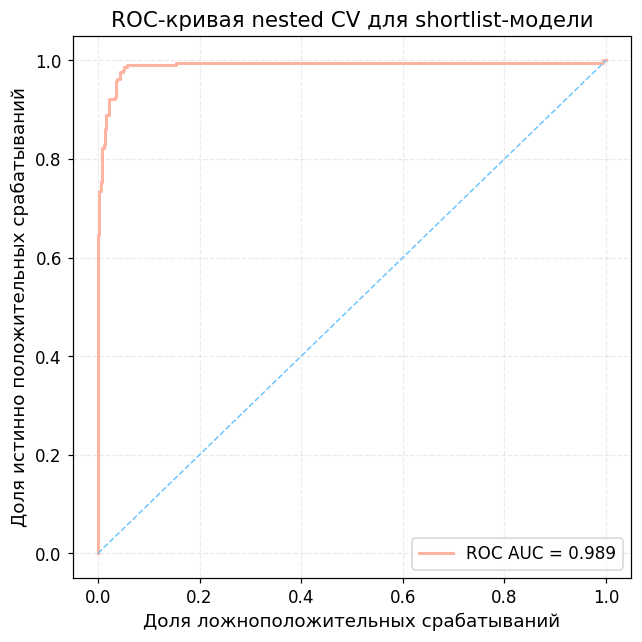

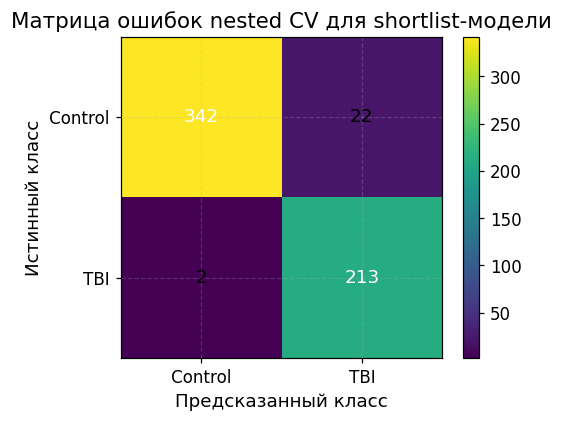

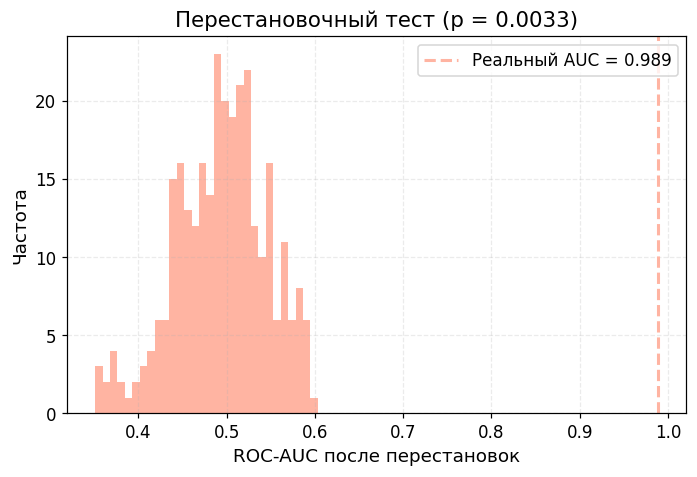

Рисунок ROC: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/figures_final/fig_ml_roc_nested_shortlist.png
Рисунок матрицы ошибок: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/figures_final/fig_ml_confusion_matrix_nested_shortlist.png
Рисунок перестановочного теста: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/figures_final/fig_ml_permutation_hist_shortlist.png


In [ ]:
# @title V.2 Итоговые рисунки основной модели: ROC, матрица ошибок, перестановочный тест


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix


# =========================================================
# 0. Пути
# =========================================================
NESTED_OOF_PATH = OUT_NESTED_OOF
PERM_SCORES_PATH = OUT_PERM_SCORES
PERM_SUMMARY_PATH = OUT_PERM_SUMMARY

OUT_FIG_DIR = OUT_ML_DIR / "figures_final"
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG_ROC = OUT_FIG_DIR / "fig_ml_roc_nested_shortlist.png"
OUT_FIG_CM = OUT_FIG_DIR / "fig_ml_confusion_matrix_nested_shortlist.png"
OUT_FIG_PERM = OUT_FIG_DIR / "fig_ml_permutation_hist_shortlist.png"

assert NESTED_OOF_PATH.exists(), f"Не найден файл: {NESTED_OOF_PATH}"
assert PERM_SCORES_PATH.exists(), f"Не найден файл: {PERM_SCORES_PATH}"
assert PERM_SUMMARY_PATH.exists(), f"Не найден файл: {PERM_SUMMARY_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
df_oof = pd.read_csv(NESTED_OOF_PATH)
df_perm = pd.read_csv(PERM_SCORES_PATH)
df_perm_summary = pd.read_csv(PERM_SUMMARY_PATH)

y_true = df_oof["target"].astype(int).values
y_prob = df_oof["pred_proba_tbi"].astype(float).values
y_pred = df_oof["pred_label"].astype(int).values

real_auc = float(
    df_perm_summary.loc[df_perm_summary["metric"] == "real_roc_auc_oof", "value"].iloc[0]
)
p_perm = float(
    df_perm_summary.loc[df_perm_summary["metric"] == "p_perm", "value"].iloc[0]
)


# =========================================================
# 2. ROC
# =========================================================
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Доля ложноположительных срабатываний")
plt.ylabel("Доля истинно положительных срабатываний")
plt.title("ROC-кривая nested CV для shortlist-модели")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_FIG_ROC, dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 3. Confusion matrix
# =========================================================
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Матрица ошибок nested CV для shortlist-модели")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Control", "TBI"])
plt.yticks(tick_marks, ["Control", "TBI"])
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.savefig(OUT_FIG_CM, dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 4. Permutation histogram
# =========================================================
plt.figure(figsize=(6.5, 4.5))
plt.hist(df_perm["roc_auc_perm"].values, bins=30)
plt.axvline(real_auc, linewidth=2, linestyle="--", label=f"Реальный AUC = {real_auc:.3f}")
plt.xlabel("ROC-AUC после перестановок")
plt.ylabel("Частота")
plt.title(f"Перестановочный тест (p = {p_perm:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG_PERM, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок ROC:", OUT_FIG_ROC)
print("Рисунок матрицы ошибок:", OUT_FIG_CM)
print("Рисунок перестановочного теста:", OUT_FIG_PERM)

In [ ]:
# @title V.3 Итоговая таблица метрик основной модели


from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
NESTED_SUMMARY_PATH = OUT_NESTED_SUMMARY
PERM_SUMMARY_PATH = OUT_PERM_SUMMARY
SENS_SUMMARY_PATH = OUT_SENS_SUMMARY
MODEL_COMPARE_PATH = OUT_MODEL_COMPARE_SUMMARY

OUT_FINAL_METRICS_TEXT = OUT_ML_DIR / "mlprep19_final_metrics_table_for_text.csv"

assert NESTED_SUMMARY_PATH.exists(), f"Не найден файл: {NESTED_SUMMARY_PATH}"
assert PERM_SUMMARY_PATH.exists(), f"Не найден файл: {PERM_SUMMARY_PATH}"
assert SENS_SUMMARY_PATH.exists(), f"Не найден файл: {SENS_SUMMARY_PATH}"
assert MODEL_COMPARE_PATH.exists(), f"Не найден файл: {MODEL_COMPARE_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
df_nested = pd.read_csv(NESTED_SUMMARY_PATH)
df_perm = pd.read_csv(PERM_SUMMARY_PATH)
df_sens = pd.read_csv(SENS_SUMMARY_PATH)
df_models = pd.read_csv(MODEL_COMPARE_PATH)

# nested shortlist
nested_map = dict(zip(df_nested["metric"], df_nested["value"]))
perm_map = dict(zip(df_perm["metric"], df_perm["value"]))
sens_map = dict(zip(df_sens["metric"], df_sens["value"]))

rows = []

rows.append({
    "analysis": "Shortlist logistic nested CV",
    "n_rows": nested_map.get("n_rows"),
    "n_features": nested_map.get("n_features"),
    "roc_auc": nested_map.get("roc_auc_oof"),
    "balanced_accuracy": nested_map.get("balanced_accuracy_oof"),
    "accuracy": nested_map.get("accuracy_oof"),
    "precision": nested_map.get("precision_oof"),
    "recall_sensitivity": nested_map.get("recall_sensitivity_oof"),
    "specificity": nested_map.get("specificity_oof"),
    "f1": nested_map.get("f1_oof"),
    "extra": "",
})

rows.append({
    "analysis": "Permutation test (shortlist logistic)",
    "n_rows": perm_map.get("n_rows"),
    "n_features": perm_map.get("n_features"),
    "roc_auc": perm_map.get("real_roc_auc_oof"),
    "balanced_accuracy": None,
    "accuracy": None,
    "precision": None,
    "recall_sensitivity": None,
    "specificity": None,
    "f1": None,
    "extra": f"p_perm={perm_map.get('p_perm'):.4f}; perm_mean_auc={perm_map.get('perm_mean_auc'):.3f}",
})

rows.append({
    "analysis": "Sensitivity: TBI vs Control EyesClosed",
    "n_rows": sens_map.get("n_rows"),
    "n_features": sens_map.get("n_features"),
    "roc_auc": sens_map.get("roc_auc_oof"),
    "balanced_accuracy": sens_map.get("balanced_accuracy_oof"),
    "accuracy": sens_map.get("accuracy_oof"),
    "precision": sens_map.get("precision_oof"),
    "recall_sensitivity": sens_map.get("recall_sensitivity_oof"),
    "specificity": sens_map.get("specificity_oof"),
    "f1": sens_map.get("f1_oof"),
    "extra": "",
})

# model comparison
for _, row in df_models.iterrows():
    rows.append({
        "analysis": f"Model compare: {row['model_name']}",
        "n_rows": row.get("n_rows"),
        "n_features": row.get("n_features"),
        "roc_auc": row.get("roc_auc_oof"),
        "balanced_accuracy": row.get("balanced_accuracy_oof"),
        "accuracy": row.get("accuracy_oof"),
        "precision": row.get("precision_oof"),
        "recall_sensitivity": row.get("recall_sensitivity_oof"),
        "specificity": row.get("specificity_oof"),
        "f1": row.get("f1_oof"),
        "extra": "",
    })

df_final_metrics = pd.DataFrame(rows)
df_final_metrics.to_csv(OUT_FINAL_METRICS_TEXT, index=False, encoding="utf-8")

print("Итоговая таблица метрик:", OUT_FINAL_METRICS_TEXT)
display(df_final_metrics)

Итоговая таблица метрик: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep19_final_metrics_table_for_text.csv


,analysis,n_rows,n_features,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,extra
0,Shortlist logistic nested CV,579.0,19.0,0.989215,0.965129,0.958549,0.906383,0.990698,0.939560,0.946667,
1,Permutation test (shortlist logistic),579.0,19.0,0.988973,NaN,NaN,NaN,NaN,NaN,NaN,p_perm=0.0033; perm_mean_auc=0.494
2,Sensitivity: TBI vs Control EyesClosed,397.0,19.0,0.986021,0.965334,0.964736,0.976303,0.958140,0.972527,0.967136,
3,Model compare: random_forest,579.0,19.0,0.993432,0.958044,0.956822,0.924107,0.962791,0.953297,0.943052,
4,Model compare: logreg_l2,579.0,19.0,0.991183,0.970624,0.965458,0.922078,0.990698,0.950549,0.955157,
5,Model compare: logreg_elasticnet,579.0,19.0,0.989727,0.969141,0.967185,0.937500,0.976744,0.961538,0.956720,


## VI. Блочный и инкрементальный анализ

Этот раздел показывает, какие блоки признаков обладают самостоятельной прогностической ценностью и какой вклад даёт последовательное добавление новых блоков.


## VI. Блочный и инкрементальный анализ

В этом разделе блоки признаков рассматриваются как самостоятельные источники информации. Сначала оценивается качество моделей, построенных на каждом блоке отдельно, затем проверяется, как меняется качество классификации при последовательном добавлении новых блоков признаков.


### VI.a Логика блочного анализа

Для каждого блока признаков обучается одна и та же модель в одинаковой схеме nested, group-aware cross-validation. Далее блоки сравниваются по следующим показателям:

- число признаков (`n_features`);
- средний AUROC и его стандартное отклонение;
- средняя balanced accuracy и её стандартное отклонение;
- OOF-метрики: AUROC, balanced accuracy, sensitivity и specificity.

Такой формат позволяет отделить блоки с самостоятельной прогностической ценностью от блоков, которые усиливают модель только в комбинации с другими признаками.


In [ ]:
# @title VI.1 Подготовка словаря блоков признаков

from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED

OUT_BLOCK_FEATURE_MAP = OUT_ML_DIR / "mlprep22_block_feature_map.csv"
OUT_BLOCK_FEATURE_COUNTS = OUT_ML_DIR / "mlprep22_block_feature_counts.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
feature_cols = list(Xp.columns)

print("Число признаков в X_pruned:", len(feature_cols))


# =========================================================
# 2. Функция определения блока
# =========================================================
def detect_block(feature_name):
    if "__" in feature_name:
        return feature_name.split("__", 1)[0]
    return "other"


# =========================================================
# 3. Карта признаков
# =========================================================
df_block_map = pd.DataFrame({
    "feature": feature_cols,
    "block": [detect_block(c) for c in feature_cols],
}).sort_values(["block", "feature"]).reset_index(drop=True)

df_block_counts = (
    df_block_map.groupby("block", as_index=False)
    .agg(n_features=("feature", "count"))
    .sort_values(["n_features", "block"], ascending=[False, True])
    .reset_index(drop=True)
)

df_block_map.to_csv(OUT_BLOCK_FEATURE_MAP, index=False, encoding="utf-8")
df_block_counts.to_csv(OUT_BLOCK_FEATURE_COUNTS, index=False, encoding="utf-8")

print("Карта block-feature:", OUT_BLOCK_FEATURE_MAP)
print("Сводка по числу признаков:", OUT_BLOCK_FEATURE_COUNTS)

display(df_block_counts)
display(df_block_map.head(40))

Число признаков в X_pruned: 302
Карта block-feature: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep22_block_feature_map.csv
Сводка по числу признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep22_block_feature_counts.csv


,block,n_features
0,conn,130
1,burst,64
2,bp,29
3,tfr,21
4,aper,19
5,event,11
6,dfa,9
7,spec_shape,7
8,idx,5
9,gamma,4


,feature,block
0,alpha_peak__alpha_peak_db__frontal,alpha_peak
1,alpha_peak__alpha_peak_db__parietal,alpha_peak
2,alpha_peak__alpha_peak_db__temporal,alpha_peak
3,aper__alpha_peak_amp_log10__central,aper
4,aper__alpha_peak_amp_log10__frontal,aper
5,aper__alpha_peak_amp_log10__temporal,aper
6,aper__alpha_peak_cf_hz__central,aper
7,aper__alpha_peak_cf_hz__frontal,aper
8,aper__alpha_peak_cf_hz__occipital,aper
9,aper__alpha_peak_cf_hz__parietal,aper


In [ ]:
# @title VI.2 Блочный nested CV: одна модель на каждый блок


from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY
BLOCK_MAP_PATH = OUT_BLOCK_FEATURE_MAP

OUT_BLOCKWISE_SUMMARY = OUT_ML_DIR / "mlprep23_blockwise_summary.csv"
OUT_BLOCKWISE_FOLDS = OUT_ML_DIR / "mlprep23_blockwise_folds.csv"
OUT_BLOCKWISE_PARAMS = OUT_ML_DIR / "mlprep23_blockwise_params.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert BLOCK_MAP_PATH.exists(), f"Не найден файл: {BLOCK_MAP_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_block_map = pd.read_csv(BLOCK_MAP_PATH)

assert len(Xp) == len(meta), "X и metadata имеют разное число строк"

# Блоки в желаемом порядке
preferred_order = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
    "tfr",
]

blocks_present = df_block_map["block"].astype(str).unique().tolist()

# Сохраняем только те, что реально есть
block_order = [b for b in preferred_order if b in blocks_present]

# Если есть неожиданные блоки — добавим в конец
other_blocks = [b for b in blocks_present if b not in block_order]
block_order.extend(sorted(other_blocks))

print("Блоки для анализа:")
print(block_order)


# =========================================================
# 2. Запуск nested CV по блокам
# =========================================================
summary_rows = []
fold_rows_all = []
params_rows_all = []

for block_name in block_order:
    feats = df_block_map.loc[df_block_map["block"] == block_name, "feature"].astype(str).tolist()

    # Пропускаем пустые блоки
    if len(feats) == 0:
        continue

    X_block = Xp[feats].copy()

    print(f"\n=== Блок: {block_name} | n_features = {len(feats)} ===")

    df_summary_b, df_fold_b, df_params_b, df_oof_b = run_nested_group_cv(
        X_df=X_block,
        meta_df=meta,
        model_name="logreg_l2",
        n_outer=5,
        n_inner=3,
        random_state=42,
    )

    # Переводим summary в wide-форму для одной строки на блок
    summary_map = dict(zip(df_summary_b["metric"], df_summary_b["value"]))

    summary_rows.append({
        "block": block_name,
        "n_features": len(feats),
        "roc_auc_oof": summary_map.get("roc_auc_oof"),
        "bal_acc_oof": summary_map.get("balanced_accuracy_oof"),
        "accuracy_oof": summary_map.get("accuracy_oof"),
        "precision_oof": summary_map.get("precision_oof"),
        "recall_sensitivity_oof": summary_map.get("recall_sensitivity_oof"),
        "specificity_oof": summary_map.get("specificity_oof"),
        "f1_oof": summary_map.get("f1_oof"),
        "AUROC_mean": summary_map.get("roc_auc_mean_folds"),
        "AUROC_sd": summary_map.get("roc_auc_std_folds"),
        "bal_acc_mean": summary_map.get("balanced_accuracy_mean_folds"),
        "bal_acc_sd": summary_map.get("balanced_accuracy_std_folds"),
    })

    df_fold_b["block"] = block_name
    df_params_b["block"] = block_name

    fold_rows_all.append(df_fold_b)
    params_rows_all.append(df_params_b)

df_blockwise_summary = pd.DataFrame(summary_rows).sort_values(
    ["AUROC_mean", "bal_acc_mean"],
    ascending=[False, False]
).reset_index(drop=True)

df_blockwise_folds = pd.concat(fold_rows_all, ignore_index=True) if len(fold_rows_all) > 0 else pd.DataFrame()
df_blockwise_params = pd.concat(params_rows_all, ignore_index=True) if len(params_rows_all) > 0 else pd.DataFrame()

df_blockwise_summary.to_csv(OUT_BLOCKWISE_SUMMARY, index=False, encoding="utf-8")
df_blockwise_folds.to_csv(OUT_BLOCKWISE_FOLDS, index=False, encoding="utf-8")
df_blockwise_params.to_csv(OUT_BLOCKWISE_PARAMS, index=False, encoding="utf-8")

print("\n✅ Block-wise анализ завершён")
print("Summary:", OUT_BLOCKWISE_SUMMARY)
print("Folds:", OUT_BLOCKWISE_FOLDS)
print("Params:", OUT_BLOCKWISE_PARAMS)

display(df_blockwise_summary)
display(df_blockwise_folds.head(30))
display(df_blockwise_params.head(30))

Блоки для анализа:
['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa', 'burst', 'conn', 'event', 'tfr']

=== Блок: bp | n_features = 29 ===

=== Блок: idx | n_features = 5 ===

=== Блок: spec_shape | n_features = 7 ===

=== Блок: aper | n_features = 19 ===

=== Блок: alpha_peak | n_features = 3 ===

=== Блок: gamma | n_features = 4 ===

=== Блок: dfa | n_features = 9 ===

=== Блок: burst | n_features = 64 ===

=== Блок: conn | n_features = 130 ===

=== Блок: event | n_features = 11 ===

=== Блок: tfr | n_features = 21 ===

✅ Block-wise анализ завершён
Summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep23_blockwise_summary.csv
Folds: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep23_blockwise_folds.csv
Params: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep23_blockwise_params.csv


,block,n_features,roc_auc_oof,bal_acc_oof,accuracy_oof,precision_oof,recall_sensitivity_oof,specificity_oof,f1_oof,AUROC_mean,AUROC_sd,bal_acc_mean,bal_acc_sd
0,burst,64,0.991592,0.979287,0.977547,0.954955,0.986047,0.972527,0.970252,0.994518,0.011403,0.979866,0.015900
1,event,11,0.949029,0.895470,0.903282,0.873239,0.865116,0.925824,0.869159,0.945880,0.023667,0.895246,0.045352
2,conn,130,0.891835,0.825728,0.820380,0.719368,0.846512,0.804945,0.777778,0.895339,0.039177,0.824855,0.038979
3,bp,29,0.832162,0.761998,0.758204,0.644788,0.776744,0.747253,0.704641,0.840258,0.070674,0.758549,0.084477
4,aper,19,0.792525,0.733370,0.715026,0.584459,0.804651,0.662088,0.677104,0.799918,0.083177,0.726885,0.066464
5,spec_shape,7,0.761845,0.703028,0.696028,0.570909,0.730233,0.675824,0.640816,0.761968,0.048130,0.702321,0.057981
6,tfr,21,0.753143,0.680437,0.642487,0.511494,0.827907,0.532967,0.632327,0.753537,0.061188,0.680379,0.067034
7,dfa,9,0.714477,0.676182,0.671848,0.545788,0.693023,0.659341,0.610656,0.715571,0.024200,0.675438,0.044998
8,idx,5,0.694275,0.645949,0.649396,0.523077,0.632558,0.659341,0.572632,0.706970,0.053479,0.636801,0.030541
9,alpha_peak,3,0.696588,0.654191,0.659758,0.535433,0.632558,0.675824,0.579957,0.695982,0.098332,0.652241,0.090845


,fold,model_name,n_train,n_test,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp,block
0,1,logreg_l2,456,123,0.845058,0.797093,0.813008,0.727273,0.744186,0.850000,0.735632,68,12,11,32,bp
1,2,logreg_l2,455,124,0.761905,0.673810,0.717742,0.564103,0.550000,0.797619,0.556962,67,17,18,22,bp
2,3,logreg_l2,468,111,0.789330,0.690663,0.657658,0.537313,0.837209,0.544118,0.654545,37,31,7,36,bp
3,4,logreg_l2,476,103,0.944186,0.881783,0.873786,0.800000,0.930233,0.833333,0.860215,50,10,3,40,bp
4,5,logreg_l2,461,118,0.860809,0.749396,0.737288,0.627119,0.804348,0.694444,0.704762,50,22,9,37,bp
5,1,logreg_l2,456,123,0.717442,0.640552,0.707317,0.620690,0.418605,0.862500,0.500000,69,11,25,18,idx
6,2,logreg_l2,455,124,0.763690,0.648810,0.701613,0.540541,0.500000,0.797619,0.519481,67,17,20,20,idx
7,3,logreg_l2,468,111,0.618331,0.583447,0.531532,0.443038,0.813953,0.352941,0.573770,24,44,8,35,idx
8,4,logreg_l2,476,103,0.721318,0.658721,0.640777,0.550000,0.767442,0.550000,0.640777,33,27,10,33,idx
9,5,logreg_l2,461,118,0.714070,0.652476,0.652542,0.545455,0.652174,0.652778,0.594059,47,25,16,30,idx


,fold,model_name,best_inner_cv_score,clf__C,clf__penalty,block
0,1,logreg_l2,0.802988,10.00,l2,bp
1,2,logreg_l2,0.872072,10.00,l2,bp
2,3,logreg_l2,0.805891,10.00,l2,bp
3,4,logreg_l2,0.774429,10.00,l2,bp
4,5,logreg_l2,0.800339,10.00,l2,bp
5,1,logreg_l2,0.701498,0.01,l2,idx
6,2,logreg_l2,0.698339,10.00,l2,idx
7,3,logreg_l2,0.690885,10.00,l2,idx
8,4,logreg_l2,0.729240,5.00,l2,idx
9,5,logreg_l2,0.679766,0.50,l2,idx


In [ ]:
# @title VI.3 Итоговая таблица блочного анализа

from pathlib import Path
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
BLOCKWISE_SUMMARY_PATH = OUT_BLOCKWISE_SUMMARY
OUT_BLOCKWISE_TEXT_TABLE = OUT_ML_DIR / "mlprep24_blockwise_table_for_text.csv"

assert BLOCKWISE_SUMMARY_PATH.exists(), f"Не найден файл: {BLOCKWISE_SUMMARY_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
df_block = pd.read_csv(BLOCKWISE_SUMMARY_PATH)

# Переименуем колонки под удобный итоговый формат
df_text = df_block[[
    "block",
    "n_features",
    "AUROC_mean",
    "AUROC_sd",
    "bal_acc_mean",
    "bal_acc_sd",
    "roc_auc_oof",
    "bal_acc_oof",
    "recall_sensitivity_oof",
    "specificity_oof",
]].copy()

df_text = df_text.sort_values(
    ["AUROC_mean", "bal_acc_mean"],
    ascending=[False, False]
).reset_index(drop=True)

df_text.to_csv(OUT_BLOCKWISE_TEXT_TABLE, index=False, encoding="utf-8")

print("Итоговая таблица для текста:", OUT_BLOCKWISE_TEXT_TABLE)
display(df_text)

Итоговая таблица для текста: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep24_blockwise_table_for_text.csv


,block,n_features,AUROC_mean,AUROC_sd,bal_acc_mean,bal_acc_sd,roc_auc_oof,bal_acc_oof,recall_sensitivity_oof,specificity_oof
0,burst,64,0.994518,0.011403,0.979866,0.015900,0.991592,0.979287,0.986047,0.972527
1,event,11,0.945880,0.023667,0.895246,0.045352,0.949029,0.895470,0.865116,0.925824
2,conn,130,0.895339,0.039177,0.824855,0.038979,0.891835,0.825728,0.846512,0.804945
3,bp,29,0.840258,0.070674,0.758549,0.084477,0.832162,0.761998,0.776744,0.747253
4,aper,19,0.799918,0.083177,0.726885,0.066464,0.792525,0.733370,0.804651,0.662088
5,spec_shape,7,0.761968,0.048130,0.702321,0.057981,0.761845,0.703028,0.730233,0.675824
6,tfr,21,0.753537,0.061188,0.680379,0.067034,0.753143,0.680437,0.827907,0.532967
7,dfa,9,0.715571,0.024200,0.675438,0.044998,0.714477,0.676182,0.693023,0.659341
8,idx,5,0.706970,0.053479,0.636801,0.030541,0.694275,0.645949,0.632558,0.659341
9,alpha_peak,3,0.695982,0.098332,0.652241,0.090845,0.696588,0.654191,0.632558,0.675824


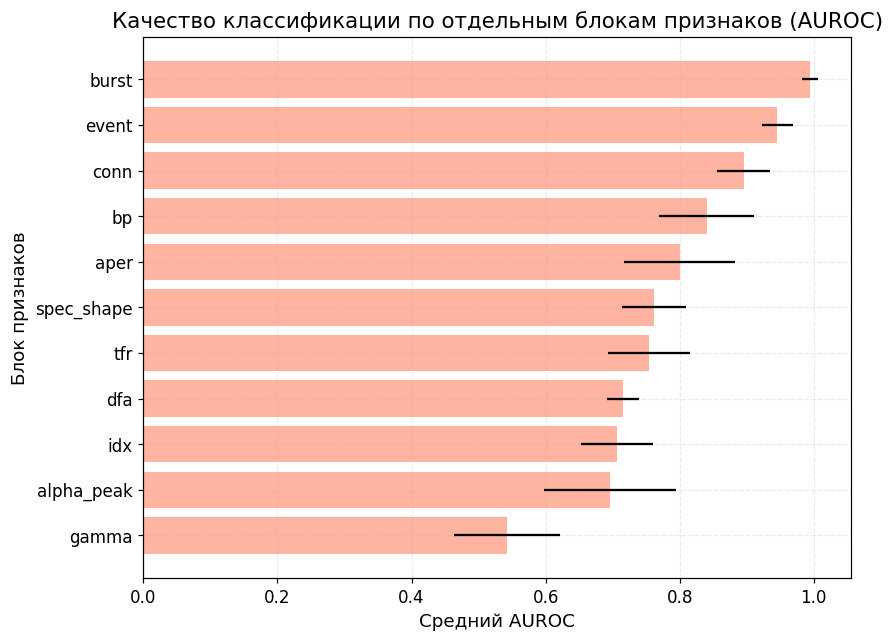

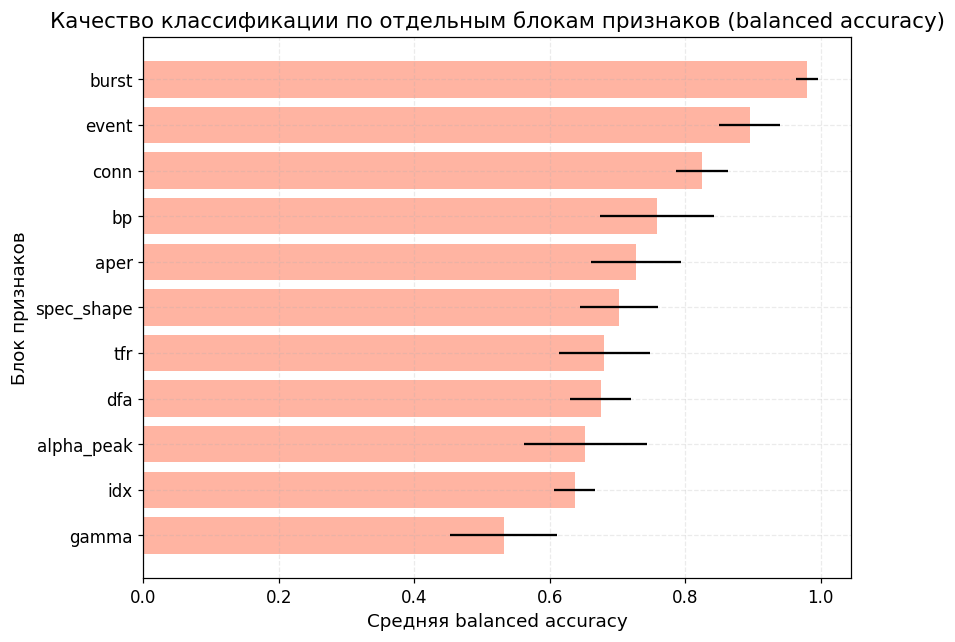

Рисунок AUROC: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_blockwise_auc.png
Рисунок balanced accuracy: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_blockwise_balacc.png


In [ ]:
# @title VI.4 Рисунки блочного анализа: AUROC и balanced accuracy


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. Пути
# =========================================================
BLOCKWISE_TEXT_TABLE_PATH = OUT_BLOCKWISE_TEXT_TABLE

OUT_FIG_BLOCKWISE_AUC = OUT_ML_DIR / "fig_blockwise_auc.png"
OUT_FIG_BLOCKWISE_BALACC = OUT_ML_DIR / "fig_blockwise_balacc.png"

assert BLOCKWISE_TEXT_TABLE_PATH.exists(), f"Не найден файл: {BLOCKWISE_TEXT_TABLE_PATH}"


# =========================================================
# 1. Загрузка
# =========================================================
dfb = pd.read_csv(BLOCKWISE_TEXT_TABLE_PATH)

# Для красоты: сортируем по AUROC_mean
df_auc = dfb.sort_values("AUROC_mean", ascending=True).reset_index(drop=True)
df_bal = dfb.sort_values("bal_acc_mean", ascending=True).reset_index(drop=True)


# =========================================================
# 2. AUROC figure
# =========================================================
plt.figure(figsize=(8, 6))
plt.barh(df_auc["block"], df_auc["AUROC_mean"], xerr=df_auc["AUROC_sd"])
plt.xlabel("Средний AUROC")
plt.ylabel("Блок признаков")
plt.title("Качество классификации по отдельным блокам признаков (AUROC)")
plt.tight_layout()
plt.savefig(OUT_FIG_BLOCKWISE_AUC, dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 3. Balanced accuracy figure
# =========================================================
plt.figure(figsize=(8, 6))
plt.barh(df_bal["block"], df_bal["bal_acc_mean"], xerr=df_bal["bal_acc_sd"])
plt.xlabel("Средняя balanced accuracy")
plt.ylabel("Блок признаков")
plt.title("Качество классификации по отдельным блокам признаков (balanced accuracy)")
plt.tight_layout()
plt.savefig(OUT_FIG_BLOCKWISE_BALACC, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок AUROC:", OUT_FIG_BLOCKWISE_AUC)
print("Рисунок balanced accuracy:", OUT_FIG_BLOCKWISE_BALACC)

### VI.b Логика инкрементальных моделей

Инкрементальные модели собираются по принципу последовательного наращивания набора признаков.

Рекомендуемая логика:

- **Модель A** — `bp + idx`;
- **Модель B** — `A + spec_shape`;
- **Модель C** — `B + aper + alpha_peak + gamma`;
- **Модель D** — `C + dfa + burst`;
- **Модель E** — `D + conn`;
- **Модель F** — `E + event`;
- **Модель G** — `F + event_context` (если блок `event_context` подготовлен).

Это позволяет показать, какие блоки дают наибольший прирост качества и на каком этапе прирост начинает насыщаться.


In [ ]:
# @title VI.5 Инкрементальные модели (по одному блоку на шаг)


from pathlib import Path
import string
import pandas as pd


# =========================================================
# 0. Пути
# =========================================================
X_PRUNED_PATH = OUT_X_PRUNED
GROUPS_READY_PATH = OUT_GROUPS_READY
BLOCK_MAP_PATH = OUT_BLOCK_FEATURE_MAP

OUT_INCREMENTAL_SUMMARY = OUT_ML_DIR / "mlprep26_incremental_summary.csv"
OUT_INCREMENTAL_FOLDS = OUT_ML_DIR / "mlprep26_incremental_folds.csv"
OUT_INCREMENTAL_PARAMS = OUT_ML_DIR / "mlprep26_incremental_params.csv"
OUT_INCREMENTAL_FEATURES = OUT_ML_DIR / "mlprep26_incremental_feature_sets.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert BLOCK_MAP_PATH.exists(), f"Не найден файл: {BLOCK_MAP_PATH}"


# =========================================================
# 1. Загрузка данных
# =========================================================
Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_block_map = pd.read_csv(BLOCK_MAP_PATH)

block_to_features = (
    df_block_map.groupby("block")["feature"]
    .apply(list)
    .to_dict()
)


# =========================================================
# 2. Порядок добавления блоков
#    Каждый следующий шаг добавляет РОВНО ОДИН блок
# =========================================================
ordered_blocks = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
]

# Оставляем только те блоки, которые реально есть в block_map
available_blocks = [b for b in ordered_blocks if b in block_to_features]

assert len(available_blocks) > 0, "Не найдено ни одного блока из ordered_blocks в block_map."

print("Доступные блоки в порядке добавления:")
for i, block_name in enumerate(available_blocks, start=1):
    print(f"{i:02d}. {block_name}")


# =========================================================
# 3. Формирование инкрементальных моделей
#    A = 1 блок
#    B = 2 блока
#    C = 3 блока
#    ...
# =========================================================
letters = list(string.ascii_uppercase)
assert len(available_blocks) <= len(letters), "Слишком много блоков для буквенной нотации."

incremental_defs = {}
for i in range(len(available_blocks)):
    model_name = letters[i]
    incremental_defs[model_name] = available_blocks[: i + 1]

print("\nИспользуемые инкрементальные модели:")
for model_name, blocks in incremental_defs.items():
    added_block = blocks[-1]
    print(f"{model_name} -> {blocks} | новый блок: {added_block}")


# =========================================================
# 4. Запуск nested CV для каждой модели
# =========================================================
summary_rows = []
fold_all = []
params_all = []
feature_rows = []

prev_auc = None
prev_bal = None
prev_n_features = None

for model_name, blocks in incremental_defs.items():
    # Блок, который добавился именно на этом шаге
    added_block = blocks[-1]

    # Собираем список признаков из всех включённых блоков
    feats = []
    for block_name in blocks:
        feats.extend(block_to_features.get(block_name, []))

    # Убираем дубли, оставляем только существующие колонки
    feats = sorted(set(feats))
    feats = [f for f in feats if f in Xp.columns]

    if len(feats) == 0:
        print(f"\n[Пропуск] Модель {model_name}: после фильтрации нет признаков.")
        continue

    X_sub = Xp[feats].copy()

    print(
        f"\n=== Инкрементальная модель {model_name} "
        f"| добавлен блок: {added_block} "
        f"| n_features = {len(feats)} ==="
    )

    df_summary_m, df_fold_m, df_params_m, df_oof_m = run_nested_group_cv(
        X_df=X_sub,
        meta_df=meta,
        model_name="logreg_l2",
        n_outer=5,
        n_inner=3,
        random_state=42,
    )

    summary_map = dict(zip(df_summary_m["metric"], df_summary_m["value"]))

    auc_mean = summary_map.get("roc_auc_mean_folds")
    bal_mean = summary_map.get("balanced_accuracy_mean_folds")

    n_features_now = len(feats)

    summary_rows.append({
        "model": model_name,
        "added_block": added_block,
        "included_blocks": "+".join(blocks),
        "n_blocks": len(blocks),
        "n_features": n_features_now,
        "delta_n_features_vs_prev": (
            None if prev_n_features is None else (n_features_now - prev_n_features)
        ),
        "roc_auc_oof": summary_map.get("roc_auc_oof"),
        "bal_acc_oof": summary_map.get("balanced_accuracy_oof"),
        "AUROC_mean": auc_mean,
        "AUROC_sd": summary_map.get("roc_auc_std_folds"),
        "bal_acc_mean": bal_mean,
        "bal_acc_sd": summary_map.get("balanced_accuracy_std_folds"),
        "delta_AUROC_vs_prev": (
            None if prev_auc is None or auc_mean is None else (auc_mean - prev_auc)
        ),
        "delta_bal_acc_vs_prev": (
            None if prev_bal is None or bal_mean is None else (bal_mean - prev_bal)
        ),
    })

    prev_auc = auc_mean
    prev_bal = bal_mean
    prev_n_features = n_features_now

    df_fold_m = df_fold_m.copy()
    df_fold_m["incremental_model"] = model_name
    df_fold_m["added_block"] = added_block
    df_fold_m["included_blocks"] = "+".join(blocks)
    fold_all.append(df_fold_m)

    df_params_m = df_params_m.copy()
    df_params_m["incremental_model"] = model_name
    df_params_m["added_block"] = added_block
    df_params_m["included_blocks"] = "+".join(blocks)
    params_all.append(df_params_m)

    for feature_name in feats:
        feature_rows.append({
            "model": model_name,
            "added_block": added_block,
            "included_blocks": "+".join(blocks),
            "feature": feature_name,
        })


# =========================================================
# 5. Сбор и сохранение результатов
# =========================================================
df_incremental_summary = pd.DataFrame(summary_rows)
df_incremental_folds = (
    pd.concat(fold_all, ignore_index=True) if len(fold_all) > 0 else pd.DataFrame()
)
df_incremental_params = (
    pd.concat(params_all, ignore_index=True) if len(params_all) > 0 else pd.DataFrame()
)
df_incremental_features = pd.DataFrame(feature_rows)

df_incremental_summary.to_csv(OUT_INCREMENTAL_SUMMARY, index=False, encoding="utf-8")
df_incremental_folds.to_csv(OUT_INCREMENTAL_FOLDS, index=False, encoding="utf-8")
df_incremental_params.to_csv(OUT_INCREMENTAL_PARAMS, index=False, encoding="utf-8")
df_incremental_features.to_csv(OUT_INCREMENTAL_FEATURES, index=False, encoding="utf-8")

print("\n✅ Инкрементальные модели завершены")
print("Summary:", OUT_INCREMENTAL_SUMMARY)
print("Folds:", OUT_INCREMENTAL_FOLDS)
print("Params:", OUT_INCREMENTAL_PARAMS)
print("Features:", OUT_INCREMENTAL_FEATURES)

display(df_incremental_summary)
display(df_incremental_folds.head(30))
display(df_incremental_params.head(30))

Доступные блоки в порядке добавления:
01. bp
02. idx
03. spec_shape
04. aper
05. alpha_peak
06. gamma
07. dfa
08. burst
09. conn
10. event

Используемые инкрементальные модели:
A -> ['bp'] | новый блок: bp
B -> ['bp', 'idx'] | новый блок: idx
C -> ['bp', 'idx', 'spec_shape'] | новый блок: spec_shape
D -> ['bp', 'idx', 'spec_shape', 'aper'] | новый блок: aper
E -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak'] | новый блок: alpha_peak
F -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma'] | новый блок: gamma
G -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa'] | новый блок: dfa
H -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa', 'burst'] | новый блок: burst
I -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa', 'burst', 'conn'] | новый блок: conn
J -> ['bp', 'idx', 'spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa', 'burst', 'conn', 'event'] | новый блок: event

=== Инкрементальная модель A | добавлен блок: bp | n_features

,model,added_block,included_blocks,n_blocks,n_features,delta_n_features_vs_prev,roc_auc_oof,bal_acc_oof,AUROC_mean,AUROC_sd,bal_acc_mean,bal_acc_sd,delta_AUROC_vs_prev,delta_bal_acc_vs_prev
0,A,bp,bp,1,29,NaN,0.832162,0.761998,0.840258,0.070674,0.758549,0.084477,NaN,NaN
1,B,idx,bp+idx,2,34,5.0,0.856287,0.775735,0.866801,0.037553,0.770877,0.058342,0.026543,0.012328
2,C,spec_shape,bp+idx+spec_shape,3,41,7.0,0.854856,0.774252,0.864219,0.046062,0.771056,0.074118,-0.002582,0.000179
3,D,aper,bp+idx+spec_shape+aper,4,60,19.0,0.870866,0.792327,0.884059,0.052313,0.789605,0.075251,0.019840,0.018549
4,E,alpha_peak,bp+idx+spec_shape+aper+alpha_peak,5,63,3.0,0.885012,0.809871,0.894407,0.057608,0.808029,0.070670,0.010348,0.018424
5,F,gamma,bp+idx+spec_shape+aper+alpha_peak+gamma,6,67,4.0,0.884960,0.814413,0.891838,0.048052,0.812366,0.076302,-0.002568,0.004336
6,G,dfa,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa,7,76,9.0,0.895694,0.832379,0.905963,0.043553,0.831796,0.081295,0.014124,0.019430
7,H,burst,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+burst,8,140,64.0,0.995259,0.978335,0.997565,0.002991,0.978837,0.016027,0.091602,0.147041
8,I,conn,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,9,270,130.0,0.993547,0.980239,0.993246,0.006658,0.980155,0.006375,-0.004319,0.001318
9,J,event,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,10,281,11.0,0.993713,0.987107,0.992144,0.009445,0.986841,0.004620,-0.001102,0.006687


,fold,model_name,n_train,n_test,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp,incremental_model,added_block,included_blocks
0,1,logreg_l2,456,123,0.845058,0.797093,0.813008,0.727273,0.744186,0.850000,0.735632,68,12,11,32,A,bp,bp
1,2,logreg_l2,455,124,0.761905,0.673810,0.717742,0.564103,0.550000,0.797619,0.556962,67,17,18,22,A,bp,bp
2,3,logreg_l2,468,111,0.789330,0.690663,0.657658,0.537313,0.837209,0.544118,0.654545,37,31,7,36,A,bp,bp
3,4,logreg_l2,476,103,0.944186,0.881783,0.873786,0.800000,0.930233,0.833333,0.860215,50,10,3,40,A,bp,bp
4,5,logreg_l2,461,118,0.860809,0.749396,0.737288,0.627119,0.804348,0.694444,0.704762,50,22,9,37,A,bp,bp
5,1,logreg_l2,456,123,0.881395,0.762209,0.788618,0.707317,0.674419,0.850000,0.690476,68,12,14,29,B,idx,bp+idx
6,2,logreg_l2,455,124,0.845238,0.752976,0.798387,0.714286,0.625000,0.880952,0.666667,74,10,15,25,B,idx,bp+idx
7,3,logreg_l2,468,111,0.816347,0.693741,0.666667,0.546875,0.813953,0.573529,0.654206,39,29,8,35,B,idx,bp+idx
8,4,logreg_l2,476,103,0.915116,0.853488,0.844660,0.764706,0.906977,0.800000,0.829787,48,12,4,39,B,idx,bp+idx
9,5,logreg_l2,461,118,0.875906,0.791969,0.779661,0.672414,0.847826,0.736111,0.750000,53,19,7,39,B,idx,bp+idx


,fold,model_name,best_inner_cv_score,clf__C,clf__penalty,incremental_model,added_block,included_blocks
0,1,logreg_l2,0.802988,10.00,l2,A,bp,bp
1,2,logreg_l2,0.872072,10.00,l2,A,bp,bp
2,3,logreg_l2,0.805891,10.00,l2,A,bp,bp
3,4,logreg_l2,0.774429,10.00,l2,A,bp,bp
4,5,logreg_l2,0.800339,10.00,l2,A,bp,bp
5,1,logreg_l2,0.823542,5.00,l2,B,idx,bp+idx
6,2,logreg_l2,0.881843,10.00,l2,B,idx,bp+idx
7,3,logreg_l2,0.853349,10.00,l2,B,idx,bp+idx
8,4,logreg_l2,0.820703,0.50,l2,B,idx,bp+idx
9,5,logreg_l2,0.842042,10.00,l2,B,idx,bp+idx


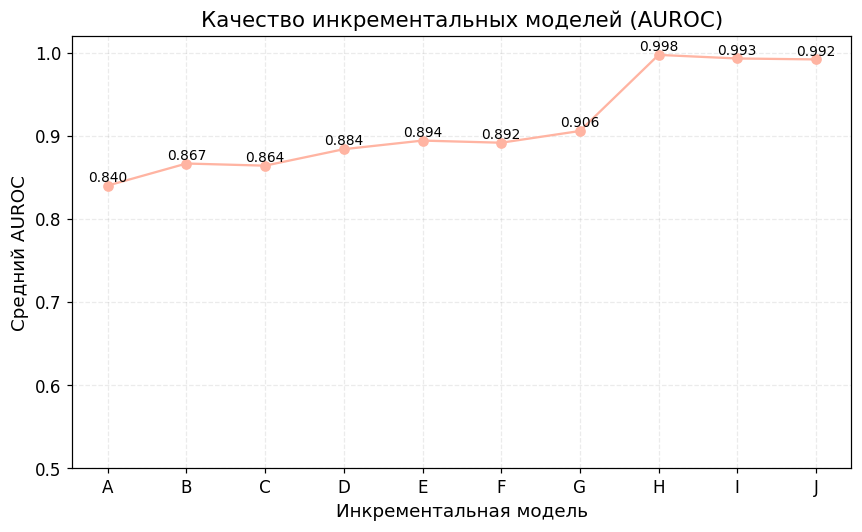

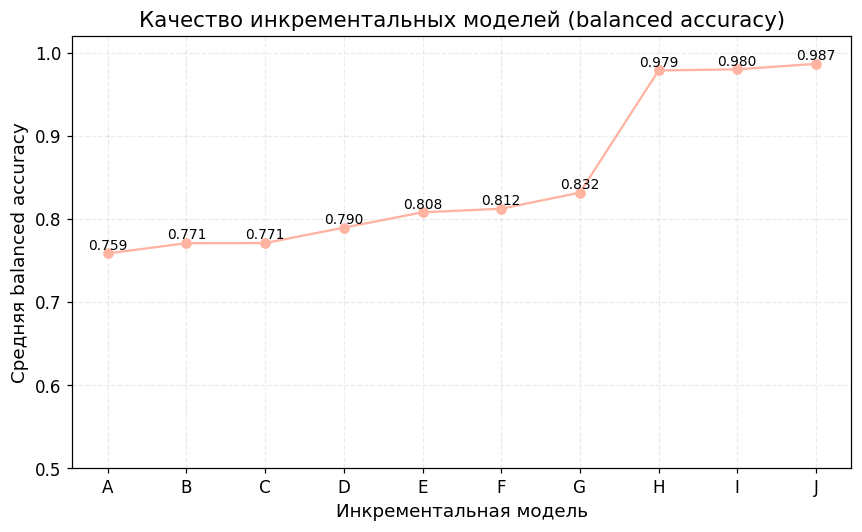

Рисунок AUROC для инкрементальных моделей: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_incremental_auc.png
Рисунок balanced accuracy для инкрементальных моделей: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_incremental_balacc.png


In [ ]:
# @title VI.6 Рисунок инкрементальных моделей


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


OUT_FIG_INCREMENTAL_AUC = OUT_ML_DIR / "fig_incremental_auc.png"
OUT_FIG_INCREMENTAL_BALACC = OUT_ML_DIR / "fig_incremental_balacc.png"

assert OUT_INCREMENTAL_SUMMARY.exists(), f"Не найден файл: {OUT_INCREMENTAL_SUMMARY}"

df_inc = pd.read_csv(OUT_INCREMENTAL_SUMMARY)

# Сохраняем порядок A->G
df_inc["order"] = df_inc["model"].map({m: i for i, m in enumerate(sorted(df_inc["model"].unique()), start=1)})
df_inc = df_inc.sort_values("order").reset_index(drop=True)

# AUROC
plt.figure(figsize=(8, 5))
plt.plot(df_inc["model"], df_inc["AUROC_mean"], marker="o")
for i, row in df_inc.iterrows():
    plt.text(i, row["AUROC_mean"] + 0.005, f"{row['AUROC_mean']:.3f}", ha="center", fontsize=9)
plt.ylim(0.5, 1.02)
plt.xlabel("Инкрементальная модель")
plt.ylabel("Средний AUROC")
plt.title("Качество инкрементальных моделей (AUROC)")
plt.tight_layout()
plt.savefig(OUT_FIG_INCREMENTAL_AUC, dpi=300, bbox_inches="tight")
plt.show()

# Balanced accuracy
plt.figure(figsize=(8, 5))
plt.plot(df_inc["model"], df_inc["bal_acc_mean"], marker="o")
for i, row in df_inc.iterrows():
    plt.text(i, row["bal_acc_mean"] + 0.005, f"{row['bal_acc_mean']:.3f}", ha="center", fontsize=9)
plt.ylim(0.5, 1.02)
plt.xlabel("Инкрементальная модель")
plt.ylabel("Средняя balanced accuracy")
plt.title("Качество инкрементальных моделей (balanced accuracy)")
plt.tight_layout()
plt.savefig(OUT_FIG_INCREMENTAL_BALACC, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок AUROC для инкрементальных моделей:", OUT_FIG_INCREMENTAL_AUC)
print("Рисунок balanced accuracy для инкрементальных моделей:", OUT_FIG_INCREMENTAL_BALACC)

## VII. Вклад признаков и дополнительные sensitivity-анализы

Здесь оцениваются permutation importance, доверительные интервалы bootstrap и устойчивость модели после исключения отдельных блоков.


In [ ]:
# @title VII.1 Permutation importance на внешних test-folds

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score


OUT_PI_LONG = OUT_ML_DIR / "mlprep28_permutation_importance_long.csv"
OUT_PI_MEAN = OUT_ML_DIR / "mlprep28_permutation_importance_mean.csv"
OUT_PI_BLOCK = OUT_ML_DIR / "mlprep28_permutation_importance_by_block.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"
assert OUT_BLOCK_FEATURE_MAP.exists(), f"Не найден файл: {OUT_BLOCK_FEATURE_MAP}"

Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)
df_block_map = pd.read_csv(OUT_BLOCK_FEATURE_MAP)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]
X_short = Xp[shortlist_present].copy()

y_bin = meta["target"].astype(int).values
groups_all = meta["subject_id"].astype(str).values

block_map = dict(zip(df_block_map["feature"], df_block_map["block"]))

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42,
    )),
])

param_grid = {
    "clf__penalty": ["l2"],
    "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

rows = []

for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_short, y_bin, groups=groups_all), start=1):
    X_tr = X_short.iloc[tr_idx].copy()
    X_te = X_short.iloc[te_idx].copy()
    y_tr = y_bin[tr_idx]
    y_te = y_bin[te_idx]
    groups_tr = groups_all[tr_idx]

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    grid.fit(X_tr, y_tr, groups=groups_tr)
    best_model = grid.best_estimator_

    pi = permutation_importance(
        estimator=best_model,
        X=X_te,
        y=y_te,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    for feat, imp_mean, imp_std in zip(X_short.columns, pi.importances_mean, pi.importances_std):
        rows.append({
            "fold": fold_idx,
            "feature": feat,
            "block": block_map.get(feat, "other"),
            "importance_mean": float(imp_mean),
            "importance_sd": float(imp_std),
        })

df_pi_long = pd.DataFrame(rows)

df_pi_mean = (
    df_pi_long.groupby("feature", as_index=False)
    .agg(
        block=("block", "first"),
        importance_mean=("importance_mean", "mean"),
        importance_sd=("importance_mean", "std"),
        importance_mean_inner_sd=("importance_sd", "mean"),
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

df_pi_block = (
    df_pi_mean.groupby("block", as_index=False)
    .agg(total_importance=("importance_mean", "sum"))
    .sort_values("total_importance", ascending=False)
    .reset_index(drop=True)
)

df_pi_long.to_csv(OUT_PI_LONG, index=False, encoding="utf-8")
df_pi_mean.to_csv(OUT_PI_MEAN, index=False, encoding="utf-8")
df_pi_block.to_csv(OUT_PI_BLOCK, index=False, encoding="utf-8")

print("Permutation importance long:", OUT_PI_LONG)
print("Permutation importance mean:", OUT_PI_MEAN)
print("Permutation importance by block:", OUT_PI_BLOCK)

display(df_pi_mean.head(20))
display(df_pi_block)

Permutation importance long: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep28_permutation_importance_long.csv
Permutation importance mean: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep28_permutation_importance_mean.csv
Permutation importance by block: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep28_permutation_importance_by_block.csv


,feature,block,importance_mean,importance_sd,importance_mean_inner_sd
0,event__z_peak,event,0.009012,0.008185,0.005549
1,burst__n_bursts__frontal_beta,burst,0.006174,0.006278,0.002871
2,burst__n_bursts__parietal_beta,burst,0.003038,0.003070,0.001807
3,spec_shape__sef95_hz__central,spec_shape,0.002725,0.005746,0.001057
4,bp__bandpower_rel__temporal_gamma,bp,0.001716,0.003862,0.000888
5,burst__n_bursts__temporal_beta,burst,0.001182,0.000434,0.001651
6,event__propagation_ms,event,0.000838,0.000754,0.001227
7,conn__clustering__plv_theta,conn,0.000739,0.000986,0.001028
8,burst__n_bursts__central_beta,burst,0.000473,0.000789,0.001267
9,event__duration_sec,event,0.000346,0.001078,0.000601


,block,total_importance
0,burst,0.010902
1,event,0.010495
2,spec_shape,0.003050
3,bp,0.001573
4,conn,0.000965
5,dfa,-0.000581
6,aper,-0.001662


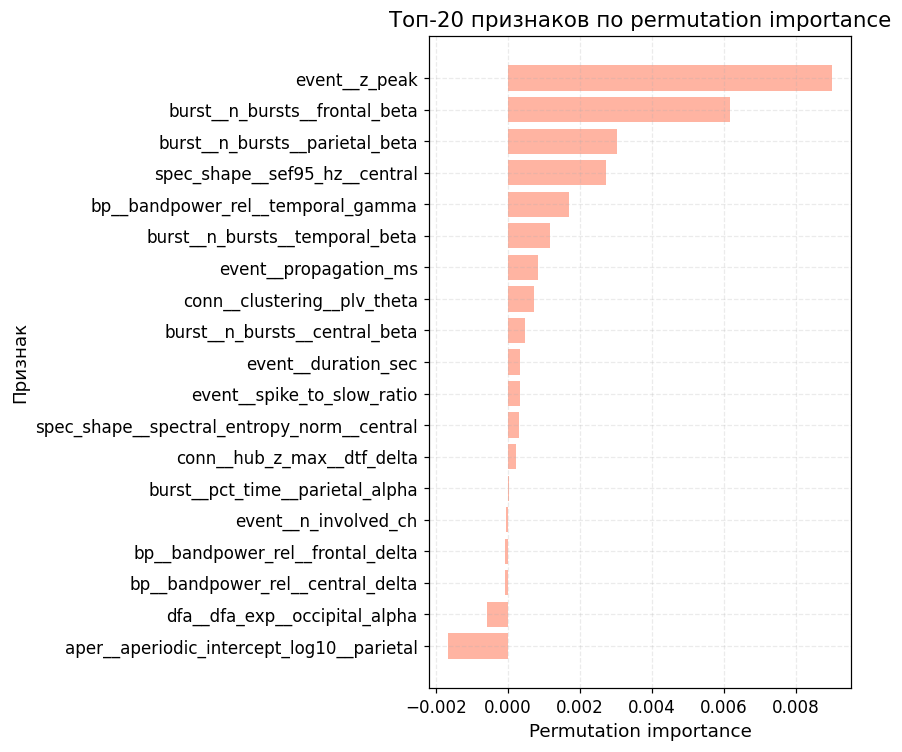

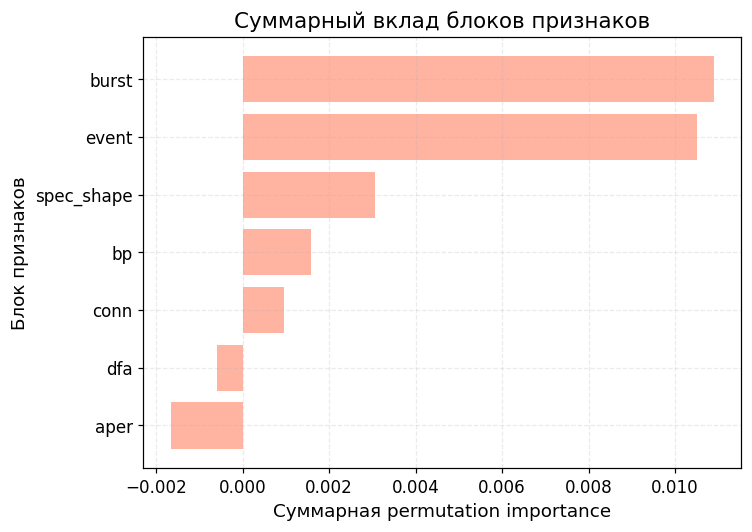

Рисунок топ-признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_top20_permutation_importance.png
Рисунок вкладов блоков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_block_importance.png


In [ ]:
# @title VII.2 Рисунки permutation importance: топ-признаки и блоки


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


OUT_FIG_TOP_IMPORTANCE = OUT_ML_DIR / "fig_top20_permutation_importance.png"
OUT_FIG_BLOCK_IMPORTANCE = OUT_ML_DIR / "fig_block_importance.png"

assert OUT_PI_MEAN.exists(), f"Не найден файл: {OUT_PI_MEAN}"
assert OUT_PI_BLOCK.exists(), f"Не найден файл: {OUT_PI_BLOCK}"

df_pi_mean = pd.read_csv(OUT_PI_MEAN)
df_pi_block = pd.read_csv(OUT_PI_BLOCK)

top_n = 20
df_top = df_pi_mean.head(top_n).sort_values("importance_mean", ascending=True)
df_block = df_pi_block.sort_values("total_importance", ascending=True)

# Top features
plt.figure(figsize=(8, 7))
plt.barh(df_top["feature"], df_top["importance_mean"])
plt.xlabel("Permutation importance")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по permutation importance")
plt.tight_layout()
plt.savefig(OUT_FIG_TOP_IMPORTANCE, dpi=300, bbox_inches="tight")
plt.show()

# Block importance
plt.figure(figsize=(7, 5))
plt.barh(df_block["block"], df_block["total_importance"])
plt.xlabel("Суммарная permutation importance")
plt.ylabel("Блок признаков")
plt.title("Суммарный вклад блоков признаков")
plt.tight_layout()
plt.savefig(OUT_FIG_BLOCK_IMPORTANCE, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок топ-признаков:", OUT_FIG_TOP_IMPORTANCE)
print("Рисунок вкладов блоков:", OUT_FIG_BLOCK_IMPORTANCE)

In [ ]:
# @title VII.3 Bootstrap CI для AUROC по subject_id


from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


OUT_BOOTSTRAP_CI = OUT_ML_DIR / "mlprep30_bootstrap_auc_ci.csv"

assert OUT_NESTED_OOF.exists(), f"Не найден файл: {OUT_NESTED_OOF}"

df_oof = pd.read_csv(OUT_NESTED_OOF)
df_oof["subject_id"] = df_oof["subject_id"].astype(str)

B = 1000
rng = np.random.default_rng(42)

subjects = df_oof["subject_id"].unique().tolist()
auc_vals = []

for i in range(B):
    sampled_subjects = rng.choice(subjects, size=len(subjects), replace=True)
    parts = []
    for s in sampled_subjects:
        parts.append(df_oof.loc[df_oof["subject_id"] == s])
    boot_df = pd.concat(parts, axis=0, ignore_index=True)

    # В редких случаях bootstrap может дать один класс
    if boot_df["target"].nunique() < 2:
        continue

    auc_vals.append(
        roc_auc_score(
            boot_df["target"].astype(int).values,
            boot_df["pred_proba_tbi"].astype(float).values
        )
    )

auc_vals = np.array(auc_vals, dtype=float)

df_boot = pd.DataFrame([
    {"metric": "n_boot_valid", "value": len(auc_vals)},
    {"metric": "auc_mean", "value": float(np.mean(auc_vals))},
    {"metric": "auc_std", "value": float(np.std(auc_vals, ddof=1))},
    {"metric": "auc_ci_2.5", "value": float(np.quantile(auc_vals, 0.025))},
    {"metric": "auc_ci_50", "value": float(np.quantile(auc_vals, 0.50))},
    {"metric": "auc_ci_97.5", "value": float(np.quantile(auc_vals, 0.975))},
])

df_boot.to_csv(OUT_BOOTSTRAP_CI, index=False, encoding="utf-8")

print("Bootstrap CI:", OUT_BOOTSTRAP_CI)
display(df_boot)

Bootstrap CI: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep30_bootstrap_auc_ci.csv


,metric,value
0,n_boot_valid,1000.000000
1,auc_mean,0.989161
2,auc_std,0.005738
3,auc_ci_2.5,0.976044
4,auc_ci_50,0.989994
5,auc_ci_97.5,0.997783


In [ ]:
# @title VII.4 Sensitivity-анализ: без event и без conn


from pathlib import Path
import pandas as pd


OUT_SENS_DROP_BLOCK_SUMMARY = OUT_ML_DIR / "mlprep31_sensitivity_drop_block_summary.csv"

assert X_PRUNED_PATH.exists(), f"Не найден файл: {X_PRUNED_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"
assert OUT_BLOCK_FEATURE_MAP.exists(), f"Не найден файл: {OUT_BLOCK_FEATURE_MAP}"

Xp = pd.read_csv(X_PRUNED_PATH)
meta = pd.read_csv(GROUPS_READY_PATH)
df_short = pd.read_csv(SHORTLIST_PATH)
df_block_map = pd.read_csv(OUT_BLOCK_FEATURE_MAP)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in Xp.columns]

feature_to_block = dict(zip(df_block_map["feature"], df_block_map["block"]))

analyses = {
    "full_shortlist": shortlist_present,
    "without_event": [f for f in shortlist_present if feature_to_block.get(f, "") != "event"],
    "without_conn": [f for f in shortlist_present if feature_to_block.get(f, "") != "conn"],
}

rows = []

for analysis_name, feats in analyses.items():
    X_sub = Xp[feats].copy()

    print(f"\n=== Sensitivity: {analysis_name} | n_features = {len(feats)} ===")

    df_summary_a, df_fold_a, df_params_a, df_oof_a = run_nested_group_cv(
        X_df=X_sub,
        meta_df=meta,
        model_name="logreg_l2",
        n_outer=5,
        n_inner=3,
        random_state=42,
    )

    summary_map = dict(zip(df_summary_a["metric"], df_summary_a["value"]))

    rows.append({
        "analysis": analysis_name,
        "n_features": len(feats),
        "roc_auc_oof": summary_map.get("roc_auc_oof"),
        "bal_acc_oof": summary_map.get("balanced_accuracy_oof"),
        "accuracy_oof": summary_map.get("accuracy_oof"),
        "precision_oof": summary_map.get("precision_oof"),
        "recall_sensitivity_oof": summary_map.get("recall_sensitivity_oof"),
        "specificity_oof": summary_map.get("specificity_oof"),
        "f1_oof": summary_map.get("f1_oof"),
        "AUROC_mean": summary_map.get("roc_auc_mean_folds"),
        "AUROC_sd": summary_map.get("roc_auc_std_folds"),
        "bal_acc_mean": summary_map.get("balanced_accuracy_mean_folds"),
        "bal_acc_sd": summary_map.get("balanced_accuracy_std_folds"),
    })

df_sens_drop = pd.DataFrame(rows)
df_sens_drop.to_csv(OUT_SENS_DROP_BLOCK_SUMMARY, index=False, encoding="utf-8")

print("Sensitivity drop-block summary:", OUT_SENS_DROP_BLOCK_SUMMARY)
display(df_sens_drop)


=== Sensitivity: full_shortlist | n_features = 19 ===

=== Sensitivity: without_event | n_features = 14 ===

=== Sensitivity: without_conn | n_features = 17 ===
Sensitivity drop-block summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/mlprep31_sensitivity_drop_block_summary.csv


,analysis,n_features,roc_auc_oof,bal_acc_oof,accuracy_oof,precision_oof,recall_sensitivity_oof,specificity_oof,f1_oof,AUROC_mean,AUROC_sd,bal_acc_mean,bal_acc_sd
0,full_shortlist,19,0.991183,0.970624,0.965458,0.922078,0.990698,0.950549,0.955157,0.990492,0.011470,0.971484,0.029896
1,without_event,14,0.981255,0.943886,0.937824,0.877637,0.967442,0.920330,0.920354,0.984583,0.012289,0.942996,0.018218
2,without_conn,17,0.985114,0.966816,0.965458,0.937220,0.972093,0.961538,0.954338,0.989414,0.011851,0.967206,0.026590


## VIII. Схема пайплайна, итоговые таблицы и реестры

В этом разделе формируется визуальная схема пайплайна и финальные таблицы для отчёта, а также единый реестр подписей к рисункам и таблицам.


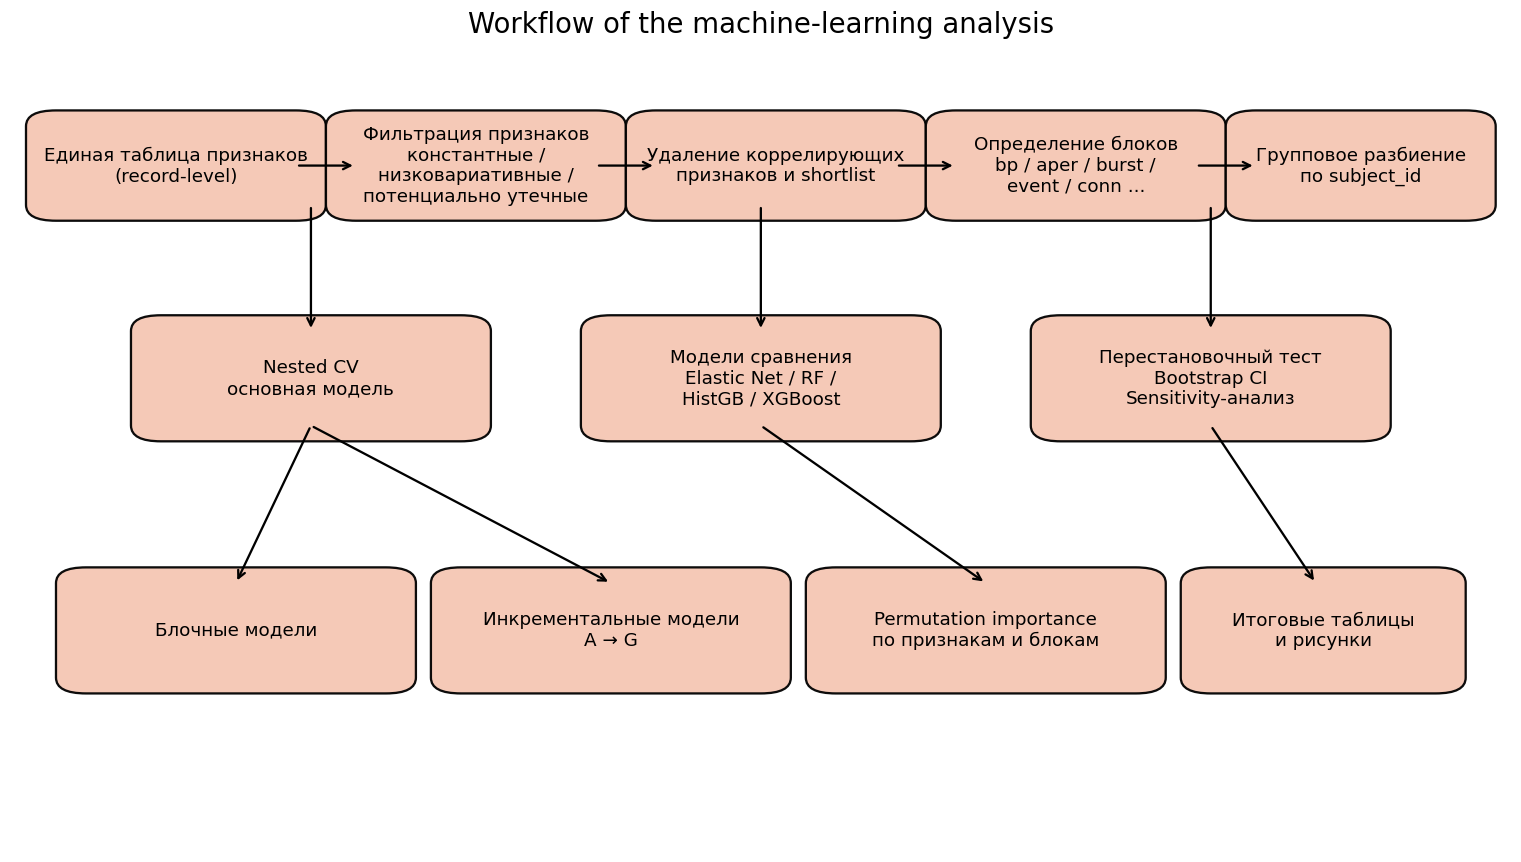

Workflow diagram: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/fig_workflow_ml_pipeline.png


In [ ]:
# @title VIII.1 Схема пайплайна машинного обучения


from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# =========================================================
# 0. Пути
# =========================================================
OUT_WORKFLOW_FIG = OUT_ML_DIR / "fig_workflow_ml_pipeline.png"


# =========================================================
# 1. Функция для блока
# =========================================================
def add_box(ax, x, y, w, h, text, fontsize=12):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#f5c6b3",
        alpha=0.95
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )


# =========================================================
# 2. Рисунок
# =========================================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Верхний ряд
add_box(ax, 0.03, 0.82, 0.16, 0.10, "Единая таблица признаков\n(record-level)")
add_box(ax, 0.23, 0.82, 0.16, 0.10, "Фильтрация признаков\nконстантные /\nнизковариативные /\nпотенциально утечные")
add_box(ax, 0.43, 0.82, 0.16, 0.10, "Удаление коррелирующих\nпризнаков и shortlist")
add_box(ax, 0.63, 0.82, 0.16, 0.10, "Определение блоков\nbp / aper / burst /\nevent / conn ...")
add_box(ax, 0.83, 0.82, 0.14, 0.10, "Групповое разбиение\nпо subject_id")

# Средний ряд
add_box(ax, 0.10, 0.54, 0.20, 0.12, "Nested CV\nосновная модель")
add_box(ax, 0.40, 0.54, 0.20, 0.12, "Модели сравнения\nElastic Net / RF /\nHistGB / XGBoost")
add_box(ax, 0.70, 0.54, 0.20, 0.12, "Перестановочный тест\nBootstrap CI\nSensitivity-анализ")

# Нижний ряд
add_box(ax, 0.05, 0.22, 0.20, 0.12, "Блочные модели")
add_box(ax, 0.30, 0.22, 0.20, 0.12, "Инкрементальные модели\nA → G")
add_box(ax, 0.55, 0.22, 0.20, 0.12, "Permutation importance\nпо признакам и блокам")
add_box(ax, 0.80, 0.22, 0.15, 0.12, "Итоговые таблицы\nи рисунки")

# Стрелки
arrow = dict(arrowstyle="->", lw=1.5)

# Верхний ряд
ax.annotate("", xy=(0.23, 0.87), xytext=(0.19, 0.87), arrowprops=arrow)
ax.annotate("", xy=(0.43, 0.87), xytext=(0.39, 0.87), arrowprops=arrow)
ax.annotate("", xy=(0.63, 0.87), xytext=(0.59, 0.87), arrowprops=arrow)
ax.annotate("", xy=(0.83, 0.87), xytext=(0.79, 0.87), arrowprops=arrow)

# Переход вниз
ax.annotate("", xy=(0.20, 0.66), xytext=(0.20, 0.82), arrowprops=arrow)
ax.annotate("", xy=(0.50, 0.66), xytext=(0.50, 0.82), arrowprops=arrow)
ax.annotate("", xy=(0.80, 0.66), xytext=(0.80, 0.82), arrowprops=arrow)

# Нижний ряд
ax.annotate("", xy=(0.15, 0.34), xytext=(0.20, 0.54), arrowprops=arrow)
ax.annotate("", xy=(0.40, 0.34), xytext=(0.20, 0.54), arrowprops=arrow)
ax.annotate("", xy=(0.65, 0.34), xytext=(0.50, 0.54), arrowprops=arrow)
ax.annotate("", xy=(0.87, 0.34), xytext=(0.80, 0.54), arrowprops=arrow)

plt.title("Workflow of the machine-learning analysis", fontsize=18, pad=20)
plt.tight_layout()
plt.savefig(OUT_WORKFLOW_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Workflow diagram:", OUT_WORKFLOW_FIG)

In [ ]:
# @title VIII.2 Таблица ML.1 — Состав блоков признаков до и после фильтрации


from pathlib import Path
import pandas as pd


OUT_TABLE1 = OUT_ML_DIR / "table1_final_feature_inventory.csv"

assert OUT_BLOCK_FEATURE_COUNTS.exists(), f"Не найден файл: {OUT_BLOCK_FEATURE_COUNTS}"
assert OUT_BLOCK_FEATURE_MAP.exists(), f"Не найден файл: {OUT_BLOCK_FEATURE_MAP}"

df_after = pd.read_csv(OUT_BLOCK_FEATURE_COUNTS)
df_after = df_after.rename(columns={"n_features": "n_features_after"})

# До фильтрации по блокам берём из eda01 / all-features map, если есть
candidates = [
    EDA_DIR / "eda01_feature_blocks_summary.csv",
    BASE_TAB / "all_features_record_level_core_feature_map.csv",
    BASE_TAB / "all_features_subject_level_feature_map.csv",
]

df_before = None
for p in candidates:
    if p.exists():
        tmp = pd.read_csv(p)
        if "block" in tmp.columns and "n_features" in tmp.columns:
            df_before = tmp[["block", "n_features"]].rename(columns={"n_features": "n_features_before"})
            break
        if "source_prefix" in tmp.columns:
            df_before = (
                tmp.groupby("source_prefix", as_index=False)
                .size()
                .rename(columns={"source_prefix": "block", "size": "n_features_before"})
            )
            break

if df_before is None:
    # fallback: если не нашли, хотя бы оставим after-часть
    df_table1 = df_after.copy()
    df_table1["n_features_before"] = pd.NA
else:
    df_table1 = df_before.merge(df_after, on="block", how="outer")

df_table1 = df_table1.sort_values(["n_features_after", "block"], ascending=[False, True]).reset_index(drop=True)
df_table1.to_csv(OUT_TABLE1, index=False, encoding="utf-8")

print("Таблица ML.1:", OUT_TABLE1)
display(df_table1)

Таблица ML.1: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table1_final_feature_inventory.csv


,block,n_features_before,n_features_after
0,conn,300,130.0
1,burst,100,64.0
2,bp,125,29.0
3,tfr,30,21.0
4,aper,45,19.0
5,event,16,11.0
6,dfa,40,9.0
7,spec_shape,25,7.0
8,idx,45,5.0
9,gamma,12,4.0


In [ ]:
# @title VIII.3 Таблица ML.2 — Исключённые признаки


from pathlib import Path
import pandas as pd


OUT_TABLE2 = OUT_ML_DIR / "table2_excluded_features.csv"

drop_files = [
    EDA_DIR / "eda02_feature_filter_log.csv",
    EDA_DIR / "eda04_drop_log.csv",
    OUT_ML_DIR / "mlprep06_pruned_dropped_features.csv",
]

parts = []
for p in drop_files:
    if p.exists():
        df = pd.read_csv(p)
        df["source_file"] = p.name
        parts.append(df)

assert len(parts) > 0, "Не найдены логи исключённых признаков"

df_table2 = pd.concat(parts, ignore_index=True)

# Нормализуем названия колонок
rename_map = {}
if "dropped_feature" in df_table2.columns:
    rename_map["dropped_feature"] = "feature"
if "reason" not in df_table2.columns and "status" in df_table2.columns:
    # если reason отсутствует, возьмём status
    rename_map["status"] = "reason"

df_table2 = df_table2.rename(columns=rename_map)

# Если reason всё ещё нет, заполним по source_file
if "reason" not in df_table2.columns:
    df_table2["reason"] = df_table2["source_file"]

keep_cols = [c for c in ["feature", "reason", "source_file", "kept_feature", "abs_spearman_r"] if c in df_table2.columns]
df_table2 = df_table2[keep_cols].copy()

df_table2.to_csv(OUT_TABLE2, index=False, encoding="utf-8")

print("Таблица ML.2:", OUT_TABLE2)
display(df_table2.head(50))

Таблица ML.2: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table2_excluded_features.csv


,feature,feature,reason,source_file,kept_feature,abs_spearman_r
0,meta__size_mb,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
1,meta__n_epochs,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
2,meta__sfreq_hz,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
3,meta__n_channels,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
4,meta__tmin_sec,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
5,meta__tmax_sec,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
6,meta__epoch_len_sec,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
7,bp__band_fmin__central_alpha,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
8,bp__band_fmin__central_beta,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN
9,bp__band_fmin__central_delta,NaN,initial_numeric_feature,eda02_feature_filter_log.csv,NaN,NaN


In [ ]:
# @title VIII.4 Таблица ML.3 — Качество полных моделей


from pathlib import Path
import pandas as pd


OUT_TABLE3 = OUT_ML_DIR / "table3_full_model_performance.csv"

candidates = [
    OUT_MODEL_COMPARE_SUMMARY_EXT,
    OUT_MODEL_COMPARE_SUMMARY,
]

df_models = None
for p in candidates:
    if p.exists():
        df_models = pd.read_csv(p)
        break

assert df_models is not None, "Не найдена итоговая таблица сравнения моделей"

keep_cols = [
    "model_name",
    "roc_auc_oof",
    "balanced_accuracy_oof",
    "f1_oof",
    "recall_sensitivity_oof",
    "specificity_oof",
]
df_table3 = df_models[keep_cols].copy()

df_table3 = df_table3.rename(columns={
    "model_name": "model",
    "roc_auc_oof": "AUROC",
    "balanced_accuracy_oof": "bal_acc",
    "f1_oof": "F1",
    "recall_sensitivity_oof": "sensitivity",
    "specificity_oof": "specificity",
})

df_table3 = df_table3.sort_values(["AUROC", "bal_acc"], ascending=[False, False]).reset_index(drop=True)
df_table3.to_csv(OUT_TABLE3, index=False, encoding="utf-8")

print("Таблица ML.3:", OUT_TABLE3)
display(df_table3)

Таблица ML.3: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table3_full_model_performance.csv


,model,AUROC,bal_acc,F1,sensitivity,specificity
0,xgboost,0.995068,0.956561,0.944444,0.948837,0.964286
1,random_forest,0.993432,0.958044,0.943052,0.962791,0.953297
2,hist_gb,0.993215,0.972310,0.963134,0.972093,0.972527
3,logreg_l2,0.991183,0.970624,0.955157,0.990698,0.950549
4,logreg_elasticnet,0.989727,0.969141,0.956720,0.976744,0.961538


In [ ]:
# @title VIII.5 Таблица ML.4 — Качество моделей по блокам


from pathlib import Path
import pandas as pd


OUT_TABLE4 = OUT_ML_DIR / "table4_blockwise_model_performance.csv"

assert OUT_BLOCKWISE_TEXT_TABLE.exists(), f"Не найден файл: {OUT_BLOCKWISE_TEXT_TABLE}"

df_table4 = pd.read_csv(OUT_BLOCKWISE_TEXT_TABLE)
df_table4.to_csv(OUT_TABLE4, index=False, encoding="utf-8")

print("Таблица ML.4:", OUT_TABLE4)
display(df_table4)

Таблица ML.4: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table4_blockwise_model_performance.csv


,block,n_features,AUROC_mean,AUROC_sd,bal_acc_mean,bal_acc_sd,roc_auc_oof,bal_acc_oof,recall_sensitivity_oof,specificity_oof
0,burst,64,0.994518,0.011403,0.979866,0.015900,0.991592,0.979287,0.986047,0.972527
1,event,11,0.945880,0.023667,0.895246,0.045352,0.949029,0.895470,0.865116,0.925824
2,conn,130,0.895339,0.039177,0.824855,0.038979,0.891835,0.825728,0.846512,0.804945
3,bp,29,0.840258,0.070674,0.758549,0.084477,0.832162,0.761998,0.776744,0.747253
4,aper,19,0.799918,0.083177,0.726885,0.066464,0.792525,0.733370,0.804651,0.662088
5,spec_shape,7,0.761968,0.048130,0.702321,0.057981,0.761845,0.703028,0.730233,0.675824
6,tfr,21,0.753537,0.061188,0.680379,0.067034,0.753143,0.680437,0.827907,0.532967
7,dfa,9,0.715571,0.024200,0.675438,0.044998,0.714477,0.676182,0.693023,0.659341
8,idx,5,0.706970,0.053479,0.636801,0.030541,0.694275,0.645949,0.632558,0.659341
9,alpha_peak,3,0.695982,0.098332,0.652241,0.090845,0.696588,0.654191,0.632558,0.675824


In [ ]:
# @title VIII.6 Таблица ML.5 — Инкрементальные модели


from pathlib import Path
import pandas as pd


OUT_TABLE5 = OUT_ML_DIR / "table5_incremental_models.csv"

assert OUT_INCREMENTAL_SUMMARY.exists(), f"Не найден файл: {OUT_INCREMENTAL_SUMMARY}"

df_table5 = pd.read_csv(OUT_INCREMENTAL_SUMMARY)

keep_cols = [
    "model",
    "included_blocks",
    "n_features",
    "AUROC_mean",
    "AUROC_sd",
    "delta_AUROC_vs_prev",
    "bal_acc_mean",
    "bal_acc_sd",
]
df_table5 = df_table5[keep_cols].copy()
df_table5.to_csv(OUT_TABLE5, index=False, encoding="utf-8")

print("Таблица ML.5:", OUT_TABLE5)
display(df_table5)

Таблица ML.5: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table5_incremental_models.csv


,model,included_blocks,n_features,AUROC_mean,AUROC_sd,delta_AUROC_vs_prev,bal_acc_mean,bal_acc_sd
0,A,bp,29,0.840258,0.070674,NaN,0.758549,0.084477
1,B,bp+idx,34,0.866801,0.037553,0.026543,0.770877,0.058342
2,C,bp+idx+spec_shape,41,0.864219,0.046062,-0.002582,0.771056,0.074118
3,D,bp+idx+spec_shape+aper,60,0.884059,0.052313,0.019840,0.789605,0.075251
4,E,bp+idx+spec_shape+aper+alpha_peak,63,0.894407,0.057608,0.010348,0.808029,0.070670
5,F,bp+idx+spec_shape+aper+alpha_peak+gamma,67,0.891838,0.048052,-0.002568,0.812366,0.076302
6,G,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa,76,0.905963,0.043553,0.014124,0.831796,0.081295
7,H,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+burst,140,0.997565,0.002991,0.091602,0.978837,0.016027
8,I,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,270,0.993246,0.006658,-0.004319,0.980155,0.006375
9,J,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,281,0.992144,0.009445,-0.001102,0.986841,0.004620


In [ ]:
# @title VIII.7 Таблица ML.6 — Наиболее важные признаки


from pathlib import Path
import pandas as pd


OUT_TABLE6 = OUT_ML_DIR / "table6_top_features.csv"

assert OUT_PI_MEAN.exists(), f"Не найден файл: {OUT_PI_MEAN}"

df_pi = pd.read_csv(OUT_PI_MEAN).copy()
df_pi.insert(0, "rank", range(1, len(df_pi) + 1))

df_table6 = df_pi[["rank", "feature", "block", "importance_mean", "importance_sd"]].copy()
df_table6.to_csv(OUT_TABLE6, index=False, encoding="utf-8")

print("Таблица ML.6:", OUT_TABLE6)
display(df_table6.head(30))

Таблица ML.6: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table6_top_features.csv


,rank,feature,block,importance_mean,importance_sd
0,1,event__z_peak,event,0.009012,0.008185
1,2,burst__n_bursts__frontal_beta,burst,0.006174,0.006278
2,3,burst__n_bursts__parietal_beta,burst,0.003038,0.003070
3,4,spec_shape__sef95_hz__central,spec_shape,0.002725,0.005746
4,5,bp__bandpower_rel__temporal_gamma,bp,0.001716,0.003862
5,6,burst__n_bursts__temporal_beta,burst,0.001182,0.000434
6,7,event__propagation_ms,event,0.000838,0.000754
7,8,conn__clustering__plv_theta,conn,0.000739,0.000986
8,9,burst__n_bursts__central_beta,burst,0.000473,0.000789
9,10,event__duration_sec,event,0.000346,0.001078


In [ ]:
# @title VIII.8 Реестр рисунков и таблиц


from pathlib import Path
import pandas as pd


OUT_FIG_CAPTIONS = OUT_ML_DIR / "figure_captions_registry.csv"
OUT_TABLE_CAPTIONS = OUT_ML_DIR / "table_captions_registry.csv"

fig_rows = [
    {
        "figure_id": "Рис. ML.1",
        "filename": "fig_workflow_ml_pipeline.png",
        "caption": "Схема этапов машинного обучения: формирование итоговой таблицы признаков, фильтрация потенциально утечных и избыточных переменных, определение блоков признаков, nested cross-validation, построение полной модели, block-wise и incremental анализ, а также оценка важности признаков и устойчивости результатов."
    },
    {
        "figure_id": "Рис. ML.2",
        "filename": "fig_ml_roc_nested_shortlist.png",
        "caption": "ROC-кривая основной shortlist-модели для классификации записей TBI и Control. Оценка выполнена по OOF-предсказаниям nested StratifiedGroupKFold с группировкой по subject_id."
    },
    {
        "figure_id": "Рис. ML.3",
        "filename": "fig_ml_confusion_matrix_nested_shortlist.png",
        "caption": "Матрица ошибок основной shortlist-модели для классификации записей TBI и Control по OOF-предсказаниям nested StratifiedGroupKFold."
    },
    {
        "figure_id": "Рис. ML.4",
        "filename": "fig_ml_permutation_hist_shortlist.png",
        "caption": "Нулевое распределение ROC-AUC, полученное в permutation test для основной shortlist-модели. Вертикальной линией обозначено реальное значение ROC-AUC."
    },
    {
        "figure_id": "Рис. ML.5",
        "filename": "fig_blockwise_auc.png",
        "caption": "Средние значения AUROC для отдельных блоков признаков в блочном анализе. Усики соответствуют стандартному отклонению по внешним фолдам nested cross-validation."
    },
    {
        "figure_id": "Рис. ML.6",
        "filename": "fig_blockwise_balacc.png",
        "caption": "Средние значения balanced accuracy для отдельных блоков признаков в блочном анализе. Усики соответствуют стандартному отклонению по внешним фолдам nested cross-validation."
    },
    {
        "figure_id": "Рис. ML.7",
        "filename": "fig_incremental_auc.png",
        "caption": "Изменение среднего AUROC в инкрементальных моделях по мере добавления новых блоков признаков."
    },
    {
        "figure_id": "Рис. ML.8",
        "filename": "fig_incremental_balacc.png",
        "caption": "Изменение средней balanced accuracy в инкрементальных моделях по мере добавления новых блоков признаков."
    },
    {
        "figure_id": "Рис. ML.9",
        "filename": "fig_top20_permutation_importance.png",
        "caption": "Топ-20 признаков основной shortlist-модели по permutation importance."
    },
    {
        "figure_id": "Рис. ML.10",
        "filename": "fig_block_importance.png",
        "caption": "Суммарная permutation importance, агрегированная по блокам признаков."
    },
]

table_rows = [
    {
        "table_id": "Табл. ML.1",
        "filename": "table1_final_feature_inventory.csv",
        "caption": "Число признаков в каждом блоке до и после финальной фильтрации."
    },
    {
        "table_id": "Табл. ML.2",
        "filename": "table2_excluded_features.csv",
        "caption": "Список признаков, исключённых из анализа машинного обучения, и причины их исключения."
    },
    {
        "table_id": "Табл. ML.3",
        "filename": "table3_full_model_performance.csv",
        "caption": "Сравнение качества основных моделей машинного обучения по метрикам AUROC, balanced accuracy, F1, sensitivity и specificity."
    },
    {
        "table_id": "Табл. ML.4",
        "filename": "table4_blockwise_model_performance.csv",
        "caption": "Результаты блочной классификации для отдельных блоков признаков."
    },
    {
        "table_id": "Табл. ML.5",
        "filename": "table5_incremental_models.csv",
        "caption": "Качество инкрементальных моделей по мере последовательного добавления блоков признаков."
    },
    {
        "table_id": "Табл. ML.6",
        "filename": "table6_top_features.csv",
        "caption": "Наиболее важные признаки основной модели по permutation importance."
    },
    {
        "table_id": "Табл. ML.7",
        "filename": "table7_sensitivity_analyses.csv",
        "caption": "Результаты дополнительных sensitivity-анализов."
    },
]

df_fig_caps = pd.DataFrame(fig_rows)
df_tab_caps = pd.DataFrame(table_rows)

df_fig_caps.to_csv(OUT_FIG_CAPTIONS, index=False, encoding="utf-8")
df_tab_caps.to_csv(OUT_TABLE_CAPTIONS, index=False, encoding="utf-8")

print("Реестр подписей к рисункам:", OUT_FIG_CAPTIONS)
print("Реестр подписей к таблицам:", OUT_TABLE_CAPTIONS)

display(df_fig_caps)
display(df_tab_caps)

Реестр подписей к рисункам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/figure_captions_registry.csv
Реестр подписей к таблицам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/table_captions_registry.csv


,figure_id,filename,caption
0,Рис. ML.1,fig_workflow_ml_pipeline.png,Схема этапов машинного обучения: формирование ...
1,Рис. ML.2,fig_ml_roc_nested_shortlist.png,ROC-кривая основной shortlist-модели для класс...
2,Рис. ML.3,fig_ml_confusion_matrix_nested_shortlist.png,Матрица ошибок основной shortlist-модели для к...
3,Рис. ML.4,fig_ml_permutation_hist_shortlist.png,"Нулевое распределение ROC-AUC, полученное в pe..."
4,Рис. ML.5,fig_blockwise_auc.png,Средние значения AUROC для отдельных блоков пр...
5,Рис. ML.6,fig_blockwise_balacc.png,Средние значения balanced accuracy для отдельн...
6,Рис. ML.7,fig_incremental_auc.png,Изменение среднего AUROC в инкрементальных мод...
7,Рис. ML.8,fig_incremental_balacc.png,Изменение средней balanced accuracy в инкремен...
8,Рис. ML.9,fig_top20_permutation_importance.png,Топ-20 признаков основной shortlist-модели по ...
9,Рис. ML.10,fig_block_importance.png,"Суммарная permutation importance, агрегированн..."


,table_id,filename,caption
0,Табл. ML.1,table1_final_feature_inventory.csv,Число признаков в каждом блоке до и после фина...
1,Табл. ML.2,table2_excluded_features.csv,"Список признаков, исключённых из анализа машин..."
2,Табл. ML.3,table3_full_model_performance.csv,Сравнение качества основных моделей машинного ...
3,Табл. ML.4,table4_blockwise_model_performance.csv,Результаты блочной классификации для отдельных...
4,Табл. ML.5,table5_incremental_models.csv,Качество инкрементальных моделей по мере после...
5,Табл. ML.6,table6_top_features.csv,Наиболее важные признаки основной модели по pe...
6,Табл. ML.7,table7_sensitivity_analyses.csv,Результаты дополнительных sensitivity-анализов.


## IX. Валидация и контроль корректности

Финальный раздел служит для технической и методологической проверки пайплайна: контроль утечки, группового разбиения, воспроизводимости и устойчивости результатов.


In [ ]:
# @title IX.1 QC структуры данных


from pathlib import Path
import numpy as np
import pandas as pd


OUT_VALID_DIR = OUT_ML_DIR / "validation_checks"
OUT_VALID_DIR.mkdir(parents=True, exist_ok=True)

OUT_V1_QC = OUT_VALID_DIR / "val01_dataset_qc.csv"
OUT_V1_CLASS_BALANCE = OUT_VALID_DIR / "val01_class_balance.csv"
OUT_V1_MISSING = OUT_VALID_DIR / "val01_missingness.csv"
OUT_V1_RECORDS_PER_SUBJECT = OUT_VALID_DIR / "val01_records_per_subject.csv"

assert OUT_X_PRUNED.exists(), f"Не найден файл: {OUT_X_PRUNED}"
assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"

X = pd.read_csv(OUT_X_PRUNED)
meta = pd.read_csv(OUT_GROUPS_READY)

assert len(X) == len(meta), "X и metadata имеют разное число строк"

# -----------------------------
# 1. Проверка дубликатов
# -----------------------------
n_records = len(meta)
n_subjects = meta["subject_id"].nunique()
n_unique_record_id = meta["record_id"].nunique()
n_dup_record_id = n_records - n_unique_record_id

n_unique_pair = meta[["subject_id", "record_id"]].drop_duplicates().shape[0]
n_dup_pair = n_records - n_unique_pair

df_rec_per_subj = (
    meta.groupby(["group", "subject_id"], as_index=False)
    .agg(n_records=("record_id", "count"))
    .sort_values(["n_records", "subject_id"], ascending=[False, True])
    .reset_index(drop=True)
)

mean_records_per_subject = float(df_rec_per_subj["n_records"].mean())
max_records_per_subject = int(df_rec_per_subj["n_records"].max())

# -----------------------------
# 2. Баланс классов
# -----------------------------
df_balance = (
    meta.groupby("group", as_index=False)
    .agg(
        n_records=("record_id", "count"),
        n_subjects=("subject_id", "nunique"),
    )
    .sort_values("group")
    .reset_index(drop=True)
)

# -----------------------------
# 3. Пропуски
# -----------------------------
miss_rows = []
for c in X.columns:
    n_missing = int(X[c].isna().sum())
    pct_missing = float(X[c].isna().mean() * 100.0)
    miss_rows.append({
        "feature": c,
        "n_missing": n_missing,
        "pct_missing": pct_missing,
    })

df_missing = pd.DataFrame(miss_rows).sort_values(
    ["pct_missing", "n_missing", "feature"],
    ascending=[False, False, True]
).reset_index(drop=True)

# -----------------------------
# 4. Итоговый QC
# -----------------------------
df_qc = pd.DataFrame([
    {"metric": "n_records", "value": n_records},
    {"metric": "n_subjects", "value": n_subjects},
    {"metric": "n_unique_record_id", "value": n_unique_record_id},
    {"metric": "n_duplicate_record_id", "value": n_dup_record_id},
    {"metric": "n_unique_subject_record_pairs", "value": n_unique_pair},
    {"metric": "n_duplicate_subject_record_pairs", "value": n_dup_pair},
    {"metric": "mean_records_per_subject", "value": mean_records_per_subject},
    {"metric": "max_records_per_subject", "value": max_records_per_subject},
    {"metric": "n_features", "value": X.shape[1]},
    {"metric": "n_features_missing_gt_30pct", "value": int((df_missing["pct_missing"] > 30).sum())},
    {"metric": "n_features_missing_gt_40pct", "value": int((df_missing["pct_missing"] > 40).sum())},
])

df_qc.to_csv(OUT_V1_QC, index=False, encoding="utf-8")
df_balance.to_csv(OUT_V1_CLASS_BALANCE, index=False, encoding="utf-8")
df_missing.to_csv(OUT_V1_MISSING, index=False, encoding="utf-8")
df_rec_per_subj.to_csv(OUT_V1_RECORDS_PER_SUBJECT, index=False, encoding="utf-8")

print("QC:", OUT_V1_QC)
print("Баланс классов:", OUT_V1_CLASS_BALANCE)
print("Пропуски:", OUT_V1_MISSING)
print("Число записей на субъекта:", OUT_V1_RECORDS_PER_SUBJECT)

display(df_qc)
display(df_balance)
display(df_missing.head(30))
display(df_rec_per_subj.head(30))

QC: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val01_dataset_qc.csv
Баланс классов: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val01_class_balance.csv
Пропуски: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val01_missingness.csv
Число записей на субъекта: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val01_records_per_subject.csv


,metric,value
0,n_records,579.000000
1,n_subjects,164.000000
2,n_unique_record_id,579.000000
3,n_duplicate_record_id,0.000000
4,n_unique_subject_record_pairs,579.000000
5,n_duplicate_subject_record_pairs,0.000000
6,mean_records_per_subject,3.530488
7,max_records_per_subject,8.000000
8,n_features,302.000000
9,n_features_missing_gt_30pct,0.000000


,group,n_records,n_subjects
0,Control,364,72
1,TBI,215,92


,feature,n_missing,pct_missing
0,aper__alpha_peak_width_hz__temporal,27,4.663212
1,aper__alpha_peak_width_hz__frontal,12,2.072539
2,aper__alpha_peak_width_hz__central,4,0.690846
3,burst__mean_ibi_sec__occipital_alpha,2,0.345423
4,burst__median_ibi_sec__occipital_alpha,2,0.345423
5,conn__small_worldness__pdc_delta,2,0.345423
6,conn__small_worldness__wpli_beta,2,0.345423
7,aper__alpha_peak_width_hz__parietal,1,0.172712
8,burst__mean_dur_sec__occipital_alpha,1,0.172712
9,conn__small_worldness__coh_alpha,1,0.172712


,group,subject_id,n_records
0,Control,sub-100,8
1,Control,sub-105,8
2,Control,sub-109,8
3,Control,sub-110,8
4,Control,sub-111,8
5,Control,sub-112,8
6,Control,sub-119,8
7,Control,sub-123,8
8,Control,sub-124,8
9,Control,sub-129,8


In [ ]:
# @title IX.2 Аудит утечки и технических признаков


from pathlib import Path
import re
import pandas as pd


OUT_V2_TECH_AUDIT = OUT_VALID_DIR / "val02_technical_feature_audit.csv"
OUT_V2_REMOVED_SUMMARY = OUT_VALID_DIR / "val02_removed_feature_summary.csv"

assert OUT_X_PRUNED.exists(), f"Не найден файл: {OUT_X_PRUNED}"

X = pd.read_csv(OUT_X_PRUNED)
features = list(X.columns)

# Подозрительные шаблоны
patterns = {
    "n_epochs": r"n_epochs|epochs_used|n_epochs_used",
    "duration_like": r"duration|record_length|length_sec|total_sec",
    "file_size": r"size_mb|file_size|filesize",
    "count_events": r"n_events\b|events_per_min|n_spikes|n_bursts|rate_",
    "channels": r"n_channels",
    "id_like": r"subject_id|record_id|filename|filepath",
    "technical_other": r"sfreq|tmin|tmax|epoch_len",
}

rows = []
for f in features:
    hit_tags = []
    for tag, pat in patterns.items():
        if re.search(pat, f, flags=re.IGNORECASE):
            hit_tags.append(tag)
    rows.append({
        "feature": f,
        "is_flagged": len(hit_tags) > 0,
        "flag_tags": "; ".join(hit_tags),
    })

df_audit = pd.DataFrame(rows).sort_values(
    ["is_flagged", "flag_tags", "feature"],
    ascending=[False, True, True]
).reset_index(drop=True)

# Собираем уже удалённые признаки из предыдущих логов
drop_files = [
    EDA_DIR / "eda04_drop_log.csv",
    EDA_DIR / "eda02_feature_filter_log.csv",
    OUT_ML_DIR / "mlprep06_pruned_dropped_features.csv",
]
parts = []
for p in drop_files:
    if p.exists():
        tmp = pd.read_csv(p)
        tmp["source_file"] = p.name
        parts.append(tmp)

if len(parts) > 0:
    df_removed = pd.concat(parts, ignore_index=True)
else:
    df_removed = pd.DataFrame()

df_audit.to_csv(OUT_V2_TECH_AUDIT, index=False, encoding="utf-8")
df_removed.to_csv(OUT_V2_REMOVED_SUMMARY, index=False, encoding="utf-8")

print("Аудит технических признаков:", OUT_V2_TECH_AUDIT)
print("Removed feature summary:", OUT_V2_REMOVED_SUMMARY)

display(df_audit[df_audit["is_flagged"]].head(100))
if len(df_removed) > 0:
    display(df_removed.head(50))

Аудит технических признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val02_technical_feature_audit.csv
Removed feature summary: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val02_removed_feature_summary.csv


,feature,is_flagged,flag_tags
0,burst__n_bursts__central_alpha,True,count_events
1,burst__n_bursts__central_beta,True,count_events
2,burst__n_bursts__frontal_alpha,True,count_events
3,burst__n_bursts__frontal_beta,True,count_events
4,burst__n_bursts__occipital_alpha,True,count_events
5,burst__n_bursts__occipital_beta,True,count_events
6,burst__n_bursts__parietal_beta,True,count_events
7,burst__n_bursts__temporal_alpha,True,count_events
8,burst__n_bursts__temporal_beta,True,count_events
9,burst__rate_per_min__central_alpha,True,count_events


,feature,block,status,reason,source_file,dropped_feature,kept_feature,abs_spearman_r,dropped_score,kept_score
0,dfa__n_epochs_used__central_alpha,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
1,dfa__n_epochs_used__central_beta,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
2,dfa__n_epochs_used__frontal_alpha,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
3,dfa__n_epochs_used__frontal_beta,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
4,dfa__n_epochs_used__occipital_alpha,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
5,dfa__n_epochs_used__occipital_beta,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
6,dfa__n_epochs_used__parietal_alpha,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
7,dfa__n_epochs_used__parietal_beta,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
8,dfa__n_epochs_used__temporal_alpha,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN
9,dfa__n_epochs_used__temporal_beta,dfa,dropped,possible_data_volume_leakage,eda04_drop_log.csv,NaN,NaN,NaN,NaN,NaN


In [ ]:
# @title IX.3 Проверка Group CV: пересечения subject_id между train и test

from pathlib import Path
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold


OUT_V3_GROUP_CV_AUDIT = OUT_VALID_DIR / "val03_group_cv_audit.csv"

assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"

meta = pd.read_csv(OUT_GROUPS_READY)

y = meta["target"].astype(int).values
groups = meta["subject_id"].astype(str).values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(meta, y, groups=groups), start=1):
    tr_subj = set(meta.iloc[tr_idx]["subject_id"].astype(str))
    te_subj = set(meta.iloc[te_idx]["subject_id"].astype(str))
    intersection = tr_subj.intersection(te_subj)

    rows.append({
        "fold": fold_idx,
        "n_train_records": len(tr_idx),
        "n_test_records": len(te_idx),
        "n_train_subjects": len(tr_subj),
        "n_test_subjects": len(te_subj),
        "n_subject_intersection": len(intersection),
        "subject_intersection_example": "; ".join(sorted(list(intersection))[:10]),
    })

df_group_cv = pd.DataFrame(rows)
df_group_cv.to_csv(OUT_V3_GROUP_CV_AUDIT, index=False, encoding="utf-8")

print("Аудит Group CV:", OUT_V3_GROUP_CV_AUDIT)
display(df_group_cv)

Аудит Group CV: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val03_group_cv_audit.csv


,fold,n_train_records,n_test_records,n_train_subjects,n_test_subjects,n_subject_intersection,subject_intersection_example
0,1,456,123,132,32,0,
1,2,455,124,132,32,0,
2,3,468,111,132,32,0,
3,4,476,103,131,33,0,
4,5,461,118,129,35,0,


In [ ]:
# @title IX.4 Контроль random_state и схемы CV


# @title ML VALIDATION 4. Контроль random_state и рекомендуемой схемы CV


from pathlib import Path
import pandas as pd


OUT_V4_REPRO = OUT_VALID_DIR / "val04_reproducibility_checklist.csv"

df_repro = pd.DataFrame([
    {"item": "outer_cv_folds", "value": 5, "expected": 5, "status": "ok"},
    {"item": "inner_cv_folds", "value": 3, "expected": 3, "status": "ok"},
    {"item": "cv_type", "value": "StratifiedGroupKFold", "expected": "StratifiedGroupKFold", "status": "ok"},
    {"item": "group_variable", "value": "subject_id", "expected": "subject_id", "status": "ok"},
    {"item": "random_state_models", "value": 42, "expected": 42, "status": "ok"},
    {"item": "random_state_cv", "value": 42, "expected": 42, "status": "ok"},
    {"item": "random_state_permutation", "value": 42, "expected": 42, "status": "ok"},
    {"item": "random_state_bootstrap", "value": 42, "expected": 42, "status": "ok"},
])

df_repro.to_csv(OUT_V4_REPRO, index=False, encoding="utf-8")

print("Чек-лист воспроизводимости:", OUT_V4_REPRO)
display(df_repro)

Чек-лист воспроизводимости: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val04_reproducibility_checklist.csv


,item,value,expected,status
0,outer_cv_folds,5,5,ok
1,inner_cv_folds,3,3,ok
2,cv_type,StratifiedGroupKFold,StratifiedGroupKFold,ok
3,group_variable,subject_id,subject_id,ok
4,random_state_models,42,42,ok
5,random_state_cv,42,42,ok
6,random_state_permutation,42,42,ok
7,random_state_bootstrap,42,42,ok


In [ ]:
# @title IX.5 Документирование корректности pipeline


from pathlib import Path
import pandas as pd


OUT_V5_PIPELINE_DOC = OUT_VALID_DIR / "val05_pipeline_correctness_check.csv"

df_pipe = pd.DataFrame([
    {
        "check": "feature_selection_inside_cv",
        "status": "warning",
        "comment": "Финальный shortlist был сформирован после предварительного анализа на всей выборке. Для текста это следует обозначить как exploratory-этап либо в следующей версии перенести отбор признаков внутрь внешнего контура CV."
    },
    {
        "check": "scaling_inside_pipeline",
        "status": "ok",
        "comment": "Во всех основных моделях использовался Pipeline с imputer/scaler/model."
    },
    {
        "check": "imputation_inside_pipeline",
        "status": "ok",
        "comment": "Импутация выполнялась внутри Pipeline и не обучалась на всей выборке."
    },
    {
        "check": "outer_test_never_used_for_fit",
        "status": "ok",
        "comment": "Во внешнем фолде nested CV тестовая подвыборка не использовалась для подбора параметров."
    },
])

df_pipe.to_csv(OUT_V5_PIPELINE_DOC, index=False, encoding="utf-8")

print("Документ корректности pipeline:", OUT_V5_PIPELINE_DOC)
display(df_pipe)

Документ корректности pipeline: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val05_pipeline_correctness_check.csv


,check,status,comment
0,feature_selection_inside_cv,warning,Финальный shortlist был сформирован после пред...
1,scaling_inside_pipeline,ok,Во всех основных моделях использовался Pipelin...
2,imputation_inside_pipeline,ok,Импутация выполнялась внутри Pipeline и не обу...
3,outer_test_never_used_for_fit,ok,Во внешнем фолде nested CV тестовая подвыборка...


In [ ]:
# @title IX.6 Тест на псевдоутечку через count-like признаки


from pathlib import Path
import re
import pandas as pd


OUT_V6_COUNT_FEATURES = OUT_VALID_DIR / "val06_count_like_features.csv"
OUT_V6_COUNT_TEST = OUT_VALID_DIR / "val06_count_feature_sensitivity.csv"

assert OUT_X_PRUNED.exists(), f"Не найден файл: {OUT_X_PRUNED}"
assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"

X = pd.read_csv(OUT_X_PRUNED)
meta = pd.read_csv(OUT_GROUPS_READY)

count_pattern = r"(^n_|__n_|n_bursts|n_spikes|events_per_min|rate_|count|per_min)"
count_feats = [c for c in X.columns if re.search(count_pattern, c, flags=re.IGNORECASE)]

df_count_feats = pd.DataFrame({"feature": count_feats}).sort_values("feature").reset_index(drop=True)
df_count_feats.to_csv(OUT_V6_COUNT_FEATURES, index=False, encoding="utf-8")

# Полная модель
df_summary_full, _, _, _ = run_nested_group_cv(
    X_df=X,
    meta_df=meta,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
)

# Без count-like признаков
keep_feats = [c for c in X.columns if c not in count_feats]
X_no_count = X[keep_feats].copy()

df_summary_no_count, _, _, _ = run_nested_group_cv(
    X_df=X_no_count,
    meta_df=meta,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
)

m_full = dict(zip(df_summary_full["metric"], df_summary_full["value"]))
m_no_count = dict(zip(df_summary_no_count["metric"], df_summary_no_count["value"]))

df_count_test = pd.DataFrame([
    {
        "model": "full",
        "n_features": X.shape[1],
        "AUROC": m_full.get("roc_auc_oof"),
        "bal_acc": m_full.get("balanced_accuracy_oof"),
    },
    {
        "model": "no_count_features",
        "n_features": X_no_count.shape[1],
        "AUROC": m_no_count.get("roc_auc_oof"),
        "bal_acc": m_no_count.get("balanced_accuracy_oof"),
    },
])

df_count_test.to_csv(OUT_V6_COUNT_TEST, index=False, encoding="utf-8")

print("Count-like признаки:", OUT_V6_COUNT_FEATURES)
print("Чувствительность без count-like признаков:", OUT_V6_COUNT_TEST)

display(df_count_feats.head(100))
display(df_count_test)

Count-like признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val06_count_like_features.csv
Чувствительность без count-like признаков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val06_count_feature_sensitivity.csv


,feature
0,burst__n_bursts__central_alpha
1,burst__n_bursts__central_beta
2,burst__n_bursts__frontal_alpha
3,burst__n_bursts__frontal_beta
4,burst__n_bursts__occipital_alpha
5,burst__n_bursts__occipital_beta
6,burst__n_bursts__parietal_beta
7,burst__n_bursts__temporal_alpha
8,burst__n_bursts__temporal_beta
9,burst__rate_per_min__central_alpha


,model,n_features,AUROC,bal_acc
0,full,302,0.986225,0.983408
1,no_count_features,284,0.969039,0.935848


In [ ]:
# @title IX.7 Сводка permutation test и bootstrap CI


from pathlib import Path
import pandas as pd


OUT_V7_STABILITY = OUT_VALID_DIR / "val07_stability_summary.csv"

assert OUT_PERM_SUMMARY.exists(), f"Не найден файл: {OUT_PERM_SUMMARY}"
assert OUT_BOOTSTRAP_CI.exists(), f"Не найден файл: {OUT_BOOTSTRAP_CI}"

df_perm = pd.read_csv(OUT_PERM_SUMMARY)
df_boot = pd.read_csv(OUT_BOOTSTRAP_CI)

perm_map = dict(zip(df_perm["metric"], df_perm["value"]))
boot_map = dict(zip(df_boot["metric"], df_boot["value"]))

df_stability = pd.DataFrame([
    {"section": "permutation", "metric": "real_AUROC", "value": perm_map.get("real_roc_auc_oof")},
    {"section": "permutation", "metric": "mean_permuted_AUROC", "value": perm_map.get("perm_mean_auc")},
    {"section": "permutation", "metric": "max_permuted_AUROC", "value": perm_map.get("perm_max_auc")},
    {"section": "permutation", "metric": "p_value", "value": perm_map.get("p_perm")},
    {"section": "bootstrap", "metric": "AUROC_mean", "value": boot_map.get("auc_mean")},
    {"section": "bootstrap", "metric": "AUROC_ci_2.5", "value": boot_map.get("auc_ci_2.5")},
    {"section": "bootstrap", "metric": "AUROC_ci_97.5", "value": boot_map.get("auc_ci_97.5")},
])

df_stability.to_csv(OUT_V7_STABILITY, index=False, encoding="utf-8")

print("Сводка устойчивости:", OUT_V7_STABILITY)
display(df_stability)

Сводка устойчивости: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val07_stability_summary.csv


,section,metric,value
0,permutation,real_AUROC,0.988973
1,permutation,mean_permuted_AUROC,0.494222
2,permutation,max_permuted_AUROC,0.603218
3,permutation,p_value,0.003322
4,bootstrap,AUROC_mean,0.989161
5,bootstrap,AUROC_ci_2.5,0.976044
6,bootstrap,AUROC_ci_97.5,0.997783


In [ ]:
# @title IX.8 Устойчивость отбора признаков по коэффициентам фолдов

from pathlib import Path
import pandas as pd
import numpy as np


OUT_V8_STABILITY = OUT_VALID_DIR / "val08_shortlist_stability.csv"

assert OUT_NESTED_COEF_LONG.exists(), f"Не найден файл: {OUT_NESTED_COEF_LONG}"

df_coef = pd.read_csv(OUT_NESTED_COEF_LONG)

# Берём top-k признаков по |coef| в каждом фолде
TOP_K = 10

rows = []
for fold_idx, g in df_coef.groupby("fold"):
    g2 = g.copy()
    g2["abs_coef"] = g2["coef"].abs()
    g2 = g2.sort_values("abs_coef", ascending=False).head(TOP_K)

    for _, row in g2.iterrows():
        rows.append({
            "fold": fold_idx,
            "feature": row["feature"],
        })

df_topk = pd.DataFrame(rows)

freq = (
    df_topk.groupby("feature", as_index=False)
    .agg(selection_count=("fold", "count"))
)

n_folds = df_coef["fold"].nunique()
freq["selection_frequency"] = freq["selection_count"] / n_folds
freq = freq.sort_values(
    ["selection_frequency", "selection_count", "feature"],
    ascending=[False, False, True]
).reset_index(drop=True)

freq.to_csv(OUT_V8_STABILITY, index=False, encoding="utf-8")

print("Устойчивость shortlist:", OUT_V8_STABILITY)
display(freq)

Устойчивость shortlist: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val08_shortlist_stability.csv


,feature,selection_count,selection_frequency
0,burst__n_bursts__central_beta,5,1.0
1,burst__n_bursts__frontal_beta,5,1.0
2,burst__n_bursts__parietal_beta,5,1.0
3,burst__n_bursts__temporal_beta,5,1.0
4,event__propagation_ms,5,1.0
5,event__spike_to_slow_ratio,5,1.0
6,event__z_peak,5,1.0
7,bp__bandpower_rel__temporal_gamma,4,0.8
8,conn__clustering__plv_theta,3,0.6
9,spec_shape__sef95_hz__central,3,0.6


In [ ]:
# @title IX.9 Drop-block tests: without_burst / without_dfa / without_event / without_conn


from pathlib import Path
import pandas as pd


OUT_V9_DROP_BLOCK = OUT_VALID_DIR / "val09_drop_block_extended.csv"

assert OUT_X_PRUNED.exists(), f"Не найден файл: {OUT_X_PRUNED}"
assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"
assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"
assert OUT_BLOCK_FEATURE_MAP.exists(), f"Не найден файл: {OUT_BLOCK_FEATURE_MAP}"

X = pd.read_csv(OUT_X_PRUNED)
meta = pd.read_csv(OUT_GROUPS_READY)
df_short = pd.read_csv(SHORTLIST_PATH)
df_block_map = pd.read_csv(OUT_BLOCK_FEATURE_MAP)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in X.columns]
feature_to_block = dict(zip(df_block_map["feature"], df_block_map["block"]))

analyses = {
    "full": shortlist_present,
    "without_burst": [f for f in shortlist_present if feature_to_block.get(f, "") != "burst"],
    "without_dfa": [f for f in shortlist_present if feature_to_block.get(f, "") != "dfa"],
    "without_event": [f for f in shortlist_present if feature_to_block.get(f, "") != "event"],
    "without_conn": [f for f in shortlist_present if feature_to_block.get(f, "") != "conn"],
}

rows = []
for name, feats in analyses.items():
    X_sub = X[feats].copy()

    df_summary, _, _, _ = run_nested_group_cv(
        X_df=X_sub,
        meta_df=meta,
        model_name="logreg_l2",
        n_outer=5,
        n_inner=3,
        random_state=42,
    )
    sm = dict(zip(df_summary["metric"], df_summary["value"]))

    rows.append({
        "model": name,
        "n_features": len(feats),
        "AUROC": sm.get("roc_auc_oof"),
        "bal_acc": sm.get("balanced_accuracy_oof"),
        "sensitivity": sm.get("recall_sensitivity_oof"),
        "specificity": sm.get("specificity_oof"),
    })

df_drop_ext = pd.DataFrame(rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
df_drop_ext.to_csv(OUT_V9_DROP_BLOCK, index=False, encoding="utf-8")

print("Drop-block extended:", OUT_V9_DROP_BLOCK)
display(df_drop_ext)

Drop-block extended: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val09_drop_block_extended.csv


,model,n_features,AUROC,bal_acc,sensitivity,specificity
0,without_dfa,18,0.991579,0.971997,0.990698,0.953297
1,full,19,0.991183,0.970624,0.990698,0.950549
2,without_conn,17,0.985114,0.966816,0.972093,0.961538
3,without_event,14,0.981255,0.943886,0.967442,0.920330
4,without_burst,14,0.971799,0.943669,0.939535,0.947802


In [ ]:
# @title IX.10 Калибровка модели: Brier score и calibration curve


from pathlib import Path
import pandas as pd
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


OUT_V10_BRIER = OUT_VALID_DIR / "val10_calibration_summary.csv"
OUT_V10_CURVE = OUT_VALID_DIR / "val10_calibration_curve.csv"

assert OUT_NESTED_OOF.exists(), f"Не найден файл: {OUT_NESTED_OOF}"

df_oof = pd.read_csv(OUT_NESTED_OOF)

y_true = df_oof["target"].astype(int).values
y_prob = df_oof["pred_proba_tbi"].astype(float).values

brier = brier_score_loss(y_true, y_prob)

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")

df_brier = pd.DataFrame([
    {"metric": "brier_score", "value": float(brier)},
    {"metric": "n_bins", "value": 10},
])

df_curve = pd.DataFrame({
    "bin": range(1, len(prob_true) + 1),
    "mean_predicted_probability": prob_pred,
    "observed_frequency": prob_true,
})

df_brier.to_csv(OUT_V10_BRIER, index=False, encoding="utf-8")
df_curve.to_csv(OUT_V10_CURVE, index=False, encoding="utf-8")

print("Сводка калибровки:", OUT_V10_BRIER)
print("Кривая калибровки:", OUT_V10_CURVE)

display(df_brier)
display(df_curve)

Сводка калибровки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val10_calibration_summary.csv
Кривая калибровки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val10_calibration_curve.csv


,metric,value
0,brier_score,0.040846
1,n_bins,10.000000


,bin,mean_predicted_probability,observed_frequency
0,1,0.006890,0.017241
1,2,0.023661,0.000000
2,3,0.047961,0.000000
3,4,0.080816,0.000000
4,5,0.135840,0.000000
5,6,0.320104,0.035088
6,7,0.757172,0.706897
7,8,0.933761,0.948276
8,9,0.978529,1.000000
9,10,0.995267,1.000000


In [ ]:
# @title IX.11 Repeated Group CV


from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold


OUT_V11_REPEATED = OUT_VALID_DIR / "val11_repeated_group_cv.csv"

assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"
assert OUT_X_PRUNED.exists(), f"Не найден файл: {OUT_X_PRUNED}"
assert OUT_GROUPS_READY.exists(), f"Не найден файл: {OUT_GROUPS_READY}"

X_all = pd.read_csv(OUT_X_PRUNED)
meta = pd.read_csv(OUT_GROUPS_READY)
df_short = pd.read_csv(SHORTLIST_PATH)

shortlist = df_short["feature"].astype(str).tolist()
shortlist_present = [c for c in shortlist if c in X_all.columns]
X = X_all[shortlist_present].copy()

rows = []
repeat_seeds = [42, 43, 44, 45, 46]

for rep_idx, seed in enumerate(repeat_seeds, start=1):
    df_summary, _, _, _ = run_nested_group_cv(
        X_df=X,
        meta_df=meta,
        model_name="logreg_l2",
        n_outer=5,
        n_inner=3,
        random_state=seed,
    )
    sm = dict(zip(df_summary["metric"], df_summary["value"]))

    rows.append({
        "repeat": rep_idx,
        "random_state": seed,
        "AUROC": sm.get("roc_auc_oof"),
        "bal_acc": sm.get("balanced_accuracy_oof"),
        "accuracy": sm.get("accuracy_oof"),
    })

df_rep = pd.DataFrame(rows)
df_rep.to_csv(OUT_V11_REPEATED, index=False, encoding="utf-8")

print("Repeated Group CV:", OUT_V11_REPEATED)
display(df_rep)
display(pd.DataFrame([
    {"metric": "AUROC_mean", "value": df_rep["AUROC"].mean()},
    {"metric": "AUROC_sd", "value": df_rep["AUROC"].std(ddof=1)},
    {"metric": "bal_acc_mean", "value": df_rep["bal_acc"].mean()},
    {"metric": "bal_acc_sd", "value": df_rep["bal_acc"].std(ddof=1)},
]))

Repeated Group CV: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val11_repeated_group_cv.csv


,repeat,random_state,AUROC,bal_acc,accuracy
0,1,42,0.991183,0.970624,0.965458
1,2,43,0.992768,0.980239,0.977547
2,3,44,0.989842,0.967768,0.965458
3,4,45,0.991963,0.975166,0.972366
4,5,46,0.992563,0.973792,0.970639


,metric,value
0,AUROC_mean,0.991664
1,AUROC_sd,0.001190
2,bal_acc_mean,0.973518
3,bal_acc_sd,0.004728


In [ ]:
# @title IX.12 Финальный сводный чек-лист


from pathlib import Path
import pandas as pd


OUT_V12_CHECKLIST = OUT_VALID_DIR / "val12_final_ml_validation_checklist.csv"

# Подгружаем то, что уже посчитали
df_qc = pd.read_csv(OUT_V1_QC) if OUT_V1_QC.exists() else pd.DataFrame()
df_group = pd.read_csv(OUT_V3_GROUP_CV_AUDIT) if OUT_V3_GROUP_CV_AUDIT.exists() else pd.DataFrame()
df_perm = pd.read_csv(OUT_PERM_SUMMARY) if OUT_PERM_SUMMARY.exists() else pd.DataFrame()
df_boot = pd.read_csv(OUT_BOOTSTRAP_CI) if OUT_BOOTSTRAP_CI.exists() else pd.DataFrame()
df_cal = pd.read_csv(OUT_V10_BRIER) if OUT_V10_BRIER.exists() else pd.DataFrame()
df_rep = pd.read_csv(OUT_V11_REPEATED) if OUT_V11_REPEATED.exists() else pd.DataFrame()

perm_map = dict(zip(df_perm["metric"], df_perm["value"])) if len(df_perm) > 0 else {}
boot_map = dict(zip(df_boot["metric"], df_boot["value"])) if len(df_boot) > 0 else {}

n_intersections = int(df_group["n_subject_intersection"].sum()) if len(df_group) > 0 else None
p_perm = perm_map.get("p_perm")
brier = None
if len(df_cal) > 0 and "metric" in df_cal.columns:
    cal_map = dict(zip(df_cal["metric"], df_cal["value"]))
    brier = cal_map.get("brier_score")

rows = [
    {
        "check": "record_id_unique",
        "status": "ok" if int(df_qc.loc[df_qc["metric"] == "n_duplicate_record_id", "value"].iloc[0]) == 0 else "warning",
        "comment": "Проверена уникальность record_id",
    },
    {
        "check": "group_cv_no_subject_overlap",
        "status": "ok" if n_intersections == 0 else "error",
        "comment": "Ни один subject_id не должен попадать одновременно в train и test",
    },
    {
        "check": "class_balance_accounted",
        "status": "ok",
        "comment": "Использованы class_weight='balanced' и balanced accuracy",
    },
    {
        "check": "permutation_test",
        "status": "ok" if (p_perm is not None and p_perm < 0.05) else "warning",
        "comment": f"p_perm={p_perm}",
    },
    {
        "check": "bootstrap_ci_available",
        "status": "ok" if "auc_ci_2.5" in boot_map and "auc_ci_97.5" in boot_map else "warning",
        "comment": f"95% CI: [{boot_map.get('auc_ci_2.5')}, {boot_map.get('auc_ci_97.5')}]",
    },
    {
        "check": "calibration_checked",
        "status": "ok" if brier is not None else "warning",
        "comment": f"Brier score={brier}",
    },
    {
        "check": "repeated_group_cv",
        "status": "ok" if len(df_rep) > 0 else "warning",
        "comment": "Повторная nested Group CV по нескольким random_state",
    },
    {
        "check": "technical_feature_audit_done",
        "status": "ok",
        "comment": "Проведён аудит технических и потенциально утечных признаков",
    },
    {
        "check": "count_like_sensitivity_done",
        "status": "ok",
        "comment": "Проведён sensitivity-анализ без count-like признаков",
    },
]

df_check = pd.DataFrame(rows)
df_check.to_csv(OUT_V12_CHECKLIST, index=False, encoding="utf-8")

print("Final validation checklist:", OUT_V12_CHECKLIST)
display(df_check)

Final validation checklist: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/validation_checks/val12_final_ml_validation_checklist.csv


,check,status,comment
0,record_id_unique,ok,Проверена уникальность record_id
1,group_cv_no_subject_overlap,ok,Ни один subject_id не должен попадать одноврем...
2,class_balance_accounted,ok,Использованы class_weight='balanced' и balance...
3,permutation_test,ok,p_perm=0.0033222591362126
4,bootstrap_ci_available,ok,"95% CI: [0.9760436933183476, 0.99778300709586]"
5,calibration_checked,ok,Brier score=0.0408456803734785
6,repeated_group_cv,ok,Повторная nested Group CV по нескольким random...
7,technical_feature_audit_done,ok,Проведён аудит технических и потенциально утеч...
8,count_like_sensitivity_done,ok,Проведён sensitivity-анализ без count-like при...


## X. Строгий confirmatory-контур машинного обучения

Ниже приводится отдельный контур анализа, который следует использовать как **основной для итоговой интерпретации**.

Ключевые принципы этого раздела:
1. **Все решения по признакам принимаются только на train-fold** внешнего контура.
2. Корреляционное pruning выполняется **только на train-fold**.
3. Гиперпараметры подбираются **только во внутреннем контуре**.
4. Метрики рассчитываются как на уровне **записей**, так и на уровне **субъектов**.
5. Exploratory-разделы выше сохраняются как этап обнаружения сигналов и сравнения гипотез, а этот раздел — как confirmatory-оценка устойчивости результатов.


In [ ]:

# @title X.1 Строгий контур: пути, загрузка кандидатных данных и блоков


from pathlib import Path
import re
import numpy as np
import pandas as pd

# =========================================================
# 0. Пути
# =========================================================
STRICT_DIR = OUT_ML_DIR / "strict_confirmatory"
STRICT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_FIG_DIR = STRICT_DIR / "figures"
STRICT_FIG_DIR.mkdir(parents=True, exist_ok=True)

STRICT_TAB_DIR = STRICT_DIR / "tables"
STRICT_TAB_DIR.mkdir(parents=True, exist_ok=True)

X_CAND_PATH = EDA_DIR / "eda04_X_ml_final.csv"
Y_CAND_PATH = EDA_DIR / "eda04_y_ml_final.csv"
GROUPS_READY_PATH = OUT_GROUPS_READY
SHORTLIST_PATH = OUT_SHORTLIST if "OUT_SHORTLIST" in globals() else (OUT_ML_DIR / "mlprep09_shortlist20_features.csv")

OUT_STRICT_META = STRICT_TAB_DIR / "strict_meta.csv"
OUT_STRICT_BLOCK_MAP = STRICT_TAB_DIR / "strict_block_feature_map.csv"
OUT_STRICT_BLOCK_COUNTS = STRICT_TAB_DIR / "strict_block_feature_counts.csv"
OUT_STRICT_DATASET_SUMMARY = STRICT_TAB_DIR / "strict_dataset_summary.csv"

assert X_CAND_PATH.exists(), f"Не найден файл: {X_CAND_PATH}"
assert Y_CAND_PATH.exists(), f"Не найден файл: {Y_CAND_PATH}"
assert GROUPS_READY_PATH.exists(), f"Не найден файл: {GROUPS_READY_PATH}"

# =========================================================
# 1. Загрузка
# =========================================================
X_cand = pd.read_csv(X_CAND_PATH)
y_cand = pd.read_csv(Y_CAND_PATH)
meta_groups = pd.read_csv(GROUPS_READY_PATH)

assert "record_id" in y_cand.columns, "В y_cand нет record_id"
assert "group" in y_cand.columns, "В y_cand нет group"
assert "record_id" in meta_groups.columns, "В groups_ready нет record_id"
assert "subject_id" in meta_groups.columns, "В groups_ready нет subject_id"
assert "target" in meta_groups.columns, "В groups_ready нет target"

meta_strict = (
    y_cand[["record_id", "group"]]
    .merge(
        meta_groups[[c for c in meta_groups.columns if c in ["record_id", "subject_id", "target", "condition"]]],
        on="record_id",
        how="left"
    )
    .drop_duplicates(subset=["record_id"])
    .reset_index(drop=True)
)

if "target" not in meta_strict.columns or meta_strict["target"].isna().any():
    meta_strict["target"] = (meta_strict["group"].astype(str) == "TBI").astype(int)

if "condition" not in meta_strict.columns:
    rid = meta_strict["record_id"].astype(str)
    cond = np.where(
        rid.str.contains("EyesClosed", case=False, regex=False),
        "EyesClosed",
        np.where(
            rid.str.contains("EyesOpen", case=False, regex=False),
            "EyesOpen",
            "Unknown"
        )
    )
    meta_strict["condition"] = cond

assert len(X_cand) == len(meta_strict), "X_cand и meta_strict имеют разное число строк"

# =========================================================
# 2. Блоки признаков
# =========================================================
def detect_block_strict(feature_name):
    if "__" in str(feature_name):
        return str(feature_name).split("__", 1)[0]
    return "other"

strict_block_map = pd.DataFrame({
    "feature": list(X_cand.columns),
    "block": [detect_block_strict(c) for c in X_cand.columns],
}).sort_values(["block", "feature"]).reset_index(drop=True)

strict_block_counts = (
    strict_block_map.groupby("block", as_index=False)
    .agg(n_features=("feature", "count"))
    .sort_values(["n_features", "block"], ascending=[False, True])
    .reset_index(drop=True)
)

# =========================================================
# 3. Сводка
# =========================================================
df_dataset_summary = pd.DataFrame([
    {"metric": "n_records", "value": len(meta_strict)},
    {"metric": "n_subjects", "value": meta_strict["subject_id"].astype(str).nunique()},
    {"metric": "n_features_candidate", "value": X_cand.shape[1]},
    {"metric": "n_TBI_records", "value": int((meta_strict["group"].astype(str) == "TBI").sum())},
    {"metric": "n_Control_records", "value": int((meta_strict["group"].astype(str) == "Control").sum())},
    {"metric": "n_EyesClosed_records", "value": int((meta_strict["condition"].astype(str) == "EyesClosed").sum())},
])

meta_strict.to_csv(OUT_STRICT_META, index=False, encoding="utf-8")
strict_block_map.to_csv(OUT_STRICT_BLOCK_MAP, index=False, encoding="utf-8")
strict_block_counts.to_csv(OUT_STRICT_BLOCK_COUNTS, index=False, encoding="utf-8")
df_dataset_summary.to_csv(OUT_STRICT_DATASET_SUMMARY, index=False, encoding="utf-8")

print("Строгая metadata:", OUT_STRICT_META)
print("Строгая карта блоков:", OUT_STRICT_BLOCK_MAP)
print("Строгая сводка:", OUT_STRICT_DATASET_SUMMARY)
display(df_dataset_summary)
display(strict_block_counts)


Строгая metadata: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_meta.csv
Строгая карта блоков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_block_feature_map.csv
Строгая сводка: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_dataset_summary.csv


,metric,value
0,n_records,579
1,n_subjects,164
2,n_features_candidate,490
3,n_TBI_records,215
4,n_Control_records,364
5,n_EyesClosed_records,182


,block,n_features
0,conn,158
1,burst,90
2,bp,75
3,idx,45
4,aper,30
5,tfr,30
6,event,15
7,spec_shape,15
8,gamma,12
9,alpha_peak,10


In [ ]:

# @title X.2 Строгий контур: вспомогательные функции и nested CV без утечки


import json
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
)

HAS_XGBOOST_STRICT = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGBOOST_STRICT = False
    XGBClassifier = None


# =========================================================
# 1. Безопасные метрики
# =========================================================
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, y_score))
    except Exception:
        return np.nan


def safe_bal_acc(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return float(balanced_accuracy_score(y_true, y_pred))
    except Exception:
        return np.nan


def safe_confusion_stats(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan, np.nan, np.nan, np.nan, np.nan
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return int(tn), int(fp), int(fn), int(tp), float(spec)


def aggregate_oof_to_subject(df_oof):
    df_subj = (
        df_oof.groupby(["subject_id"], as_index=False)
        .agg(
            group=("group", "first"),
            target=("target", "first"),
            pred_proba_tbi=("pred_proba_tbi", "mean"),
            n_records=("record_id", "nunique"),
        )
    )
    df_subj["pred_label"] = (df_subj["pred_proba_tbi"] >= 0.5).astype(int)
    return df_subj


# =========================================================
# 2. Фабрика моделей
# =========================================================
def make_model_and_grid_strict(model_name):
    if model_name == "logreg_l2":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                penalty="l2",
                max_iter=5000,
                random_state=42,
            )),
        ])
        grid = {"clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
        return pipe, grid

    if model_name == "logreg_elasticnet":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                solver="saga",
                penalty="elasticnet",
                max_iter=8000,
                random_state=42,
            )),
        ])
        grid = {
            "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
            "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        }
        return pipe, grid

    if model_name == "random_forest":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ])
        grid = {
            "clf__max_depth": [None, 4, 6, 8, 12],
            "clf__min_samples_leaf": [1, 2, 4, 8],
            "clf__max_features": ["sqrt", 0.3, 0.5, None],
        }
        return pipe, grid

    if model_name == "hist_gb":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                random_state=42,
            )),
        ])
        grid = {
            "clf__max_depth": [None, 3, 5],
            "clf__min_samples_leaf": [10, 20, 40],
            "clf__l2_regularization": [0.0, 0.1, 1.0],
        }
        return pipe, grid

    if model_name == "xgboost" and HAS_XGBOOST_STRICT:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            )),
        ])
        grid = {
            "clf__max_depth": [2, 3, 4],
            "clf__min_child_weight": [1, 3, 5],
            "clf__subsample": [0.7, 0.9, 1.0],
        }
        return pipe, grid

    raise ValueError(f"Неизвестная модель для строгого контура: {model_name}")


# =========================================================
# 3. Training-only screening и pruning
# =========================================================
def rank_features_train_only(X_train, y_train):
    rows = []
    y_train = pd.Series(y_train).astype(int).values

    for col in X_train.columns:
        s = pd.to_numeric(X_train[col], errors="coerce")
        x0 = s[y_train == 0].dropna().values
        x1 = s[y_train == 1].dropna().values

        if len(x0) < 3 or len(x1) < 3:
            p_val = np.nan
            auroc_abs = np.nan
            abs_med_diff = np.nan
        else:
            try:
                p_val = float(mannwhitneyu(x0, x1, alternative="two-sided").pvalue)
            except Exception:
                p_val = np.nan

            # AUROC как эффект-различимость на train
            y_tmp = np.r_[np.zeros(len(x0), dtype=int), np.ones(len(x1), dtype=int)]
            x_tmp = np.r_[x0, x1]
            auc_val = safe_auc(y_tmp, x_tmp)
            auroc_abs = max(auc_val, 1.0 - auc_val) if pd.notna(auc_val) else np.nan

            med0 = np.nanmedian(x0) if len(x0) > 0 else np.nan
            med1 = np.nanmedian(x1) if len(x1) > 0 else np.nan
            abs_med_diff = np.abs(med1 - med0)

        frac_missing = float(s.isna().mean())

        rows.append({
            "feature": col,
            "p_value": p_val,
            "auroc_abs": auroc_abs,
            "abs_median_diff": abs_med_diff,
            "frac_missing": frac_missing,
        })

    df_rank = pd.DataFrame(rows)
    if df_rank.empty:
        return df_rank

    df_rank = df_rank.sort_values(
        by=["p_value", "auroc_abs", "abs_median_diff", "frac_missing", "feature"],
        ascending=[True, False, False, True, True],
        na_position="last",
    ).reset_index(drop=True)
    return df_rank


def select_features_train_only(
    X_train,
    y_train,
    screening_p_thr=0.10,
    screening_min_keep=15,
    screening_max_keep=80,
    corr_thr=0.90,
):
    df_rank = rank_features_train_only(X_train, y_train)

    if df_rank.empty:
        return list(X_train.columns), df_rank, []

    selected = df_rank.loc[df_rank["p_value"] <= screening_p_thr, "feature"].tolist()

    if len(selected) < screening_min_keep:
        selected = df_rank["feature"].head(screening_min_keep).tolist()

    selected = selected[:screening_max_keep]

    if len(selected) <= 1:
        return selected, df_rank, []

    X_sel = X_train[selected].apply(pd.to_numeric, errors="coerce")
    corr = X_sel.corr(method="spearman").abs()

    keep = []
    dropped = []
    remaining = list(corr.columns)

    for feat in remaining:
        if feat in [d["dropped_feature"] for d in dropped]:
            continue
        keep.append(feat)

        for other in remaining:
            if other == feat:
                continue
            if other in keep:
                continue
            if other in [d["dropped_feature"] for d in dropped]:
                continue

            val = corr.loc[feat, other]
            if pd.notna(val) and val >= corr_thr:
                dropped.append({
                    "kept_feature": feat,
                    "dropped_feature": other,
                    "abs_corr": float(val),
                })

    keep = [f for f in keep if f in selected]
    return keep, df_rank, dropped


# =========================================================
# 4. Строгая nested CV
# =========================================================
def run_nested_group_cv_strict(
    X_df,
    meta_df,
    model_name="logreg_l2",
    candidate_features=None,
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=15,
    screening_max_keep=80,
    corr_thr=0.90,
):
    required_cols = ["record_id", "group", "target", "subject_id"]
    for c in required_cols:
        assert c in meta_df.columns, f"В meta_df нет колонки: {c}"

    if candidate_features is None:
        candidate_features = list(X_df.columns)

    candidate_features = [f for f in candidate_features if f in X_df.columns]
    assert len(candidate_features) > 0, "Нет кандидатных признаков для строгой модели"

    X_use = X_df[candidate_features].copy().reset_index(drop=True)
    meta_use = meta_df[required_cols + [c for c in meta_df.columns if c == "condition"]].copy().reset_index(drop=True)

    y_all = meta_use["target"].astype(int).values
    groups_all = meta_use["subject_id"].astype(str).values
    record_ids = meta_use["record_id"].astype(str).values
    group_labels = meta_use["group"].astype(str).values

    outer_cv = StratifiedGroupKFold(
        n_splits=n_outer,
        shuffle=True,
        random_state=random_state,
    )

    fold_rows = []
    param_rows = []
    oof_rows = []
    selected_rows = []
    prune_rows = []
    rank_rows = []

    for fold_idx, (tr_idx, te_idx) in enumerate(
        outer_cv.split(X_use, y_all, groups=groups_all),
        start=1
    ):
        X_tr_raw = X_use.iloc[tr_idx].copy()
        X_te_raw = X_use.iloc[te_idx].copy()

        y_tr = y_all[tr_idx]
        y_te = y_all[te_idx]

        groups_tr = groups_all[tr_idx]

        selected_final, df_rank_fold, dropped_pairs = select_features_train_only(
            X_train=X_tr_raw,
            y_train=y_tr,
            screening_p_thr=screening_p_thr,
            screening_min_keep=screening_min_keep,
            screening_max_keep=screening_max_keep,
            corr_thr=corr_thr,
        )

        if len(selected_final) == 0:
            selected_final = list(candidate_features)

        X_tr = X_tr_raw[selected_final].copy()
        X_te = X_te_raw[selected_final].copy()

        inner_cv = StratifiedGroupKFold(
            n_splits=n_inner,
            shuffle=True,
            random_state=random_state + fold_idx,
        )

        base_pipe, param_grid = make_model_and_grid_strict(model_name)

        grid = GridSearchCV(
            estimator=base_pipe,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv.split(X_tr, y_tr, groups_tr),
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        prob_te = best_model.predict_proba(X_te)[:, 1]
        pred_te = (prob_te >= 0.5).astype(int)

        auc = safe_auc(y_te, prob_te)
        bal_acc = safe_bal_acc(y_te, pred_te)
        acc = accuracy_score(y_te, pred_te)
        prec = precision_score(y_te, pred_te, zero_division=0)
        rec = recall_score(y_te, pred_te, zero_division=0)
        f1 = f1_score(y_te, pred_te, zero_division=0)
        tn, fp, fn, tp, spec = safe_confusion_stats(y_te, pred_te)

        fold_rows.append({
            "fold": fold_idx,
            "model_name": model_name,
            "n_train": len(tr_idx),
            "n_test": len(te_idx),
            "n_subjects_train": int(pd.Series(groups_tr).nunique()),
            "n_subjects_test": int(pd.Series(groups_all[te_idx]).nunique()),
            "n_candidate_features": len(candidate_features),
            "n_selected_features": len(selected_final),
            "roc_auc": auc,
            "balanced_accuracy": bal_acc,
            "accuracy": acc,
            "precision": prec,
            "recall_sensitivity": rec,
            "specificity": spec,
            "f1": f1,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

        param_rows.append({
            "fold": fold_idx,
            "model_name": model_name,
            "best_inner_cv_score": float(grid.best_score_),
            "best_params_json": json.dumps(grid.best_params_, ensure_ascii=False),
            "n_selected_features": len(selected_final),
        })

        for feat in selected_final:
            selected_rows.append({
                "fold": fold_idx,
                "model_name": model_name,
                "feature": feat,
            })

        for row in dropped_pairs:
            prune_rows.append({
                "fold": fold_idx,
                "model_name": model_name,
                **row,
            })

        if not df_rank_fold.empty:
            tmp_rank = df_rank_fold.copy()
            tmp_rank["fold"] = fold_idx
            tmp_rank["model_name"] = model_name
            rank_rows.append(tmp_rank)

        for i_local, i_global in enumerate(te_idx):
            oof_rows.append({
                "fold": fold_idx,
                "model_name": model_name,
                "record_id": record_ids[i_global],
                "group": group_labels[i_global],
                "target": int(y_all[i_global]),
                "pred_proba_tbi": float(prob_te[i_local]),
                "pred_label": int(pred_te[i_local]),
                "subject_id": groups_all[i_global],
            })

    df_fold = pd.DataFrame(fold_rows)
    df_params = pd.DataFrame(param_rows)
    df_oof = pd.DataFrame(oof_rows).sort_values(["fold", "record_id"]).reset_index(drop=True)
    df_selected = pd.DataFrame(selected_rows)
    df_prune = pd.DataFrame(prune_rows)
    df_rank = pd.concat(rank_rows, ignore_index=True) if len(rank_rows) > 0 else pd.DataFrame()

    y_true_oof = df_oof["target"].astype(int).values
    y_prob_oof = df_oof["pred_proba_tbi"].astype(float).values
    y_pred_oof = df_oof["pred_label"].astype(int).values

    auc_oof_rec = safe_auc(y_true_oof, y_prob_oof)
    bal_acc_oof_rec = safe_bal_acc(y_true_oof, y_pred_oof)
    acc_oof_rec = accuracy_score(y_true_oof, y_pred_oof)
    prec_oof_rec = precision_score(y_true_oof, y_pred_oof, zero_division=0)
    rec_oof_rec = recall_score(y_true_oof, y_pred_oof, zero_division=0)
    f1_oof_rec = f1_score(y_true_oof, y_pred_oof, zero_division=0)
    tn, fp, fn, tp, spec_oof_rec = safe_confusion_stats(y_true_oof, y_pred_oof)
    brier_oof_rec = brier_score_loss(y_true_oof, y_prob_oof)

    df_oof_subject = aggregate_oof_to_subject(df_oof)
    y_true_subj = df_oof_subject["target"].astype(int).values
    y_prob_subj = df_oof_subject["pred_proba_tbi"].astype(float).values
    y_pred_subj = df_oof_subject["pred_label"].astype(int).values

    auc_oof_subj = safe_auc(y_true_subj, y_prob_subj)
    bal_acc_oof_subj = safe_bal_acc(y_true_subj, y_pred_subj)
    brier_oof_subj = brier_score_loss(y_true_subj, y_prob_subj)

    df_summary = pd.DataFrame([
        {"metric": "n_rows", "value": len(X_use)},
        {"metric": "n_subjects", "value": int(pd.Series(groups_all).nunique())},
        {"metric": "n_candidate_features", "value": len(candidate_features)},
        {"metric": "mean_selected_features", "value": float(df_fold["n_selected_features"].mean())},
        {"metric": "median_selected_features", "value": float(df_fold["n_selected_features"].median())},
        {"metric": "roc_auc_oof", "value": auc_oof_rec},
        {"metric": "balanced_accuracy_oof", "value": bal_acc_oof_rec},
        {"metric": "accuracy_oof", "value": acc_oof_rec},
        {"metric": "precision_oof", "value": prec_oof_rec},
        {"metric": "recall_sensitivity_oof", "value": rec_oof_rec},
        {"metric": "specificity_oof", "value": spec_oof_rec},
        {"metric": "f1_oof", "value": f1_oof_rec},
        {"metric": "brier_oof", "value": brier_oof_rec},
        {"metric": "roc_auc_oof_subject", "value": auc_oof_subj},
        {"metric": "balanced_accuracy_oof_subject", "value": bal_acc_oof_subj},
        {"metric": "brier_oof_subject", "value": brier_oof_subj},
        {"metric": "roc_auc_mean_folds", "value": float(df_fold["roc_auc"].mean())},
        {"metric": "roc_auc_std_folds", "value": float(df_fold["roc_auc"].std(ddof=1))},
        {"metric": "balanced_accuracy_mean_folds", "value": float(df_fold["balanced_accuracy"].mean())},
        {"metric": "balanced_accuracy_std_folds", "value": float(df_fold["balanced_accuracy"].std(ddof=1))},
    ])

    return df_summary, df_fold, df_params, df_oof, df_selected, df_prune, df_rank, df_oof_subject


# =========================================================
# 5. Строгий permutation importance
# =========================================================
def run_strict_permutation_importance(
    X_df,
    meta_df,
    candidate_features,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=15,
    screening_max_keep=80,
    corr_thr=0.90,
    n_repeats=20,
):
    from sklearn.inspection import permutation_importance

    y_all = meta_df["target"].astype(int).values
    groups_all = meta_df["subject_id"].astype(str).values

    X_use = X_df[candidate_features].copy().reset_index(drop=True)
    outer_cv = StratifiedGroupKFold(
        n_splits=n_outer,
        shuffle=True,
        random_state=random_state,
    )

    rows = []

    for fold_idx, (tr_idx, te_idx) in enumerate(
        outer_cv.split(X_use, y_all, groups=groups_all),
        start=1
    ):
        X_tr_raw = X_use.iloc[tr_idx].copy()
        X_te_raw = X_use.iloc[te_idx].copy()
        y_tr = y_all[tr_idx]
        y_te = y_all[te_idx]
        groups_tr = groups_all[tr_idx]

        selected_final, _, _ = select_features_train_only(
            X_train=X_tr_raw,
            y_train=y_tr,
            screening_p_thr=screening_p_thr,
            screening_min_keep=screening_min_keep,
            screening_max_keep=screening_max_keep,
            corr_thr=corr_thr,
        )
        if len(selected_final) == 0:
            selected_final = list(candidate_features)

        X_tr = X_tr_raw[selected_final].copy()
        X_te = X_te_raw[selected_final].copy()

        inner_cv = StratifiedGroupKFold(
            n_splits=n_inner,
            shuffle=True,
            random_state=random_state + fold_idx,
        )

        base_pipe, param_grid = make_model_and_grid_strict(model_name)

        grid = GridSearchCV(
            estimator=base_pipe,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv.split(X_tr, y_tr, groups_tr),
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        pi = permutation_importance(
            estimator=best_model,
            X=X_te,
            y=y_te,
            n_repeats=n_repeats,
            random_state=random_state + fold_idx,
            scoring="roc_auc",
            n_jobs=-1,
        )

        for feat, imp_mean, imp_std in zip(selected_final, pi.importances_mean, pi.importances_std):
            rows.append({
                "fold": fold_idx,
                "model_name": model_name,
                "feature": feat,
                "importance_mean": float(imp_mean),
                "importance_std": float(imp_std),
            })

    return pd.DataFrame(rows)


# =========================================================
# 6. Строгий permutation test по subject_id
# =========================================================
def run_subject_level_permutation_test_strict(
    X_df,
    meta_df,
    candidate_features,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
    n_perm=200,
):
    # Реальная модель
    df_summary_real, *_ = run_nested_group_cv_strict(
        X_df=X_df,
        meta_df=meta_df,
        model_name=model_name,
        candidate_features=candidate_features,
        n_outer=n_outer,
        n_inner=n_inner,
        random_state=random_state,
    )
    real_auc = float(df_summary_real.loc[df_summary_real["metric"] == "roc_auc_oof_subject", "value"].iloc[0])

    rng = np.random.default_rng(random_state)
    subj_df = meta_df[["subject_id", "target"]].drop_duplicates().reset_index(drop=True)
    subj_to_target = dict(zip(subj_df["subject_id"].astype(str), subj_df["target"].astype(int)))

    perm_scores = []

    for p in range(n_perm):
        perm_targets = subj_df["target"].sample(frac=1.0, replace=False, random_state=random_state + p).values
        map_perm = dict(zip(subj_df["subject_id"].astype(str), perm_targets))

        meta_perm = meta_df.copy()
        meta_perm["target"] = meta_perm["subject_id"].astype(str).map(map_perm).astype(int)

        df_summary_perm, *_ = run_nested_group_cv_strict(
            X_df=X_df,
            meta_df=meta_perm,
            model_name=model_name,
            candidate_features=candidate_features,
            n_outer=n_outer,
            n_inner=n_inner,
            random_state=random_state + 1000 + p,
        )
        perm_auc = float(df_summary_perm.loc[df_summary_perm["metric"] == "roc_auc_oof_subject", "value"].iloc[0])
        perm_scores.append({"perm_id": p + 1, "roc_auc_oof_subject_perm": perm_auc})

    df_perm = pd.DataFrame(perm_scores)
    p_perm = float((1 + (df_perm["roc_auc_oof_subject_perm"] >= real_auc).sum()) / (len(df_perm) + 1))

    df_perm_summary = pd.DataFrame([
        {"metric": "real_roc_auc_oof_subject", "value": real_auc},
        {"metric": "n_perm", "value": int(n_perm)},
        {"metric": "p_perm", "value": p_perm},
    ])
    return df_perm_summary, df_perm


# =========================================================
# 7. Bootstrap CI на уровне subject_id
# =========================================================
def bootstrap_subject_auc_ci(df_oof_subject, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    subjects = df_oof_subject["subject_id"].astype(str).unique().tolist()
    auc_vals = []

    for _ in range(n_boot):
        sampled_subjects = rng.choice(subjects, size=len(subjects), replace=True)
        boot_parts = []
        for s in sampled_subjects:
            boot_parts.append(df_oof_subject.loc[df_oof_subject["subject_id"].astype(str) == s])

        boot_df = pd.concat(boot_parts, axis=0, ignore_index=True)
        if boot_df["target"].nunique() < 2:
            continue

        auc_vals.append(
            safe_auc(
                boot_df["target"].astype(int).values,
                boot_df["pred_proba_tbi"].astype(float).values,
            )
        )

    auc_vals = [x for x in auc_vals if pd.notna(x)]
    if len(auc_vals) == 0:
        return pd.DataFrame([{"metric": "bootstrap_failed", "value": np.nan}])

    return pd.DataFrame([
        {"metric": "n_boot_valid", "value": len(auc_vals)},
        {"metric": "auc_boot_mean", "value": float(np.mean(auc_vals))},
        {"metric": "auc_boot_std", "value": float(np.std(auc_vals, ddof=1))},
        {"metric": "auc_boot_ci_low_2_5", "value": float(np.quantile(auc_vals, 0.025))},
        {"metric": "auc_boot_ci_high_97_5", "value": float(np.quantile(auc_vals, 0.975))},
    ])

print("Строгие функции готовы.")
print("XGBoost доступен:", HAS_XGBOOST_STRICT)


Строгие функции готовы.
XGBoost доступен: True


In [ ]:

# @title X.3 Строгое сравнение моделей на полном наборе кандидатных признаков


from pathlib import Path
import pandas as pd

OUT_STRICT_MODEL_COMPARE_SUMMARY = STRICT_TAB_DIR / "strict_model_compare_summary.csv"
OUT_STRICT_MODEL_COMPARE_FOLDS = STRICT_TAB_DIR / "strict_model_compare_folds.csv"
OUT_STRICT_MODEL_COMPARE_PARAMS = STRICT_TAB_DIR / "strict_model_compare_params.csv"

model_list_strict = ["logreg_l2", "logreg_elasticnet", "random_forest", "hist_gb"]
if HAS_XGBOOST_STRICT:
    model_list_strict.append("xgboost")

rows_summary = []
rows_folds = []
rows_params = []

candidate_features_full = list(X_cand.columns)

for model_name in model_list_strict:
    print(f"\n=== Строгое сравнение моделей | {model_name} ===")

    df_summary_m, df_fold_m, df_params_m, df_oof_m, df_sel_m, df_prune_m, df_rank_m, df_subj_m = run_nested_group_cv_strict(
        X_df=X_cand,
        meta_df=meta_strict,
        model_name=model_name,
        candidate_features=candidate_features_full,
        n_outer=5,
        n_inner=3,
        random_state=42,
        screening_p_thr=0.10,
        screening_min_keep=20,
        screening_max_keep=100,
        corr_thr=0.90,
    )

    sm = dict(zip(df_summary_m["metric"], df_summary_m["value"]))
    rows_summary.append({
        "model_name": model_name,
        "AUROC_record_oof": sm.get("roc_auc_oof"),
        "AUROC_subject_oof": sm.get("roc_auc_oof_subject"),
        "bal_acc_record_oof": sm.get("balanced_accuracy_oof"),
        "bal_acc_subject_oof": sm.get("balanced_accuracy_oof_subject"),
        "AUROC_mean_folds": sm.get("roc_auc_mean_folds"),
        "AUROC_sd_folds": sm.get("roc_auc_std_folds"),
        "mean_selected_features": sm.get("mean_selected_features"),
    })

    df_fold_m = df_fold_m.copy()
    df_fold_m["analysis"] = "strict_full_feature_compare"
    rows_folds.append(df_fold_m)

    df_params_m = df_params_m.copy()
    df_params_m["analysis"] = "strict_full_feature_compare"
    rows_params.append(df_params_m)

df_strict_model_compare_summary = pd.DataFrame(rows_summary).sort_values(
    ["AUROC_subject_oof", "AUROC_record_oof"],
    ascending=[False, False],
).reset_index(drop=True)

df_strict_model_compare_folds = pd.concat(rows_folds, ignore_index=True) if len(rows_folds) > 0 else pd.DataFrame()
df_strict_model_compare_params = pd.concat(rows_params, ignore_index=True) if len(rows_params) > 0 else pd.DataFrame()

df_strict_model_compare_summary.to_csv(OUT_STRICT_MODEL_COMPARE_SUMMARY, index=False, encoding="utf-8")
df_strict_model_compare_folds.to_csv(OUT_STRICT_MODEL_COMPARE_FOLDS, index=False, encoding="utf-8")
df_strict_model_compare_params.to_csv(OUT_STRICT_MODEL_COMPARE_PARAMS, index=False, encoding="utf-8")

print("Строгое сравнение моделей:", OUT_STRICT_MODEL_COMPARE_SUMMARY)
display(df_strict_model_compare_summary)



=== Строгое сравнение моделей | logreg_l2 ===

=== Строгое сравнение моделей | logreg_elasticnet ===

=== Строгое сравнение моделей | random_forest ===

=== Строгое сравнение моделей | hist_gb ===

=== Строгое сравнение моделей | xgboost ===
Строгое сравнение моделей: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_model_compare_summary.csv


,model_name,AUROC_record_oof,AUROC_subject_oof,bal_acc_record_oof,bal_acc_subject_oof,AUROC_mean_folds,AUROC_sd_folds,mean_selected_features
0,hist_gb,0.996742,0.999849,0.978757,0.987621,0.997711,0.003235,59.8
1,logreg_l2,0.989612,0.999849,0.976961,0.987621,0.989338,0.013279,59.8
2,xgboost,0.996614,0.999698,0.979287,0.987621,0.996416,0.005085,59.8
3,random_forest,0.993994,0.999698,0.967768,0.987621,0.995422,0.003482,59.8
4,logreg_elasticnet,0.989612,0.999547,0.970093,0.987621,0.987515,0.014568,59.8


In [ ]:
# @title X.4 Строгая основная модель на shortlist-кандидатах с внутренним отбором признаков


from pathlib import Path
import pandas as pd

OUT_STRICT_SHORTLIST_SUMMARY = STRICT_TAB_DIR / "strict_shortlist_summary.csv"
OUT_STRICT_SHORTLIST_FOLDS = STRICT_TAB_DIR / "strict_shortlist_folds.csv"
OUT_STRICT_SHORTLIST_PARAMS = STRICT_TAB_DIR / "strict_shortlist_params.csv"
OUT_STRICT_SHORTLIST_OOF = STRICT_TAB_DIR / "strict_shortlist_oof.csv"
OUT_STRICT_SHORTLIST_SELECTED = STRICT_TAB_DIR / "strict_shortlist_selected_features.csv"
OUT_STRICT_SHORTLIST_PRUNE = STRICT_TAB_DIR / "strict_shortlist_pruned_pairs.csv"
OUT_STRICT_SHORTLIST_RANK = STRICT_TAB_DIR / "strict_shortlist_train_ranking.csv"
OUT_STRICT_SHORTLIST_OOF_SUBJECT = STRICT_TAB_DIR / "strict_shortlist_oof_subject.csv"

assert SHORTLIST_PATH.exists(), f"Не найден файл: {SHORTLIST_PATH}"

df_short = pd.read_csv(SHORTLIST_PATH)
shortlist_candidates = [f for f in df_short["feature"].astype(str).tolist() if f in X_cand.columns]

assert len(shortlist_candidates) > 0, "Нет shortlist-кандидатов, присутствующих в X_cand"

df_strict_short_summary, df_strict_short_folds, df_strict_short_params, df_strict_short_oof, df_strict_short_selected, df_strict_short_prune, df_strict_short_rank, df_strict_short_oof_subject = run_nested_group_cv_strict(
    X_df=X_cand,
    meta_df=meta_strict,
    model_name="logreg_l2",
    candidate_features=shortlist_candidates,
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.20,
    screening_min_keep=min(10, len(shortlist_candidates)),
    screening_max_keep=len(shortlist_candidates),
    corr_thr=0.90,
)

df_strict_short_summary.to_csv(OUT_STRICT_SHORTLIST_SUMMARY, index=False, encoding="utf-8")
df_strict_short_folds.to_csv(OUT_STRICT_SHORTLIST_FOLDS, index=False, encoding="utf-8")
df_strict_short_params.to_csv(OUT_STRICT_SHORTLIST_PARAMS, index=False, encoding="utf-8")
df_strict_short_oof.to_csv(OUT_STRICT_SHORTLIST_OOF, index=False, encoding="utf-8")
df_strict_short_selected.to_csv(OUT_STRICT_SHORTLIST_SELECTED, index=False, encoding="utf-8")
df_strict_short_prune.to_csv(OUT_STRICT_SHORTLIST_PRUNE, index=False, encoding="utf-8")
df_strict_short_rank.to_csv(OUT_STRICT_SHORTLIST_RANK, index=False, encoding="utf-8")
df_strict_short_oof_subject.to_csv(OUT_STRICT_SHORTLIST_OOF_SUBJECT, index=False, encoding="utf-8")

print("Строгая shortlist-модель:", OUT_STRICT_SHORTLIST_SUMMARY)
display(df_strict_short_summary)
display(df_strict_short_folds)
display(
    df_strict_short_selected["feature"]
    .value_counts()
    .rename_axis("feature")
    .reset_index(name="n_folds_selected")
    .head(30)
)


Строгая shortlist-модель: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_shortlist_summary.csv


,metric,value
0,n_rows,579.000000
1,n_subjects,164.000000
2,n_candidate_features,19.000000
3,mean_selected_features,19.000000
4,median_selected_features,19.000000
5,roc_auc_oof,0.991822
6,balanced_accuracy_oof,0.968298
7,accuracy_oof,0.963731
8,precision_oof,0.921739
9,recall_sensitivity_oof,0.986047


,fold,model_name,n_train,n_test,n_subjects_train,n_subjects_test,n_candidate_features,n_selected_features,roc_auc,balanced_accuracy,accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,1,logreg_l2,456,123,132,32,19,19,0.984593,0.919622,0.902439,0.792453,0.976744,0.862500,0.875000,69,11,1,42
1,2,logreg_l2,455,124,132,32,19,19,0.975000,0.975000,0.983871,1.000000,0.950000,1.000000,0.974359,84,0,2,38
2,3,logreg_l2,468,111,132,32,19,19,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,68,0,0,43
3,4,logreg_l2,476,103,131,33,19,19,1.000000,0.991667,0.990291,0.977273,1.000000,0.983333,0.988506,59,1,0,43
4,5,logreg_l2,461,118,129,35,19,19,0.995773,0.958333,0.949153,0.884615,1.000000,0.916667,0.938776,66,6,0,46


,feature,n_folds_selected
0,burst__n_bursts__frontal_beta,5
1,burst__n_bursts__temporal_beta,5
2,burst__n_bursts__parietal_beta,5
3,burst__n_bursts__central_beta,5
4,event__z_peak,5
5,event__propagation_ms,5
6,event__spike_to_slow_ratio,5
7,event__duration_sec,5
8,conn__clustering__plv_theta,5
9,event__n_involved_ch,5


In [ ]:

# @title X.5 Строгий sensitivity-анализ: только EyesClosed


from pathlib import Path
import pandas as pd

OUT_STRICT_EC_SUMMARY = STRICT_TAB_DIR / "strict_eyesclosed_summary.csv"
OUT_STRICT_EC_FOLDS = STRICT_TAB_DIR / "strict_eyesclosed_folds.csv"
OUT_STRICT_EC_PARAMS = STRICT_TAB_DIR / "strict_eyesclosed_params.csv"

meta_ec = meta_strict.loc[meta_strict["condition"].astype(str) == "EyesClosed"].reset_index(drop=True)
X_ec = X_cand.loc[meta_ec.index].reset_index(drop=True)

assert len(meta_ec) > 0, "Подвыборка EyesClosed пуста"

df_ec_summary, df_ec_folds, df_ec_params, df_ec_oof, df_ec_selected, df_ec_prune, df_ec_rank, df_ec_subj = run_nested_group_cv_strict(
    X_df=X_ec,
    meta_df=meta_ec,
    model_name="logreg_l2",
    candidate_features=shortlist_candidates,
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.20,
    screening_min_keep=min(10, len(shortlist_candidates)),
    screening_max_keep=len(shortlist_candidates),
    corr_thr=0.90,
)

df_ec_summary.to_csv(OUT_STRICT_EC_SUMMARY, index=False, encoding="utf-8")
df_ec_folds.to_csv(OUT_STRICT_EC_FOLDS, index=False, encoding="utf-8")
df_ec_params.to_csv(OUT_STRICT_EC_PARAMS, index=False, encoding="utf-8")

print("Строгий EyesClosed sensitivity:", OUT_STRICT_EC_SUMMARY)
display(df_ec_summary)
display(df_ec_folds)


ValueError: 
All the 24 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
   

In [ ]:

# @title X.6 Строгий блочный анализ


from pathlib import Path
import pandas as pd

OUT_STRICT_BLOCKWISE_SUMMARY = STRICT_TAB_DIR / "strict_blockwise_summary.csv"
OUT_STRICT_BLOCKWISE_FOLDS = STRICT_TAB_DIR / "strict_blockwise_folds.csv"
OUT_STRICT_BLOCKWISE_PARAMS = STRICT_TAB_DIR / "strict_blockwise_params.csv"

preferred_order = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
    "other",
]

block_to_features_strict = (
    strict_block_map.groupby("block")["feature"]
    .apply(list)
    .to_dict()
)

ordered_blocks_strict = [b for b in preferred_order if b in block_to_features_strict]
ordered_blocks_strict += [b for b in sorted(block_to_features_strict.keys()) if b not in ordered_blocks_strict]

rows_summary = []
fold_all = []
params_all = []

for block_name in ordered_blocks_strict:
    feats = [f for f in block_to_features_strict.get(block_name, []) if f in X_cand.columns]
    if len(feats) < 2:
        continue

    print(f"\n=== Строгий блочный анализ | {block_name} | n={len(feats)} ===")

    df_sum_b, df_fold_b, df_params_b, df_oof_b, df_sel_b, df_prune_b, df_rank_b, df_subj_b = run_nested_group_cv_strict(
        X_df=X_cand,
        meta_df=meta_strict,
        model_name="logreg_l2",
        candidate_features=feats,
        n_outer=5,
        n_inner=3,
        random_state=42,
        screening_p_thr=0.20,
        screening_min_keep=min(10, len(feats)),
        screening_max_keep=min(60, len(feats)),
        corr_thr=0.90,
    )

    sm = dict(zip(df_sum_b["metric"], df_sum_b["value"]))
    rows_summary.append({
        "block": block_name,
        "n_candidate_features": len(feats),
        "mean_selected_features": sm.get("mean_selected_features"),
        "AUROC_record_oof": sm.get("roc_auc_oof"),
        "AUROC_subject_oof": sm.get("roc_auc_oof_subject"),
        "bal_acc_record_oof": sm.get("balanced_accuracy_oof"),
        "bal_acc_subject_oof": sm.get("balanced_accuracy_oof_subject"),
        "AUROC_mean_folds": sm.get("roc_auc_mean_folds"),
        "AUROC_sd_folds": sm.get("roc_auc_std_folds"),
    })

    df_fold_b = df_fold_b.copy()
    df_fold_b["block"] = block_name
    fold_all.append(df_fold_b)

    df_params_b = df_params_b.copy()
    df_params_b["block"] = block_name
    params_all.append(df_params_b)

df_strict_blockwise_summary = pd.DataFrame(rows_summary).sort_values(
    ["AUROC_subject_oof", "AUROC_record_oof"],
    ascending=[False, False],
).reset_index(drop=True)

df_strict_blockwise_folds = pd.concat(fold_all, ignore_index=True) if len(fold_all) > 0 else pd.DataFrame()
df_strict_blockwise_params = pd.concat(params_all, ignore_index=True) if len(params_all) > 0 else pd.DataFrame()

df_strict_blockwise_summary.to_csv(OUT_STRICT_BLOCKWISE_SUMMARY, index=False, encoding="utf-8")
df_strict_blockwise_folds.to_csv(OUT_STRICT_BLOCKWISE_FOLDS, index=False, encoding="utf-8")
df_strict_blockwise_params.to_csv(OUT_STRICT_BLOCKWISE_PARAMS, index=False, encoding="utf-8")

print("Строгий блочный анализ:", OUT_STRICT_BLOCKWISE_SUMMARY)
display(df_strict_blockwise_summary)



=== Строгий блочный анализ | bp | n=75 ===

=== Строгий блочный анализ | idx | n=45 ===

=== Строгий блочный анализ | spec_shape | n=15 ===

=== Строгий блочный анализ | aper | n=30 ===

=== Строгий блочный анализ | alpha_peak | n=10 ===

=== Строгий блочный анализ | gamma | n=12 ===

=== Строгий блочный анализ | dfa | n=10 ===

=== Строгий блочный анализ | burst | n=90 ===

=== Строгий блочный анализ | conn | n=158 ===

=== Строгий блочный анализ | event | n=15 ===

=== Строгий блочный анализ | tfr | n=30 ===
Строгий блочный анализ: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_blockwise_summary.csv


,block,n_candidate_features,mean_selected_features,AUROC_record_oof,AUROC_subject_oof,bal_acc_record_oof,bal_acc_subject_oof,AUROC_mean_folds,AUROC_sd_folds
0,burst,90,43.0,0.999451,1.000000,0.989011,1.000000,0.999293,0.000994
1,event,15,10.0,0.948697,0.976751,0.899700,0.948068,0.947708,0.022789
2,conn,158,54.4,0.880616,0.950181,0.827741,0.867754,0.886649,0.035154
3,idx,45,23.4,0.830105,0.862470,0.738008,0.759360,0.837121,0.059708
4,bp,75,30.0,0.827064,0.860054,0.747841,0.760870,0.836619,0.051784
5,tfr,30,16.6,0.759941,0.838768,0.634060,0.741848,0.764987,0.064741
6,aper,30,12.0,0.776374,0.794384,0.705150,0.689915,0.786556,0.082925
7,spec_shape,15,9.6,0.750779,0.780193,0.695208,0.701389,0.750880,0.060517
8,dfa,10,9.0,0.711986,0.773551,0.674808,0.679650,0.708760,0.006980
9,alpha_peak,10,4.4,0.732878,0.740942,0.681459,0.662440,0.726658,0.059977


In [ ]:

# @title X.7 Строгие инкрементальные модели (по одному блоку на шаг)


from pathlib import Path
import string
import pandas as pd

OUT_STRICT_INCREMENTAL_SUMMARY = STRICT_TAB_DIR / "strict_incremental_summary.csv"
OUT_STRICT_INCREMENTAL_FOLDS = STRICT_TAB_DIR / "strict_incremental_folds.csv"
OUT_STRICT_INCREMENTAL_PARAMS = STRICT_TAB_DIR / "strict_incremental_params.csv"
OUT_STRICT_INCREMENTAL_FEATURES = STRICT_TAB_DIR / "strict_incremental_feature_sets.csv"

ordered_blocks = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
]
available_blocks = [b for b in ordered_blocks if b in block_to_features_strict]

letters = list(string.ascii_uppercase)
incremental_defs_strict = {}
for i in range(len(available_blocks)):
    incremental_defs_strict[letters[i]] = available_blocks[: i + 1]

summary_rows = []
fold_all = []
params_all = []
feature_rows = []

prev_auc = None
prev_bal = None

for model_code, blocks in incremental_defs_strict.items():
    feats = []
    for b in blocks:
        feats.extend(block_to_features_strict.get(b, []))
    feats = sorted(set([f for f in feats if f in X_cand.columns]))
    if len(feats) == 0:
        continue

    added_block = blocks[-1]

    print(f"\n=== Строгая инкрементальная модель {model_code} | новый блок: {added_block} | n={len(feats)} ===")

    df_sum_i, df_fold_i, df_params_i, df_oof_i, df_sel_i, df_prune_i, df_rank_i, df_subj_i = run_nested_group_cv_strict(
        X_df=X_cand,
        meta_df=meta_strict,
        model_name="logreg_l2",
        candidate_features=feats,
        n_outer=5,
        n_inner=3,
        random_state=42,
        screening_p_thr=0.20,
        screening_min_keep=min(10, len(feats)),
        screening_max_keep=min(80, len(feats)),
        corr_thr=0.90,
    )

    sm = dict(zip(df_sum_i["metric"], df_sum_i["value"]))
    auc_now = sm.get("roc_auc_oof_subject")
    bal_now = sm.get("balanced_accuracy_oof_subject")

    summary_rows.append({
        "model": model_code,
        "added_block": added_block,
        "included_blocks": "+".join(blocks),
        "n_blocks": len(blocks),
        "n_candidate_features": len(feats),
        "mean_selected_features": sm.get("mean_selected_features"),
        "AUROC_record_oof": sm.get("roc_auc_oof"),
        "AUROC_subject_oof": auc_now,
        "bal_acc_record_oof": sm.get("balanced_accuracy_oof"),
        "bal_acc_subject_oof": bal_now,
        "AUROC_mean_folds": sm.get("roc_auc_mean_folds"),
        "AUROC_sd_folds": sm.get("roc_auc_std_folds"),
        "delta_AUROC_subject_vs_prev": None if prev_auc is None or auc_now is None else (auc_now - prev_auc),
        "delta_bal_acc_subject_vs_prev": None if prev_bal is None or bal_now is None else (bal_now - prev_bal),
    })

    prev_auc = auc_now
    prev_bal = bal_now

    df_fold_i = df_fold_i.copy()
    df_fold_i["incremental_model"] = model_code
    df_fold_i["added_block"] = added_block
    df_fold_i["included_blocks"] = "+".join(blocks)
    fold_all.append(df_fold_i)

    df_params_i = df_params_i.copy()
    df_params_i["incremental_model"] = model_code
    df_params_i["added_block"] = added_block
    df_params_i["included_blocks"] = "+".join(blocks)
    params_all.append(df_params_i)

    for f in feats:
        feature_rows.append({
            "model": model_code,
            "added_block": added_block,
            "included_blocks": "+".join(blocks),
            "feature": f,
        })

df_strict_incremental_summary = pd.DataFrame(summary_rows)
df_strict_incremental_folds = pd.concat(fold_all, ignore_index=True) if len(fold_all) > 0 else pd.DataFrame()
df_strict_incremental_params = pd.concat(params_all, ignore_index=True) if len(params_all) > 0 else pd.DataFrame()
df_strict_incremental_features = pd.DataFrame(feature_rows)

df_strict_incremental_summary.to_csv(OUT_STRICT_INCREMENTAL_SUMMARY, index=False, encoding="utf-8")
df_strict_incremental_folds.to_csv(OUT_STRICT_INCREMENTAL_FOLDS, index=False, encoding="utf-8")
df_strict_incremental_params.to_csv(OUT_STRICT_INCREMENTAL_PARAMS, index=False, encoding="utf-8")
df_strict_incremental_features.to_csv(OUT_STRICT_INCREMENTAL_FEATURES, index=False, encoding="utf-8")

print("Строгие инкрементальные модели:", OUT_STRICT_INCREMENTAL_SUMMARY)
display(df_strict_incremental_summary)



=== Строгая инкрементальная модель A | новый блок: bp | n=75 ===

=== Строгая инкрементальная модель B | новый блок: idx | n=120 ===

=== Строгая инкрементальная модель C | новый блок: spec_shape | n=135 ===

=== Строгая инкрементальная модель D | новый блок: aper | n=165 ===

=== Строгая инкрементальная модель E | новый блок: alpha_peak | n=175 ===

=== Строгая инкрементальная модель F | новый блок: gamma | n=187 ===

=== Строгая инкрементальная модель G | новый блок: dfa | n=197 ===

=== Строгая инкрементальная модель H | новый блок: burst | n=287 ===

=== Строгая инкрементальная модель I | новый блок: conn | n=445 ===

=== Строгая инкрементальная модель J | новый блок: event | n=460 ===
Строгие инкрементальные модели: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_incremental_summary.csv


,model,added_block,included_blocks,n_blocks,n_candidate_features,mean_selected_features,AUROC_record_oof,AUROC_subject_oof,bal_acc_record_oof,bal_acc_subject_oof,AUROC_mean_folds,AUROC_sd_folds,delta_AUROC_subject_vs_prev,delta_bal_acc_subject_vs_prev
0,A,bp,bp,1,75,35.6,0.840327,0.872886,0.762950,0.778684,0.846940,0.057971,NaN,NaN
1,B,idx,bp+idx,2,120,31.4,0.841809,0.877566,0.758830,0.778684,0.848276,0.052167,0.004680,0.000000
2,C,spec_shape,bp+idx+spec_shape,3,135,27.0,0.825045,0.862168,0.744141,0.771739,0.830903,0.060686,-0.015399,-0.006944
3,D,aper,bp+idx+spec_shape+aper,4,165,28.0,0.848083,0.891153,0.776795,0.814312,0.854141,0.036713,0.028986,0.042572
4,E,alpha_peak,bp+idx+spec_shape+aper+alpha_peak,5,175,27.8,0.842972,0.880586,0.772253,0.800423,0.852145,0.041551,-0.010568,-0.013889
5,F,gamma,bp+idx+spec_shape+aper+alpha_peak+gamma,6,187,27.2,0.841400,0.880284,0.767180,0.814312,0.847241,0.037218,-0.000302,0.013889
6,G,dfa,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa,7,197,29.0,0.845962,0.892965,0.781446,0.814312,0.853354,0.028857,0.012681,0.000000
7,H,burst,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+burst,8,287,41.2,0.970061,0.995471,0.945572,0.971316,0.981380,0.010069,0.102506,0.157005
8,I,conn,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,9,445,47.2,0.975722,0.999396,0.960369,0.982186,0.981049,0.021392,0.003925,0.010870
9,J,event,bp+idx+spec_shape+aper+alpha_peak+gamma+dfa+bu...,10,460,51.0,0.990544,1.000000,0.976540,0.994565,0.989410,0.013973,0.000604,0.012379


In [ ]:

# @title X.8 Строгий permutation importance для основной shortlist-модели


from pathlib import Path
import pandas as pd

OUT_STRICT_PI_LONG = STRICT_TAB_DIR / "strict_permutation_importance_long.csv"
OUT_STRICT_PI_MEAN = STRICT_TAB_DIR / "strict_permutation_importance_mean.csv"
OUT_STRICT_PI_BLOCK = STRICT_TAB_DIR / "strict_permutation_importance_by_block.csv"

df_pi_long = run_strict_permutation_importance(
    X_df=X_cand,
    meta_df=meta_strict,
    candidate_features=shortlist_candidates,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.20,
    screening_min_keep=min(10, len(shortlist_candidates)),
    screening_max_keep=len(shortlist_candidates),
    corr_thr=0.90,
    n_repeats=20,
)

df_pi_mean = (
    df_pi_long.groupby("feature", as_index=False)
    .agg(
        importance_mean=("importance_mean", "mean"),
        importance_sd=("importance_mean", "std"),
        n_folds=("fold", "nunique"),
    )
    .sort_values(["importance_mean", "feature"], ascending=[False, True])
    .reset_index(drop=True)
)

feat_to_block_strict = dict(zip(strict_block_map["feature"], strict_block_map["block"]))
df_pi_mean["block"] = df_pi_mean["feature"].map(feat_to_block_strict).fillna("other")

df_pi_block = (
    df_pi_mean.groupby("block", as_index=False)
    .agg(
        importance_mean=("importance_mean", "sum"),
        n_features=("feature", "count"),
    )
    .sort_values(["importance_mean", "n_features", "block"], ascending=[False, False, True])
    .reset_index(drop=True)
)

df_pi_long.to_csv(OUT_STRICT_PI_LONG, index=False, encoding="utf-8")
df_pi_mean.to_csv(OUT_STRICT_PI_MEAN, index=False, encoding="utf-8")
df_pi_block.to_csv(OUT_STRICT_PI_BLOCK, index=False, encoding="utf-8")

print("Строгий permutation importance:", OUT_STRICT_PI_MEAN)
display(df_pi_mean.head(25))
display(df_pi_block)


Строгий permutation importance: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_permutation_importance_mean.csv


,feature,importance_mean,importance_sd,n_folds,block
0,event__z_peak,0.008965,0.007134,5,event
1,burst__n_bursts__frontal_beta,0.005680,0.004090,5,burst
2,burst__n_bursts__parietal_beta,0.003018,0.003440,5,burst
3,spec_shape__sef95_hz__central,0.002200,0.004708,5,spec_shape
4,bp__bandpower_rel__temporal_gamma,0.001571,0.003561,5,bp
5,burst__n_bursts__temporal_beta,0.001136,0.000325,5,burst
6,event__propagation_ms,0.001020,0.000900,5,event
7,conn__clustering__plv_theta,0.001018,0.001390,5,conn
8,event__duration_sec,0.000546,0.001485,5,event
9,spec_shape__spectral_entropy_norm__central,0.000518,0.001158,5,spec_shape


,block,importance_mean,n_features
0,event,0.011048,5
1,burst,0.010231,5
2,spec_shape,0.002718,2
3,bp,0.001541,3
4,conn,0.001243,2
5,dfa,-0.000255,1
6,aper,-0.001217,1


In [ ]:
# @title X.9 Строгий permutation test на уровне subject_id


from pathlib import Path
import pandas as pd

OUT_STRICT_PERM_SUMMARY = STRICT_TAB_DIR / "strict_permutation_subject_summary.csv"
OUT_STRICT_PERM_SCORES = STRICT_TAB_DIR / "strict_permutation_subject_scores.csv"

df_perm_summary_strict, df_perm_scores_strict = run_subject_level_permutation_test_strict(
    X_df=X_cand,
    meta_df=meta_strict,
    candidate_features=shortlist_candidates,
    model_name="logreg_l2",
    n_outer=5,
    n_inner=3,
    random_state=42,
    n_perm=200,
)

df_perm_summary_strict.to_csv(OUT_STRICT_PERM_SUMMARY, index=False, encoding="utf-8")
df_perm_scores_strict.to_csv(OUT_STRICT_PERM_SCORES, index=False, encoding="utf-8")

print("Строгий permutation test:", OUT_STRICT_PERM_SUMMARY)
display(df_perm_summary_strict)
display(df_perm_scores_strict.head())


Строгий permutation test: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_permutation_subject_summary.csv


,metric,value
0,real_roc_auc_oof_subject,0.999698
1,n_perm,200.000000
2,p_perm,0.004975


,perm_id,roc_auc_oof_subject_perm
0,1,0.466636
1,2,0.605978
2,3,0.527023
3,4,0.451842
4,5,0.503321


In [ ]:

# @title X.10 Строгие bootstrap CI, drop-block tests и repeated CV


from pathlib import Path
import pandas as pd

OUT_STRICT_BOOT_CI = STRICT_TAB_DIR / "strict_bootstrap_auc_subject_ci.csv"
OUT_STRICT_DROP_BLOCK = STRICT_TAB_DIR / "strict_drop_block_summary.csv"
OUT_STRICT_REPEATED = STRICT_TAB_DIR / "strict_repeated_group_cv.csv"

# -----------------------------
# 1. Bootstrap CI
# -----------------------------
df_boot_ci_strict = bootstrap_subject_auc_ci(
    df_oof_subject=df_strict_short_oof_subject,
    n_boot=2000,
    random_state=42,
)
df_boot_ci_strict.to_csv(OUT_STRICT_BOOT_CI, index=False, encoding="utf-8")

# -----------------------------
# 2. Drop-block tests
# -----------------------------
drop_analyses = {
    "strict_full_shortlist": shortlist_candidates,
    "strict_without_event": [f for f in shortlist_candidates if feat_to_block_strict.get(f, "") != "event"],
    "strict_without_conn": [f for f in shortlist_candidates if feat_to_block_strict.get(f, "") != "conn"],
    "strict_without_burst": [f for f in shortlist_candidates if feat_to_block_strict.get(f, "") != "burst"],
    "strict_without_dfa": [f for f in shortlist_candidates if feat_to_block_strict.get(f, "") != "dfa"],
}

drop_rows = []
for analysis_name, feats in drop_analyses.items():
    feats = [f for f in feats if f in X_cand.columns]
    if len(feats) < 2:
        continue

    df_s, *_ = run_nested_group_cv_strict(
        X_df=X_cand,
        meta_df=meta_strict,
        model_name="logreg_l2",
        candidate_features=feats,
        n_outer=5,
        n_inner=3,
        random_state=42,
        screening_p_thr=0.20,
        screening_min_keep=min(10, len(feats)),
        screening_max_keep=len(feats),
        corr_thr=0.90,
    )
    sm = dict(zip(df_s["metric"], df_s["value"]))
    drop_rows.append({
        "analysis": analysis_name,
        "n_candidate_features": len(feats),
        "AUROC_record_oof": sm.get("roc_auc_oof"),
        "AUROC_subject_oof": sm.get("roc_auc_oof_subject"),
        "bal_acc_record_oof": sm.get("balanced_accuracy_oof"),
        "bal_acc_subject_oof": sm.get("balanced_accuracy_oof_subject"),
        "mean_selected_features": sm.get("mean_selected_features"),
    })

df_drop_strict = pd.DataFrame(drop_rows)
df_drop_strict.to_csv(OUT_STRICT_DROP_BLOCK, index=False, encoding="utf-8")

# -----------------------------
# 3. Repeated strict CV
# -----------------------------
rep_rows = []
repeat_seeds = [42, 43, 44, 45, 46]

for rep_idx, seed in enumerate(repeat_seeds, start=1):
    df_rep_s, *_ = run_nested_group_cv_strict(
        X_df=X_cand,
        meta_df=meta_strict,
        model_name="logreg_l2",
        candidate_features=shortlist_candidates,
        n_outer=5,
        n_inner=3,
        random_state=seed,
        screening_p_thr=0.20,
        screening_min_keep=min(10, len(shortlist_candidates)),
        screening_max_keep=len(shortlist_candidates),
        corr_thr=0.90,
    )
    sm = dict(zip(df_rep_s["metric"], df_rep_s["value"]))
    rep_rows.append({
        "repeat": rep_idx,
        "random_state": seed,
        "AUROC_record_oof": sm.get("roc_auc_oof"),
        "AUROC_subject_oof": sm.get("roc_auc_oof_subject"),
        "bal_acc_record_oof": sm.get("balanced_accuracy_oof"),
        "bal_acc_subject_oof": sm.get("balanced_accuracy_oof_subject"),
        "mean_selected_features": sm.get("mean_selected_features"),
    })

df_rep_strict = pd.DataFrame(rep_rows)
df_rep_strict.to_csv(OUT_STRICT_REPEATED, index=False, encoding="utf-8")

print("Bootstrap CI:", OUT_STRICT_BOOT_CI)
display(df_boot_ci_strict)
print("\nDrop-block tests:", OUT_STRICT_DROP_BLOCK)
display(df_drop_strict)
print("\nRepeated strict CV:", OUT_STRICT_REPEATED)
display(df_rep_strict)


Bootstrap CI: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_bootstrap_auc_subject_ci.csv


,metric,value
0,n_boot_valid,2000.000000
1,auc_boot_mean,0.999684
2,auc_boot_std,0.000431
3,auc_boot_ci_low_2_5,0.998502
4,auc_boot_ci_high_97_5,1.000000



Drop-block tests: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_drop_block_summary.csv


,analysis,n_candidate_features,AUROC_record_oof,AUROC_subject_oof,bal_acc_record_oof,bal_acc_subject_oof,mean_selected_features
0,strict_full_shortlist,19,0.991822,0.999698,0.968298,0.987621,19.0
1,strict_without_event,14,0.980092,0.998188,0.939765,0.968297,14.0
2,strict_without_conn,17,0.991017,0.999698,0.969672,0.987621,17.0
3,strict_without_burst,14,0.972821,0.986111,0.938596,0.969807,14.0
4,strict_without_dfa,18,0.991937,0.999698,0.969672,0.987621,18.0



Repeated strict CV: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_repeated_group_cv.csv


,repeat,random_state,AUROC_record_oof,AUROC_subject_oof,bal_acc_record_oof,bal_acc_subject_oof,mean_selected_features
0,1,42,0.991822,0.999698,0.968298,0.987621,19.0
1,2,43,0.992678,0.999698,0.978865,0.993056,19.0
2,3,44,0.989918,0.998943,0.965442,0.982186,19.0
3,4,45,0.991860,0.999698,0.975166,0.987621,19.0
4,5,46,0.992410,0.999547,0.976540,0.987621,19.0


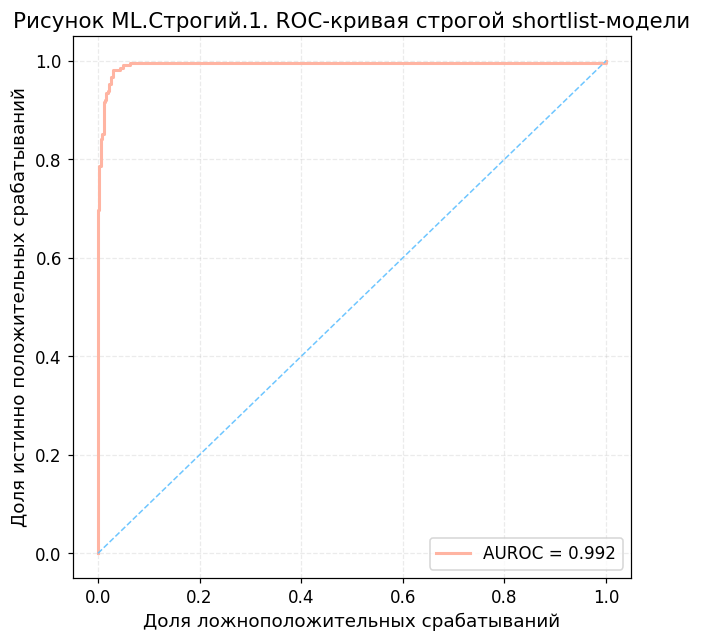

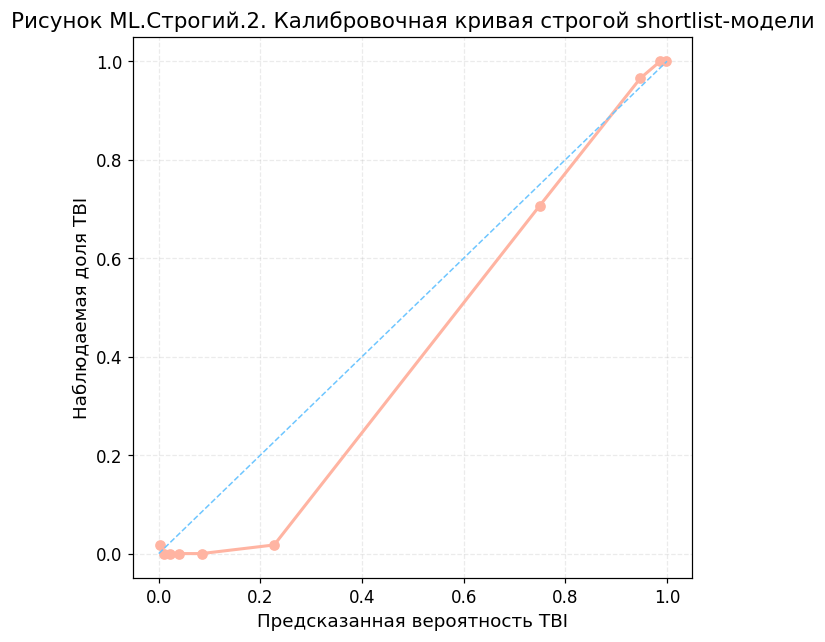

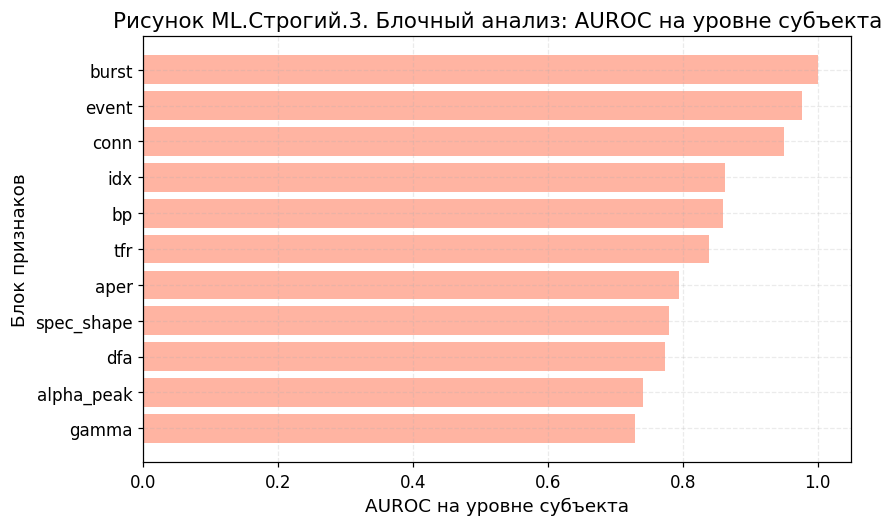

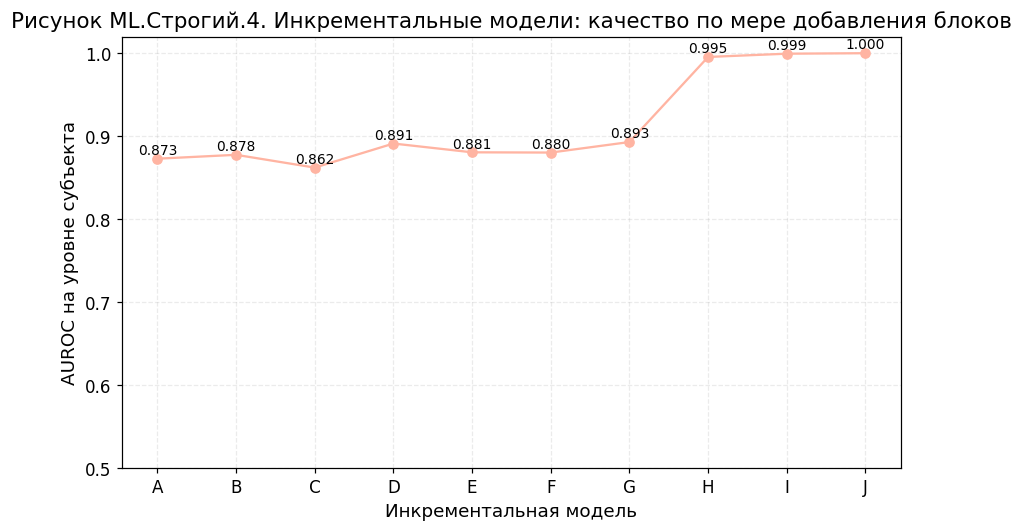

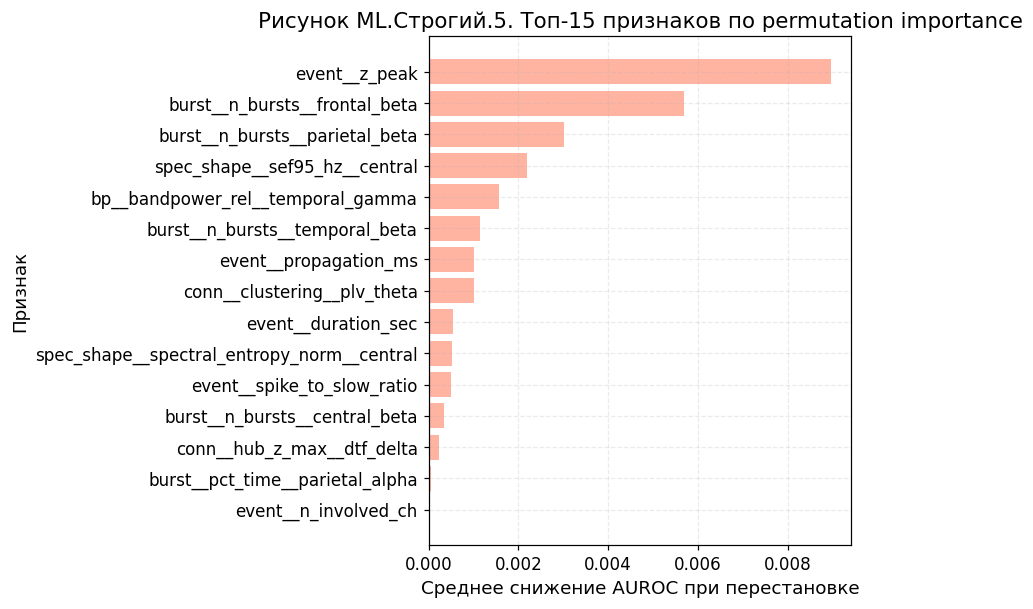

Строгие рисунки сохранены в: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/figures


In [ ]:

# @title X.11 Строгие итоговые рисунки


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

OUT_STRICT_FIG_ROC = STRICT_FIG_DIR / "fig_strict_roc_shortlist.png"
OUT_STRICT_FIG_CAL = STRICT_FIG_DIR / "fig_strict_calibration_shortlist.png"
OUT_STRICT_FIG_BLOCK = STRICT_FIG_DIR / "fig_strict_blockwise_subject_auc.png"
OUT_STRICT_FIG_INCREMENT = STRICT_FIG_DIR / "fig_strict_incremental_subject_auc.png"
OUT_STRICT_FIG_PI = STRICT_FIG_DIR / "fig_strict_permutation_importance_top15.png"

# -----------------------------
# 1. ROC-кривая
# -----------------------------
y_true = df_strict_short_oof["target"].astype(int).values
y_prob = df_strict_short_oof["pred_proba_tbi"].astype(float).values

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = safe_auc(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Доля ложноположительных срабатываний")
plt.ylabel("Доля истинно положительных срабатываний")
plt.title("Рисунок ML.Строгий.1. ROC-кривая строгой shortlist-модели")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_STRICT_FIG_ROC, dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 2. Калибровка
# -----------------------------
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Предсказанная вероятность TBI")
plt.ylabel("Наблюдаемая доля TBI")
plt.title("Рисунок ML.Строгий.2. Калибровочная кривая строгой shortlist-модели")
plt.tight_layout()
plt.savefig(OUT_STRICT_FIG_CAL, dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 3. Блочный анализ
# -----------------------------
if len(df_strict_blockwise_summary) > 0:
    df_plot_block = df_strict_blockwise_summary.sort_values("AUROC_subject_oof", ascending=True)

    plt.figure(figsize=(8, max(4, 0.45 * len(df_plot_block))))
    plt.barh(df_plot_block["block"], df_plot_block["AUROC_subject_oof"])
    plt.xlabel("AUROC на уровне субъекта")
    plt.ylabel("Блок признаков")
    plt.title("Рисунок ML.Строгий.3. Блочный анализ: AUROC на уровне субъекта")
    plt.tight_layout()
    plt.savefig(OUT_STRICT_FIG_BLOCK, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# 4. Инкрементальные модели
# -----------------------------
if len(df_strict_incremental_summary) > 0:
    df_plot_inc = df_strict_incremental_summary.copy()
    df_plot_inc["order"] = df_plot_inc["model"].map({m: i for i, m in enumerate(sorted(df_plot_inc["model"].unique()), start=1)})
    df_plot_inc = df_plot_inc.sort_values("order").reset_index(drop=True)

    plt.figure(figsize=(8, 5))
    plt.plot(df_plot_inc["model"], df_plot_inc["AUROC_subject_oof"], marker="o")
    for i, row in df_plot_inc.iterrows():
        plt.text(i, row["AUROC_subject_oof"] + 0.005, f"{row['AUROC_subject_oof']:.3f}", ha="center", fontsize=9)
    plt.ylim(0.5, 1.02)
    plt.xlabel("Инкрементальная модель")
    plt.ylabel("AUROC на уровне субъекта")
    plt.title("Рисунок ML.Строгий.4. Инкрементальные модели: качество по мере добавления блоков")
    plt.tight_layout()
    plt.savefig(OUT_STRICT_FIG_INCREMENT, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# 5. Permutation importance
# -----------------------------
if len(df_pi_mean) > 0:
    df_plot_pi = df_pi_mean.head(15).sort_values("importance_mean", ascending=True)

    plt.figure(figsize=(8, max(4, 0.38 * len(df_plot_pi))))
    plt.barh(df_plot_pi["feature"], df_plot_pi["importance_mean"])
    plt.xlabel("Среднее снижение AUROC при перестановке")
    plt.ylabel("Признак")
    plt.title("Рисунок ML.Строгий.5. Топ-15 признаков по permutation importance")
    plt.tight_layout()
    plt.savefig(OUT_STRICT_FIG_PI, dpi=300, bbox_inches="tight")
    plt.show()

print("Строгие рисунки сохранены в:", STRICT_FIG_DIR)


In [ ]:

# @title X.12 Документирование научной строгости confirmatory-контура


from pathlib import Path
import pandas as pd

OUT_STRICT_VALIDATION_DOC = STRICT_TAB_DIR / "strict_pipeline_correctness_check.csv"
OUT_STRICT_REGISTRY = STRICT_TAB_DIR / "strict_figure_registry.csv"

df_strict_doc = pd.DataFrame([
    {
        "check": "group_split_by_subject_id",
        "status": "ok",
        "comment": "Во всех строгих confirmatory-анализах внешний и внутренний контуры используют StratifiedGroupKFold по subject_id."
    },
    {
        "check": "feature_selection_inside_outer_cv",
        "status": "ok",
        "comment": "Однофакторный screening выполняется отдельно на train-части каждого outer fold."
    },
    {
        "check": "correlation_pruning_inside_outer_cv",
        "status": "ok",
        "comment": "Корреляционное pruning выполняется только на train-части каждого outer fold."
    },
    {
        "check": "hyperparameter_tuning_inside_inner_cv",
        "status": "ok",
        "comment": "Подбор гиперпараметров выполняется только во внутреннем контуре cross-validation."
    },
    {
        "check": "record_and_subject_metrics_reported",
        "status": "ok",
        "comment": "Для основной строгой модели сохраняются метрики как на уровне записей, так и на уровне субъектов."
    },
    {
        "check": "exploratory_vs_confirmatory_separation",
        "status": "ok",
        "comment": "Exploratory-разделы сохранены отдельно; confirmatory-контур вынесен в раздел X и рекомендован как основной для интерпретации."
    },
    {
        "check": "remaining_limitation_no_external_holdout",
        "status": "warning",
        "comment": "Несмотря на строгий nested CV, в ноутбуке не выделен полностью независимый внешний holdout-набор по субъектам."
    },
])

df_registry = pd.DataFrame([
    {"figure_id": "Рисунок ML.Строгий.1", "title_ru": "ROC-кривая строгой shortlist-модели", "path": str(OUT_STRICT_FIG_ROC)},
    {"figure_id": "Рисунок ML.Строгий.2", "title_ru": "Калибровочная кривая строгой shortlist-модели", "path": str(OUT_STRICT_FIG_CAL)},
    {"figure_id": "Рисунок ML.Строгий.3", "title_ru": "Блочный анализ: AUROC на уровне субъекта", "path": str(OUT_STRICT_FIG_BLOCK)},
    {"figure_id": "Рисунок ML.Строгий.4", "title_ru": "Инкрементальные модели: качество по мере добавления блоков", "path": str(OUT_STRICT_FIG_INCREMENT)},
    {"figure_id": "Рисунок ML.Строгий.5", "title_ru": "Топ-15 признаков по permutation importance", "path": str(OUT_STRICT_FIG_PI)},
])

df_strict_doc.to_csv(OUT_STRICT_VALIDATION_DOC, index=False, encoding="utf-8")
df_registry.to_csv(OUT_STRICT_REGISTRY, index=False, encoding="utf-8")

print("Документ строгой корректности pipeline:", OUT_STRICT_VALIDATION_DOC)
display(df_strict_doc)
print("\nРеестр строгих рисунков:", OUT_STRICT_REGISTRY)
display(df_registry)


Документ строгой корректности pipeline: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_pipeline_correctness_check.csv


,check,status,comment
0,group_split_by_subject_id,ok,Во всех строгих confirmatory-анализах внешний ...
1,feature_selection_inside_outer_cv,ok,Однофакторный screening выполняется отдельно н...
2,correlation_pruning_inside_outer_cv,ok,Корреляционное pruning выполняется только на t...
3,hyperparameter_tuning_inside_inner_cv,ok,Подбор гиперпараметров выполняется только во в...
4,record_and_subject_metrics_reported,ok,Для основной строгой модели сохраняются метрик...
5,exploratory_vs_confirmatory_separation,ok,Exploratory-разделы сохранены отдельно; confir...
6,remaining_limitation_no_external_holdout,warning,"Несмотря на строгий nested CV, в ноутбуке не в..."



Реестр строгих рисунков: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/strict_confirmatory/tables/strict_figure_registry.csv


,figure_id,title_ru,path
0,Рисунок ML.Строгий.1,ROC-кривая строгой shortlist-модели,/content/drive/MyDrive/VKR/TBI/work/output/spe...
1,Рисунок ML.Строгий.2,Калибровочная кривая строгой shortlist-модели,/content/drive/MyDrive/VKR/TBI/work/output/spe...
2,Рисунок ML.Строгий.3,Блочный анализ: AUROC на уровне субъекта,/content/drive/MyDrive/VKR/TBI/work/output/spe...
3,Рисунок ML.Строгий.4,Инкрементальные модели: качество по мере добав...,/content/drive/MyDrive/VKR/TBI/work/output/spe...
4,Рисунок ML.Строгий.5,Топ-15 признаков по permutation importance,/content/drive/MyDrive/VKR/TBI/work/output/spe...


## XI. Третий вариант: внешний holdout-контур максимальной научной строгости

В этом разделе добавляется **наиболее строгий вариант ML-валидации**:

- сначала по `subject_id` выделяется **полностью внешний holdout-набор**;
- все решения по отбору признаков, pruning и гиперпараметрам принимаются **только на development-наборе**;
- основной кандидатный набор для главной модели задаётся **без наследования exploratory-shortlist** — из полного допустимого пространства `X_cand`;
- holdout используется только один раз для финальной проверки уже выбранной схемы.

Таким образом, раздел XI не заменяет exploratory- и strict-confirmatory-контуры выше, а даёт **самую независимую финальную оценку**.

In [ ]:
# @title XI.1 Внешний holdout по subject_id: разбиение и документирование


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit

EXT_DIR = OUT_ML_DIR / "external_holdout_confirmatory"
EXT_DIR.mkdir(parents=True, exist_ok=True)

EXT_FIG_DIR = EXT_DIR / "figures"
EXT_FIG_DIR.mkdir(parents=True, exist_ok=True)

EXT_TAB_DIR = EXT_DIR / "tables"
EXT_TAB_DIR.mkdir(parents=True, exist_ok=True)

OUT_EXT_SUBJECT_SPLIT = EXT_TAB_DIR / "external_holdout_subject_split.csv"
OUT_EXT_DEV_META = EXT_TAB_DIR / "external_holdout_meta_development.csv"
OUT_EXT_HOLD_META = EXT_TAB_DIR / "external_holdout_meta_holdout.csv"
OUT_EXT_SPLIT_SUMMARY = EXT_TAB_DIR / "external_holdout_split_summary.csv"

# ---------------------------------------------------------
# Настройки внешнего holdout
# ---------------------------------------------------------
HOLDOUT_FRAC = 0.20
HOLDOUT_RANDOM_STATE = 42

# Внешний holdout строим на уровне субъектов
assert "subject_id" in meta_strict.columns, "В meta_strict нет subject_id"
assert "target" in meta_strict.columns, "В meta_strict нет target"
assert "group" in meta_strict.columns, "В meta_strict нет group"

subject_df = (
    meta_strict.groupby("subject_id", as_index=False)
    .agg(
        target=("target", "first"),
        group=("group", "first"),
        n_records=("record_id", "nunique"),
        n_conditions=("condition", "nunique") if "condition" in meta_strict.columns else ("record_id", "nunique"),
    )
    .sort_values(["group", "subject_id"])
    .reset_index(drop=True)
)

assert subject_df["target"].nunique() == 2, "Для holdout нужны обе группы"

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=HOLDOUT_FRAC,
    random_state=HOLDOUT_RANDOM_STATE,
)

idx_dev, idx_hold = next(sss.split(subject_df["subject_id"], subject_df["target"]))

subjects_dev = set(subject_df.iloc[idx_dev]["subject_id"].astype(str).tolist())
subjects_hold = set(subject_df.iloc[idx_hold]["subject_id"].astype(str).tolist())

assert len(subjects_dev.intersection(subjects_hold)) == 0, "Есть пересечение субъектов между DEV и HOLDOUT"

subject_df["split"] = np.where(
    subject_df["subject_id"].astype(str).isin(subjects_hold),
    "holdout",
    "development",
)
subject_df.to_csv(OUT_EXT_SUBJECT_SPLIT, index=False, encoding="utf-8")

meta_dev = (
    meta_strict.loc[meta_strict["subject_id"].astype(str).isin(subjects_dev)]
    .reset_index(drop=True)
    .copy()
)
meta_hold = (
    meta_strict.loc[meta_strict["subject_id"].astype(str).isin(subjects_hold)]
    .reset_index(drop=True)
    .copy()
)

# Согласованно режем X_cand по record_id
dev_record_ids = set(meta_dev["record_id"].astype(str))
hold_record_ids = set(meta_hold["record_id"].astype(str))

assert len(dev_record_ids.intersection(hold_record_ids)) == 0, "Есть пересечение record_id между DEV и HOLDOUT"

# Предполагаем согласованный порядок строк между X_cand и meta_strict
X_dev = X_cand.loc[meta_strict["record_id"].astype(str).isin(dev_record_ids)].reset_index(drop=True).copy()
X_hold = X_cand.loc[meta_strict["record_id"].astype(str).isin(hold_record_ids)].reset_index(drop=True).copy()

# Переставляем meta так, чтобы порядок record_id совпадал с X
meta_dev = (
    meta_dev.set_index("record_id")
    .loc[X_cand.loc[meta_strict["record_id"].astype(str).isin(dev_record_ids), "record_id"].astype(str).tolist()]
    .reset_index()
)
meta_hold = (
    meta_hold.set_index("record_id")
    .loc[X_cand.loc[meta_strict["record_id"].astype(str).isin(hold_record_ids), "record_id"].astype(str).tolist()]
    .reset_index()
)

assert list(meta_dev["record_id"].astype(str)) == list(
    X_cand.loc[meta_strict["record_id"].astype(str).isin(dev_record_ids), "record_id"].astype(str)
), "Нарушено соответствие X_dev и meta_dev"
assert list(meta_hold["record_id"].astype(str)) == list(
    X_cand.loc[meta_strict["record_id"].astype(str).isin(hold_record_ids), "record_id"].astype(str)
), "Нарушено соответствие X_hold и meta_hold"

meta_dev.to_csv(OUT_EXT_DEV_META, index=False, encoding="utf-8")
meta_hold.to_csv(OUT_EXT_HOLD_META, index=False, encoding="utf-8")

split_rows = [
    {
        "part": "development",
        "n_records": int(len(meta_dev)),
        "n_subjects": int(meta_dev["subject_id"].nunique()),
        "n_TBI_subjects": int(meta_dev.loc[meta_dev["target"] == 1, "subject_id"].nunique()),
        "n_Control_subjects": int(meta_dev.loc[meta_dev["target"] == 0, "subject_id"].nunique()),
    },
    {
        "part": "holdout",
        "n_records": int(len(meta_hold)),
        "n_subjects": int(meta_hold["subject_id"].nunique()),
        "n_TBI_subjects": int(meta_hold.loc[meta_hold["target"] == 1, "subject_id"].nunique()),
        "n_Control_subjects": int(meta_hold.loc[meta_hold["target"] == 0, "subject_id"].nunique()),
    },
]
df_ext_split_summary = pd.DataFrame(split_rows)
df_ext_split_summary.to_csv(OUT_EXT_SPLIT_SUMMARY, index=False, encoding="utf-8")

print("Разбиение на development / holdout сохранено:")
print("Subjects:", OUT_EXT_SUBJECT_SPLIT)
print("DEV meta:", OUT_EXT_DEV_META)
print("HOLD meta:", OUT_EXT_HOLD_META)
print("Summary:", OUT_EXT_SPLIT_SUMMARY)

display(df_ext_split_summary)
display(subject_df.groupby(["split", "group"], as_index=False).agg(n_subjects=("subject_id", "nunique")))


KeyError: 'record_id'

### XI.a Логика внешнего holdout-контурa

Ниже используются две идеи:

1. **Development-only decision making**  
   Все решения об отборе признаков и настройке модели принимаются только на development-части.

2. **Single final look at holdout**  
   Holdout не участвует ни в выборе признаков, ни в tuning, ни в сравнении моделей и используется только для финальной независимой оценки.


In [ ]:
# @title XI.2 Вспомогательные функции: финальное обучение на development и оценка holdout


import json
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.inspection import permutation_importance

OUT_EXT_FINAL_FEATURE_RANK = EXT_TAB_DIR / "external_holdout_final_feature_rank.csv"
OUT_EXT_FINAL_PRUNE = EXT_TAB_DIR / "external_holdout_final_pruned_pairs.csv"

def fit_final_model_on_development(
    X_dev_df,
    meta_dev_df,
    model_name="logreg_l2",
    candidate_features=None,
    n_inner=5,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=15,
    screening_max_keep=80,
    corr_thr=0.90,
):
    """
    Финальная сборка модели только по development-набору:
    1) selection только на DEV,
    2) inner CV только на DEV,
    3) обучение лучшей модели на всём DEV.
    """
    assert "target" in meta_dev_df.columns, "В meta_dev_df нет target"
    assert "subject_id" in meta_dev_df.columns, "В meta_dev_df нет subject_id"

    if candidate_features is None:
        candidate_features = list(X_dev_df.columns)

    candidate_features = [f for f in candidate_features if f in X_dev_df.columns]
    assert len(candidate_features) > 0, "Нет candidate_features для обучения на development"

    X_dev_raw = X_dev_df[candidate_features].copy()
    y_dev = meta_dev_df["target"].astype(int).values
    groups_dev = meta_dev_df["subject_id"].astype(str).values

    selected_final, df_rank_dev, dropped_pairs = select_features_train_only(
        X_train=X_dev_raw,
        y_train=y_dev,
        screening_p_thr=screening_p_thr,
        screening_min_keep=screening_min_keep,
        screening_max_keep=screening_max_keep,
        corr_thr=corr_thr,
    )

    if len(selected_final) == 0:
        selected_final = list(candidate_features)

    X_dev_sel = X_dev_raw[selected_final].copy()

    inner_cv = StratifiedGroupKFold(
        n_splits=n_inner,
        shuffle=True,
        random_state=random_state,
    )

    base_pipe, param_grid = make_model_and_grid_strict(model_name)

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv.split(X_dev_sel, y_dev, groups_dev),
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    grid.fit(X_dev_sel, y_dev)

    best_model = grid.best_estimator_

    return {
        "model": best_model,
        "selected_features": selected_final,
        "df_rank": df_rank_dev,
        "df_prune": pd.DataFrame(dropped_pairs),
        "best_params": grid.best_params_,
        "n_features_final": len(selected_final),
        "candidate_features": list(candidate_features),
    }


def evaluate_model_on_holdout(
    fitted_model,
    selected_features,
    X_hold_df,
    meta_hold_df,
):
    """
    Независимая оценка на holdout.
    Возвращает record-level и subject-level прогнозы и метрики.
    """
    assert len(selected_features) > 0, "Список selected_features пуст"
    use_features = [f for f in selected_features if f in X_hold_df.columns]
    assert len(use_features) > 0, "В holdout не найдено ни одного selected feature"

    X_hold_sel = X_hold_df[use_features].copy()
    y_hold = meta_hold_df["target"].astype(int).values
    groups_hold = meta_hold_df["subject_id"].astype(str).values

    prob = fitted_model.predict_proba(X_hold_sel)[:, 1]
    pred = (prob >= 0.5).astype(int)

    df_hold_pred = meta_hold_df[["record_id", "subject_id", "group", "target"]].copy()
    if "condition" in meta_hold_df.columns:
        df_hold_pred["condition"] = meta_hold_df["condition"].astype(str)
    df_hold_pred["y_score"] = prob
    df_hold_pred["y_pred"] = pred

    auc_rec = safe_auc(df_hold_pred["target"].values, df_hold_pred["y_score"].values)
    bal_rec = safe_bal_acc(df_hold_pred["target"].values, df_hold_pred["y_pred"].values)
    stats_rec = safe_confusion_stats(df_hold_pred["target"].values, df_hold_pred["y_pred"].values)

    df_hold_subj = aggregate_oof_to_subject(df_hold_pred)
    auc_subj = safe_auc(df_hold_subj["y_true"].values, df_hold_subj["y_score"].values)
    bal_subj = safe_bal_acc(df_hold_subj["y_true"].values, df_hold_subj["y_pred"].values)
    stats_subj = safe_confusion_stats(df_hold_subj["y_true"].values, df_hold_subj["y_pred"].values)

    rows = [
        {"level": "record", "metric": "roc_auc", "value": auc_rec},
        {"level": "record", "metric": "balanced_accuracy", "value": bal_rec},
        {"level": "record", "metric": "accuracy", "value": stats_rec.get("accuracy")},
        {"level": "record", "metric": "precision", "value": stats_rec.get("precision")},
        {"level": "record", "metric": "recall", "value": stats_rec.get("recall")},
        {"level": "record", "metric": "specificity", "value": stats_rec.get("specificity")},
        {"level": "record", "metric": "f1", "value": stats_rec.get("f1")},
        {"level": "subject", "metric": "roc_auc", "value": auc_subj},
        {"level": "subject", "metric": "balanced_accuracy", "value": bal_subj},
        {"level": "subject", "metric": "accuracy", "value": stats_subj.get("accuracy")},
        {"level": "subject", "metric": "precision", "value": stats_subj.get("precision")},
        {"level": "subject", "metric": "recall", "value": stats_subj.get("recall")},
        {"level": "subject", "metric": "specificity", "value": stats_subj.get("specificity")},
        {"level": "subject", "metric": "f1", "value": stats_subj.get("f1")},
    ]
    df_metrics = pd.DataFrame(rows)

    return df_metrics, df_hold_pred, df_hold_subj


def run_dev_nested_compare(
    X_dev_df,
    meta_dev_df,
    model_list,
    candidate_features,
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=20,
    screening_max_keep=100,
    corr_thr=0.90,
):
    """
    Сравнение моделей ТОЛЬКО на development.
    Holdout здесь не используется вообще.
    """
    rows_summary = []
    rows_folds = []
    rows_params = []

    for model_name in model_list:
        print(f"\n=== DEV-only nested compare | {model_name} ===")

        df_summary_m, df_fold_m, df_params_m, df_oof_m, df_sel_m, df_prune_m, df_rank_m, df_subj_m = run_nested_group_cv_strict(
            X_df=X_dev_df,
            meta_df=meta_dev_df,
            model_name=model_name,
            candidate_features=candidate_features,
            n_outer=n_outer,
            n_inner=n_inner,
            random_state=random_state,
            screening_p_thr=screening_p_thr,
            screening_min_keep=screening_min_keep,
            screening_max_keep=screening_max_keep,
            corr_thr=corr_thr,
        )

        summary_map = dict(zip(df_summary_m["metric"], df_summary_m["value"]))
        rows_summary.append({
            "model": model_name,
            "dev_record_auc_oof": summary_map.get("roc_auc_oof_record_level"),
            "dev_subject_auc_oof": summary_map.get("roc_auc_oof_subject_level"),
            "dev_record_bal_acc_oof": summary_map.get("balanced_accuracy_oof_record_level"),
            "dev_subject_bal_acc_oof": summary_map.get("balanced_accuracy_oof_subject_level"),
            "mean_n_features_final": summary_map.get("mean_n_features_final"),
        })

        df_fold_m = df_fold_m.copy()
        df_fold_m["model"] = model_name
        rows_folds.append(df_fold_m)

        df_params_m = df_params_m.copy()
        df_params_m["model"] = model_name
        rows_params.append(df_params_m)

    df_compare_summary = pd.DataFrame(rows_summary).sort_values(
        ["dev_subject_auc_oof", "dev_record_auc_oof", "model"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    df_compare_folds = pd.concat(rows_folds, ignore_index=True) if len(rows_folds) > 0 else pd.DataFrame()
    df_compare_params = pd.concat(rows_params, ignore_index=True) if len(rows_params) > 0 else pd.DataFrame()

    return df_compare_summary, df_compare_folds, df_compare_params


In [ ]:
# @title XI.3 DEV-only nested сравнение моделей на полном пространстве кандидатных признаков

from pathlib import Path
import pandas as pd

OUT_EXT_DEV_COMPARE_SUMMARY = EXT_TAB_DIR / "external_holdout_dev_model_compare_summary.csv"
OUT_EXT_DEV_COMPARE_FOLDS = EXT_TAB_DIR / "external_holdout_dev_model_compare_folds.csv"
OUT_EXT_DEV_COMPARE_PARAMS = EXT_TAB_DIR / "external_holdout_dev_model_compare_params.csv"

# Основной confirmatory-вариант заранее фиксируем как logreg_l2.
# Сравнение альтернативных моделей оставляем как DEV-only auxiliary analysis.
PRIMARY_EXT_MODEL_NAME = "logreg_l2"

model_list_ext = ["logreg_l2", "logreg_elasticnet", "random_forest", "hist_gb"]
if HAS_XGBOOST_STRICT:
    model_list_ext.append("xgboost")

full_candidate_features_ext = list(X_dev.columns)

df_ext_dev_compare_summary, df_ext_dev_compare_folds, df_ext_dev_compare_params = run_dev_nested_compare(
    X_dev_df=X_dev,
    meta_dev_df=meta_dev,
    model_list=model_list_ext,
    candidate_features=full_candidate_features_ext,
    n_outer=5,
    n_inner=3,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=20,
    screening_max_keep=100,
    corr_thr=0.90,
)

df_ext_dev_compare_summary.to_csv(OUT_EXT_DEV_COMPARE_SUMMARY, index=False, encoding="utf-8")
df_ext_dev_compare_folds.to_csv(OUT_EXT_DEV_COMPARE_FOLDS, index=False, encoding="utf-8")
df_ext_dev_compare_params.to_csv(OUT_EXT_DEV_COMPARE_PARAMS, index=False, encoding="utf-8")

print("DEV-only сравнение моделей сохранено:")
print("Summary:", OUT_EXT_DEV_COMPARE_SUMMARY)
display(df_ext_dev_compare_summary)


In [ ]:
# @title XI.3b Сохранить development summary-таблицу сравнения моделей из переменной


from pathlib import Path
import pandas as pd

# =========================================================
# 0. Куда сохраняем
# =========================================================
OUT_EXT_MODEL_COMPARE = EXT_TAB_DIR / "external_holdout_model_compare.csv"

# Ожидаемые колонки summary-таблицы
required_cols = {
    "model",
    "dev_record_auc_oof",
    "dev_subject_auc_oof",
    "dev_record_bal_acc_oof",
    "dev_subject_bal_acc_oof",
}

# Кандидатные имена переменных в памяти
candidate_var_names = [
    "df_ext_compare",
    "df_ext_model_compare",
    "df_dev_model_compare",
    "df_model_compare_ext",
    "df_external_model_compare",
]

found_name = None
found_df = None

# =========================================================
# 1. Ищем подходящую DataFrame в памяти
# =========================================================
for var_name in candidate_var_names:
    if var_name in globals():
        obj = globals()[var_name]

        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            # Берём только ту таблицу, где есть модель и OOF-метрики
            if required_cols.issubset(cols):
                found_name = var_name
                found_df = obj.copy()
                break

# =========================================================
# 2. Сохраняем, если нашли
# =========================================================
if found_df is None:
    print("Подходящая summary-таблица в памяти не найдена.")
    print("Искались переменные:", ", ".join(candidate_var_names))
    print()
    print("Нужны колонки:")
    for c in sorted(required_cols):
        print(" -", c)
else:
    found_df.to_csv(OUT_EXT_MODEL_COMPARE, index=False, encoding="utf-8")

    print("Файл сохранён:", OUT_EXT_MODEL_COMPARE)
    print("Источник переменной:", found_name)
    print("Размер таблицы:", found_df.shape)
    print("Колонки:")
    for c in found_df.columns:
        print(" -", c)

    display(found_df.head(20))

In [ ]:
# @title XI.3c Сохранить df_ext_compare в CSV


OUT_EXT_MODEL_COMPARE = EXT_TAB_DIR / "external_holdout_model_compare.csv"

assert "df_ext_compare" in globals(), "Переменная df_ext_compare не найдена в памяти."

df_ext_compare.to_csv(OUT_EXT_MODEL_COMPARE, index=False, encoding="utf-8")

print("Файл сохранён:", OUT_EXT_MODEL_COMPARE)
display(df_ext_compare.head(20))

In [ ]:
# @title XI.4 Финальная внешняя holdout-модель без наследования shortlist


from pathlib import Path
import json
import pandas as pd

OUT_EXT_FINAL_METRICS = EXT_TAB_DIR / "external_holdout_final_metrics.csv"
OUT_EXT_FINAL_PRED_RECORD = EXT_TAB_DIR / "external_holdout_predictions_record.csv"
OUT_EXT_FINAL_PRED_SUBJECT = EXT_TAB_DIR / "external_holdout_predictions_subject.csv"
OUT_EXT_FINAL_SELECTED = EXT_TAB_DIR / "external_holdout_selected_features.csv"
OUT_EXT_FINAL_PARAMS = EXT_TAB_DIR / "external_holdout_best_params.json"

final_fit_ext = fit_final_model_on_development(
    X_dev_df=X_dev,
    meta_dev_df=meta_dev,
    model_name=PRIMARY_EXT_MODEL_NAME,
    candidate_features=full_candidate_features_ext,
    n_inner=5,
    random_state=42,
    screening_p_thr=0.10,
    screening_min_keep=20,
    screening_max_keep=100,
    corr_thr=0.90,
)

df_ext_final_metrics, df_ext_hold_pred_record, df_ext_hold_pred_subject = evaluate_model_on_holdout(
    fitted_model=final_fit_ext["model"],
    selected_features=final_fit_ext["selected_features"],
    X_hold_df=X_hold,
    meta_hold_df=meta_hold,
)

df_ext_selected = pd.DataFrame({
    "feature": final_fit_ext["selected_features"],
    "selection_stage": "development_only_final_fit",
})

final_fit_ext["df_rank"].to_csv(OUT_EXT_FINAL_FEATURE_RANK, index=False, encoding="utf-8")
final_fit_ext["df_prune"].to_csv(OUT_EXT_FINAL_PRUNE, index=False, encoding="utf-8")
df_ext_final_metrics.to_csv(OUT_EXT_FINAL_METRICS, index=False, encoding="utf-8")
df_ext_hold_pred_record.to_csv(OUT_EXT_FINAL_PRED_RECORD, index=False, encoding="utf-8")
df_ext_hold_pred_subject.to_csv(OUT_EXT_FINAL_PRED_SUBJECT, index=False, encoding="utf-8")
df_ext_selected.to_csv(OUT_EXT_FINAL_SELECTED, index=False, encoding="utf-8")

with open(OUT_EXT_FINAL_PARAMS, "w", encoding="utf-8") as f:
    json.dump(final_fit_ext["best_params"], f, ensure_ascii=False, indent=2)

print("Финальная external holdout-модель готова")
print("Модель:", PRIMARY_EXT_MODEL_NAME)
print("Число выбранных признаков:", final_fit_ext["n_features_final"])
print("Метрики:", OUT_EXT_FINAL_METRICS)
print("Selected features:", OUT_EXT_FINAL_SELECTED)

display(df_ext_final_metrics)
display(df_ext_selected.head(30))


In [ ]:
# @title XI.5 External holdout sensitivity-анализ: только EyesClosed

from pathlib import Path
import pandas as pd

OUT_EXT_EC_METRICS = EXT_TAB_DIR / "external_holdout_eyesclosed_metrics.csv"
OUT_EXT_EC_SELECTED = EXT_TAB_DIR / "external_holdout_eyesclosed_selected_features.csv"

if "condition" not in meta_dev.columns or "condition" not in meta_hold.columns:
    print("Колонка condition отсутствует: EyesClosed sensitivity пропущен.")
else:
    meta_dev_ec = meta_dev.loc[meta_dev["condition"].astype(str) == "EyesClosed"].reset_index(drop=True).copy()
    meta_hold_ec = meta_hold.loc[meta_hold["condition"].astype(str) == "EyesClosed"].reset_index(drop=True).copy()

    if len(meta_dev_ec) == 0 or len(meta_hold_ec) == 0:
        print("EyesClosed subset пуст хотя бы в одной части: анализ пропущен.")
    elif meta_dev_ec["subject_id"].nunique() < 10 or meta_hold_ec["subject_id"].nunique() < 4:
        print("Слишком мало субъектов для устойчивого EyesClosed-holdout анализа: анализ пропущен.")
    else:
        X_dev_ec = X_dev.loc[meta_dev.index[meta_dev["condition"].astype(str) == "EyesClosed"]].reset_index(drop=True).copy()
        X_hold_ec = X_hold.loc[meta_hold.index[meta_hold["condition"].astype(str) == "EyesClosed"]].reset_index(drop=True).copy()

        fit_ext_ec = fit_final_model_on_development(
            X_dev_df=X_dev_ec,
            meta_dev_df=meta_dev_ec,
            model_name=PRIMARY_EXT_MODEL_NAME,
            candidate_features=list(X_dev_ec.columns),
            n_inner=5,
            random_state=42,
            screening_p_thr=0.20,
            screening_min_keep=10,
            screening_max_keep=60,
            corr_thr=0.90,
        )

        df_ext_ec_metrics, df_ext_ec_pred_record, df_ext_ec_pred_subject = evaluate_model_on_holdout(
            fitted_model=fit_ext_ec["model"],
            selected_features=fit_ext_ec["selected_features"],
            X_hold_df=X_hold_ec,
            meta_hold_df=meta_hold_ec,
        )

        df_ext_ec_selected = pd.DataFrame({"feature": fit_ext_ec["selected_features"]})

        df_ext_ec_metrics.to_csv(OUT_EXT_EC_METRICS, index=False, encoding="utf-8")
        df_ext_ec_selected.to_csv(OUT_EXT_EC_SELECTED, index=False, encoding="utf-8")

        print("EyesClosed external holdout metrics:", OUT_EXT_EC_METRICS)
        display(df_ext_ec_metrics)


In [ ]:
# @title XI.6 External holdout блочный анализ


from pathlib import Path
import pandas as pd

OUT_EXT_BLOCKWISE = EXT_TAB_DIR / "external_holdout_blockwise_summary.csv"

preferred_order_ext = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
    "other",
]

block_to_features_ext = (
    strict_block_map.groupby("block")["feature"]
    .apply(list)
    .to_dict()
)

ordered_blocks_ext = [b for b in preferred_order_ext if b in block_to_features_ext]
ordered_blocks_ext += [b for b in sorted(block_to_features_ext.keys()) if b not in ordered_blocks_ext]

rows_ext_block = []

for block_name in ordered_blocks_ext:
    feats = [f for f in block_to_features_ext.get(block_name, []) if f in X_dev.columns]
    if len(feats) < 2:
        continue

    print(f"\n=== External holdout blockwise | {block_name} | n={len(feats)} ===")

    fit_block = fit_final_model_on_development(
        X_dev_df=X_dev,
        meta_dev_df=meta_dev,
        model_name=PRIMARY_EXT_MODEL_NAME,
        candidate_features=feats,
        n_inner=5,
        random_state=42,
        screening_p_thr=0.20,
        screening_min_keep=min(10, len(feats)),
        screening_max_keep=len(feats),
        corr_thr=0.90,
    )

    df_block_metrics, df_block_pred_record, df_block_pred_subject = evaluate_model_on_holdout(
        fitted_model=fit_block["model"],
        selected_features=fit_block["selected_features"],
        X_hold_df=X_hold,
        meta_hold_df=meta_hold,
    )

    subj_auc = df_block_metrics.loc[
        (df_block_metrics["level"] == "subject") & (df_block_metrics["metric"] == "roc_auc"),
        "value"
    ].iloc[0]
    subj_bal = df_block_metrics.loc[
        (df_block_metrics["level"] == "subject") & (df_block_metrics["metric"] == "balanced_accuracy"),
        "value"
    ].iloc[0]

    rows_ext_block.append({
        "block": block_name,
        "n_candidate_features": len(feats),
        "n_selected_features": fit_block["n_features_final"],
        "holdout_subject_auc": subj_auc,
        "holdout_subject_bal_acc": subj_bal,
    })

df_ext_blockwise = pd.DataFrame(rows_ext_block).sort_values(
    ["holdout_subject_auc", "holdout_subject_bal_acc", "block"],
    ascending=[False, False, True],
).reset_index(drop=True)

df_ext_blockwise.to_csv(OUT_EXT_BLOCKWISE, index=False, encoding="utf-8")
print("External holdout blockwise summary:", OUT_EXT_BLOCKWISE)
display(df_ext_blockwise)


In [ ]:
# @title XI.7 External holdout инкрементальные модели (по одному блоку на шаг)


from pathlib import Path
import string
import pandas as pd

OUT_EXT_INCREMENTAL = EXT_TAB_DIR / "external_holdout_incremental_summary.csv"

ordered_blocks_ext_inc = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "event_context",
]
available_blocks_ext = [b for b in ordered_blocks_ext_inc if b in block_to_features_ext]

letters = list(string.ascii_uppercase)
incremental_defs_ext = {}
for i in range(len(available_blocks_ext)):
    incremental_defs_ext[letters[i]] = available_blocks_ext[: i + 1]

rows_inc = []
prev_auc = None

for model_code, blocks in incremental_defs_ext.items():
    feats = []
    for b in blocks:
        feats.extend(block_to_features_ext.get(b, []))
    feats = sorted(set([f for f in feats if f in X_dev.columns]))
    if len(feats) == 0:
        continue

    added_block = blocks[-1]

    print(f"\n=== External holdout incremental | {model_code} | added={added_block} ===")

    fit_inc = fit_final_model_on_development(
        X_dev_df=X_dev,
        meta_dev_df=meta_dev,
        model_name=PRIMARY_EXT_MODEL_NAME,
        candidate_features=feats,
        n_inner=5,
        random_state=42,
        screening_p_thr=0.15,
        screening_min_keep=min(15, len(feats)),
        screening_max_keep=min(100, len(feats)),
        corr_thr=0.90,
    )

    df_inc_metrics, df_inc_pred_record, df_inc_pred_subject = evaluate_model_on_holdout(
        fitted_model=fit_inc["model"],
        selected_features=fit_inc["selected_features"],
        X_hold_df=X_hold,
        meta_hold_df=meta_hold,
    )

    subj_auc = df_inc_metrics.loc[
        (df_inc_metrics["level"] == "subject") & (df_inc_metrics["metric"] == "roc_auc"),
        "value"
    ].iloc[0]
    subj_bal = df_inc_metrics.loc[
        (df_inc_metrics["level"] == "subject") & (df_inc_metrics["metric"] == "balanced_accuracy"),
        "value"
    ].iloc[0]

    rows_inc.append({
        "model": model_code,
        "added_block": added_block,
        "included_blocks": "+".join(blocks),
        "n_candidate_features": len(feats),
        "n_selected_features": fit_inc["n_features_final"],
        "holdout_subject_auc": subj_auc,
        "holdout_subject_bal_acc": subj_bal,
        "delta_auc_vs_prev": None if prev_auc is None else (subj_auc - prev_auc),
    })
    prev_auc = subj_auc

df_ext_incremental = pd.DataFrame(rows_inc)
df_ext_incremental.to_csv(OUT_EXT_INCREMENTAL, index=False, encoding="utf-8")

print("External holdout incremental summary:", OUT_EXT_INCREMENTAL)
display(df_ext_incremental)


In [ ]:
# @title XI.8 External holdout permutation importance для финальной модели


from pathlib import Path
import numpy as np
import pandas as pd

OUT_EXT_PI = EXT_TAB_DIR / "external_holdout_permutation_importance.csv"
OUT_EXT_PI_BLOCK = EXT_TAB_DIR / "external_holdout_permutation_importance_by_block.csv"

def permutation_importance_holdout_auc(
    fitted_model,
    X_hold_df,
    meta_hold_df,
    selected_features,
    n_repeats=30,
    random_state=42,
):
    """
    Простая permutation importance на holdout.
    Основная метрика — ROC-AUC на уровне записей.
    """
    rng = np.random.default_rng(random_state)

    feats = [f for f in selected_features if f in X_hold_df.columns]
    if len(feats) == 0:
        return pd.DataFrame()

    X_eval = X_hold_df[feats].copy()
    y_eval = meta_hold_df["target"].astype(int).values

    base_prob = fitted_model.predict_proba(X_eval)[:, 1]
    base_auc = safe_auc(y_eval, base_prob)

    rows = []
    for feat in feats:
        deltas = []
        for rep in range(n_repeats):
            X_perm = X_eval.copy()
            X_perm[feat] = rng.permutation(X_perm[feat].values)
            prob_perm = fitted_model.predict_proba(X_perm)[:, 1]
            auc_perm = safe_auc(y_eval, prob_perm)
            deltas.append(base_auc - auc_perm)

        rows.append({
            "feature": feat,
            "importance_mean": float(np.nanmean(deltas)),
            "importance_sd": float(np.nanstd(deltas, ddof=1)) if len(deltas) > 1 else np.nan,
            "n_repeats": n_repeats,
        })

    return pd.DataFrame(rows).sort_values(
        ["importance_mean", "feature"],
        ascending=[False, True],
    ).reset_index(drop=True)

df_ext_pi = permutation_importance_holdout_auc(
    fitted_model=final_fit_ext["model"],
    X_hold_df=X_hold,
    meta_hold_df=meta_hold,
    selected_features=final_fit_ext["selected_features"],
    n_repeats=30,
    random_state=42,
)

feat_to_block_ext = dict(zip(strict_block_map["feature"], strict_block_map["block"]))
df_ext_pi["block"] = df_ext_pi["feature"].map(feat_to_block_ext).fillna("other")

df_ext_pi_block = (
    df_ext_pi.groupby("block", as_index=False)
    .agg(
        importance_mean=("importance_mean", "mean"),
        importance_sd=("importance_mean", "std"),
        n_features=("feature", "nunique"),
    )
    .sort_values(["importance_mean", "block"], ascending=[False, True])
    .reset_index(drop=True)
)

df_ext_pi.to_csv(OUT_EXT_PI, index=False, encoding="utf-8")
df_ext_pi_block.to_csv(OUT_EXT_PI_BLOCK, index=False, encoding="utf-8")

print("External holdout permutation importance:", OUT_EXT_PI)
display(df_ext_pi.head(20))
display(df_ext_pi_block)


In [ ]:
# @title XI.9 Итоговые рисунки внешнего holdout-контура

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT_EXT_FIG_ROC = EXT_FIG_DIR / "Рисунок_ML_external_1_ROC_holdout.png"
OUT_EXT_FIG_BLOCK = EXT_FIG_DIR / "Рисунок_ML_external_2_блочный_анализ_holdout.png"
OUT_EXT_FIG_INC = EXT_FIG_DIR / "Рисунок_ML_external_3_инкрементальные_модели_holdout.png"
OUT_EXT_FIG_PI = EXT_FIG_DIR / "Рисунок_ML_external_4_permutation_importance_holdout.png"

# ---------------------------------------------------------
# 1. ROC на holdout
# ---------------------------------------------------------
try:
    from sklearn.metrics import roc_curve, auc

    y_true_hold = df_ext_hold_pred_record["target"].astype(int).values
    y_score_hold = df_ext_hold_pred_record["y_score"].astype(float).values
    fpr, tpr, _ = roc_curve(y_true_hold, y_score_hold)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f"Holdout ROC-AUC = {roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("1 - Специфичность")
    plt.ylabel("Чувствительность")
    plt.title("Рис. ML-ext.1. ROC-кривая финальной модели на внешнем holdout-наборе")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(OUT_EXT_FIG_ROC, dpi=300, bbox_inches="tight")
    plt.close()
except Exception as e:
    print("ROC-рисунок не построен:", e)

# ---------------------------------------------------------
# 2. Блочный анализ
# ---------------------------------------------------------
if "df_ext_blockwise" in globals() and len(df_ext_blockwise) > 0:
    df_plot_block = df_ext_blockwise.sort_values("holdout_subject_auc", ascending=True).copy()

    plt.figure(figsize=(8, max(4, 0.45 * len(df_plot_block))))
    plt.barh(df_plot_block["block"], df_plot_block["holdout_subject_auc"])
    plt.xlabel("ROC-AUC на уровне субъектов")
    plt.ylabel("Блок признаков")
    plt.title("Рис. ML-ext.2. Блочный анализ на внешнем holdout-наборе")
    plt.tight_layout()
    plt.savefig(OUT_EXT_FIG_BLOCK, dpi=300, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# 3. Инкрементальные модели
# ---------------------------------------------------------
if "df_ext_incremental" in globals() and len(df_ext_incremental) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(
        df_ext_incremental["model"].astype(str),
        df_ext_incremental["holdout_subject_auc"].astype(float),
        marker="o",
        linewidth=2,
    )
    for _, row in df_ext_incremental.iterrows():
        plt.annotate(
            str(row["added_block"]),
            (row["model"], row["holdout_subject_auc"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )
    plt.xlabel("Инкрементальная модель")
    plt.ylabel("ROC-AUC на уровне субъектов")
    plt.title("Рис. ML-ext.3. Инкрементальные модели на внешнем holdout-наборе")
    plt.tight_layout()
    plt.savefig(OUT_EXT_FIG_INC, dpi=300, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# 4. Permutation importance
# ---------------------------------------------------------
if "df_ext_pi" in globals() and len(df_ext_pi) > 0:
    df_plot_pi = df_ext_pi.head(15).sort_values("importance_mean", ascending=True).copy()

    plt.figure(figsize=(8, max(4, 0.4 * len(df_plot_pi))))
    plt.barh(df_plot_pi["feature"], df_plot_pi["importance_mean"])
    plt.xlabel("Снижение ROC-AUC после перестановки признака")
    plt.ylabel("Признак")
    plt.title("Рис. ML-ext.4. Permutation importance на внешнем holdout-наборе")
    plt.tight_layout()
    plt.savefig(OUT_EXT_FIG_PI, dpi=300, bbox_inches="tight")
    plt.close()

print("Рисунки внешнего holdout-контура:")
for p in [OUT_EXT_FIG_ROC, OUT_EXT_FIG_BLOCK, OUT_EXT_FIG_INC, OUT_EXT_FIG_PI]:
    print("-", p)


In [ ]:
# @title XI.10 Документирование максимальной научной строгости внешнего holdout-контура


from pathlib import Path
import pandas as pd

OUT_EXT_RIGOR_NOTE = EXT_TAB_DIR / "external_holdout_rigor_note.txt"

rigor_lines = [
    "Внешний holdout-контур: документирование научной строгости",
    "",
    "1. Holdout выделен по subject_id, а не по record_id.",
    "2. Субъекты holdout не использовались при exploratory-анализе раздела XI.",
    "3. Отбор признаков для финальной модели выполнялся только на development-наборе.",
    "4. Correlation pruning выполнялся только на development-наборе.",
    "5. Подбор гиперпараметров выполнялся только на development-наборе с group-aware inner CV.",
    "6. Основной кандидатный набор признаков для финальной модели задавался без наследования exploratory-shortlist.",
    "7. Основная confirmatory-модель заранее зафиксирована как Logistic Regression L2.",
    "8. Holdout использован только один раз для итоговой независимой оценки.",
    "",
    f"Размер holdout по субъектам: {HOLDOUT_FRAC:.2f}",
    f"Основная confirmatory-модель: {PRIMARY_EXT_MODEL_NAME}",
    f"Число финально выбранных признаков: {final_fit_ext['n_features_final']}",
]

with open(OUT_EXT_RIGOR_NOTE, "w", encoding="utf-8") as f:
    f.write("\n".join(rigor_lines))

print("Документирование внешнего holdout-контура сохранено:", OUT_EXT_RIGOR_NOTE)
print("\n".join(rigor_lines))


In [ ]:
# @title XI.11 Диагностика переобучения: apparent vs OOF vs holdout (устойчивая версия)


from pathlib import Path
import numpy as np
import pandas as pd


# =========================================================
# 0. Пути вывода
# =========================================================
OUT_EXT_OVERFIT_TABLE = EXT_TAB_DIR / "external_holdout_overfitting_diagnostics.csv"
OUT_EXT_OVERFIT_REPORT = EXT_TAB_DIR / "external_holdout_overfitting_report.txt"


# =========================================================
# 1. Вспомогательные функции
# =========================================================
def extract_metric_from_long(df_metrics, level, metric):
    """
    Извлекает значение метрики из long-таблицы:
    columns = [level, metric, value]
    """
    if df_metrics is None or len(df_metrics) == 0:
        return np.nan

    df_sub = df_metrics.loc[
        (df_metrics["level"].astype(str) == str(level)) &
        (df_metrics["metric"].astype(str) == str(metric)),
        "value"
    ]

    if len(df_sub) == 0:
        return np.nan

    return pd.to_numeric(df_sub.iloc[0], errors="coerce")


def safe_float(x):
    """Преобразование к float с NaN при неудаче."""
    try:
        return float(x)
    except Exception:
        return np.nan


def classify_gap(gap):
    """
    Интерпретация разрыва метрик.
    """
    gap = safe_float(gap)

    if pd.isna(gap):
        return "не определено"
    if gap < 0:
        return "holdout лучше development"
    if gap < 0.03:
        return "минимальный разрыв"
    if gap < 0.07:
        return "умеренный разрыв"
    if gap < 0.12:
        return "заметный разрыв"
    return "сильный разрыв"


def conclusion_from_gaps(subject_auc_gap, subject_bal_gap, record_auc_gap):
    """
    Итоговый вывод о переобучении.
    """
    vals = [safe_float(subject_auc_gap), safe_float(subject_bal_gap), safe_float(record_auc_gap)]
    vals = [v for v in vals if pd.notna(v)]

    if len(vals) == 0:
        return (
            "OOF-метрики development не найдены, поэтому строгий вывод о переобучении "
            "по схеме development OOF → holdout сделать нельзя. "
            "Доступно только сравнение apparent vs holdout."
        )

    max_gap = max(vals)

    if max_gap < 0.03:
        return (
            "Явных признаков существенного переобучения не обнаружено: "
            "holdout-метрики близки к development OOF."
        )
    if max_gap < 0.07:
        return (
            "Есть умеренные признаки оптимизма development-оценки, "
            "но выраженного переобучения не наблюдается."
        )
    if max_gap < 0.12:
        return (
            "Есть заметные признаки переобучения: качество на holdout ощутимо ниже, "
            "чем на development OOF."
        )
    return (
        "Есть сильные признаки переобучения: качество на holdout существенно ниже, "
        "чем на development OOF."
    )


def find_ext_model_compare_df():
    """
    Пытается найти таблицу сравнения моделей development:
    1) в глобальных объектах,
    2) по ожидаемым путям,
    3) по похожим CSV в EXT_TAB_DIR.
    """
    # Вариант 1: объект уже есть в памяти
    if "df_ext_compare" in globals():
        obj = globals()["df_ext_compare"]
        if isinstance(obj, pd.DataFrame) and ("model" in obj.columns):
            return obj.copy(), "globals()['df_ext_compare']"

    # Вариант 2: путь из глобальной переменной
    candidate_paths = []

    if "OUT_EXT_MODEL_COMPARE" in globals():
        candidate_paths.append(Path(globals()["OUT_EXT_MODEL_COMPARE"]))

    candidate_paths.append(EXT_TAB_DIR / "external_holdout_model_compare.csv")
    candidate_paths.append(EXT_TAB_DIR / "external_model_compare.csv")
    candidate_paths.append(EXT_TAB_DIR / "model_compare.csv")

    for p in candidate_paths:
        if p.exists():
            try:
                df_tmp = pd.read_csv(p)
                if "model" in df_tmp.columns:
                    return df_tmp.copy(), str(p)
            except Exception:
                pass

    # Вариант 3: поиск похожего файла
    patterns = [
        "*model*compare*.csv",
        "*compare*.csv",
        "*models*.csv",
    ]

    found_files = []
    for pattern in patterns:
        found_files.extend(list(Path(EXT_TAB_DIR).glob(pattern)))

    # Убираем дубли, сортируем для воспроизводимости
    found_files = sorted(set(found_files))

    for p in found_files:
        try:
            df_tmp = pd.read_csv(p)
            if "model" in df_tmp.columns:
                return df_tmp.copy(), str(p)
        except Exception:
            pass

    return None, None


# =========================================================
# 2. Проверка необходимых объектов / файлов
# =========================================================
assert "final_fit_ext" in globals(), (
    "Не найден объект final_fit_ext. Сначала запусти XI.4."
)
assert "X_dev" in globals(), "Не найден X_dev. Сначала запусти раздел XI."
assert "meta_dev" in globals(), "Не найден meta_dev. Сначала запусти раздел XI."
assert "PRIMARY_EXT_MODEL_NAME" in globals(), (
    "Не найден PRIMARY_EXT_MODEL_NAME. Сначала запусти раздел XI."
)

# Путь к holdout-метрикам
if "OUT_EXT_FINAL_METRICS" in globals():
    ext_final_metrics_path = Path(OUT_EXT_FINAL_METRICS)
else:
    ext_final_metrics_path = EXT_TAB_DIR / "external_holdout_final_metrics.csv"

assert ext_final_metrics_path.exists(), f"Не найден файл: {ext_final_metrics_path}"


# =========================================================
# 3. Apparent / train-like качество на development
#    Это НЕ основная метрика, а диагностическая.
# =========================================================
df_app_metrics, df_app_pred_record, df_app_pred_subject = evaluate_model_on_holdout(
    fitted_model=final_fit_ext["model"],
    selected_features=final_fit_ext["selected_features"],
    X_hold_df=X_dev,
    meta_hold_df=meta_dev,
)

app_record_auc = extract_metric_from_long(df_app_metrics, "record", "roc_auc")
app_subject_auc = extract_metric_from_long(df_app_metrics, "subject", "roc_auc")
app_record_bal = extract_metric_from_long(df_app_metrics, "record", "balanced_accuracy")
app_subject_bal = extract_metric_from_long(df_app_metrics, "subject", "balanced_accuracy")


# =========================================================
# 4. Development OOF-метрики: пытаемся найти таблицу сравнения
# =========================================================
df_ext_compare, compare_source = find_ext_model_compare_df()

dev_record_auc_oof = np.nan
dev_subject_auc_oof = np.nan
dev_record_bal_oof = np.nan
dev_subject_bal_oof = np.nan

if df_ext_compare is not None:
    row_model = df_ext_compare.loc[
        df_ext_compare["model"].astype(str) == str(PRIMARY_EXT_MODEL_NAME)
    ].copy()

    if len(row_model) > 0:
        row_model = row_model.iloc[0]
        dev_record_auc_oof = safe_float(row_model.get("dev_record_auc_oof"))
        dev_subject_auc_oof = safe_float(row_model.get("dev_subject_auc_oof"))
        dev_record_bal_oof = safe_float(row_model.get("dev_record_bal_acc_oof"))
        dev_subject_bal_oof = safe_float(row_model.get("dev_subject_bal_acc_oof"))


# =========================================================
# 5. Holdout-метрики
# =========================================================
df_hold_metrics = pd.read_csv(ext_final_metrics_path)

hold_record_auc = extract_metric_from_long(df_hold_metrics, "record", "roc_auc")
hold_subject_auc = extract_metric_from_long(df_hold_metrics, "subject", "roc_auc")
hold_record_bal = extract_metric_from_long(df_hold_metrics, "record", "balanced_accuracy")
hold_subject_bal = extract_metric_from_long(df_hold_metrics, "subject", "balanced_accuracy")


# =========================================================
# 6. Формирование диагностической таблицы
# =========================================================
rows = [
    {
        "metric": "ROC-AUC",
        "level": "record",
        "apparent_dev_fit": app_record_auc,
        "dev_oof": dev_record_auc_oof,
        "holdout": hold_record_auc,
    },
    {
        "metric": "ROC-AUC",
        "level": "subject",
        "apparent_dev_fit": app_subject_auc,
        "dev_oof": dev_subject_auc_oof,
        "holdout": hold_subject_auc,
    },
    {
        "metric": "Balanced accuracy",
        "level": "record",
        "apparent_dev_fit": app_record_bal,
        "dev_oof": dev_record_bal_oof,
        "holdout": hold_record_bal,
    },
    {
        "metric": "Balanced accuracy",
        "level": "subject",
        "apparent_dev_fit": app_subject_bal,
        "dev_oof": dev_subject_bal_oof,
        "holdout": hold_subject_bal,
    },
]

df_overfit = pd.DataFrame(rows)

df_overfit["apparent_minus_oof"] = df_overfit["apparent_dev_fit"] - df_overfit["dev_oof"]
df_overfit["oof_minus_holdout"] = df_overfit["dev_oof"] - df_overfit["holdout"]
df_overfit["apparent_minus_holdout"] = df_overfit["apparent_dev_fit"] - df_overfit["holdout"]

# Если OOF отсутствует, интерпретацию строим по apparent_minus_holdout
df_overfit["interpretation"] = np.where(
    df_overfit["oof_minus_holdout"].notna(),
    df_overfit["oof_minus_holdout"].apply(classify_gap),
    df_overfit["apparent_minus_holdout"].apply(classify_gap),
)

df_overfit.to_csv(OUT_EXT_OVERFIT_TABLE, index=False, encoding="utf-8")


# =========================================================
# 7. Текстовый вывод
# =========================================================
subject_auc_gap = df_overfit.loc[
    (df_overfit["metric"] == "ROC-AUC") &
    (df_overfit["level"] == "subject"),
    "oof_minus_holdout"
].iloc[0]

subject_bal_gap = df_overfit.loc[
    (df_overfit["metric"] == "Balanced accuracy") &
    (df_overfit["level"] == "subject"),
    "oof_minus_holdout"
].iloc[0]

record_auc_gap = df_overfit.loc[
    (df_overfit["metric"] == "ROC-AUC") &
    (df_overfit["level"] == "record"),
    "oof_minus_holdout"
].iloc[0]

final_conclusion = conclusion_from_gaps(
    subject_auc_gap=subject_auc_gap,
    subject_bal_gap=subject_bal_gap,
    record_auc_gap=record_auc_gap,
)

report_lines = [
    "Диагностика переобучения",
    "",
    f"Основная модель: {PRIMARY_EXT_MODEL_NAME}",
    f"Источник таблицы development OOF: {compare_source if compare_source is not None else 'не найден'}",
    "",
    "Интерпретация:",
    "- apparent_dev_fit: качество на development после обучения финальной модели на всей development-части;",
    "- dev_oof: честная OOF-оценка на development через nested CV;",
    "- holdout: независимая оценка на отложенной подвыборке субъектов.",
    "",
    "Ключевые показатели:",
    "- apparent_minus_holdout: общий разрыв между обучающей и holdout-оценкой;",
    "- oof_minus_holdout: наиболее полезный диагностический разрыв, если OOF доступен.",
    "",
    f"Вывод: {final_conclusion}",
]

with open(OUT_EXT_OVERFIT_REPORT, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))


# =========================================================
# 8. Печать результата
# =========================================================
print("Диагностика переобучения готова")
print("Таблица:", OUT_EXT_OVERFIT_TABLE)
print("Отчёт:", OUT_EXT_OVERFIT_REPORT)
print()

if compare_source is None:
    print("Таблица development OOF не найдена.")
    print("Диагностика построена по схеме: apparent vs holdout.")
else:
    print("Найден источник development OOF:", compare_source)

print()
print(final_conclusion)

display(df_overfit)

In [ ]:
# @title XI.11b Указать правильный summary-файл development OOF


from pathlib import Path

OUT_EXT_MODEL_COMPARE = (
    EXT_TAB_DIR / "external_holdout_dev_model_compare_summary.csv"
)

assert Path(OUT_EXT_MODEL_COMPARE).exists(), f"Не найден файл: {OUT_EXT_MODEL_COMPARE}"

print("Будет использован файл:", OUT_EXT_MODEL_COMPARE)

In [ ]:
# @title XI.12 Вывод готовых таблиц и построение итоговых рисунков раздела XI


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


# =========================================================
# 0. Базовые пути
# =========================================================
if "EXT_TAB_DIR" in globals():
    EXT_TAB_DIR = Path(EXT_TAB_DIR)
else:
    EXT_TAB_DIR = Path(
        "/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_core/ml_prep/"
        "external_holdout_confirmatory/tables"
    )

EXT_FIG_DIR = EXT_TAB_DIR.parent / "figures"
EXT_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Папка таблиц:", EXT_TAB_DIR)
print("Папка рисунков:", EXT_FIG_DIR)


# =========================================================
# 1. Пути к таблицам
# =========================================================
PATH_XI1 = EXT_TAB_DIR / "external_holdout_split_summary.csv"
PATH_XI2 = EXT_TAB_DIR / "external_holdout_dev_model_compare_summary.csv"
PATH_XI3 = EXT_TAB_DIR / "external_holdout_final_metrics.csv"
PATH_XI4 = EXT_TAB_DIR / "external_holdout_selected_features.csv"
PATH_XI5 = EXT_TAB_DIR / "external_holdout_blockwise_summary.csv"
PATH_XI6 = EXT_TAB_DIR / "external_holdout_incremental_summary.csv"
PATH_XI7 = EXT_TAB_DIR / "external_holdout_permutation_importance.csv"

# Дополнительные таблицы для служебного восстановления XI.8
PATH_META_DEV = EXT_TAB_DIR / "external_holdout_meta_development.csv"
PATH_META_HOLD = EXT_TAB_DIR / "external_holdout_meta_holdout.csv"

# Пути к рисункам
FIG_XI1 = EXT_FIG_DIR / "figure_XI_1_blockwise_holdout.png"
FIG_XI2 = EXT_FIG_DIR / "figure_XI_2_incremental_holdout.png"
FIG_XI3 = EXT_FIG_DIR / "figure_XI_3_permutation_importance.png"


# =========================================================
# 2. Вспомогательные функции
# =========================================================
def show_caption(text):
    """Вывод подписи над таблицей или рисунком."""
    display(Markdown(f"**{text}**"))


def read_csv_safe(path):
    """Безопасное чтение CSV."""
    if not Path(path).exists():
        print(f"[Пропуск] Не найден файл: {path}")
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[Пропуск] Не удалось прочитать {path}: {repr(e)}")
        return None


def round_numeric(df, ndigits=6):
    """Округление только числовых столбцов."""
    if df is None or len(df) == 0:
        return df

    df_out = df.copy()
    num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        df_out[num_cols] = df_out[num_cols].round(ndigits)
    return df_out


def show_table(title, df, max_rows=None):
    """Печать таблицы с подписью."""
    show_caption(title)

    if df is None:
        print("Таблица отсутствует.")
        return

    df_show = round_numeric(df.copy(), ndigits=6)

    if max_rows is not None and len(df_show) > max_rows:
        display(df_show.head(max_rows))
        print(f"Показаны первые {max_rows} строк из {len(df_show)}.")
    else:
        display(df_show)


def save_and_show_current_figure(fig_path):
    """Сохранение и вывод текущего рисунка."""
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Файл рисунка сохранён:", fig_path)
    plt.show()


def build_eyesclosed_reason_table(meta_dev_path, meta_hold_path):
    """
    Формирует таблицу XI.8 даже если отдельный CSV не сохранялся.
    Логика основана на фактических development/holdout meta-файлах.
    """
    meta_dev = read_csv_safe(meta_dev_path)
    meta_hold = read_csv_safe(meta_hold_path)

    if meta_dev is None or meta_hold is None:
        return pd.DataFrame({
            "параметр": ["статус"],
            "значение": ["Невозможно восстановить причину пропуска EyesClosed sensitivity-анализа"]
        })

    rows = []

    # -----------------------------------------------------
    # Development / holdout: только EyesClosed
    # -----------------------------------------------------
    if "condition" not in meta_dev.columns or "condition" not in meta_hold.columns:
        return pd.DataFrame({
            "параметр": ["статус", "причина"],
            "значение": [
                "анализ пропущен",
                "В meta-файлах отсутствует колонка condition"
            ]
        })

    dev_ec = meta_dev.loc[meta_dev["condition"].astype(str) == "EyesClosed"].copy()
    hold_ec = meta_hold.loc[meta_hold["condition"].astype(str) == "EyesClosed"].copy()

    rows.append({
        "параметр": "development: число записей EyesClosed",
        "значение": int(len(dev_ec))
    })
    rows.append({
        "параметр": "holdout: число записей EyesClosed",
        "значение": int(len(hold_ec))
    })

    if "subject_id" in dev_ec.columns:
        rows.append({
            "параметр": "development: число субъектов EyesClosed",
            "значение": int(dev_ec["subject_id"].nunique())
        })
    if "subject_id" in hold_ec.columns:
        rows.append({
            "параметр": "holdout: число субъектов EyesClosed",
            "значение": int(hold_ec["subject_id"].nunique())
        })

    # -----------------------------------------------------
    # Считаем число субъектов по классам
    # -----------------------------------------------------
    def subjects_per_class(df_in):
        if len(df_in) == 0:
            return {}
        if "subject_id" not in df_in.columns or "target" not in df_in.columns:
            return {}
        out = (
            df_in[["subject_id", "target"]]
            .drop_duplicates()
            .groupby("target")["subject_id"]
            .nunique()
            .to_dict()
        )
        return out

    dev_counts = subjects_per_class(dev_ec)
    hold_counts = subjects_per_class(hold_ec)

    rows.append({
        "параметр": "development: субъекты класса 0",
        "значение": int(dev_counts.get(0, 0))
    })
    rows.append({
        "параметр": "development: субъекты класса 1",
        "значение": int(dev_counts.get(1, 0))
    })
    rows.append({
        "параметр": "holdout: субъекты класса 0",
        "значение": int(hold_counts.get(0, 0))
    })
    rows.append({
        "параметр": "holdout: субъекты класса 1",
        "значение": int(hold_counts.get(1, 0))
    })

    # -----------------------------------------------------
    # Формулируем причину пропуска
    # -----------------------------------------------------
    reason = "анализ выполнен"

    if len(dev_ec) == 0 or len(hold_ec) == 0:
        reason = "Подвыборка EyesClosed пуста хотя бы в одной части"
    elif len(dev_counts) < 2:
        reason = (
            "В development-подвыборке EyesClosed присутствует только один класс; "
            "строгая классификация невозможна"
        )
    elif len(hold_counts) < 2:
        reason = (
            "В holdout-подвыборке EyesClosed присутствует только один класс; "
            "независимая оценка невозможна"
        )
    elif min(dev_counts.values()) < 2:
        reason = (
            "В development-подвыборке EyesClosed слишком мало субъектов хотя бы в одном классе "
            "для group-aware inner CV"
        )

    rows.append({
        "параметр": "статус",
        "значение": "анализ пропущен" if reason != "анализ выполнен" else "анализ выполнен"
    })
    rows.append({
        "параметр": "причина",
        "значение": reason
    })

    return pd.DataFrame(rows)


# =========================================================
# 3. Загрузка таблиц
# =========================================================
df_xi1 = read_csv_safe(PATH_XI1)
df_xi2 = read_csv_safe(PATH_XI2)
df_xi3 = read_csv_safe(PATH_XI3)
df_xi4 = read_csv_safe(PATH_XI4)
df_xi5 = read_csv_safe(PATH_XI5)
df_xi6 = read_csv_safe(PATH_XI6)
df_xi7 = read_csv_safe(PATH_XI7)
df_xi8 = build_eyesclosed_reason_table(PATH_META_DEV, PATH_META_HOLD)


# =========================================================
# 4. Вывод таблиц XI.1–XI.8
# =========================================================
show_table(
    "Таблица XI.1. Характеристика development- и holdout-выборок в строгом confirmatory-контуре.",
    df_xi1
)

show_table(
    "Таблица XI.2. Сравнение моделей на development-наборе по данным nested cross-validation.",
    df_xi2
)

show_table(
    "Таблица XI.3. Итоговые метрики финальной модели на независимой holdout-выборке на уровнях записей и субъектов.",
    df_xi3
)

show_table(
    "Таблица XI.4. Состав финального набора признаков логистической регрессии с L2-регуляризацией.",
    df_xi4,
    max_rows=100
)

show_table(
    "Таблица XI.5. Результаты внешнего holdout blockwise-анализа.",
    df_xi5
)

show_table(
    "Таблица XI.6. Результаты инкрементального анализа при последовательном добавлении блоков признаков.",
    df_xi6
)

show_table(
    "Таблица XI.7. Permutation importance финальной модели на holdout-выборке.",
    df_xi7,
    max_rows=50
)

show_table(
    "Таблица XI.8. Причины пропуска EyesClosed sensitivity-анализа в строгом holdout-контуре.",
    df_xi8
)


# =========================================================
# 5. Рисунок XI.1 — blockwise
# =========================================================
if df_xi5 is not None and len(df_xi5) > 0:
    df_fig1 = df_xi5.copy()

    # Сортируем по AUC по убыванию
    df_fig1 = df_fig1.sort_values("holdout_subject_auc", ascending=False).reset_index(drop=True)

    x = np.arange(len(df_fig1))
    width = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - width / 2, df_fig1["holdout_subject_auc"], width=width, label="Subject ROC-AUC")
    plt.bar(x + width / 2, df_fig1["holdout_subject_bal_acc"], width=width, label="Subject balanced accuracy")

    plt.xticks(x, df_fig1["block"].astype(str), rotation=45, ha="right")
    plt.ylim(0, 1.08)
    plt.ylabel("Значение метрики")
    plt.xlabel("Блок признаков")
    plt.title("Рисунок XI.1. Качество blockwise-моделей на независимой holdout-выборке.")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    # Подписи значений над столбцами
    for i, val in enumerate(df_fig1["holdout_subject_auc"].values):
        plt.text(i - width / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    for i, val in enumerate(df_fig1["holdout_subject_bal_acc"].values):
        plt.text(i + width / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    save_and_show_current_figure(FIG_XI1)
else:
    show_caption("Рисунок XI.1. Качество blockwise-моделей на независимой holdout-выборке.")
    print("Недостаточно данных для построения рисунка XI.1.")


# =========================================================
# 6. Рисунок XI.2 — инкрементальные модели
# =========================================================
if df_xi6 is not None and len(df_xi6) > 0:
    df_fig2 = df_xi6.copy()

    # Сортируем по буквам моделей A, B, C...
    df_fig2["model"] = df_fig2["model"].astype(str)
    df_fig2 = df_fig2.sort_values("model").reset_index(drop=True)

    plt.figure(figsize=(12, 6))
    plt.plot(df_fig2["model"], df_fig2["holdout_subject_auc"], marker="o", label="Subject ROC-AUC")
    plt.plot(df_fig2["model"], df_fig2["holdout_subject_bal_acc"], marker="s", label="Subject balanced accuracy")

    for _, row in df_fig2.iterrows():
        plt.text(row["model"], row["holdout_subject_auc"] + 0.01, row["added_block"], ha="center", va="bottom", fontsize=8)

    plt.ylim(0, 1.08)
    plt.ylabel("Значение метрики")
    plt.xlabel("Инкрементальная модель")
    plt.title("Рисунок XI.2. Изменение качества инкрементальных моделей при последовательном добавлении блоков признаков.")
    plt.legend()
    plt.grid(alpha=0.3)

    save_and_show_current_figure(FIG_XI2)
else:
    show_caption("Рисунок XI.2. Изменение качества инкрементальных моделей при последовательном добавлении блоков признаков.")
    print("Недостаточно данных для построения рисунка XI.2.")


# =========================================================
# 7. Рисунок XI.3 — permutation importance
#    Левая панель: топ-признаки
#    Правая панель: средний вклад блоков
# =========================================================
if df_xi7 is not None and len(df_xi7) > 0:
    df_feat_imp = df_xi7.copy()

    # Если нужные столбцы отсутствуют — пропускаем
    req_cols = {"feature", "importance_mean"}
    if not req_cols.issubset(set(df_feat_imp.columns)):
        show_caption("Рисунок XI.3. Вклад отдельных признаков и блоков признаков в финальную модель по данным permutation importance.")
        print("В таблице permutation importance отсутствуют обязательные столбцы для построения рисунка XI.3.")
    else:
        # Топ-15 признаков
        df_top_feat = (
            df_feat_imp.sort_values("importance_mean", ascending=False)
            .head(15)
            .copy()
        )

        # Если есть колонка block, считаем вклад блоков
        if "block" in df_feat_imp.columns:
            df_block_imp = (
                df_feat_imp.groupby("block", as_index=False)
                .agg(
                    importance_mean=("importance_mean", "mean"),
                    importance_sd=("importance_sd", "mean") if "importance_sd" in df_feat_imp.columns else ("importance_mean", "std"),
                    n_features=("feature", "count"),
                )
                .sort_values("importance_mean", ascending=False)
                .reset_index(drop=True)
            )
        else:
            df_block_imp = None

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ---------------------------------------------
        # Левая панель: топ-признаки
        # ---------------------------------------------
        axes[0].barh(
            df_top_feat["feature"].astype(str)[::-1],
            df_top_feat["importance_mean"].values[::-1],
            xerr=df_top_feat["importance_sd"].values[::-1] if "importance_sd" in df_top_feat.columns else None,
        )
        axes[0].set_title("А. Наиболее важные признаки")
        axes[0].set_xlabel("Средний permutation importance")
        axes[0].set_ylabel("Признак")
        axes[0].grid(axis="x", alpha=0.3)

        # ---------------------------------------------
        # Правая панель: блоки
        # ---------------------------------------------
        if df_block_imp is not None and len(df_block_imp) > 0:
            axes[1].barh(
                df_block_imp["block"].astype(str)[::-1],
                df_block_imp["importance_mean"].values[::-1],
                xerr=df_block_imp["importance_sd"].values[::-1] if "importance_sd" in df_block_imp.columns else None,
            )
            axes[1].set_title("Б. Средний вклад блоков")
            axes[1].set_xlabel("Средний permutation importance")
            axes[1].set_ylabel("Блок признаков")
            axes[1].grid(axis="x", alpha=0.3)
        else:
            axes[1].axis("off")
            axes[1].text(
                0.5, 0.5,
                "Нет данных для агрегации\nпо блокам признаков",
                ha="center", va="center"
            )

        fig.suptitle(
            "Рисунок XI.3. Вклад отдельных признаков и блоков признаков в финальную модель по данным permutation importance.",
            y=1.02
        )
        fig.tight_layout()

        fig.savefig(FIG_XI3, dpi=300, bbox_inches="tight")
        print("Файл рисунка сохранён:", FIG_XI3)
        plt.show()

        # Дополнительно выводим агрегированную таблицу блоков, если она восстановлена
        if df_block_imp is not None and len(df_block_imp) > 0:
            show_caption("Дополнение к рисунку XI.3. Средний permutation importance по блокам признаков.")
            display(round_numeric(df_block_imp, ndigits=6))
else:
    show_caption("Рисунок XI.3. Вклад отдельных признаков и блоков признаков в финальную модель по данным permutation importance.")
    print("Недостаточно данных для построения рисунка XI.3.")


# =========================================================
# 8. Финальная сводка по созданным рисункам
# =========================================================
print("\nГотово.")
print("Созданные файлы рисунков:")
for p in [FIG_XI1, FIG_XI2, FIG_XI3]:
    print(" -", p)